In [1]:
!pip install tensorflow

In [2]:
%pip install tensorflow

import tensorflow as tf
print("TensorFlow version:", tf.__version__)


Note: you may need to restart the kernel to use updated packages.
TensorFlow version: 2.20.0


In [3]:
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [4]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Experiment 1

## Wind Data for Each Sites

Loading Site 1 data...
Data shape after cleaning: (17744, 18)

Preparing data for Experiment 1 with TIME_STEPS = 1...
X_train shape: (15969, 1, 4)
y_train shape: (15969, 9)

Building LSTM model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30)             │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │           279 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,479 (17.50 KB)

 Trainable params: 4,479 (17.50 KB)

 Non-trainable params: 0 (0.00 B)


Training (Experiment 1)...
Epoch 1/30
7186/7186 - 13s - 2ms/step - loss: 0.1797 - mae: 0.3085 - val_loss: 0.1194 - val_mae: 0.2567
Epoch 2/30
7186/7186 - 9s - 1ms/step - loss: 0.1414 - mae: 0.2743 - val_loss: 0.1152 - val_mae: 0.2528
Epoch 3/30
7186/7186 - 8s - 1ms/step - loss: 0.1341 - mae: 0.2662 - val_loss: 0.1127 - val_mae: 0.2517
Epoch 4/30
7186/7186 - 14s - 2ms/step - loss: 0.1269 - mae: 0.2581 - val_loss: 0.1101 - val_mae: 0.2499
Epoch 5/30
7186/7186 - 11s - 1ms/step - loss: 0.1210 - mae: 0.2517 - val_loss: 0.1072 - val_mae: 0.2466
Epoch 6/30
7186/7186 - 11s - 2ms/step - loss: 0.1173 - mae: 0.2476 - val_loss: 0.1053 - val_mae: 0.2434
Epoch 7/30
7186/7186 - 11s - 2ms/step - loss: 0.1149 - mae: 0.2450 - val_loss: 0.1042 - val_mae: 0.2413
Epoch 8/30
7186/7186 - 11s - 2ms/step - loss: 0.1132 - mae: 0.2429 - val_loss: 0.1035 - val_mae: 0.2398
Epoch 9/30
7186/7186 - 12s - 2ms/step - loss: 0.1119 - mae: 0.2413 - val_loss: 0.1033 - val_mae: 0.2390
Epoch 10/30
7186/7186 - 12s - 2ms/step

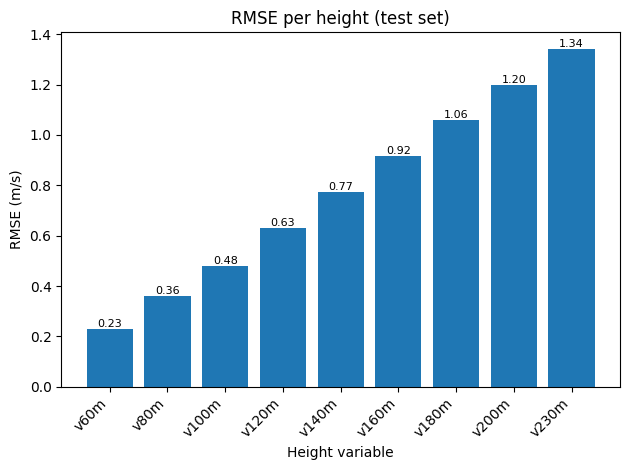

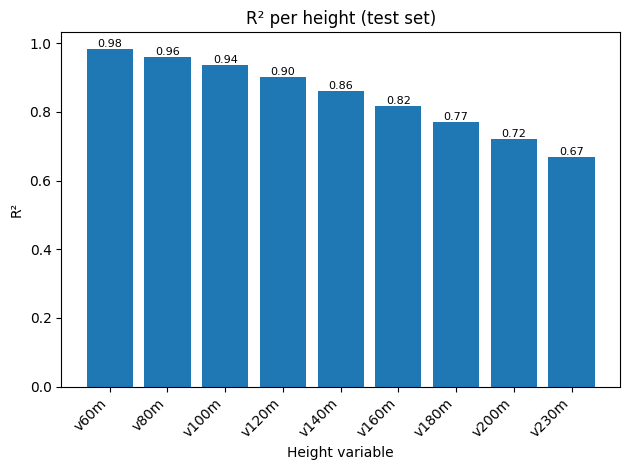

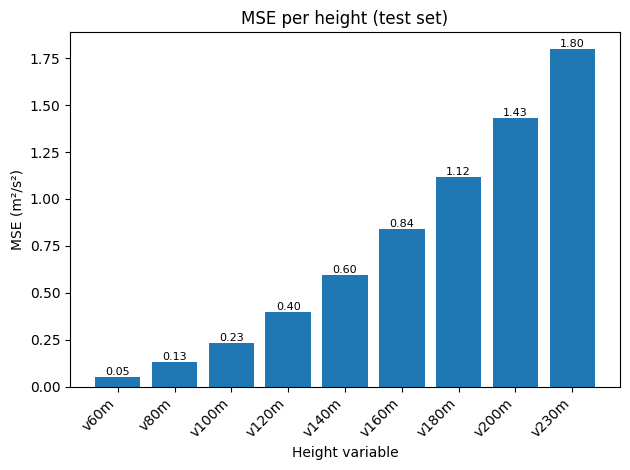

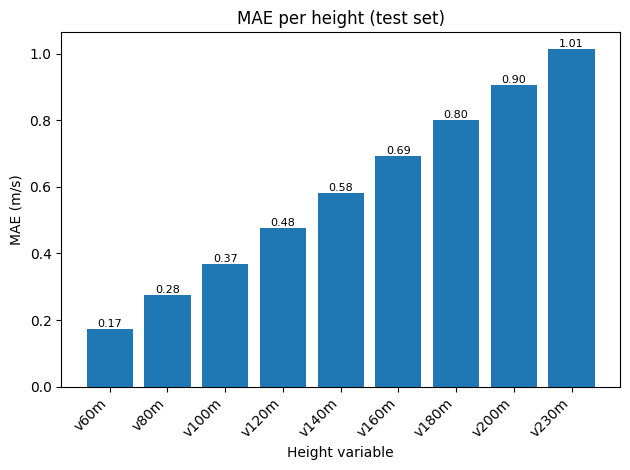

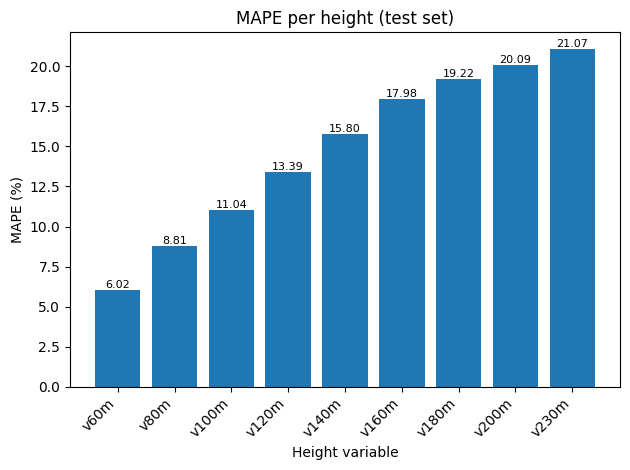


Model saved to 'lstm_site1_experiment1_timesteps1.h5'


In [14]:
"""
Experiment 1: LSTM wind profile model for 'site 1 data.csv'

Now with configurable temporal memory (TIME_STEPS):

- Each LSTM input sample is a sequence of length TIME_STEPS:
    X_seq[t] = [X_scaled[t - TIME_STEPS + 1], ..., X_scaled[t]]
  and the target is the wind profile at time t.

Steps:
1. Load and clean the Site 1 dataset.
2. Prepare data for Experiment 1:
    Inputs:
        - Time
        - v40m (40 m wind speed)
        - dir40m (40 m wind direction)
        - TKE  (turbulent kinetic energy at 40 m)
    Outputs:
        - v60m, v80m, v100m, v120m, v140m, v160m, v180m, v200m, v230m
3. Train an LSTM model.
4. Evaluate on the test set and:
    - Print metrics (R², MSE, RMSE, MAE, MAPE) per height.
    - Plot RMSE, R², MSE, MAE, MAPE per height (test set).
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 1 data.csv"   # change path if needed
CSV_SEP = ";"                  # dataset uses ';' as separator
CSV_ENCODING = "utf-8-sig"     # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90          # 90% train, 10% test (time-ordered)
LSTM_UNITS = 30                # number of LSTM neurons
EPOCHS = 30
BATCH_SIZE = 2
RANDOM_SEED = 42

TIME_STEPS = 1                 # temporal memory (lookback window)


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2": r2_score(yt, yp),
            "mse": mse,
            "rmse": rmse,
            "mae": mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(metrics_dict):
    """
    Print R², MSE, RMSE, MAE, MAPE for each output height.
    """
    for col, m in metrics_dict.items():
        print(f"\n=== Metrics for {col} (test set) ===")
        print(f"R²   : {m['r2']:6.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Plotting helper: ONLY metrics per height
# ------------------------------------------------------------

def plot_height_metrics(metrics_dict):
    """
    Bar charts of RMSE, R², MSE, MAE and MAPE across heights (test set).
    """
    heights = list(metrics_dict.keys())
    rmse_vals = [metrics_dict[h]["rmse"] for h in heights]
    r2_vals   = [metrics_dict[h]["r2"]   for h in heights]
    mse_vals  = [metrics_dict[h]["mse"]  for h in heights]
    mae_vals  = [metrics_dict[h]["mae"]  for h in heights]
    mape_vals = [metrics_dict[h]["mape"] for h in heights]

    metric_dict = {
        "RMSE (m/s)": rmse_vals,
        "R²": r2_vals,
        "MSE (m²/s²)": mse_vals,
        "MAE (m/s)": mae_vals,
        "MAPE (%)": mape_vals,
    }

    for metric_label, values in metric_dict.items():
        plt.figure()
        bars = plt.bar(heights, values)
        plt.xlabel("Height variable")
        plt.ylabel(metric_label)
        plt.title(f"{metric_label.split()[0]} per height (test set)")
        plt.xticks(rotation=45, ha="right")

        # Annotate values on top of bars
        for bar, val in zip(bars, values):
            plt.text(
                bar.get_x() + bar.get_width() / 2.0,
                bar.get_height(),
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

        plt.tight_layout()
        plt.show()


# ------------------------------------------------------------
# Data loading & preprocessing (Experiment 1)
# ------------------------------------------------------------

def load_site1_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 1 CSV file.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Replace missing-value flags if present, then interpolate
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        # In case there is a BOM in the first column name
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment1(df: pd.DataFrame, time_steps: int = TIME_STEPS):
    """
    Prepare inputs and outputs for Experiment 1, using a configurable
    temporal window (time_steps) for the LSTM.

    Each training example is:
        X_seq[t]   = [X_scaled[t - time_steps + 1], ..., X_scaled[t]]
        y_seq[t]   = y_scaled[t]

    where t is the index of the *current* time step (the prediction time).
    """

    # Inputs (same as in paper for 40 m level)
    feature_cols = ["Time", "v40m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    X = df[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    # and a target at time t
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    # --- Scaling (fit only on training portion, no leakage) ---
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1 : t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Experiment 1).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Main training & evaluation routine
# ------------------------------------------------------------

def main():
    # For reproducibility
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)

    print("Loading Site 1 data...")
    df = load_site1_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning: {df.shape}")

    # Prepare data for Experiment 1 (with TIME_STEPS memory)
    print(f"\nPreparing data for Experiment 1 with TIME_STEPS = {TIME_STEPS}...")
    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols) = prepare_experiment1(df, time_steps=TIME_STEPS)

    print("X_train shape:", X_train.shape)  # (n_train_seq, TIME_STEPS, n_features)
    print("y_train shape:", y_train_scaled.shape)

    input_shape = X_train.shape[1:]       # (TIME_STEPS, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    # Build and train LSTM
    print("\nBuilding LSTM model...")
    model = build_lstm_model(input_shape, output_dim)
    model.summary()

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("\nTraining (Experiment 1)...")
    history = model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=2
    )

    # Evaluate
    print("\nEvaluating on test set (scaled space)...")
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"Test loss (MSE, scaled): {test_loss:.4f}")
    print(f"Test MAE  (scaled):      {test_mae:.4f}")

    # Predictions back in original physical units (m/s)
    print("\nComputing predictions in original units (m/s)...")
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    # Metrics per height (R², MSE, RMSE, MAE, MAPE)
    metrics_dict = compute_height_metrics(y_test_orig, y_pred, target_cols)
    print_height_metrics(metrics_dict)

    # Only remaining plots: metrics per height on test set
    print("\nPlotting error summaries (RMSE, R², MSE, MAE, MAPE) per height...")
    plot_height_metrics(metrics_dict)

    # Save the trained model
    model_name = f"lstm_site1_experiment1_timesteps{TIME_STEPS}.h5"
    model.save(model_name)
    print(f"\nModel saved to '{model_name}'")


if __name__ == "__main__":
    main()


Loading Site 1 data...
Data shape after cleaning: (17744, 18)

Preparing data for Experiment 1 with TIME_STEPS = 1...
X_train shape: (15969, 1, 4)
y_train shape: (15969, 9)

Building LSTM model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 30)             │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           279 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,479 (17.50 KB)

 Trainable params: 4,479 (17.50 KB)

 Non-trainable params: 0 (0.00 B)


Training (Experiment 1)...
Epoch 1/30
7186/7186 - 10s - 1ms/step - loss: 0.1772 - mae: 0.3065 - val_loss: 0.1185 - val_mae: 0.2561
Epoch 2/30
7186/7186 - 8s - 1ms/step - loss: 0.1383 - mae: 0.2714 - val_loss: 0.1096 - val_mae: 0.2473
Epoch 3/30
7186/7186 - 8s - 1ms/step - loss: 0.1236 - mae: 0.2555 - val_loss: 0.1052 - val_mae: 0.2433
Epoch 4/30
7186/7186 - 8s - 1ms/step - loss: 0.1167 - mae: 0.2477 - val_loss: 0.1046 - val_mae: 0.2423
Epoch 5/30
7186/7186 - 9s - 1ms/step - loss: 0.1146 - mae: 0.2453 - val_loss: 0.1035 - val_mae: 0.2399
Epoch 6/30
7186/7186 - 8s - 1ms/step - loss: 0.1133 - mae: 0.2438 - val_loss: 0.1030 - val_mae: 0.2382
Epoch 7/30
7186/7186 - 8s - 1ms/step - loss: 0.1125 - mae: 0.2426 - val_loss: 0.1028 - val_mae: 0.2371
Epoch 8/30
7186/7186 - 8s - 1ms/step - loss: 0.1120 - mae: 0.2419 - val_loss: 0.1027 - val_mae: 0.2363
Epoch 9/30
7186/7186 - 8s - 1ms/step - loss: 0.1114 - mae: 0.2410 - val_loss: 0.1024 - val_mae: 0.2355
Epoch 10/30
7186/7186 - 8s - 1ms/step - loss

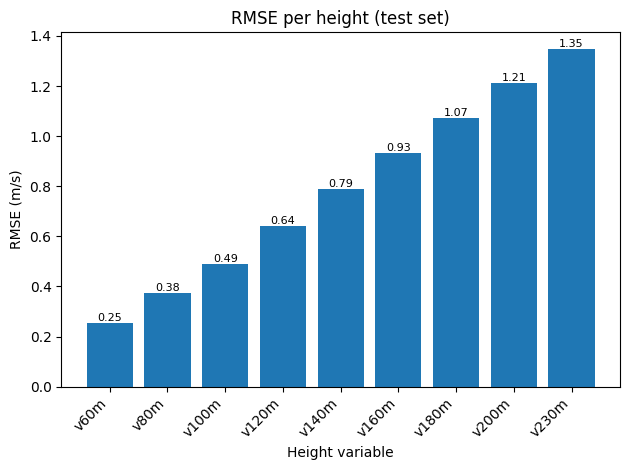

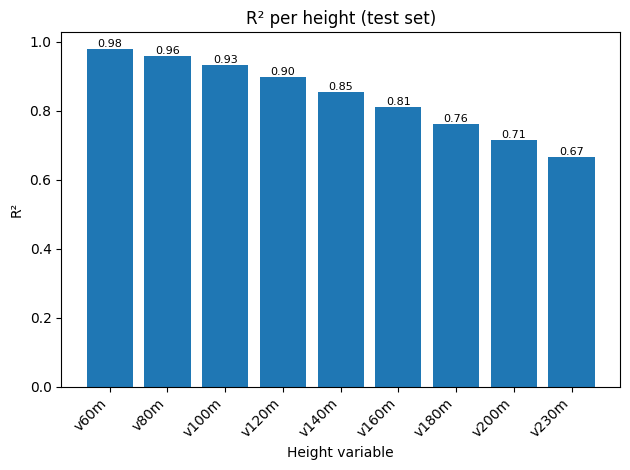

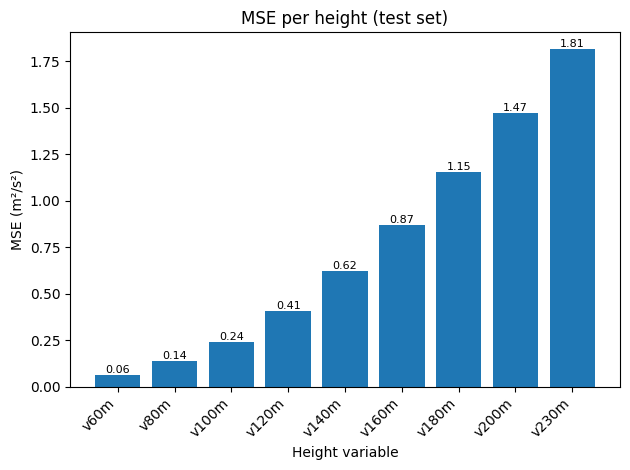

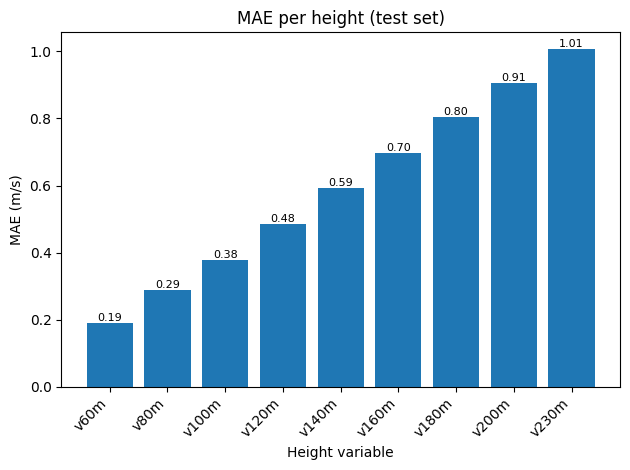

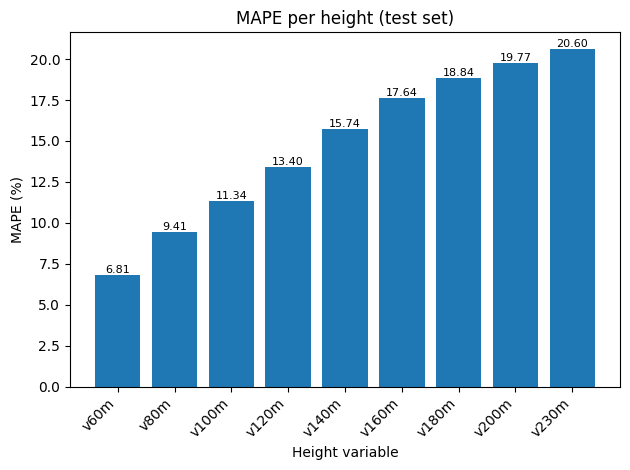


Model saved to 'lstm_site1_experiment1_timesteps1.h5'


In [15]:
"""
Experiment 1: LSTM wind profile model for 'site 1 data.csv'

Now with configurable temporal memory (TIME_STEPS):

- Each LSTM input sample is a sequence of length TIME_STEPS:
    X_seq[t] = [X_scaled[t - TIME_STEPS + 1], ..., X_scaled[t]]
  and the target is the wind profile at time t.

Steps:
1. Load and clean the Site 1 dataset.
2. Prepare data for Experiment 1:
    Inputs:
        - Time
        - v40m (40 m wind speed)
        - dir40m (40 m wind direction)
        - TKE  (turbulent kinetic energy at 40 m)
    Outputs:
        - v60m, v80m, v100m, v120m, v140m, v160m, v180m, v200m, v230m
3. Train an LSTM model.
4. Evaluate on the test set and:
    - Print metrics (R², MSE, RMSE, MAE, MAPE) per height.
    - Plot RMSE, R², MSE, MAE, MAPE per height (test set) as bar charts.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 1 data.csv"     # change path if needed
CSV_SEP = ";"                    # dataset uses ';' as separator
CSV_ENCODING = "utf-8-sig"       # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90            # 90% train, 10% test (time-ordered)
LSTM_UNITS = 30                  # number of LSTM neurons
EPOCHS = 30
BATCH_SIZE = 2
RANDOM_SEED = 42

TIME_STEPS = 1                   # <<< temporal memory (lookback window)
# e.g., 1, 3, 6, 24 depending on sampling interval and desired memory

# Kept for possible future detailed plots; not used now
PLOT_HEIGHT_NAME = "v100m"


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2": r2_score(yt, yp),
            "mse": mse,
            "rmse": rmse,
            "mae": mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(metrics_dict):
    """
    Print R², MSE, RMSE, MAE, MAPE for each output height.
    """
    for col, m in metrics_dict.items():
        print(f"\n=== Metrics for {col} (test set) ===")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Plotting helper: ONLY metrics per height
# ------------------------------------------------------------

def plot_height_metrics(metrics_dict):
    """
    Bar charts of RMSE, R², MSE, MAE and MAPE across heights (test set).
    """
    heights = list(metrics_dict.keys())
    rmse_vals = [metrics_dict[h]["rmse"] for h in heights]
    r2_vals   = [metrics_dict[h]["r2"]   for h in heights]
    mse_vals  = [metrics_dict[h]["mse"]  for h in heights]
    mae_vals  = [metrics_dict[h]["mae"]  for h in heights]
    mape_vals = [metrics_dict[h]["mape"] for h in heights]

    metric_dict = {
        "RMSE (m/s)": rmse_vals,
        "R²": r2_vals,
        "MSE (m²/s²)": mse_vals,
        "MAE (m/s)": mae_vals,
        "MAPE (%)": mape_vals,
    }

    for metric_label, values in metric_dict.items():
        plt.figure()
        bars = plt.bar(heights, values)
        plt.xlabel("Height variable")
        plt.ylabel(metric_label)
        plt.title(f"{metric_label.split()[0]} per height (test set)")
        plt.xticks(rotation=45, ha="right")

        # Annotate values on top of bars
        for bar, val in zip(bars, values):
            plt.text(
                bar.get_x() + bar.get_width() / 2.0,
                bar.get_height(),
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

        plt.tight_layout()
        plt.show()


# ------------------------------------------------------------
# Data loading & preprocessing (Experiment 1)
# ------------------------------------------------------------

def load_site1_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 1 CSV file.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Replace missing-value flags if present, then interpolate
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        # In case there is a BOM in the first column name
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment1(df: pd.DataFrame, time_steps: int = TIME_STEPS):
    """
    Prepare inputs and outputs for Experiment 1, using a configurable
    temporal window (time_steps) for the LSTM.

    Each training example is:
        X_seq[t]   = [X_scaled[t - time_steps + 1], ..., X_scaled[t]]
        y_seq[t]   = y_scaled[t]

    where t is the index of the *current* time step (the prediction time).
    """

    # Inputs (same as in paper for 40 m level)
    feature_cols = ["Time", "v40m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    X = df[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    # and a target at time t
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    # --- Scaling (fit only on training portion, no leakage) ---
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1 : t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Experiment 1).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Main training & evaluation routine
# ------------------------------------------------------------

def main():
    # For reproducibility
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)

    print("Loading Site 1 data...")
    df = load_site1_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning: {df.shape}")

    # Prepare data for Experiment 1 (with TIME_STEPS memory)
    print(f"\nPreparing data for Experiment 1 with TIME_STEPS = {TIME_STEPS}...")
    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols) = prepare_experiment1(df, time_steps=TIME_STEPS)

    print("X_train shape:", X_train.shape)  # (n_train_seq, TIME_STEPS, n_features)
    print("y_train shape:", y_train_scaled.shape)

    input_shape = X_train.shape[1:]       # (TIME_STEPS, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    # Build and train LSTM
    print("\nBuilding LSTM model...")
    model = build_lstm_model(input_shape, output_dim)
    model.summary()

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("\nTraining (Experiment 1)...")
    history = model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=2
    )

    # Evaluate
    print("\nEvaluating on test set (scaled space)...")
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"Test loss (MSE, scaled): {test_loss:.4f}")
    print(f"Test MAE  (scaled):      {test_mae:.4f}")

    # Predictions back in original physical units (m/s)
    print("\nComputing predictions in original units (m/s)...")
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    # Metrics per height (R², MSE, RMSE, MAE, MAPE) on test set
    metrics_dict = compute_height_metrics(y_test_orig, y_pred, target_cols)
    print_height_metrics(metrics_dict)

    # Only remaining plots: metrics per height on test set
    print("\nPlotting error summaries (RMSE, R², MSE, MAE, MAPE) per height...")
    plot_height_metrics(metrics_dict)

    # Save the trained model
    model_name = f"lstm_site1_experiment1_timesteps{TIME_STEPS}.h5"
    model.save(model_name)
    print(f"\nModel saved to '{model_name}'")


if __name__ == "__main__":
    main()


In [17]:
"""
Experiment 1: LSTM wind profile model for 'site 1 data.csv'

Now with configurable temporal memory (TIME_STEPS):

- Each LSTM input sample is a sequence of length TIME_STEPS:
    X_seq[t] = [X_scaled[t - TIME_STEPS + 1], ..., X_scaled[t]]
  and the target is the wind profile at time t.

Steps:
1. Load and clean the Site 1 dataset.
2. Prepare data for Experiment 1:
    Inputs:
        - Time
        - v40m (40 m wind speed)
        - dir40m (40 m wind direction)
        - TKE  (turbulent kinetic energy at 40 m)
    Outputs:
        - v60m, v80m, v100m, v120m, v140m, v160m, v180m, v200m, v230m
3. Train an LSTM model.
4. Evaluate on the test set and:
    - Print metrics (R², MSE, RMSE, MAE, MAPE) per height.
    - Show metrics as a table (console + matplotlib table figure) per height.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 1 data.csv"     # change path if needed
CSV_SEP = ";"                    # dataset uses ';' as separator
CSV_ENCODING = "utf-8-sig"       # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90            # 90% train, 10% test (time-ordered)
LSTM_UNITS = 30                  # number of LSTM neurons
EPOCHS = 30
BATCH_SIZE = 2
RANDOM_SEED = 42

TIME_STEPS = 1                   # <<< temporal memory (lookback window)
# e.g., 1, 3, 6, 24 depending on sampling interval and desired memory

# Kept for possible future detailed plots; not used now
PLOT_HEIGHT_NAME = "v100m"


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2": r2_score(yt, yp),
            "mse": mse,
            "rmse": rmse,
            "mae": mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(metrics_dict):
    """
    Print R², MSE, RMSE, MAE, MAPE for each output height.
    """
    for col, m in metrics_dict.items():
        print(f"\n=== Metrics for {col} (test set) ===")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Table helper: metrics per height
# ------------------------------------------------------------

def plot_height_metrics(metrics_dict):
    """
    Build and show a metrics table per height (test set), instead of bar plots.

    - Prints a pandas-style table to the console.
    - Displays a matplotlib table figure.
    """
    heights = list(metrics_dict.keys())

    # Build a DataFrame: rows = heights, columns = metrics
    data = {
        "R²":            [metrics_dict[h]["r2"]   for h in heights],
        "MSE (m²/s²)":   [metrics_dict[h]["mse"]  for h in heights],
        "RMSE (m/s)":    [metrics_dict[h]["rmse"] for h in heights],
        "MAE (m/s)":     [metrics_dict[h]["mae"]  for h in heights],
        "MAPE (%)":      [metrics_dict[h]["mape"] for h in heights],
    }

    df = pd.DataFrame(data, index=heights)

    # Print in console with appropriate rounding
    print("\nMetrics table per height (test set):")
    df_print = df.copy()
    df_print["R²"]          = df["R²"].round(3)
    df_print["MSE (m²/s²)"] = df["MSE (m²/s²)"].round(4)
    df_print["RMSE (m/s)"]  = df["RMSE (m/s)"].round(4)
    df_print["MAE (m/s)"]   = df["MAE (m/s)"].round(4)
    df_print["MAPE (%)"]    = df["MAPE (%)"].round(2)
    print(df_print)

    # Matplotlib table figure (for saving/visualization)
    df_fig = df_print  # use rounded values for the figure as well

    fig, ax = plt.subplots(
        figsize=(len(df_fig.columns) + 2, len(df_fig.index) * 0.5 + 2)
    )
    ax.axis('off')

    table = ax.table(
        cellText=df_fig.values,
        rowLabels=df_fig.index,
        colLabels=df_fig.columns,
        cellLoc='center',
        loc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.1, 1.2)

    ax.set_title("Metrics per height (test set)", pad=10)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Data loading & preprocessing (Experiment 1)
# ------------------------------------------------------------

def load_site1_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 1 CSV file.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Replace missing-value flags if present, then interpolate
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        # In case there is a BOM in the first column name
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment1(df: pd.DataFrame, time_steps: int = TIME_STEPS):
    """
    Prepare inputs and outputs for Experiment 1, using a configurable
    temporal window (time_steps) for the LSTM.

    Each training example is:
        X_seq[t]   = [X_scaled[t - time_steps + 1], ..., X_scaled[t]]
        y_seq[t]   = y_scaled[t]

    where t is the index of the *current* time step (the prediction time).
    """

    # Inputs (same as in paper for 40 m level)
    feature_cols = ["Time", "v40m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    X = df[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    # and a target at time t
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    # --- Scaling (fit only on training portion, no leakage) ---
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1 : t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Experiment 1).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Main training & evaluation routine
# ------------------------------------------------------------

def main():
    # For reproducibility
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)

    print("Loading Site 1 data...")
    df = load_site1_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning: {df.shape}")

    # Prepare data for Experiment 1 (with TIME_STEPS memory)
    print(f"\nPreparing data for Experiment 1 with TIME_STEPS = {TIME_STEPS}...")
    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols) = prepare_experiment1(df, time_steps=TIME_STEPS)

    print("X_train shape:", X_train.shape)  # (n_train_seq, TIME_STEPS, n_features)
    print("y_train shape:", y_train_scaled.shape)

    input_shape = X_train.shape[1:]       # (TIME_STEPS, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    # Build and train LSTM
    print("\nBuilding LSTM model...")
    model = build_lstm_model(input_shape, output_dim)
    model.summary()

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("\nTraining (Experiment 1)...")
    history = model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=2
    )

    # Evaluate
    print("\nEvaluating on test set (scaled space)...")
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"Test loss (MSE, scaled): {test_loss:.4f}")
    print(f"Test MAE  (scaled):      {test_mae:.4f}")

    # Predictions back in original physical units (m/s)
    print("\nComputing predictions in original units (m/s)...")
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    # Metrics per height (R², MSE, RMSE, MAE, MAPE) on test set
    metrics_dict = compute_height_metrics(y_test_orig, y_pred, target_cols)
    print_height_metrics(metrics_dict)

    # Show metrics as tables (console)
    print("\nShowing metrics table per height...")

    # Save the trained model
    model_name = f"lstm_site1_experiment1_timesteps{TIME_STEPS}.h5"
    model.save(model_name)
    print(f"\nModel saved to '{model_name}'")


if __name__ == "__main__":
    main()


Loading Site 1 data...
Data shape after cleaning: (17744, 18)

Preparing data for Experiment 1 with TIME_STEPS = 1...
X_train shape: (15969, 1, 4)
y_train shape: (15969, 9)

Building LSTM model...


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 30)             │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           279 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,479 (17.50 KB)

 Trainable params: 4,479 (17.50 KB)

 Non-trainable params: 0 (0.00 B)


Training (Experiment 1)...
Epoch 1/30
7186/7186 - 3s - 420us/step - loss: 0.1780 - mae: 0.3073 - val_loss: 0.1176 - val_mae: 0.2550
Epoch 2/30
7186/7186 - 2s - 345us/step - loss: 0.1404 - mae: 0.2728 - val_loss: 0.1124 - val_mae: 0.2499
Epoch 3/30
7186/7186 - 2s - 344us/step - loss: 0.1322 - mae: 0.2638 - val_loss: 0.1092 - val_mae: 0.2479
Epoch 4/30
7186/7186 - 2s - 332us/step - loss: 0.1255 - mae: 0.2567 - val_loss: 0.1071 - val_mae: 0.2463
Epoch 5/30
7186/7186 - 3s - 376us/step - loss: 0.1200 - mae: 0.2508 - val_loss: 0.1057 - val_mae: 0.2439
Epoch 6/30
7186/7186 - 2s - 331us/step - loss: 0.1164 - mae: 0.2469 - val_loss: 0.1047 - val_mae: 0.2419
Epoch 7/30
7186/7186 - 2s - 335us/step - loss: 0.1142 - mae: 0.2445 - val_loss: 0.1039 - val_mae: 0.2405
Epoch 8/30
7186/7186 - 2s - 329us/step - loss: 0.1128 - mae: 0.2429 - val_loss: 0.1033 - val_mae: 0.2395
Epoch 9/30
7186/7186 - 2s - 330us/step - loss: 0.1118 - mae: 0.2416 - val_loss: 0.1029 - val_mae: 0.2386
Epoch 10/30
7186/7186 - 2s 


=== Metrics for v60m (test set) ===
R²   :      0.980
MSE  :     0.0594 (m²/s²)
RMSE :     0.2437 (m/s)
MAE  :     0.1763 (m/s)
MAPE :       6.16 (%)

=== Metrics for v80m (test set) ===
R²   :      0.958
MSE  :     0.1383 (m²/s²)
RMSE :     0.3719 (m/s)
MAE  :     0.2827 (m/s)
MAPE :       8.99 (%)

=== Metrics for v100m (test set) ===
R²   :      0.933
MSE  :     0.2403 (m²/s²)
RMSE :     0.4902 (m/s)
MAE  :     0.3740 (m/s)
MAPE :      11.17 (%)

=== Metrics for v120m (test set) ===
R²   :      0.900
MSE  :     0.3981 (m²/s²)
RMSE :     0.6309 (m/s)
MAE  :     0.4783 (m/s)
MAPE :      13.39 (%)

=== Metrics for v140m (test set) ===
R²   :      0.859
MSE  :     0.6047 (m²/s²)
RMSE :     0.7777 (m/s)
MAE  :     0.5868 (m/s)
MAPE :      15.92 (%)

=== Metrics for v160m (test set) ===
R²   :      0.814
MSE  :     0.8517 (m²/s²)
RMSE :     0.9229 (m/s)
MAE  :     0.6952 (m/s)
MAPE :      18.03 (%)

=== Metrics for v180m (test set) ===
R²   :      0.770
MSE  :     1.1183 (m²/s²)
RMSE :  

# Time Series 1

In [19]:
"""
Experiment 1: LSTM wind profile model for 'site 1 data.csv'

Now with configurable temporal memory (TIME_STEPS):

- Each LSTM input sample is a sequence of length TIME_STEPS:
    X_seq[t] = [X_scaled[t - TIME_STEPS + 1], ..., X_scaled[t]]
  and the target is the wind profile at time t.

Steps:
1. Load and clean the Site 1 dataset.
2. Prepare data for Experiment 1:
    Inputs:
        - Time
        - v40m (40 m wind speed)
        - dir40m (40 m wind direction)
        - TKE  (turbulent kinetic energy at 40 m)
    Outputs:
        - v60m, v80m, v100m, v120m, v140m, v160m, v180m, v200m, v230m
3. Train an LSTM model.
4. Evaluate on the test set and:
    - Compute metrics (R², MSE, RMSE, MAE, MAPE) per height.
    - Print metrics as a table in the console (test set).
"""

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 1 data.csv"     # change path if needed
CSV_SEP = ";"                    # dataset uses ';' as separator
CSV_ENCODING = "utf-8-sig"       # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90            # 90% train, 10% test (time-ordered)
LSTM_UNITS = 30                  # number of LSTM neurons
EPOCHS = 30
BATCH_SIZE = 2
RANDOM_SEED = 42

TIME_STEPS = 1                   # <<< temporal memory (lookback window)
# e.g., 1, 3, 6, 24 depending on sampling interval and desired memory

# Kept for possible future detailed plots; not used now
PLOT_HEIGHT_NAME = "v100m"


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2": r2_score(yt, yp),
            "mse": mse,
            "rmse": rmse,
            "mae": mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(metrics_dict):
    """
    Print R², MSE, RMSE, MAE, MAPE for each output height (line-by-line).
    """
    for col, m in metrics_dict.items():
        print(f"\n=== Metrics for {col} (test set) ===")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Console table helper (no plots)
# ------------------------------------------------------------

def show_height_metrics_table(metrics_dict):
    """
    Show metrics as a tab-separated table in the console,
    so it can be copied directly into Excel.

    Columns:
        height    R2    MSE_m2s2    RMSE_ms    MAE_ms    MAPE_pct
    """
    heights = list(metrics_dict.keys())

    print("\nExcel-friendly metrics table per height (test set):")
    # Header row (tab-separated)
    print("height\tR2\tMSE_m2s2\tRMSE_ms\tMAE_ms\tMAPE_pct")

    # Data rows (tab-separated)
    for h in heights:
        m = metrics_dict[h]
        print(
            f"{h}\t"
            f"{m['r2']:.6f}\t"
            f"{m['mse']:.6f}\t"
            f"{m['rmse']:.6f}\t"
            f"{m['mae']:.6f}\t"
            f"{m['mape']:.6f}"
        )


# ------------------------------------------------------------
# Data loading & preprocessing (Experiment 1)
# ------------------------------------------------------------

def load_site1_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 1 CSV file.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Replace missing-value flags if present, then interpolate
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        # In case there is a BOM in the first column name
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment1(df: pd.DataFrame, time_steps: int = TIME_STEPS):
    """
    Prepare inputs and outputs for Experiment 1, using a configurable
    temporal window (time_steps) for the LSTM.

    Each training example is:
        X_seq[t]   = [X_scaled[t - time_steps + 1], ..., X_scaled[t]]
        y_seq[t]   = y_scaled[t]

    where t is the index of the *current* time step (the prediction time).
    """

    # Inputs (same as in paper for 40 m level)
    feature_cols = ["Time", "v40m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    X = df[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    # and a target at time t
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    # --- Scaling (fit only on training portion, no leakage) ---
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1 : t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Experiment 1).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Main training & evaluation routine
# ------------------------------------------------------------

def main():
    # For reproducibility
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)

    print("Loading Site 1 data...")
    df = load_site1_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning: {df.shape}")

    # Prepare data for Experiment 1 (with TIME_STEPS memory)
    print(f"\nPreparing data for Experiment 1 with TIME_STEPS = {TIME_STEPS}...")
    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols) = prepare_experiment1(df, time_steps=TIME_STEPS)

    print("X_train shape:", X_train.shape)  # (n_train_seq, TIME_STEPS, n_features)
    print("y_train shape:", y_train_scaled.shape)

    input_shape = X_train.shape[1:]       # (TIME_STEPS, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    # Build and train LSTM
    print("\nBuilding LSTM model...")
    model = build_lstm_model(input_shape, output_dim)
    model.summary()

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("\nTraining (Experiment 1)...")
    history = model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=2
    )

    # Evaluate
    print("\nEvaluating on test set (scaled space)...")
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"Test loss (MSE, scaled): {test_loss:.4f}")
    print(f"Test MAE  (scaled):      {test_mae:.4f}")

    # Predictions back in original physical units (m/s)
    print("\nComputing predictions in original units (m/s)...")
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    # Metrics per height (R², MSE, RMSE, MAE, MAPE) on test set
    metrics_dict = compute_height_metrics(y_test_orig, y_pred, target_cols)

    # Optional: detailed per-height block output
    print_height_metrics(metrics_dict)

    # Console table summary
    show_height_metrics_table(metrics_dict)

    # Save the trained model
    model_name = f"lstm_site1_experiment1_timesteps{TIME_STEPS}.h5"
    model.save(model_name)
    print(f"\nModel saved to '{model_name}'")


if __name__ == "__main__":
    main()


Loading Site 1 data...
Data shape after cleaning: (17744, 18)

Preparing data for Experiment 1 with TIME_STEPS = 1...
X_train shape: (15969, 1, 4)
y_train shape: (15969, 9)

Building LSTM model...


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 30)             │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │           279 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,479 (17.50 KB)

 Trainable params: 4,479 (17.50 KB)

 Non-trainable params: 0 (0.00 B)


Training (Experiment 1)...
Epoch 1/30
7186/7186 - 3s - 408us/step - loss: 0.1780 - mae: 0.3074 - val_loss: 0.1174 - val_mae: 0.2548
Epoch 2/30
7186/7186 - 2s - 336us/step - loss: 0.1397 - mae: 0.2725 - val_loss: 0.1114 - val_mae: 0.2488
Epoch 3/30
7186/7186 - 2s - 330us/step - loss: 0.1278 - mae: 0.2600 - val_loss: 0.1063 - val_mae: 0.2442
Epoch 4/30
7186/7186 - 2s - 337us/step - loss: 0.1187 - mae: 0.2500 - val_loss: 0.1049 - val_mae: 0.2424
Epoch 5/30
7186/7186 - 2s - 330us/step - loss: 0.1150 - mae: 0.2457 - val_loss: 0.1043 - val_mae: 0.2409
Epoch 6/30
7186/7186 - 2s - 337us/step - loss: 0.1135 - mae: 0.2437 - val_loss: 0.1038 - val_mae: 0.2396
Epoch 7/30
7186/7186 - 2s - 336us/step - loss: 0.1126 - mae: 0.2424 - val_loss: 0.1033 - val_mae: 0.2385
Epoch 8/30
7186/7186 - 2s - 330us/step - loss: 0.1119 - mae: 0.2414 - val_loss: 0.1030 - val_mae: 0.2379
Epoch 9/30
7186/7186 - 2s - 346us/step - loss: 0.1111 - mae: 0.2404 - val_loss: 0.1028 - val_mae: 0.2372
Epoch 10/30
7186/7186 - 2s 


Evaluating on test set (scaled space)...
Test loss (MSE, scaled): 0.1657
Test MAE  (scaled):      0.2853

Computing predictions in original units (m/s)...

=== Metrics for v60m (test set) ===
R²   :      0.978
MSE  :     0.0647 (m²/s²)
RMSE :     0.2544 (m/s)
MAE  :     0.1826 (m/s)
MAPE :       6.63 (%)

=== Metrics for v80m (test set) ===
R²   :      0.955
MSE  :     0.1473 (m²/s²)
RMSE :     0.3838 (m/s)
MAE  :     0.2870 (m/s)
MAPE :       9.27 (%)

=== Metrics for v100m (test set) ===
R²   :      0.930
MSE  :     0.2508 (m²/s²)
RMSE :     0.5008 (m/s)
MAE  :     0.3777 (m/s)
MAPE :      11.28 (%)

=== Metrics for v120m (test set) ===
R²   :      0.895
MSE  :     0.4167 (m²/s²)
RMSE :     0.6455 (m/s)
MAE  :     0.4862 (m/s)
MAPE :      13.46 (%)

=== Metrics for v140m (test set) ===
R²   :      0.854
MSE  :     0.6255 (m²/s²)
RMSE :     0.7909 (m/s)
MAE  :     0.5934 (m/s)
MAPE :      15.90 (%)

=== Metrics for v160m (test set) ===
R²   :      0.810
MSE  :     0.8670 (m²/s²)
RMSE

In [20]:
"""
Experiment 1: LSTM wind profile model for 'site 1 data.csv'

Multi-run version:
- Loops over several TIME_STEPS values.
- For each TIME_STEPS:
    * Prepares sequences of that temporal memory length.
    * Trains a fresh LSTM model.
    * Evaluates on the test set.
    * Prints an Excel-friendly metrics table per height (test set).

Metrics per height (test set):
- R²
- MSE
- RMSE
- MAE
- MAPE
"""

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 1 data.csv"     # change path if needed
CSV_SEP = ";"                    # dataset uses ';' as separator
CSV_ENCODING = "utf-8-sig"       # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90            # 90% train, 10% test (time-ordered)
LSTM_UNITS = 30                  # number of LSTM neurons
EPOCHS = 30
BATCH_SIZE = 2
RANDOM_SEED = 42

# <<< list of temporal memories (lookback windows) to test >>>
TIME_STEPS_LIST = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
# e.g. [1, 3, 6, 24] or [1, 2, 4, 8]


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(metrics_dict):
    """
    Optional: detailed block printout per height (human-readable).
    """
    for col, m in metrics_dict.items():
        print(f"\n=== Metrics for {col} (test set) ===")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Excel-friendly console table (no plots)
# ------------------------------------------------------------

def show_height_metrics_table(time_steps, metrics_dict):
    """
    Show metrics as a tab-separated table in the console,
    so it can be copied directly into Excel.

    Columns:
        time_steps    height    R2    MSE_m2s2    RMSE_ms    MAE_ms    MAPE_pct
    """
    heights = list(metrics_dict.keys())

    print(f"\nExcel-friendly metrics table per height (test set), TIME_STEPS = {time_steps}:")
    # Header row (tab-separated)
    print("time_steps\theight\tR2\tMSE_m2s2\tRMSE_ms\tMAE_ms\tMAPE_pct")

    # Data rows (tab-separated)
    for h in heights:
        m = metrics_dict[h]
        print(
            f"{time_steps}\t{h}\t"
            f"{m['r2']:.6f}\t"
            f"{m['mse']:.6f}\t"
            f"{m['rmse']:.6f}\t"
            f"{m['mae']:.6f}\t"
            f"{m['mape']:.6f}"
        )


# ------------------------------------------------------------
# Data loading & preprocessing
# ------------------------------------------------------------

def load_site1_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 1 CSV file.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Replace missing-value flags if present, then interpolate
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        # In case there is a BOM in the first column name
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment1(df: pd.DataFrame, time_steps: int):
    """
    Prepare inputs and outputs for Experiment 1, using a configurable
    temporal window (time_steps) for the LSTM.

    Each training example is:
        X_seq[t]   = [X_scaled[t - time_steps + 1], ..., X_scaled[t]]
        y_seq[t]   = y_scaled[t]

    where t is the index of the *current* time step (the prediction time).
    """

    # Inputs (same as in paper for 40 m level)
    feature_cols = ["Time", "v40m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    X = df[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    # and a target at time t
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    # --- Scaling (fit only on training portion, no leakage) ---
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1 : t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Experiment 1).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Single run for a given TIME_STEPS (fresh "session")
# ------------------------------------------------------------

def run_single_experiment(df, time_steps: int):
    """
    Run the full pipeline (prepare -> train -> evaluate)
    for a specific time_steps value.
    """

    # New TF "session"-like state and deterministic seeds
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols) = prepare_experiment1(df, time_steps=time_steps)

    print("  X_train shape:", X_train.shape)  # (n_train_seq, time_steps, n_features)
    print("  y_train shape:", y_train_scaled.shape)

    input_shape = X_train.shape[1:]       # (time_steps, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    # Build and train LSTM
    print("  Building LSTM model...")
    model = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("  Training...")
    history = model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate (scaled space)
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  Test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  Test MAE  (scaled):      {test_mae:.4f}")

    # Predictions back in original physical units (m/s)
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    # Metrics per height (R², MSE, RMSE, MAE, MAPE) on test set
    metrics_dict = compute_height_metrics(y_test_orig, y_pred, target_cols)
    return metrics_dict


# ------------------------------------------------------------
# Main: loop over all TIME_STEPS in TIME_STEPS_LIST
# ------------------------------------------------------------

def main():
    print("Loading Site 1 data...")
    df = load_site1_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning: {df.shape}")

    for ts in TIME_STEPS_LIST:
        print(f"\n=== Running experiment for TIME_STEPS = {ts} ===")
        metrics_dict = run_single_experiment(df, time_steps=ts)

        # Optional: detailed per-height metrics
        print_height_metrics(metrics_dict)

        # Excel-friendly table per height (copy/paste into Excel)
        show_height_metrics_table(ts, metrics_dict)


if __name__ == "__main__":
    main()


Loading Site 1 data...
Data shape after cleaning: (17744, 18)

=== Running experiment for TIME_STEPS = 1 ===
  X_train shape: (15969, 1, 4)
  y_train shape: (15969, 9)
  Building LSTM model...
  Training...
  Test loss (MSE, scaled): 0.1667
  Test MAE  (scaled):      0.2854

=== Metrics for v60m (test set) ===
R²   :      0.982
MSE  :     0.0522 (m²/s²)
RMSE :     0.2285 (m/s)
MAE  :     0.1774 (m/s)
MAPE :       6.56 (%)

=== Metrics for v80m (test set) ===
R²   :      0.960
MSE  :     0.1313 (m²/s²)
RMSE :     0.3624 (m/s)
MAE  :     0.2830 (m/s)
MAPE :       9.45 (%)

=== Metrics for v100m (test set) ===
R²   :      0.934
MSE  :     0.2364 (m²/s²)
RMSE :     0.4862 (m/s)
MAE  :     0.3752 (m/s)
MAPE :      11.61 (%)

=== Metrics for v120m (test set) ===
R²   :      0.899
MSE  :     0.4015 (m²/s²)
RMSE :     0.6336 (m/s)
MAE  :     0.4808 (m/s)
MAPE :      13.81 (%)

=== Metrics for v140m (test set) ===
R²   :      0.858
MSE  :     0.6072 (m²/s²)
RMSE :     0.7793 (m/s)
MAE  :     0.

## Site 1 holistic analysis

In [36]:
"""
Experiment 1: LSTM wind profile model for 'site 1 data.csv'

Single-run version with baseline models:
- Uses a single TIME_STEPS value.
- Prepares sequences of that temporal memory length.
- Trains a fresh LSTM model (wind profile model).
- Fits power-law and log-law profile models on the training set.
- Evaluates all three models (LSTM, power law, log law) on the same test set.
- Saves the comparison table (metrics per height) to a CSV file.

Metrics per height (test set):
- R²
- MSE
- RMSE
- MAE
- MAPE
"""

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 1 data.csv"     # change path if needed
CSV_SEP = ";"                    # dataset uses ';' as separator
CSV_ENCODING = "utf-8-sig"       # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90            # 90% train, 10% test (time-ordered)
LSTM_UNITS = 30                  # number of LSTM neurons
EPOCHS = 30
BATCH_SIZE = 2
RANDOM_SEED = 42

# single temporal memory (lookback window) to use
TIME_STEPS = 2                   # <-- set your desired time steps here

REF_HEIGHT = 40.0                # reference height for v40m (m)
REF_COL = "v40m"                 # reference speed column


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(model_name, metrics_dict):
    """
    Detailed block printout per height for a given model.
    """
    print(f"\n=== {model_name}: Metrics per height (test set) ===")
    for col, m in metrics_dict.items():
        print(f"\n--- {col} ---")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# CSV comparison table (saved as .csv)
# ------------------------------------------------------------

def show_comparison_table(metrics_lstm, metrics_power, metrics_log, csv_path=None):
    """
    Build a comparison table (LSTM vs Power law vs Log law) as a pandas
    DataFrame, save it to a CSV file, and also print it.

    Columns:
        model    height    R2    MSE_m2s2    RMSE_ms    MAE_ms    MAPE_pct
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            rows.append({
                "model":     model_name,
                "height":    h,
                "R2":        m["r2"],
                "MSE_m2s2":  m["mse"],
                "RMSE_ms":   m["rmse"],
                "MAE_ms":    m["mae"],
                "MAPE_pct":  m["mape"],
            })

    df_out = pd.DataFrame(rows)

    # Default CSV filename (includes TIME_STEPS)
    if csv_path is None:
        csv_path = f"site1_model_comparison_TIMESTEPS_{TIME_STEPS}.csv"

    # Save to CSV
    df_out.to_csv(csv_path, index=False)

    # Print to console as well (optional)
    print("\nComparison table (also saved to CSV):")
    print(df_out.to_string(index=False))
    print(f"\nSaved CSV file: {csv_path}")


# ------------------------------------------------------------
# Utilities for heights & baseline models
# ------------------------------------------------------------

def height_from_column(col_name: str) -> float:
    """
    Extract numeric height from column names like 'v60m', 'v100m', etc.
    Assumes format 'v<height>m'.
    """
    return float(col_name[1:-1])


def fit_power_law_alpha(df: pd.DataFrame,
                        train_indices: np.ndarray,
                        target_cols,
                        ref_height: float = REF_HEIGHT,
                        ref_col: str = REF_COL) -> float:
    """
    Fit a single global power-law exponent alpha using training data:

        v(z) = v_ref * (z / ref_height)**alpha

    Fit alpha from:
        log(v(z) / v_ref) = alpha * log(z / ref_height)
    via least squares in log space.
    """
    x_vals = []
    y_vals = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            x_vals.append(np.log(z / ref_height))
            y_vals.append(np.log(v_tar / v_ref))

    if len(x_vals) == 0:
        print("Warning: no valid samples for fitting power-law alpha. Using alpha = 0.14.")
        return 0.14

    x_arr = np.asarray(x_vals, dtype=float)
    y_arr = np.asarray(y_vals, dtype=float)

    denom = np.sum(x_arr**2)
    if denom <= 0:
        print("Warning: degenerate fit for power-law alpha. Using alpha = 0.14.")
        return 0.14

    alpha = np.sum(x_arr * y_arr) / denom
    return alpha


def fit_log_law_z0(df: pd.DataFrame,
                   train_indices: np.ndarray,
                   target_cols,
                   ref_height: float = REF_HEIGHT,
                   ref_col: str = REF_COL) -> float:
    """
    Fit a single global roughness length z0 for the log law:

        v(z) = v_ref * ln(z / z0) / ln(ref_height / z0)

    by minimizing squared error on speed ratios over the training set.
    """
    z_list = []
    r_list = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            r = v_tar / v_ref  # measured ratio v(z) / v_ref
            z_list.append(z)
            r_list.append(r)

    if len(z_list) == 0:
        print("Warning: no valid samples for fitting log-law z0. Using z0 = 0.1 m.")
        return 0.1

    z_arr = np.asarray(z_list, dtype=float)
    r_arr = np.asarray(r_list, dtype=float)

    # Search z0 in a reasonable range (log-spaced)
    z0_candidates = np.logspace(-3, 1, 200)  # 0.001 to 10 m
    best_z0 = None
    best_loss = np.inf

    for z0 in z0_candidates:
        if z0 >= ref_height:
            continue

        denom = np.log(ref_height / z0)
        if denom == 0:
            continue

        r_model = np.log(z_arr / z0) / denom
        loss = np.mean((r_arr - r_model)**2)

        if loss < best_loss:
            best_loss = loss
            best_z0 = z0

    if best_z0 is None:
        print("Warning: failed to find good z0. Using z0 = 0.1 m.")
        best_z0 = 0.1

    return best_z0


def predict_power_and_log_profiles(df: pd.DataFrame,
                                   indices: np.ndarray,
                                   target_cols,
                                   alpha: float,
                                   z0: float,
                                   ref_height: float = REF_HEIGHT,
                                   ref_col: str = REF_COL):
    """
    Compute predictions for power-law and log-law models for all test indices.

    Returns:
        y_pred_power  : (n_test, n_heights)
        y_pred_loglaw : (n_test, n_heights)
    """
    n_test = len(indices)
    n_heights = len(target_cols)

    y_pred_power = np.zeros((n_test, n_heights), dtype="float32")
    y_pred_loglaw = np.zeros((n_test, n_heights), dtype="float32")

    denom_log = np.log(ref_height / z0)

    for i, idx in enumerate(indices):
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            # leave predictions as zeros; they will just contribute to error
            continue

        for j, col in enumerate(target_cols):
            z = height_from_column(col)

            # Power law
            y_pred_power[i, j] = float(v_ref) * (z / ref_height)**alpha

            # Log law
            ratio = np.log(z / z0) / denom_log
            y_pred_loglaw[i, j] = float(v_ref) * ratio

    return y_pred_power, y_pred_loglaw


# ------------------------------------------------------------
# Data loading & preprocessing (Site 1)
# ------------------------------------------------------------

def load_site1_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 1 CSV file.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Replace missing-value flags if present, then interpolate
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        # In case there is a BOM in the first column name
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment1(df: pd.DataFrame, time_steps: int):
    """
    Prepare inputs and outputs for Experiment 1, using a configurable
    temporal window (time_steps) for the LSTM.

    Each training example is:
        X_seq[t]   = [X_scaled[t - time_steps + 1], ..., X_scaled[t]]
        y_seq[t]   = y_scaled[t]

    where t is the index of the *current* time step (the prediction time).
    """

    # Inputs (same as in paper for 40 m level)
    feature_cols = ["Time", "v40m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    X = df[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    # and a target at time t
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    train_indices = indices[train_mask]
    test_indices = indices[test_mask]

    # --- Scaling (fit only on training portion, no leakage) ---
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1 : t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols,
            train_indices, test_indices)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Experiment 1).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Single experiment for the chosen TIME_STEPS
# ------------------------------------------------------------

def run_experiment(df, time_steps: int):
    """
    Run the full pipeline (prepare -> train -> evaluate)
    for the specified time_steps value.

    Returns:
        metrics_lstm, metrics_power, metrics_log (three dicts per height)
    """

    # New TF "session"-like state and deterministic seeds
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols,
     train_indices, test_indices) = prepare_experiment1(df, time_steps=time_steps)

    print("  X_train shape:", X_train.shape)  # (n_train_seq, time_steps, n_features)
    print("  y_train shape:", y_train_scaled.shape)

    # --- Fit baseline models on training portion ---
    alpha = fit_power_law_alpha(df, train_indices, target_cols)
    z0 = fit_log_law_z0(df, train_indices, target_cols)

    print(f"  Power-law alpha (global): {alpha:.4f}")
    print(f"  Log-law z0   (global): {z0:.4f} m")

    # --- Build and train LSTM ---
    input_shape = X_train.shape[1:]       # (time_steps, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    print("  Building LSTM model...")
    model = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("  Training LSTM...")
    history = model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate (scaled space)
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  LSTM test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  LSTM test MAE  (scaled):      {test_mae:.4f}")

    # Predictions back in original physical units (m/s)
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred_lstm = y_scaler.inverse_transform(y_pred_scaled)

    # --- Baseline predictions on same test indices ---
    y_pred_power, y_pred_log = predict_power_and_log_profiles(
        df, test_indices, target_cols, alpha, z0
    )

    # Metrics per height (R², MSE, RMSE, MAE, MAPE) on test set
    metrics_lstm  = compute_height_metrics(y_test_orig, y_pred_lstm,  target_cols)
    metrics_power = compute_height_metrics(y_test_orig, y_pred_power, target_cols)
    metrics_log   = compute_height_metrics(y_test_orig, y_pred_log,   target_cols)

    return metrics_lstm, metrics_power, metrics_log


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():
    print("Loading Site 1 data...")
    df = load_site1_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning: {df.shape}")

    if len(df) == 0:
        raise ValueError("Site 1 dataframe is empty after cleaning. "
                         "Check CSV_PATH, separator, and column names.")

    print(f"\n=== Running experiment for TIME_STEPS = {TIME_STEPS} ===")
    metrics_lstm, metrics_power, metrics_log = run_experiment(df, time_steps=TIME_STEPS)

    # Optional: detailed per-height metrics for each model
    print_height_metrics("LSTM",     metrics_lstm)
    print_height_metrics("PowerLaw", metrics_power)
    print_height_metrics("LogLaw",   metrics_log)

    # Save combined comparison (LSTM vs Power law vs Log law) to CSV
    show_comparison_table(metrics_lstm, metrics_power, metrics_log)


if __name__ == "__main__":
    main()


Loading Site 1 data...
Data shape after cleaning: (17744, 18)

=== Running experiment for TIME_STEPS = 2 ===
  X_train shape: (15968, 2, 4)
  y_train shape: (15968, 9)
  Power-law alpha (global): 0.2744
  Log-law z0   (global): 3.0018 m
  Building LSTM model...
  Training LSTM...
  LSTM test loss (MSE, scaled): 0.1684
  LSTM test MAE  (scaled):      0.2897

=== LSTM: Metrics per height (test set) ===

--- v60m ---
R²   :      0.978
MSE  :     0.0639 (m²/s²)
RMSE :     0.2527 (m/s)
MAE  :     0.1908 (m/s)
MAPE :       6.81 (%)

--- v80m ---
R²   :      0.957
MSE  :     0.1426 (m²/s²)
RMSE :     0.3776 (m/s)
MAE  :     0.2900 (m/s)
MAPE :       9.09 (%)

--- v100m ---
R²   :      0.932
MSE  :     0.2431 (m²/s²)
RMSE :     0.4931 (m/s)
MAE  :     0.3808 (m/s)
MAPE :      11.18 (%)

--- v120m ---
R²   :      0.897
MSE  :     0.4095 (m²/s²)
RMSE :     0.6399 (m/s)
MAE  :     0.4890 (m/s)
MAPE :      13.52 (%)

--- v140m ---
R²   :      0.856
MSE  :     0.6170 (m²/s²)
RMSE :     0.7855 (m/s)

Loading Site 1 data...
Data shape after cleaning: (17744, 18)

=== Running experiment for TIME_STEPS = 2 ===
  X_train shape: (15968, 2, 4)
  y_train shape: (15968, 9)
  Power-law alpha (fixed): 0.2500 (from paper)
  Log-law z0   (global): 3.0018 m
  Building LSTM model...
  Training LSTM...
  LSTM test loss (MSE, scaled): 0.1624
  LSTM test MAE  (scaled):      0.2869

=== LSTM: Metrics per height (test set) ===

--- v60m ---
R²   :      0.976
MSE  :     0.0703 (m²/s²)
RMSE :     0.2652 (m/s)
MAE  :     0.1956 (m/s)
MAPE :       7.39 (%)

--- v80m ---
R²   :      0.955
MSE  :     0.1468 (m²/s²)
RMSE :     0.3831 (m/s)
MAE  :     0.2951 (m/s)
MAPE :       9.71 (%)

--- v100m ---
R²   :      0.930
MSE  :     0.2514 (m²/s²)
RMSE :     0.5014 (m/s)
MAE  :     0.3866 (m/s)
MAPE :      11.78 (%)

--- v120m ---
R²   :      0.896
MSE  :     0.4102 (m²/s²)
RMSE :     0.6404 (m/s)
MAE  :     0.4906 (m/s)
MAPE :      13.88 (%)

--- v140m ---
R²   :      0.858
MSE  :     0.6065 (m²/s²)
RMSE :     

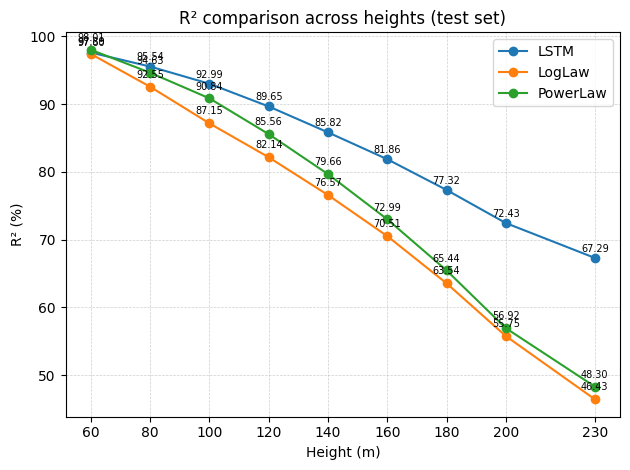

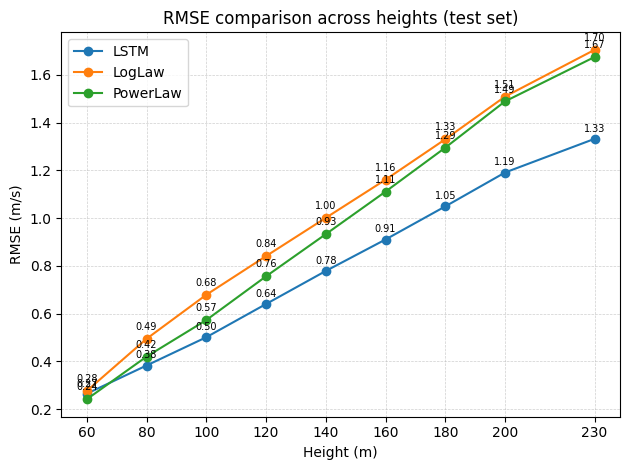

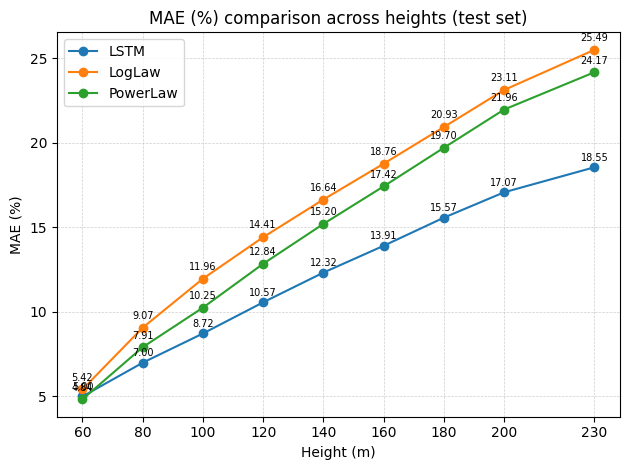


Plotting vertical wind profiles (Observed, LSTM, Power law, Log law)...


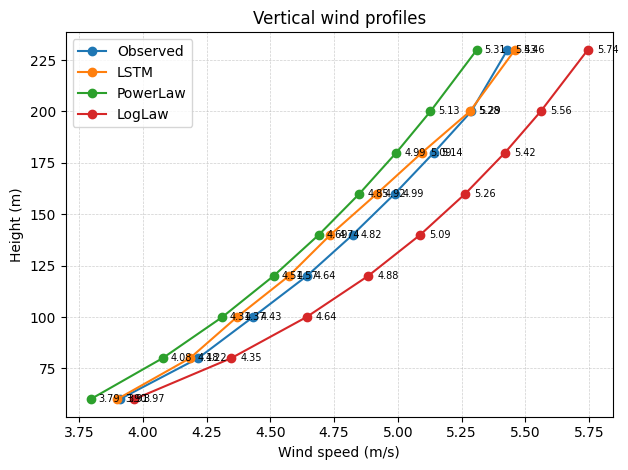

In [48]:
"""
Experiment 1: LSTM wind profile model for 'site 1 data.csv'

Single-run version with baseline models:
- Uses a single TIME_STEPS value.
- Prepares sequences of that temporal memory length.
- Trains a fresh LSTM model (wind profile model).
- Uses a FIXED power-law exponent alpha = 0.25 (as in the paper).
- Fits a log-law profile model (z0) on the training set.
- Evaluates all three models (LSTM, power law, log law) on the same test set.
- Prints a comparison table (metrics per height) to the console.
- Plots:
    * R² (%) vs height
    * RMSE (m/s) vs height
    * MAE (%) vs height
    * Vertical wind profiles (mean): Observed, LSTM, Power law, Log law
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 1 data.csv"     # change path if needed
CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"       # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90            # 90% train, 10% test (time-ordered)
LSTM_UNITS = 30                  # number of LSTM neurons
EPOCHS = 30
BATCH_SIZE = 2
RANDOM_SEED = 42

# single temporal memory (lookback window) to use
TIME_STEPS = 2                   # <-- set your desired time steps here

REF_HEIGHT = 40.0                # reference height for v40m (m)
REF_COL = "v40m"                 # reference speed column

# Fixed power-law exponent from the paper
POWER_LAW_ALPHA = 0.25           # alpha for v(z) = v_ref * (z/z_ref)^alpha


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(model_name, metrics_dict):
    """
    Detailed block printout per height for a given model.
    """
    print(f"\n=== {model_name}: Metrics per height (test set) ===")
    for col, m in metrics_dict.items():
        print(f"\n--- {col} ---")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Console comparison table
# ------------------------------------------------------------

def show_comparison_table(metrics_lstm,
                          metrics_power,
                          metrics_log,
                          mean_obs_per_height):
    """
    Build a comparison table (LSTM vs Power law vs Log law) as a pandas
    DataFrame and print it to the console.

    Columns:
        model       height    MeanObs_ms   R2    MSE_m2s2
        RMSE_ms     MAE_ms    MAE_pct      MAPE_pct
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            mean_obs = mean_obs_per_height.get(h, np.nan)
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (m["mae"] / mean_obs) * 100.0

            rows.append({
                "model":      model_name,
                "height":     h,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "MSE_m2s2":   m["mse"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     m["mae"],
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })

    df_out = pd.DataFrame(rows)

    print("\nComparison table (test set):")
    pd.set_option("display.float_format", lambda x: f"{x:8.4f}")
    print(df_out.to_string(index=False))


# ------------------------------------------------------------
# Utilities for heights & baseline models
# ------------------------------------------------------------

def height_from_column(col_name: str) -> float:
    """
    Extract numeric height from column names like 'v60m', 'v100m', etc.
    Assumes format 'v<height>m'.
    """
    return float(col_name[1:-1])


def fit_power_law_alpha(df: pd.DataFrame,
                        train_indices: np.ndarray,
                        target_cols,
                        ref_height: float = REF_HEIGHT,
                        ref_col: str = REF_COL) -> float:
    """
    (Unused now – kept for reference.)
    Fit a single global power-law exponent alpha using training data:

        v(z) = v_ref * (z / ref_height)**alpha

    Previously used to estimate alpha from data.
    """
    x_vals = []
    y_vals = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            x_vals.append(np.log(z / ref_height))
            y_vals.append(np.log(v_tar / v_ref))

    if len(x_vals) == 0:
        print("Warning: no valid samples for fitting power-law alpha. Using alpha = 0.14.")
        return 0.14

    x_arr = np.asarray(x_vals, dtype=float)
    y_arr = np.asarray(y_vals, dtype=float)

    denom = np.sum(x_arr**2)
    if denom <= 0:
        print("Warning: degenerate fit for power-law alpha. Using alpha = 0.14.")
        return 0.14

    alpha = np.sum(x_arr * y_arr) / denom
    return alpha


def fit_log_law_z0(df: pd.DataFrame,
                   train_indices: np.ndarray,
                   target_cols,
                   ref_height: float = REF_HEIGHT,
                   ref_col: str = REF_COL) -> float:
    """
    Fit a single global roughness length z0 for the log law:

        v(z) = v_ref * ln(z / z0) / ln(ref_height / z0)

    by minimizing squared error on speed ratios over the training set.
    """
    z_list = []
    r_list = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            r = v_tar / v_ref  # measured ratio v(z) / v_ref
            z_list.append(z)
            r_list.append(r)

    if len(z_list) == 0:
        print("Warning: no valid samples for fitting log-law z0. Using z0 = 0.1 m.")
        return 0.1

    z_arr = np.asarray(z_list, dtype=float)
    r_arr = np.asarray(r_list, dtype=float)

    # Search z0 in a reasonable range (log-spaced)
    z0_candidates = np.logspace(-3, 1, 200)  # 0.001 to 10 m
    best_z0 = None
    best_loss = np.inf

    for z0 in z0_candidates:
        if z0 >= ref_height:
            continue

        denom = np.log(ref_height / z0)
        if denom == 0:
            continue

        r_model = np.log(z_arr / z0) / denom
        loss = np.mean((r_arr - r_model)**2)

        if loss < best_loss:
            best_loss = loss
            best_z0 = z0

    if best_z0 is None:
        print("Warning: failed to find good z0. Using z0 = 0.1 m.")
        best_z0 = 0.1

    return best_z0


def predict_power_and_log_profiles(df: pd.DataFrame,
                                   indices: np.ndarray,
                                   target_cols,
                                   alpha: float,
                                   z0: float,
                                   ref_height: float = REF_HEIGHT,
                                   ref_col: str = REF_COL):
    """
    Compute predictions for power-law and log-law models for all test indices.

    Returns:
        y_pred_power  : (n_test, n_heights)
        y_pred_loglaw : (n_test, n_heights)
    """
    n_test = len(indices)
    n_heights = len(target_cols)

    y_pred_power = np.zeros((n_test, n_heights), dtype="float32")
    y_pred_loglaw = np.zeros((n_test, n_heights), dtype="float32")

    denom_log = np.log(ref_height / z0)

    for i, idx in enumerate(indices):
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            # leave predictions as zeros; they will just contribute to error
            continue

        for j, col in enumerate(target_cols):
            z = height_from_column(col)

            # Power law with fixed alpha
            y_pred_power[i, j] = float(v_ref) * (z / ref_height)**alpha

            # Log law
            ratio = np.log(z / z0) / denom_log
            y_pred_loglaw[i, j] = float(v_ref) * ratio

    return y_pred_power, y_pred_loglaw


# ------------------------------------------------------------
# Data loading & preprocessing (Site 1)
# ------------------------------------------------------------

def load_site1_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 1 CSV file.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Replace missing-value flags if present, then interpolate
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        # In case there is a BOM in the first column name
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment1(df: pd.DataFrame, time_steps: int):
    """
    Prepare inputs and outputs for Experiment 1, using a configurable
    temporal window (time_steps) for the LSTM.

    Each training example is:
        X_seq[t]   = [X_scaled[t - time_steps + 1], ..., X_scaled[t]]
        y_seq[t]   = y_scaled[t]

    where t is the index of the *current* time step (the prediction time).
    """

    # Inputs (same as in paper for 40 m level)
    feature_cols = ["Time", "v40m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    X = df[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    # and a target at time t
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    train_indices = indices[train_mask]
    test_indices = indices[test_mask]

    # --- Scaling (fit only on training portion, no leakage) ---
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1: t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols,
            train_indices, test_indices)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Experiment 1).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Plotting comparisons (R2, RMSE, MAE%) & profiles
# ------------------------------------------------------------

def build_comparison_df(metrics_lstm,
                        metrics_power,
                        metrics_log,
                        mean_obs_per_height):
    """
    Build a tidy DataFrame with one row per (model, height),
    including numerical height in meters and MAE as % of mean observed speed.
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            height_m = height_from_column(h)
            mean_obs = mean_obs_per_height.get(h, np.nan)
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (m["mae"] / mean_obs) * 100.0

            rows.append({
                "model":      model_name,
                "height":     h,
                "height_m":   height_m,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     m["mae"],
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })

    df = pd.DataFrame(rows)
    return df


def plot_metric_comparison(df, metric="R2"):
    """
    Plot a line graph comparing LSTM, PowerLaw, LogLaw for a given metric
    across heights.

    metric:
        "R2"       -> plotted as R2 * 100 (%)
        "RMSE"     -> RMSE_ms (m/s)
        "MAE_PCT"  -> MAE_pct (%)
    """
    metric = metric.upper()
    if metric not in ["R2", "RMSE", "MAE_PCT"]:
        raise ValueError("metric must be 'R2', 'RMSE', or 'MAE_PCT'.")

    df_sorted = df.sort_values("height_m")
    heights_vals = df_sorted["height_m"].unique()
    methods = df_sorted["model"].unique()

    plt.figure()

    for method in methods:
        df_m = df_sorted[df_sorted["model"] == method]
        x = df_m["height_m"].to_numpy()

        if metric == "R2":
            y = df_m["R2"].to_numpy() * 100.0
            y_label = "R² (%)"
            title_metric = "R²"
        elif metric == "RMSE":
            y = df_m["RMSE_ms"].to_numpy()
            y_label = "RMSE (m/s)"
            title_metric = "RMSE"
        else:  # "MAE_PCT"
            y = df_m["MAE_pct"].to_numpy()
            y_label = "MAE (%)"
            title_metric = "MAE (%)"

        plt.plot(x, y, marker="o", linewidth=1.5, label=method)

        # Data callouts
        y_valid = y[~np.isnan(y)]
        if len(y_valid) > 0:
            y_min = np.nanmin(y_valid)
            y_max = np.nanmax(y_valid)
            y_range = y_max - y_min if y_max > y_min else 1.0
            offset = 0.02 * y_range
        else:
            offset = 0.0

        for xi, yi in zip(x, y):
            if np.isnan(yi):
                continue
            plt.text(
                xi,
                yi + offset,
                f"{yi:.2f}",
                ha="center",
                va="bottom",
                fontsize=7
            )

    plt.xlabel("Height (m)")
    plt.ylabel(y_label)
    plt.title(f"{title_metric} comparison across heights (test set)")
    plt.xticks(heights_vals, [f"{int(h)}" for h in heights_vals])
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_vertical_profiles(target_cols, profiles_mean_dict):
    """
    Plot vertical wind profiles for:
    - Observed (full dataset mean)
    - LSTM (test-set mean)
    - PowerLaw (test-set mean)
    - LogLaw (test-set mean)
    """
    heights_m = np.array([height_from_column(c) for c in target_cols], dtype=float)

    plt.figure()

    for label, prof in profiles_mean_dict.items():
        plt.plot(prof, heights_m, marker="o", linewidth=1.5, label=label)

        # Data callouts
        prof = np.asarray(prof)
        valid = prof[~np.isnan(prof)]
        if len(valid) > 0:
            x_min = np.nanmin(valid)
            x_max = np.nanmax(valid)
            x_range = x_max - x_min if x_max > x_min else 1.0
            offset = 0.02 * x_range
        else:
            offset = 0.0

        for v, z in zip(prof, heights_m):
            if np.isnan(v):
                continue
            plt.text(
                v + offset,
                z,
                f"{v:.2f}",
                va="center",
                fontsize=7
            )

    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Height (m)")
    plt.title("Vertical wind profiles")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Single experiment for the chosen TIME_STEPS
# ------------------------------------------------------------

def run_experiment(df, time_steps: int):
    """
    Run the full pipeline (prepare -> train -> evaluate)
    for the specified time_steps value.

    Returns:
        metrics_lstm, metrics_power, metrics_log,
        mean_obs_per_height_full, target_cols, profiles_mean_dict
    """

    # New TF "session"-like state and deterministic seeds
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols,
     train_indices, test_indices) = prepare_experiment1(df, time_steps=time_steps)

    print("  X_train shape:", X_train.shape)  # (n_train_seq, time_steps, n_features)
    print("  y_train shape:", y_train_scaled.shape)

    # --- Power-law exponent (FIXED, from the paper) ---
    alpha = POWER_LAW_ALPHA
    print(f"  Power-law alpha (fixed): {alpha:.4f} (from paper)")

    # --- Fit log-law z0 on training portion ---
    z0 = fit_log_law_z0(df, train_indices, target_cols)
    print(f"  Log-law z0   (global): {z0:.4f} m")

    # --- Build and train LSTM ---
    input_shape = X_train.shape[1:]       # (time_steps, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    print("  Building LSTM model...")
    model = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("  Training LSTM...")
    history = model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate (scaled space)
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  LSTM test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  LSTM test MAE  (scaled):      {test_mae:.4f}")

    # Predictions back in original physical units (m/s)
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred_lstm = y_scaler.inverse_transform(y_pred_scaled)

    # --- Baseline predictions on same test indices ---
    y_pred_power, y_pred_log = predict_power_and_log_profiles(
        df, test_indices, target_cols, alpha, z0
    )

    # Metrics per height (R², MSE, RMSE, MAE, MAPE) on test set
    metrics_lstm  = compute_height_metrics(y_test_orig, y_pred_lstm,  target_cols)
    metrics_power = compute_height_metrics(y_test_orig, y_pred_power, target_cols)
    metrics_log   = compute_height_metrics(y_test_orig, y_pred_log,   target_cols)

    # Mean observed wind speed at each height (over the full dataset, like a climatological profile)
    mean_obs_per_height_full = {
        col: float(df[col].mean()) for col in target_cols
    }

    # Vertical profiles:
    # - Observed: full-dataset mean
    # - Models:   test-set mean
    mean_obs_full   = np.array([df[col].mean() for col in target_cols])
    mean_lstm_test  = np.mean(y_pred_lstm, axis=0)
    mean_power_test = np.mean(y_pred_power, axis=0)
    mean_log_test   = np.mean(y_pred_log, axis=0)

    profiles_mean_dict = {
        "Observed":  mean_obs_full,
        "LSTM":      mean_lstm_test,
        "PowerLaw":  mean_power_test,
        "LogLaw":    mean_log_test,
    }

    return (metrics_lstm,
            metrics_power,
            metrics_log,
            mean_obs_per_height_full,
            target_cols,
            profiles_mean_dict)


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():
    print("Loading Site 1 data...")
    df = load_site1_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning: {df.shape}")

    if len(df) == 0:
        raise ValueError("Site 1 dataframe is empty after cleaning. "
                         "Check CSV_PATH, separator, and column names.")

    print(f"\n=== Running experiment for TIME_STEPS = {TIME_STEPS} ===")
    (metrics_lstm,
     metrics_power,
     metrics_log,
     mean_obs_per_height,
     target_cols,
     profiles_mean_dict) = run_experiment(df, time_steps=TIME_STEPS)

    # Optional: detailed per-height metrics for each model
    print_height_metrics("LSTM",     metrics_lstm)
    print_height_metrics("PowerLaw", metrics_power)
    print_height_metrics("LogLaw",   metrics_log)

    # Console comparison table
    show_comparison_table(metrics_lstm,
                          metrics_power,
                          metrics_log,
                          mean_obs_per_height)

    # Build tidy comparison DataFrame for plots
    comparison_df = build_comparison_df(
        metrics_lstm, metrics_power, metrics_log, mean_obs_per_height
    )

    # Plots: R² (%), RMSE (m/s), MAE (%) vs height
    print("\nPlotting comparison line graphs (R², RMSE, MAE%) across heights...")
    plot_metric_comparison(comparison_df, metric="R2")
    plot_metric_comparison(comparison_df, metric="RMSE")
    plot_metric_comparison(comparison_df, metric="MAE_PCT")

    # Vertical wind profile plot
    print("\nPlotting vertical wind profiles (Observed, LSTM, Power law, Log law)...")
    plot_vertical_profiles(target_cols, profiles_mean_dict)


if __name__ == "__main__":
    main()


Loading Site 1 data...
Data shape after cleaning: (17744, 18)

=== Running experiment for TIME_STEPS = 4 ===
  X_train shape: (15966, 4, 4)
  y_train shape: (15966, 9)
  Power-law alpha (fixed): 0.2500 (from paper)
  Log-law z0   (global): 3.0018 m
  Building LSTM model...
  Training LSTM...
  LSTM test loss (MSE, scaled): 0.1633
  LSTM test MAE  (scaled):      0.2851

=== LSTM: Metrics per height (test set) ===

--- v60m ---
R²   :      0.977
MSE  :     0.0673 (m²/s²)
RMSE :     0.2595 (m/s)
MAE  :     0.1947 (m/s)
MAPE :       7.68 (%)

--- v80m ---
R²   :      0.957
MSE  :     0.1419 (m²/s²)
RMSE :     0.3766 (m/s)
MAE  :     0.2890 (m/s)
MAPE :       9.71 (%)

--- v100m ---
R²   :      0.933
MSE  :     0.2409 (m²/s²)
RMSE :     0.4909 (m/s)
MAE  :     0.3768 (m/s)
MAPE :      11.65 (%)

--- v120m ---
R²   :      0.897
MSE  :     0.4088 (m²/s²)
RMSE :     0.6394 (m/s)
MAE  :     0.4883 (m/s)
MAPE :      13.92 (%)

--- v140m ---
R²   :      0.859
MSE  :     0.6034 (m²/s²)
RMSE :     

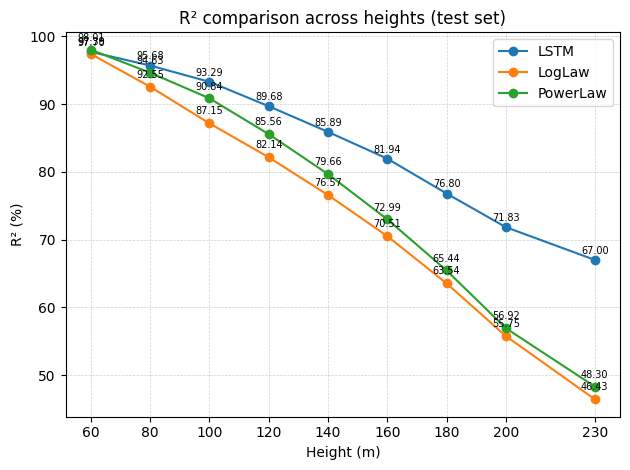

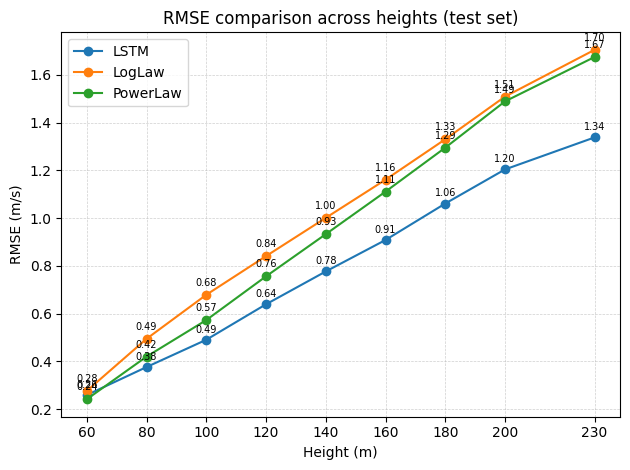

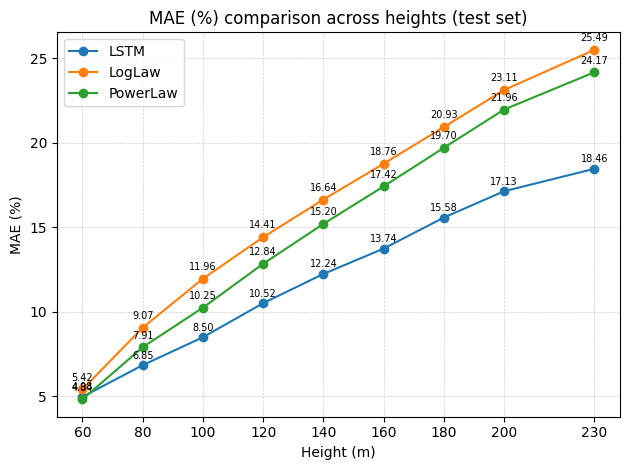


Plotting vertical wind profiles (Observed, LSTM, Power law, Log law)...


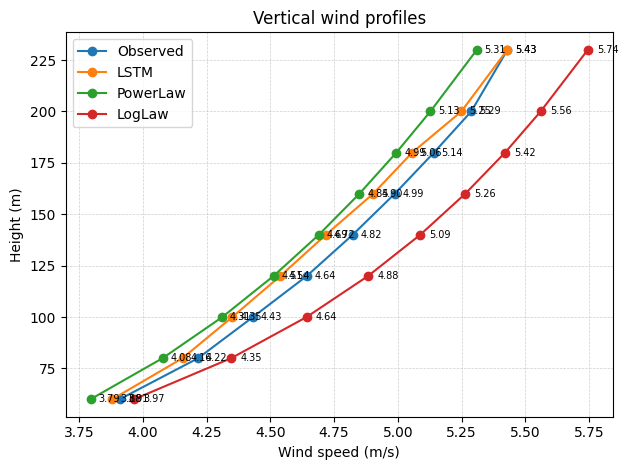

In [55]:
"""
Experiment 1: LSTM wind profile model for 'site 1 data.csv'

Single-run version with baseline models:
- Uses a single TIME_STEPS value.
- Prepares sequences of that temporal memory length.
- Trains a fresh LSTM model (wind profile model).
- Uses a FIXED power-law exponent alpha = 0.25 (as in the paper).
- Fits a log-law profile model (z0) on the training set.
- Evaluates all three models (LSTM, power law, log law) on the same test set.
- Prints a comparison table (metrics per height) to the console.
- Plots:
    * R² (%) vs height
    * RMSE (m/s) vs height
    * MAE (%) vs height
    * Vertical wind profiles (mean): Observed, LSTM, Power law, Log law
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 1 data.csv"     # change path if needed
CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"       # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90            # 90% train, 10% test (time-ordered)
LSTM_UNITS = 30                  # number of LSTM neurons
EPOCHS = 30
BATCH_SIZE = 2
RANDOM_SEED = 42

# single temporal memory (lookback window) to use
TIME_STEPS = 4                   # <-- set your desired time steps here

REF_HEIGHT = 40.0                # reference height for v40m (m)
REF_COL = "v40m"                 # reference speed column

# Fixed power-law exponent from the paper
POWER_LAW_ALPHA = 0.25           # alpha for v(z) = v_ref * (z/z_ref)^alpha


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(model_name, metrics_dict):
    """
    Detailed block printout per height for a given model.
    """
    print(f"\n=== {model_name}: Metrics per height (test set) ===")
    for col, m in metrics_dict.items():
        print(f"\n--- {col} ---")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Console comparison table
# ------------------------------------------------------------

def show_comparison_table(metrics_lstm,
                          metrics_power,
                          metrics_log,
                          mean_obs_per_height):
    """
    Build a comparison table (LSTM vs Power law vs Log law) as a pandas
    DataFrame and print it to the console.

    Columns:
        model       height    MeanObs_ms   R2    MSE_m2s2
        RMSE_ms     MAE_ms    MAE_pct      MAPE_pct
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            mean_obs = mean_obs_per_height.get(h, np.nan)
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (m["mae"] / mean_obs) * 100.0

            rows.append({
                "model":      model_name,
                "height":     h,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "MSE_m2s2":   m["mse"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     m["mae"],
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })

    df_out = pd.DataFrame(rows)

    print("\nComparison table (test set):")
    pd.set_option("display.float_format", lambda x: f"{x:8.4f}")
    print(df_out.to_string(index=False))


# ------------------------------------------------------------
# Utilities for heights & baseline models
# ------------------------------------------------------------

def height_from_column(col_name: str) -> float:
    """
    Extract numeric height from column names like 'v60m', 'v100m', etc.
    Assumes format 'v<height>m'.
    """
    return float(col_name[1:-1])


def fit_power_law_alpha(df: pd.DataFrame,
                        train_indices: np.ndarray,
                        target_cols,
                        ref_height: float = REF_HEIGHT,
                        ref_col: str = REF_COL) -> float:
    """
    (Unused now – kept for reference.)
    Fit a single global power-law exponent alpha using training data:

        v(z) = v_ref * (z / ref_height)**alpha

    Previously used to estimate alpha from data.
    """
    x_vals = []
    y_vals = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            x_vals.append(np.log(z / ref_height))
            y_vals.append(np.log(v_tar / v_ref))

    if len(x_vals) == 0:
        print("Warning: no valid samples for fitting power-law alpha. Using alpha = 0.14.")
        return 0.14

    x_arr = np.asarray(x_vals, dtype=float)
    y_arr = np.asarray(y_vals, dtype=float)

    denom = np.sum(x_arr**2)
    if denom <= 0:
        print("Warning: degenerate fit for power-law alpha. Using alpha = 0.14.")
        return 0.14

    alpha = np.sum(x_arr * y_arr) / denom
    return alpha


def fit_log_law_z0(df: pd.DataFrame,
                   train_indices: np.ndarray,
                   target_cols,
                   ref_height: float = REF_HEIGHT,
                   ref_col: str = REF_COL) -> float:
    """
    Fit a single global roughness length z0 for the log law:

        v(z) = v_ref * ln(z / z0) / ln(ref_height / z0)

    by minimizing squared error on speed ratios over the training set.
    """
    z_list = []
    r_list = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            r = v_tar / v_ref  # measured ratio v(z) / v_ref
            z_list.append(z)
            r_list.append(r)

    if len(z_list) == 0:
        print("Warning: no valid samples for fitting log-law z0. Using z0 = 0.1 m.")
        return 0.1

    z_arr = np.asarray(z_list, dtype=float)
    r_arr = np.asarray(r_list, dtype=float)

    # Search z0 in a reasonable range (log-spaced)
    z0_candidates = np.logspace(-3, 1, 200)  # 0.001 to 10 m
    best_z0 = None
    best_loss = np.inf

    for z0 in z0_candidates:
        if z0 >= ref_height:
            continue

        denom = np.log(ref_height / z0)
        if denom == 0:
            continue

        r_model = np.log(z_arr / z0) / denom
        loss = np.mean((r_arr - r_model)**2)

        if loss < best_loss:
            best_loss = loss
            best_z0 = z0

    if best_z0 is None:
        print("Warning: failed to find good z0. Using z0 = 0.1 m.")
        best_z0 = 0.1

    return best_z0


def predict_power_and_log_profiles(df: pd.DataFrame,
                                   indices: np.ndarray,
                                   target_cols,
                                   alpha: float,
                                   z0: float,
                                   ref_height: float = REF_HEIGHT,
                                   ref_col: str = REF_COL):
    """
    Compute predictions for power-law and log-law models for all test indices.

    Returns:
        y_pred_power  : (n_test, n_heights)
        y_pred_loglaw : (n_test, n_heights)
    """
    n_test = len(indices)
    n_heights = len(target_cols)

    y_pred_power = np.zeros((n_test, n_heights), dtype="float32")
    y_pred_loglaw = np.zeros((n_test, n_heights), dtype="float32")

    denom_log = np.log(ref_height / z0)

    for i, idx in enumerate(indices):
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            # leave predictions as zeros; they will just contribute to error
            continue

        for j, col in enumerate(target_cols):
            z = height_from_column(col)

            # Power law with fixed alpha
            y_pred_power[i, j] = float(v_ref) * (z / ref_height)**alpha

            # Log law
            ratio = np.log(z / z0) / denom_log
            y_pred_loglaw[i, j] = float(v_ref) * ratio

    return y_pred_power, y_pred_loglaw


# ------------------------------------------------------------
# Data loading & preprocessing (Site 1)
# ------------------------------------------------------------

def load_site1_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 1 CSV file.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Replace missing-value flags if present, then interpolate
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        # In case there is a BOM in the first column name
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment1(df: pd.DataFrame, time_steps: int):
    """
    Prepare inputs and outputs for Experiment 1, using a configurable
    temporal window (time_steps) for the LSTM.

    Each training example is:
        X_seq[t]   = [X_scaled[t - time_steps + 1], ..., X_scaled[t]]
        y_seq[t]   = y_scaled[t]

    where t is the index of the *current* time step (the prediction time).
    """

    # Inputs (same as in paper for 40 m level)
    feature_cols = ["Time", "v40m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    X = df[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    # and a target at time t
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    train_indices = indices[train_mask]
    test_indices = indices[test_mask]

    # --- Scaling (fit only on training portion, no leakage) ---
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1: t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols,
            train_indices, test_indices)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Experiment 1).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Plotting comparisons (R2, RMSE, MAE%) & profiles
# ------------------------------------------------------------

def build_comparison_df(metrics_lstm,
                        metrics_power,
                        metrics_log,
                        mean_obs_per_height):
    """
    Build a tidy DataFrame with one row per (model, height),
    including numerical height in meters and MAE as % of mean observed speed.
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            height_m = height_from_column(h)
            mean_obs = mean_obs_per_height.get(h, np.nan)
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (m["mae"] / mean_obs) * 100.0

            rows.append({
                "model":      model_name,
                "height":     h,
                "height_m":   height_m,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     m["mae"],
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })

    df = pd.DataFrame(rows)
    return df


def plot_metric_comparison(df, metric="R2"):
    """
    Plot a line graph comparing LSTM, PowerLaw, LogLaw for a given metric
    across heights.

    metric:
        "R2"       -> plotted as R2 * 100 (%)
        "RMSE"     -> RMSE_ms (m/s)
        "MAE_PCT"  -> MAE_pct (%)
    """
    metric = metric.upper()
    if metric not in ["R2", "RMSE", "MAE_PCT"]:
        raise ValueError("metric must be 'R2', 'RMSE', or 'MAE_PCT'.")

    df_sorted = df.sort_values("height_m")
    heights_vals = df_sorted["height_m"].unique()
    methods = df_sorted["model"].unique()

    plt.figure()

    for method in methods:
        df_m = df_sorted[df_sorted["model"] == method]
        x = df_m["height_m"].to_numpy()

        if metric == "R2":
            y = df_m["R2"].to_numpy() * 100.0
            y_label = "R² (%)"
            title_metric = "R²"
        elif metric == "RMSE":
            y = df_m["RMSE_ms"].to_numpy()
            y_label = "RMSE (m/s)"
            title_metric = "RMSE"
        else:  # "MAE_PCT"
            y = df_m["MAE_pct"].to_numpy()
            y_label = "MAE (%)"
            title_metric = "MAE (%)"

        plt.plot(x, y, marker="o", linewidth=1.5, label=method)

        # Data callouts
        y_valid = y[~np.isnan(y)]
        if len(y_valid) > 0:
            y_min = np.nanmin(y_valid)
            y_max = np.nanmax(y_valid)
            y_range = y_max - y_min if y_max > y_min else 1.0
            offset = 0.02 * y_range
        else:
            offset = 0.0

        for xi, yi in zip(x, y):
            if np.isnan(yi):
                continue
            plt.text(
                xi,
                yi + offset,
                f"{yi:.2f}",
                ha="center",
                va="bottom",
                fontsize=7
            )

    plt.xlabel("Height (m)")
    plt.ylabel(y_label)
    plt.title(f"{title_metric} comparison across heights (test set)")
    plt.xticks(heights_vals, [f"{int(h)}" for h in heights_vals])
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_vertical_profiles(target_cols, profiles_mean_dict):
    """
    Plot vertical wind profiles for:
    - Observed (full dataset mean)
    - LSTM (test-set mean)
    - PowerLaw (test-set mean)
    - LogLaw (test-set mean)
    """
    heights_m = np.array([height_from_column(c) for c in target_cols], dtype=float)

    plt.figure()

    for label, prof in profiles_mean_dict.items():
        plt.plot(prof, heights_m, marker="o", linewidth=1.5, label=label)

        # Data callouts
        prof = np.asarray(prof)
        valid = prof[~np.isnan(prof)]
        if len(valid) > 0:
            x_min = np.nanmin(valid)
            x_max = np.nanmax(valid)
            x_range = x_max - x_min if x_max > x_min else 1.0
            offset = 0.02 * x_range
        else:
            offset = 0.0

        for v, z in zip(prof, heights_m):
            if np.isnan(v):
                continue
            plt.text(
                v + offset,
                z,
                f"{v:.2f}",
                va="center",
                fontsize=7
            )

    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Height (m)")
    plt.title("Vertical wind profiles")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Single experiment for the chosen TIME_STEPS
# ------------------------------------------------------------

def run_experiment(df, time_steps: int):
    """
    Run the full pipeline (prepare -> train -> evaluate)
    for the specified time_steps value.

    Returns:
        metrics_lstm, metrics_power, metrics_log,
        mean_obs_per_height_full, target_cols, profiles_mean_dict
    """

    # New TF "session"-like state and deterministic seeds
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols,
     train_indices, test_indices) = prepare_experiment1(df, time_steps=time_steps)

    print("  X_train shape:", X_train.shape)  # (n_train_seq, time_steps, n_features)
    print("  y_train shape:", y_train_scaled.shape)

    # --- Power-law exponent (FIXED, from the paper) ---
    alpha = POWER_LAW_ALPHA
    print(f"  Power-law alpha (fixed): {alpha:.4f} (from paper)")

    # --- Fit log-law z0 on training portion ---
    z0 = fit_log_law_z0(df, train_indices, target_cols)
    print(f"  Log-law z0   (global): {z0:.4f} m")

    # --- Build and train LSTM ---
    input_shape = X_train.shape[1:]       # (time_steps, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    print("  Building LSTM model...")
    model = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("  Training LSTM...")
    history = model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate (scaled space)
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  LSTM test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  LSTM test MAE  (scaled):      {test_mae:.4f}")

    # Predictions back in original physical units (m/s)
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred_lstm = y_scaler.inverse_transform(y_pred_scaled)

    # --- Baseline predictions on same test indices ---
    y_pred_power, y_pred_log = predict_power_and_log_profiles(
        df, test_indices, target_cols, alpha, z0
    )

    # Metrics per height (R², MSE, RMSE, MAE, MAPE) on test set
    metrics_lstm  = compute_height_metrics(y_test_orig, y_pred_lstm,  target_cols)
    metrics_power = compute_height_metrics(y_test_orig, y_pred_power, target_cols)
    metrics_log   = compute_height_metrics(y_test_orig, y_pred_log,   target_cols)

    # Mean observed wind speed at each height (over the full dataset, like a climatological profile)
    mean_obs_per_height_full = {
        col: float(df[col].mean()) for col in target_cols
    }

    # Vertical profiles:
    # - Observed: full-dataset mean
    # - Models:   test-set mean
    mean_obs_full   = np.array([df[col].mean() for col in target_cols])
    mean_lstm_test  = np.mean(y_pred_lstm, axis=0)
    mean_power_test = np.mean(y_pred_power, axis=0)
    mean_log_test   = np.mean(y_pred_log, axis=0)

    profiles_mean_dict = {
        "Observed":  mean_obs_full,
        "LSTM":      mean_lstm_test,
        "PowerLaw":  mean_power_test,
        "LogLaw":    mean_log_test,
    }

    return (metrics_lstm,
            metrics_power,
            metrics_log,
            mean_obs_per_height_full,
            target_cols,
            profiles_mean_dict)


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():
    print("Loading Site 1 data...")
    df = load_site1_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning: {df.shape}")

    if len(df) == 0:
        raise ValueError("Site 1 dataframe is empty after cleaning. "
                         "Check CSV_PATH, separator, and column names.")

    print(f"\n=== Running experiment for TIME_STEPS = {TIME_STEPS} ===")
    (metrics_lstm,
     metrics_power,
     metrics_log,
     mean_obs_per_height,
     target_cols,
     profiles_mean_dict) = run_experiment(df, time_steps=TIME_STEPS)

    # Optional: detailed per-height metrics for each model
    print_height_metrics("LSTM",     metrics_lstm)
    print_height_metrics("PowerLaw", metrics_power)
    print_height_metrics("LogLaw",   metrics_log)

    # Console comparison table
    show_comparison_table(metrics_lstm,
                          metrics_power,
                          metrics_log,
                          mean_obs_per_height)

    # Build tidy comparison DataFrame for plots
    comparison_df = build_comparison_df(
        metrics_lstm, metrics_power, metrics_log, mean_obs_per_height
    )

    # Plots: R² (%), RMSE (m/s), MAE (%) vs height
    print("\nPlotting comparison line graphs (R², RMSE, MAE%) across heights...")
    plot_metric_comparison(comparison_df, metric="R2")
    plot_metric_comparison(comparison_df, metric="RMSE")
    plot_metric_comparison(comparison_df, metric="MAE_PCT")

    # Vertical wind profile plot
    print("\nPlotting vertical wind profiles (Observed, LSTM, Power law, Log law)...")
    plot_vertical_profiles(target_cols, profiles_mean_dict)


if __name__ == "__main__":
    main()


### Final version of site 1

Loading Site 1 data...
Data shape after cleaning: (17744, 18)

=== Running experiment for TIME_STEPS = 4 ===
  X_train shape: (15966, 4, 4)
  y_train shape: (15966, 9)
  Power-law alpha (fixed): 0.2500 (from paper)
  Log-law z0   (global): 3.0018 m
  Building LSTM model...
  Training LSTM...
  LSTM test loss (MSE, scaled): 0.1606
  LSTM test MAE  (scaled):      0.2844

=== LSTM – Site 1: Metrics per height (test set) ===

--- v60m ---
R²   :      0.978
MSE  :     0.0655 (m²/s²)
RMSE :     0.2559 (m/s)
MAE  :     0.1958 (m/s)
MAPE :       7.53 (%)

--- v80m ---
R²   :      0.957
MSE  :     0.1413 (m²/s²)
RMSE :     0.3759 (m/s)
MAE  :     0.2911 (m/s)
MAPE :       9.77 (%)

--- v100m ---
R²   :      0.934
MSE  :     0.2365 (m²/s²)
RMSE :     0.4863 (m/s)
MAE  :     0.3776 (m/s)
MAPE :      11.72 (%)

--- v120m ---
R²   :      0.899
MSE  :     0.3982 (m²/s²)
RMSE :     0.6311 (m/s)
MAE  :     0.4843 (m/s)
MAPE :      13.95 (%)

--- v140m ---
R²   :      0.861
MSE  :     0.5964 (m²/s²)
RM

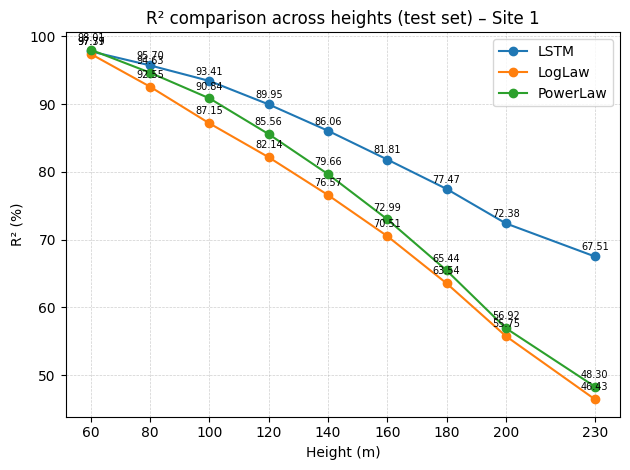

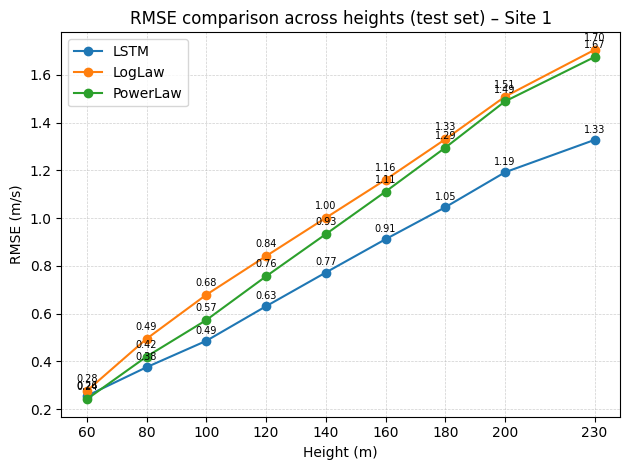

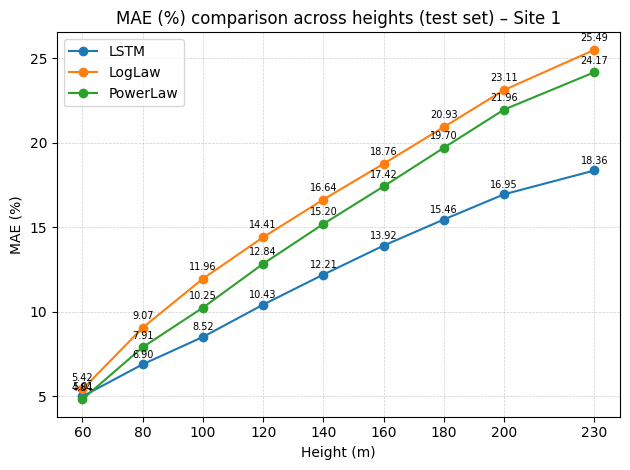


Plotting vertical wind profiles (Observed, LSTM, Power law, Log law)...


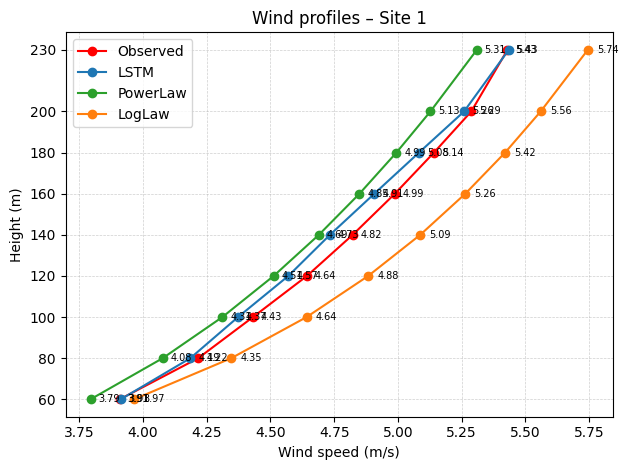

In [10]:
"""
Experiment 1: LSTM wind profile model for 'site 1 data.csv'

Single-run version with baseline models:
- Uses a single TIME_STEPS value.
- Prepares sequences of that temporal memory length.
- Trains a fresh LSTM model (wind profile model).
- Uses a FIXED power-law exponent alpha = 0.25 (as in the paper).
- Fits a log-law profile model (z0) on the training set.
- Evaluates all three models (LSTM, power law, log law) on the same test set.
- Prints a comparison table (metrics per height) to the console.
- Plots:
    * R² (%) vs height
    * RMSE (m/s) vs height
    * MAE (%) vs height
    * Vertical wind profiles (mean): Observed, LSTM, Power law, Log law

Color convention:
    Observed -> red
    LSTM     -> blue
    PowerLaw -> green
    LogLaw   -> orange
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 1 data.csv"     # change path if needed
CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"       # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90            # 90% train, 10% test (time-ordered)
LSTM_UNITS = 30                  # number of LSTM neurons
EPOCHS = 30
BATCH_SIZE = 2
RANDOM_SEED = 42

# single temporal memory (lookback window) to use
TIME_STEPS = 4                   # <-- set your desired time steps here

REF_HEIGHT = 40.0                # reference height for v40m (m)
REF_COL = "v40m"                 # reference speed column

# Fixed power-law exponent from the paper
POWER_LAW_ALPHA = 0.25           # alpha for v(z) = v_ref * (z/z_ref)^alpha


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(model_name, metrics_dict):
    """
    Detailed block printout per height for a given model.
    """
    print(f"\n=== {model_name}: Metrics per height (test set) ===")
    for col, m in metrics_dict.items():
        print(f"\n--- {col} ---")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Console comparison table
# ------------------------------------------------------------

def show_comparison_table(metrics_lstm,
                          metrics_power,
                          metrics_log,
                          mean_obs_per_height):
    """
    Build a comparison table (LSTM vs Power law vs Log law) as a pandas
    DataFrame and print it to the console.

    Columns:
        model       height    MeanObs_ms   R2    MSE_m2s2
        RMSE_ms     MAE_ms    MAE_pct      MAPE_pct
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            mean_obs = mean_obs_per_height.get(h, np.nan)
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (m["mae"] / mean_obs) * 100.0

            rows.append({
                "model":      model_name,
                "height":     h,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "MSE_m2s2":   m["mse"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     m["mae"],
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })

    df_out = pd.DataFrame(rows)

    print("\nComparison table (test set):")
    pd.set_option("display.float_format", lambda x: f"{x:8.4f}")
    print(df_out.to_string(index=False))


# ------------------------------------------------------------
# Utilities for heights & baseline models
# ------------------------------------------------------------

def height_from_column(col_name: str) -> float:
    """
    Extract numeric height from column names like 'v60m', 'v100m', etc.
    Assumes format 'v<height>m'.
    """
    return float(col_name[1:-1])


def fit_power_law_alpha(df: pd.DataFrame,
                        train_indices: np.ndarray,
                        target_cols,
                        ref_height: float = REF_HEIGHT,
                        ref_col: str = REF_COL) -> float:
    """
    (Unused now – kept for reference.)
    Fit a single global power-law exponent alpha using training data:

        v(z) = v_ref * (z / ref_height)**alpha
    """
    x_vals = []
    y_vals = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            x_vals.append(np.log(z / ref_height))
            y_vals.append(np.log(v_tar / v_ref))

    if len(x_vals) == 0:
        print("Warning: no valid samples for fitting power-law alpha. Using alpha = 0.14.")
        return 0.14

    x_arr = np.asarray(x_vals, dtype=float)
    y_arr = np.asarray(y_vals, dtype=float)

    denom = np.sum(x_arr**2)
    if denom <= 0:
        print("Warning: degenerate fit for power-law alpha. Using alpha = 0.14.")
        return 0.14

    alpha = np.sum(x_arr * y_arr) / denom
    return alpha


def fit_log_law_z0(df: pd.DataFrame,
                   train_indices: np.ndarray,
                   target_cols,
                   ref_height: float = REF_HEIGHT,
                   ref_col: str = REF_COL) -> float:
    """
    Fit a single global roughness length z0 for the log law:

        v(z) = v_ref * ln(z / z0) / ln(ref_height / z0)
    """
    z_list = []
    r_list = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            r = v_tar / v_ref  # measured ratio v(z) / v_ref
            z_list.append(z)
            r_list.append(r)

    if len(z_list) == 0:
        print("Warning: no valid samples for fitting log-law z0. Using z0 = 0.1 m.")
        return 0.1

    z_arr = np.asarray(z_list, dtype=float)
    r_arr = np.asarray(r_list, dtype=float)

    # Search z0 in a reasonable range (log-spaced)
    z0_candidates = np.logspace(-3, 1, 200)  # 0.001 to 10 m
    best_z0 = None
    best_loss = np.inf

    for z0 in z0_candidates:
        if z0 >= ref_height:
            continue

        denom = np.log(ref_height / z0)
        if denom == 0:
            continue

        r_model = np.log(z_arr / z0) / denom
        loss = np.mean((r_arr - r_model)**2)

        if loss < best_loss:
            best_loss = loss
            best_z0 = z0

    if best_z0 is None:
        print("Warning: failed to find good z0. Using z0 = 0.1 m.")
        best_z0 = 0.1

    return best_z0


def predict_power_and_log_profiles(df: pd.DataFrame,
                                   indices: np.ndarray,
                                   target_cols,
                                   alpha: float,
                                   z0: float,
                                   ref_height: float = REF_HEIGHT,
                                   ref_col: str = REF_COL):
    """
    Compute predictions for power-law and log-law models for all test indices.

    Returns:
        y_pred_power  : (n_test, n_heights)
        y_pred_loglaw : (n_test, n_heights)
    """
    n_test = len(indices)
    n_heights = len(target_cols)

    y_pred_power = np.zeros((n_test, n_heights), dtype="float32")
    y_pred_loglaw = np.zeros((n_test, n_heights), dtype="float32")

    denom_log = np.log(ref_height / z0)

    for i, idx in enumerate(indices):
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            # leave predictions as zeros; they will just contribute to error
            continue

        for j, col in enumerate(target_cols):
            z = height_from_column(col)

            # Power law with fixed alpha
            y_pred_power[i, j] = float(v_ref) * (z / ref_height)**alpha

            # Log law
            ratio = np.log(z / z0) / denom_log
            y_pred_loglaw[i, j] = float(v_ref) * ratio

    return y_pred_power, y_pred_loglaw


# ------------------------------------------------------------
# Data loading & preprocessing (Site 1)
# ------------------------------------------------------------

def load_site1_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 1 CSV file.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Replace missing-value flags if present, then interpolate
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        # In case there is a BOM in the first column name
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment1(df: pd.DataFrame, time_steps: int):
    """
    Prepare inputs and outputs for Experiment 1, using a configurable
    temporal window (time_steps) for the LSTM.
    """

    # Inputs (same as in paper for 40 m level)
    feature_cols = ["Time", "v40m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    X = df[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    train_indices = indices[train_mask]
    test_indices = indices[test_mask]

    # --- Scaling (fit only on training portion, no leakage) ---
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1: t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols,
            train_indices, test_indices)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Experiment 1).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Plotting comparisons (R2, RMSE, MAE%) & profiles
# ------------------------------------------------------------

def build_comparison_df(metrics_lstm,
                        metrics_power,
                        metrics_log,
                        mean_obs_per_height):
    """
    Build a tidy DataFrame with one row per (model, height),
    including numerical height in meters and MAE as % of mean observed speed.
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            height_m = height_from_column(h)
            mean_obs = mean_obs_per_height.get(h, np.nan)
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (m["mae"] / mean_obs) * 100.0

            rows.append({
                "model":      model_name,
                "height":     h,
                "height_m":   height_m,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     m["mae"],
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })

    df = pd.DataFrame(rows)
    return df


def plot_metric_comparison(df, metric="R2"):
    """
    Plot a line graph comparing LSTM, PowerLaw, LogLaw for a given metric
    across heights.

    Colors:
        LSTM     -> blue
        PowerLaw -> green
        LogLaw   -> orange

    metric:
        "R2"       -> plotted as R2 * 100 (%)
        "RMSE"     -> RMSE_ms (m/s)
        "MAE_PCT"  -> MAE_pct (%)
    """
    metric = metric.upper()
    if metric not in ["R2", "RMSE", "MAE_PCT"]:
        raise ValueError("metric must be 'R2', 'RMSE', or 'MAE_PCT'.")

    df_sorted = df.sort_values("height_m")
    heights_vals = df_sorted["height_m"].unique()
    methods = df_sorted["model"].unique()

    color_map = {
        "LSTM": "C0",      # blue
        "PowerLaw": "C2",  # green
        "LogLaw": "C1",    # orange
    }

    plt.figure()

    for method in methods:
        df_m = df_sorted[df_sorted["model"] == method]
        x = df_m["height_m"].to_numpy()

        if metric == "R2":
            y = df_m["R2"].to_numpy() * 100.0
            y_label = "R² (%)"
            title_metric = "R²"
        elif metric == "RMSE":
            y = df_m["RMSE_ms"].to_numpy()
            y_label = "RMSE (m/s)"
            title_metric = "RMSE"
        else:  # "MAE_PCT"
            y = df_m["MAE_pct"].to_numpy()
            y_label = "MAE (%)"
            title_metric = "MAE (%)"

        plt.plot(
            x, y, marker="o", linewidth=1.5,
            label=method, color=color_map.get(method, None)
        )

        # Data callouts
        y_valid = y[~np.isnan(y)]
        if len(y_valid) > 0:
            y_min = np.nanmin(y_valid)
            y_max = np.nanmax(y_valid)
            y_range = y_max - y_min if y_max > y_min else 1.0
            offset = 0.02 * y_range
        else:
            offset = 0.0

        for xi, yi in zip(x, y):
            if np.isnan(yi):
                continue
            plt.text(
                xi,
                yi + offset,
                f"{yi:.2f}",
                ha="center",
                va="bottom",
                fontsize=7
            )

    plt.xlabel("Height (m)")
    plt.ylabel(y_label)
    plt.title(f"{title_metric} comparison across heights (test set) – Site 1")
    plt.xticks(heights_vals, [f"{int(h)}" for h in heights_vals])
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_vertical_profiles(target_cols, profiles_mean_dict):
    """
    Plot vertical wind profiles for:
    - Observed (full dataset mean)
    - LSTM (test-set mean)
    - PowerLaw (test-set mean)
    - LogLaw (test-set mean)

    Colors:
        Observed -> red
        LSTM     -> blue
        PowerLaw -> green
        LogLaw   -> orange
    """
    heights_m = np.array([height_from_column(c) for c in target_cols], dtype=float)

    color_map = {
        "Observed": "r",
        "LSTM": "C0",
        "PowerLaw": "C2",
        "LogLaw": "C1",
    }

    plt.figure()

    for label, prof in profiles_mean_dict.items():
        prof = np.asarray(prof, dtype=float)
        plt.plot(
            prof, heights_m, marker="o", linewidth=1.5,
            label=label, color=color_map.get(label, None)
        )

        # Data callouts
        valid = prof[~np.isnan(prof)]
        if len(valid) > 0:
            x_min = np.nanmin(valid)
            x_max = np.nanmax(valid)
            x_range = x_max - x_min if x_max > x_min else 1.0
            offset = 0.02 * x_range
        else:
            offset = 0.0

        for v, z in zip(prof, heights_m):
            if np.isnan(v):
                continue
            plt.text(
                v + offset,
                z,
                f"{v:.2f}",
                va="center",
                fontsize=7
            )

    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Height (m)")
    plt.yticks(heights_m, [f"{int(h)}" for h in heights_m])  # grid aligned to heights
    plt.title("Wind profiles – Site 1")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Single experiment for the chosen TIME_STEPS
# ------------------------------------------------------------

def run_experiment(df, time_steps: int):
    """
    Run the full pipeline (prepare -> train -> evaluate)
    for the specified time_steps value.

    Returns:
        metrics_lstm, metrics_power, metrics_log,
        mean_obs_per_height_full, target_cols, profiles_mean_dict
    """

    # New TF "session"-like state and deterministic seeds
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols,
     train_indices, test_indices) = prepare_experiment1(df, time_steps=time_steps)

    print("  X_train shape:", X_train.shape)  # (n_train_seq, time_steps, n_features)
    print("  y_train shape:", y_train_scaled.shape)

    # --- Power-law exponent (FIXED, from the paper) ---
    alpha = POWER_LAW_ALPHA
    print(f"  Power-law alpha (fixed): {alpha:.4f} (from paper)")

    # --- Fit log-law z0 on training portion ---
    z0 = fit_log_law_z0(df, train_indices, target_cols)
    print(f"  Log-law z0   (global): {z0:.4f} m")

    # --- Build and train LSTM ---
    input_shape = X_train.shape[1:]       # (time_steps, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    print("  Building LSTM model...")
    model = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("  Training LSTM...")
    history = model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate (scaled space)
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  LSTM test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  LSTM test MAE  (scaled):      {test_mae:.4f}")

    # Predictions back in original physical units (m/s)
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred_lstm = y_scaler.inverse_transform(y_pred_scaled)

    # --- Baseline predictions on same test indices ---
    y_pred_power, y_pred_log = predict_power_and_log_profiles(
        df, test_indices, target_cols, alpha, z0
    )

    # Metrics per height (R², MSE, RMSE, MAE, MAPE) on test set
    metrics_lstm  = compute_height_metrics(y_test_orig, y_pred_lstm,  target_cols)
    metrics_power = compute_height_metrics(y_test_orig, y_pred_power, target_cols)
    metrics_log   = compute_height_metrics(y_test_orig, y_pred_log,   target_cols)

    # Mean observed wind speed at each height (over the full dataset)
    mean_obs_per_height_full = {
        col: float(df[col].mean()) for col in target_cols
    }

    # Vertical profiles:
    # - Observed: full-dataset mean
    # - Models:   test-set mean
    mean_obs_full   = np.array([df[col].mean() for col in target_cols])
    mean_lstm_test  = np.mean(y_pred_lstm, axis=0)
    mean_power_test = np.mean(y_pred_power, axis=0)
    mean_log_test   = np.mean(y_pred_log, axis=0)

    profiles_mean_dict = {
        "Observed":  mean_obs_full,
        "LSTM":      mean_lstm_test,
        "PowerLaw":  mean_power_test,
        "LogLaw":    mean_log_test,
    }

    return (metrics_lstm,
            metrics_power,
            metrics_log,
            mean_obs_per_height_full,
            target_cols,
            profiles_mean_dict)


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():
    print("Loading Site 1 data...")
    df = load_site1_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning: {df.shape}")

    if len(df) == 0:
        raise ValueError("Site 1 dataframe is empty after cleaning. "
                         "Check CSV_PATH, separator, and column names.")

    print(f"\n=== Running experiment for TIME_STEPS = {TIME_STEPS} ===")
    (metrics_lstm,
     metrics_power,
     metrics_log,
     mean_obs_per_height,
     target_cols,
     profiles_mean_dict) = run_experiment(df, time_steps=TIME_STEPS)

    # Detailed per-height metrics for each model
    print_height_metrics("LSTM – Site 1",     metrics_lstm)
    print_height_metrics("PowerLaw – Site 1", metrics_power)
    print_height_metrics("LogLaw – Site 1",   metrics_log)

    # Console comparison table
    show_comparison_table(metrics_lstm,
                          metrics_power,
                          metrics_log,
                          mean_obs_per_height)

    # Build tidy comparison DataFrame for plots
    comparison_df = build_comparison_df(
        metrics_lstm, metrics_power, metrics_log, mean_obs_per_height
    )

    # Plots: R² (%), RMSE (m/s), MAE (%) vs height
    print("\nPlotting comparison line graphs (R², RMSE, MAE%) across heights...")
    plot_metric_comparison(comparison_df, metric="R2")
    plot_metric_comparison(comparison_df, metric="RMSE")
    plot_metric_comparison(comparison_df, metric="MAE_PCT")

    # Vertical wind profile plot
    print("\nPlotting vertical wind profiles (Observed, LSTM, Power law, Log law)...")
    plot_vertical_profiles(target_cols, profiles_mean_dict)


if __name__ == "__main__":
    main()


Loading Site 1 data...
Data shape after cleaning: (17744, 18)

=== Running experiment for TIME_STEPS = 4 ===
  X_train shape: (15966, 4, 4)
  y_train shape: (15966, 9)
  Power-law alpha (fixed): 0.2500 (from paper)
  Log-law z0   (global): 3.0018 m
  Building LSTM model...
  Training LSTM...
  LSTM test loss (MSE, scaled): 0.1590
  LSTM test MAE  (scaled):      0.2843

Wind velocity vertical profiles (test-set mean):
 height_m   Obs_ms  LSTM_ms  Power_ms   Log_ms
     60.0 3.862052 3.888160  3.794692 3.965760
     80.0 4.157007 4.161083  4.077665 4.346675
    100.0 4.382385 4.363005  4.311613 4.642139
    120.0 4.648050 4.557916  4.512676 4.883537
    140.0 4.886641 4.734213  4.689984 5.087641
    160.0 5.118358 4.929104  4.849191 5.264454
    180.0 5.335237 5.103530  4.994105 5.420405
    200.0 5.551593 5.289625  5.127399 5.559915
    230.0 5.745813 5.465706  5.309718 5.744966

=== LSTM – Site 1: Metrics per height (test set) ===

--- v60m ---
R²   :      0.974
MSE  :     0.0774 (m²/s

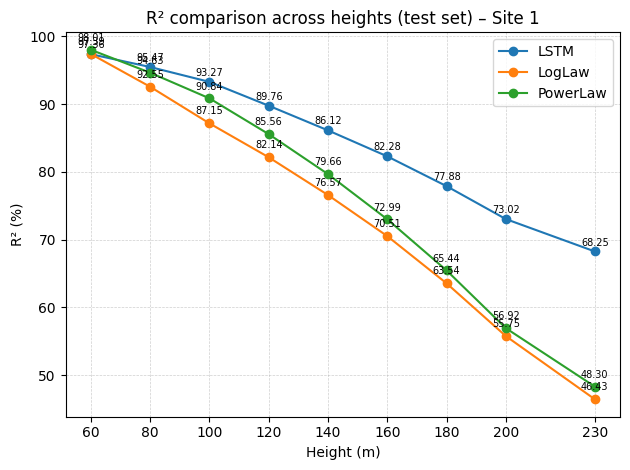

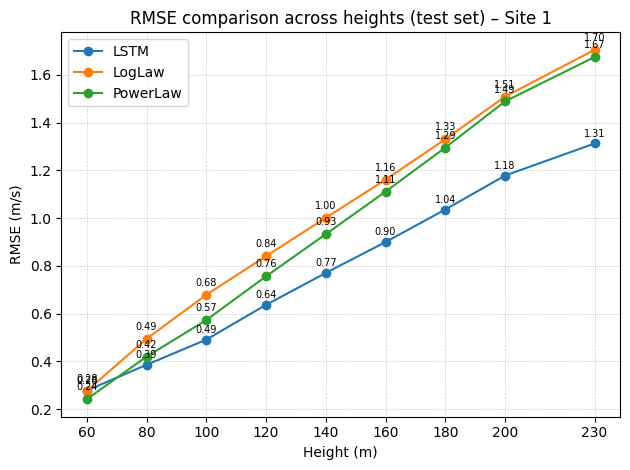

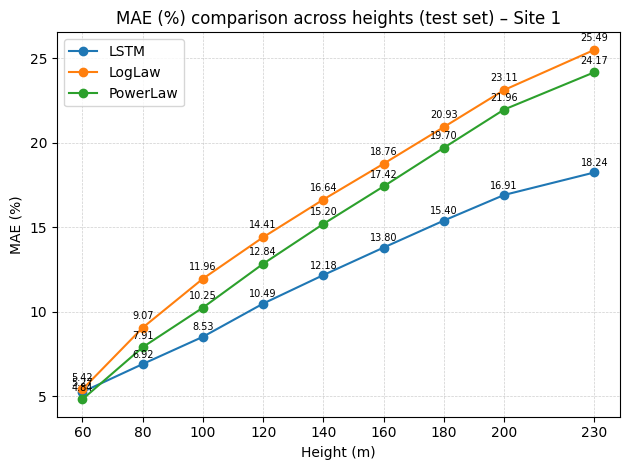


Plotting vertical wind profiles (Observed, LSTM, Power law, Log law)...


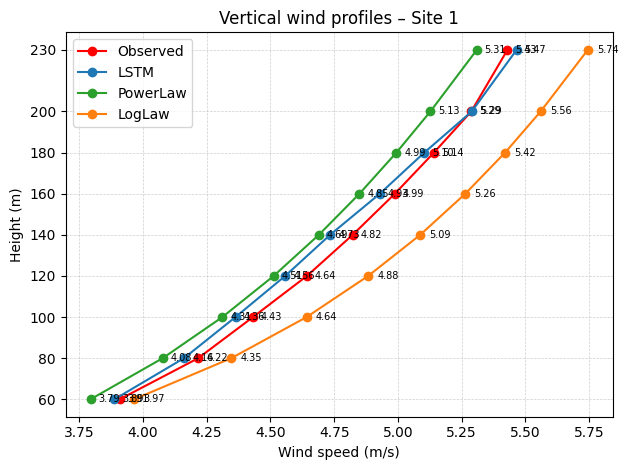

In [2]:
"""
Experiment 1: LSTM wind profile model for 'site 1 data.csv'

Single-run version with baseline models:
- Uses a single TIME_STEPS value.
- Prepares sequences of that temporal memory length.
- Trains a fresh LSTM model (wind profile model).
- Uses a FIXED power-law exponent alpha = 0.25 (as in the paper).
- Fits a log-law profile model (z0) on the training set.
- Evaluates all three models (LSTM, power law, log law) on the same test set.
- Prints a comparison table (metrics per height) to the console.
- Prints a wind velocity vertical profile table (mean test-set speeds).
- Plots:
    * R² (%) vs height
    * RMSE (m/s) vs height
    * MAE (%) vs height
    * Vertical wind profiles (mean): Observed, LSTM, Power law, Log law

Color convention:
    Observed -> red
    LSTM     -> blue
    PowerLaw -> green
    LogLaw   -> orange
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 1 data.csv"     # change path if needed
CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"       # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90            # 90% train, 10% test (time-ordered)
LSTM_UNITS = 30                  # number of LSTM neurons
EPOCHS = 30
BATCH_SIZE = 2
RANDOM_SEED = 42

# single temporal memory (lookback window) to use
TIME_STEPS = 4                   # <-- set your desired time steps here

REF_HEIGHT = 40.0                # reference height for v40m (m)
REF_COL = "v40m"                 # reference speed column

# Fixed power-law exponent from the paper
POWER_LAW_ALPHA = 0.25           # alpha for v(z) = v_ref * (z/z_ref)^alpha


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(model_name, metrics_dict):
    """
    Detailed block printout per height for a given model.
    """
    print(f"\n=== {model_name}: Metrics per height (test set) ===")
    for col, m in metrics_dict.items():
        print(f"\n--- {col} ---")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Console comparison table
# ------------------------------------------------------------

def show_comparison_table(metrics_lstm,
                          metrics_power,
                          metrics_log,
                          mean_obs_per_height):
    """
    Build a comparison table (LSTM vs Power law vs Log law) as a pandas
    DataFrame and print it to the console.

    Columns:
        model       height    MeanObs_ms   R2    MSE_m2s2
        RMSE_ms     MAE_ms    MAE_pct      MAPE_pct
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            mean_obs = mean_obs_per_height.get(h, np.nan)
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (m["mae"] / mean_obs) * 100.0

            rows.append({
                "model":      model_name,
                "height":     h,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "MSE_m2s2":   m["mse"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     m["mae"],
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })

    df_out = pd.DataFrame(rows)

    print("\nComparison table (test set):")
    pd.set_option("display.float_format", lambda x: f"{x:8.4f}")
    print(df_out.to_string(index=False))


# ------------------------------------------------------------
# Console vertical wind profile table
# ------------------------------------------------------------

def show_profile_table(y_true, y_lstm, y_power, y_log, target_cols):
    """
    Print a table of mean wind speeds per height over the TEST set:

    Columns:
        height_m   Obs_ms   LSTM_ms   Power_ms   Log_ms
    """
    y_true = np.asarray(y_true)
    y_lstm = np.asarray(y_lstm)
    y_power = np.asarray(y_power)
    y_log = np.asarray(y_log)

    mean_obs = np.mean(y_true, axis=0)
    mean_lstm = np.mean(y_lstm, axis=0)
    mean_power = np.mean(y_power, axis=0)
    mean_log = np.mean(y_log, axis=0)

    rows = []
    for j, col in enumerate(target_cols):
        height_m = height_from_column(col)
        rows.append({
            "height_m": float(height_m),
            "Obs_ms":   float(mean_obs[j]),
            "LSTM_ms":  float(mean_lstm[j]),
            "Power_ms": float(mean_power[j]),
            "Log_ms":   float(mean_log[j]),
        })

    df_prof = pd.DataFrame(rows).sort_values("height_m")

    print("\nWind velocity vertical profiles (test-set mean):")
    print(df_prof.to_string(index=False))


# ------------------------------------------------------------
# Utilities for heights & baseline models
# ------------------------------------------------------------

def height_from_column(col_name: str) -> float:
    """
    Extract numeric height from column names like 'v60m', 'v100m', etc.
    Assumes format 'v<height>m'.
    """
    return float(col_name[1:-1])


def fit_power_law_alpha(df: pd.DataFrame,
                        train_indices: np.ndarray,
                        target_cols,
                        ref_height: float = REF_HEIGHT,
                        ref_col: str = REF_COL) -> float:
    """
    (Unused now – kept for reference.)
    Fit a single global power-law exponent alpha using training data:

        v(z) = v_ref * (z / ref_height)**alpha
    """
    x_vals = []
    y_vals = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            x_vals.append(np.log(z / ref_height))
            y_vals.append(np.log(v_tar / v_ref))

    if len(x_vals) == 0:
        print("Warning: no valid samples for fitting power-law alpha. Using alpha = 0.14.")
        return 0.14

    x_arr = np.asarray(x_vals, dtype=float)
    y_arr = np.asarray(y_vals, dtype=float)

    denom = np.sum(x_arr**2)
    if denom <= 0:
        print("Warning: degenerate fit for power-law alpha. Using alpha = 0.14.")
        return 0.14

    alpha = np.sum(x_arr * y_arr) / denom
    return alpha


def fit_log_law_z0(df: pd.DataFrame,
                   train_indices: np.ndarray,
                   target_cols,
                   ref_height: float = REF_HEIGHT,
                   ref_col: str = REF_COL) -> float:
    """
    Fit a single global roughness length z0 for the log law:

        v(z) = v_ref * ln(z / z0) / ln(ref_height / z0)
    """
    z_list = []
    r_list = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            r = v_tar / v_ref  # measured ratio v(z) / v_ref
            z_list.append(z)
            r_list.append(r)

    if len(z_list) == 0:
        print("Warning: no valid samples for fitting log-law z0. Using z0 = 0.1 m.")
        return 0.1

    z_arr = np.asarray(z_list, dtype=float)
    r_arr = np.asarray(r_list, dtype=float)

    # Search z0 in a reasonable range (log-spaced)
    z0_candidates = np.logspace(-3, 1, 200)  # 0.001 to 10 m
    best_z0 = None
    best_loss = np.inf

    for z0 in z0_candidates:
        if z0 >= ref_height:
            continue

        denom = np.log(ref_height / z0)
        if denom == 0:
            continue

        r_model = np.log(z_arr / z0) / denom
        loss = np.mean((r_arr - r_model)**2)

        if loss < best_loss:
            best_loss = loss
            best_z0 = z0

    if best_z0 is None:
        print("Warning: failed to find good z0. Using z0 = 0.1 m.")
        best_z0 = 0.1

    return best_z0


def predict_power_and_log_profiles(df: pd.DataFrame,
                                   indices: np.ndarray,
                                   target_cols,
                                   alpha: float,
                                   z0: float,
                                   ref_height: float = REF_HEIGHT,
                                   ref_col: str = REF_COL):
    """
    Compute predictions for power-law and log-law models for all test indices.

    Returns:
        y_pred_power  : (n_test, n_heights)
        y_pred_loglaw : (n_test, n_heights)
    """
    n_test = len(indices)
    n_heights = len(target_cols)

    y_pred_power = np.zeros((n_test, n_heights), dtype="float32")
    y_pred_loglaw = np.zeros((n_test, n_heights), dtype="float32")

    denom_log = np.log(ref_height / z0)

    for i, idx in enumerate(indices):
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            # leave predictions as zeros; they will just contribute to error
            continue

        for j, col in enumerate(target_cols):
            z = height_from_column(col)

            # Power law with fixed alpha
            y_pred_power[i, j] = float(v_ref) * (z / ref_height)**alpha

            # Log law
            ratio = np.log(z / z0) / denom_log
            y_pred_loglaw[i, j] = float(v_ref) * ratio

    return y_pred_power, y_pred_loglaw


# ------------------------------------------------------------
# Data loading & preprocessing (Site 1)
# ------------------------------------------------------------

def load_site1_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 1 CSV file.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Replace missing-value flags if present, then interpolate
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        # In case there is a BOM in the first column name
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment1(df: pd.DataFrame, time_steps: int):
    """
    Prepare inputs and outputs for Experiment 1, using a configurable
    temporal window (time_steps) for the LSTM.
    """

    # Inputs (same as in paper for 40 m level)
    feature_cols = ["Time", "v40m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    X = df[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    train_indices = indices[train_mask]
    test_indices = indices[test_mask]

    # --- Scaling (fit only on training portion, no leakage) ---
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1: t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols,
            train_indices, test_indices)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Experiment 1).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Plotting comparisons (R2, RMSE, MAE%) & profiles
# ------------------------------------------------------------

def build_comparison_df(metrics_lstm,
                        metrics_power,
                        metrics_log,
                        mean_obs_per_height):
    """
    Build a tidy DataFrame with one row per (model, height),
    including numerical height in meters and MAE as % of mean observed speed.
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            height_m = height_from_column(h)
            mean_obs = mean_obs_per_height.get(h, np.nan)
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (m["mae"] / mean_obs) * 100.0

            rows.append({
                "model":      model_name,
                "height":     h,
                "height_m":   height_m,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     m["mae"],
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })

    df = pd.DataFrame(rows)
    return df


def plot_metric_comparison(df, metric="R2"):
    """
    Plot a line graph comparing LSTM, PowerLaw, LogLaw for a given metric
    across heights.

    Colors:
        LSTM     -> blue
        PowerLaw -> green
        LogLaw   -> orange

    metric:
        "R2"       -> plotted as R2 * 100 (%)
        "RMSE"     -> RMSE_ms (m/s)
        "MAE_PCT"  -> MAE_pct (%)
    """
    metric = metric.upper()
    if metric not in ["R2", "RMSE", "MAE_PCT"]:
        raise ValueError("metric must be 'R2', 'RMSE', or 'MAE_PCT'.")

    df_sorted = df.sort_values("height_m")
    heights_vals = df_sorted["height_m"].unique()
    methods = df_sorted["model"].unique()

    color_map = {
        "LSTM": "C0",      # blue
        "PowerLaw": "C2",  # green
        "LogLaw": "C1",    # orange
    }

    plt.figure()

    for method in methods:
        df_m = df_sorted[df_sorted["model"] == method]
        x = df_m["height_m"].to_numpy()

        if metric == "R2":
            y = df_m["R2"].to_numpy() * 100.0
            y_label = "R² (%)"
            title_metric = "R²"
        elif metric == "RMSE":
            y = df_m["RMSE_ms"].to_numpy()
            y_label = "RMSE (m/s)"
            title_metric = "RMSE"
        else:  # "MAE_PCT"
            y = df_m["MAE_pct"].to_numpy()
            y_label = "MAE (%)"
            title_metric = "MAE (%)"

        plt.plot(
            x, y, marker="o", linewidth=1.5,
            label=method, color=color_map.get(method, None)
        )

        # Data callouts
        y_valid = y[~np.isnan(y)]
        if len(y_valid) > 0:
            y_min = np.nanmin(y_valid)
            y_max = np.nanmax(y_valid)
            y_range = y_max - y_min if y_max > y_min else 1.0
            offset = 0.02 * y_range
        else:
            offset = 0.0

        for xi, yi in zip(x, y):
            if np.isnan(yi):
                continue
            plt.text(
                xi,
                yi + offset,
                f"{yi:.2f}",
                ha="center",
                va="bottom",
                fontsize=7
            )

    plt.xlabel("Height (m)")
    plt.ylabel(y_label)
    plt.title(f"{title_metric} comparison across heights (test set) – Site 1")
    plt.xticks(heights_vals, [f"{int(h)}" for h in heights_vals])
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_vertical_profiles(target_cols, profiles_mean_dict):
    """
    Plot vertical wind profiles for:
    - Observed (full dataset mean)
    - LSTM (test-set mean)
    - PowerLaw (test-set mean)
    - LogLaw (test-set mean)

    Colors:
        Observed -> red
        LSTM     -> blue
        PowerLaw -> green
        LogLaw   -> orange
    """
    heights_m = np.array([height_from_column(c) for c in target_cols], dtype=float)

    color_map = {
        "Observed": "r",
        "LSTM": "C0",
        "PowerLaw": "C2",
        "LogLaw": "C1",
    }

    plt.figure()

    for label, prof in profiles_mean_dict.items():
        prof = np.asarray(prof, dtype=float)
        plt.plot(
            prof, heights_m, marker="o", linewidth=1.5,
            label=label, color=color_map.get(label, None)
        )

        # Data callouts
        valid = prof[~np.isnan(prof)]
        if len(valid) > 0:
            x_min = np.nanmin(valid)
            x_max = np.nanmax(valid)
            x_range = x_max - x_min if x_max > x_min else 1.0
            offset = 0.02 * x_range
        else:
            offset = 0.0

        for v, z in zip(prof, heights_m):
            if np.isnan(v):
                continue
            plt.text(
                v + offset,
                z,
                f"{v:.2f}",
                va="center",
                fontsize=7
            )

    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Height (m)")
    plt.yticks(heights_m, [f"{int(h)}" for h in heights_m])  # grid aligned to heights
    plt.title("Vertical wind profiles – Site 1")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Single experiment for the chosen TIME_STEPS
# ------------------------------------------------------------

def run_experiment(df, time_steps: int):
    """
    Run the full pipeline (prepare -> train -> evaluate)
    for the specified time_steps value.

    Returns:
        metrics_lstm, metrics_power, metrics_log,
        mean_obs_per_height_full, target_cols, profiles_mean_dict
    """

    # New TF "session"-like state and deterministic seeds
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols,
     train_indices, test_indices) = prepare_experiment1(df, time_steps=time_steps)

    print("  X_train shape:", X_train.shape)  # (n_train_seq, time_steps, n_features)
    print("  y_train shape:", y_train_scaled.shape)

    # --- Power-law exponent (FIXED, from the paper) ---
    alpha = POWER_LAW_ALPHA
    print(f"  Power-law alpha (fixed): {alpha:.4f} (from paper)")

    # --- Fit log-law z0 on training portion ---
    z0 = fit_log_law_z0(df, train_indices, target_cols)
    print(f"  Log-law z0   (global): {z0:.4f} m")

    # --- Build and train LSTM ---
    input_shape = X_train.shape[1:]       # (time_steps, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    print("  Building LSTM model...")
    model = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("  Training LSTM...")
    history = model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate (scaled space)
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  LSTM test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  LSTM test MAE  (scaled):      {test_mae:.4f}")

    # Predictions back in original physical units (m/s)
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred_lstm = y_scaler.inverse_transform(y_pred_scaled)

    # --- Baseline predictions on same test indices ---
    y_pred_power, y_pred_log = predict_power_and_log_profiles(
        df, test_indices, target_cols, alpha, z0
    )

    # Metrics per height (R², MSE, RMSE, MAE, MAPE) on test set
    metrics_lstm  = compute_height_metrics(y_test_orig, y_pred_lstm,  target_cols)
    metrics_power = compute_height_metrics(y_test_orig, y_pred_power, target_cols)
    metrics_log   = compute_height_metrics(y_test_orig, y_pred_log,   target_cols)

    # ---- Wind velocity profile table (test-set mean) ----
    show_profile_table(y_test_orig, y_pred_lstm, y_pred_power, y_pred_log, target_cols)

    # Mean observed wind speed at each height (over the full dataset)
    mean_obs_per_height_full = {
        col: float(df[col].mean()) for col in target_cols
    }

    # Vertical profiles:
    # - Observed: full-dataset mean
    # - Models:   test-set mean
    mean_obs_full   = np.array([df[col].mean() for col in target_cols])
    mean_lstm_test  = np.mean(y_pred_lstm, axis=0)
    mean_power_test = np.mean(y_pred_power, axis=0)
    mean_log_test   = np.mean(y_pred_log, axis=0)

    profiles_mean_dict = {
        "Observed":  mean_obs_full,
        "LSTM":      mean_lstm_test,
        "PowerLaw":  mean_power_test,
        "LogLaw":    mean_log_test,
    }

    return (metrics_lstm,
            metrics_power,
            metrics_log,
            mean_obs_per_height_full,
            target_cols,
            profiles_mean_dict)


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():
    print("Loading Site 1 data...")
    df = load_site1_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning: {df.shape}")

    if len(df) == 0:
        raise ValueError("Site 1 dataframe is empty after cleaning. "
                         "Check CSV_PATH, separator, and column names.")

    print(f"\n=== Running experiment for TIME_STEPS = {TIME_STEPS} ===")
    (metrics_lstm,
     metrics_power,
     metrics_log,
     mean_obs_per_height,
     target_cols,
     profiles_mean_dict) = run_experiment(df, time_steps=TIME_STEPS)

    # Detailed per-height metrics for each model
    print_height_metrics("LSTM – Site 1",     metrics_lstm)
    print_height_metrics("PowerLaw – Site 1", metrics_power)
    print_height_metrics("LogLaw – Site 1",   metrics_log)

    # Console comparison table
    show_comparison_table(metrics_lstm,
                          metrics_power,
                          metrics_log,
                          mean_obs_per_height)

    # Build tidy comparison DataFrame for plots
    comparison_df = build_comparison_df(
        metrics_lstm, metrics_power, metrics_log, mean_obs_per_height
    )

    # Plots: R² (%), RMSE (m/s), MAE (%) vs height
    print("\nPlotting comparison line graphs (R², RMSE, MAE%) across heights...")
    plot_metric_comparison(comparison_df, metric="R2")
    plot_metric_comparison(comparison_df, metric="RMSE")
    plot_metric_comparison(comparison_df, metric="MAE_PCT")

    # Vertical wind profile plot
    print("\nPlotting vertical wind profiles (Observed, LSTM, Power law, Log law)...")
    plot_vertical_profiles(target_cols, profiles_mean_dict)


if __name__ == "__main__":
    main()


## For Site 2

In [26]:
"""
Experiment 1: LSTM wind profile model for 'site 2 data.csv'

Multi-run version:
- Loops over several TIME_STEPS values.
- For each TIME_STEPS:
    * Prepares sequences of that temporal memory length.
    * Trains a fresh LSTM model.
    * Evaluates on the test set.
    * Prints an Excel-friendly metrics table per height (test set).

Metrics per height (test set):
- R²
- MSE
- RMSE
- MAE
- MAPE
"""

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 2 data.csv"     # change path if needed
CSV_SEP = ";"                    # dataset uses ';' as separator
CSV_ENCODING = "utf-8-sig"       # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90            # 90% train, 10% test (time-ordered)
LSTM_UNITS = 30                  # number of LSTM neurons
EPOCHS = 30
BATCH_SIZE = 2
RANDOM_SEED = 42

# <<< list of temporal memories (lookback windows) to test >>>
TIME_STEPS_LIST = list(range(1, 31))  # 1, 2, ..., 30


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(metrics_dict):
    """
    Optional: detailed block printout per height (human-readable).
    """
    for col, m in metrics_dict.items():
        print(f"\n=== Metrics for {col} (test set) ===")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Excel-friendly console table (no plots)
# ------------------------------------------------------------

def show_height_metrics_table(time_steps, metrics_dict):
    """
    Show metrics as a tab-separated table in the console,
    so it can be copied directly into Excel.

    Columns:
        time_steps    height    R2    MSE_m2s2    RMSE_ms    MAE_ms    MAPE_pct
    """
    heights = list(metrics_dict.keys())

    print(f"\nExcel-friendly metrics table per height (test set), TIME_STEPS = {time_steps}:")
    # Header row (tab-separated)
    print("time_steps\theight\tR2\tMSE_m2s2\tRMSE_ms\tMAE_ms\tMAPE_pct")

    # Data rows (tab-separated)
    for h in heights:
        m = metrics_dict[h]
        print(
            f"{time_steps}\t{h}\t"
            f"{m['r2']:.6f}\t"
            f"{m['mse']:.6f}\t"
            f"{m['rmse']:.6f}\t"
            f"{m['mae']:.6f}\t"
            f"{m['mape']:.6f}"
        )


# ------------------------------------------------------------
# Data loading & preprocessing
# ------------------------------------------------------------

def load_site2_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 2 CSV file.

    Important:
    - Only enforce numeric / no-NaNs on the columns actually used
      (inputs + outputs). Extra columns are ignored.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Replace missing-value flags if present
    df.replace([-9999, -9999.0], np.nan, inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        # In case there is a BOM in the first column name
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Essential columns (inputs + outputs)
    essential_cols = [
        "Time", "v40m", "dir40m", "TKE",
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]
    missing = [c for c in essential_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns in Site 2 CSV: {missing}")

    # Coerce essential columns to numeric; non-convertible -> NaN
    df[essential_cols] = df[essential_cols].apply(
        pd.to_numeric, errors="coerce"
    )

    # Interpolate numeric columns (including essential)
    df.interpolate(method="linear", limit_direction="both", inplace=True)

    # Finally, drop rows with any NaN remaining in essential columns
    df.dropna(subset=essential_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment2(df: pd.DataFrame, time_steps: int):
    """
    Prepare inputs and outputs for Site 2, using a configurable
    temporal window (time_steps) for the LSTM.

    Each training example is:
        X_seq[t]   = [X_scaled[t - time_steps + 1], ..., X_scaled[t]]
        y_seq[t]   = y_scaled[t]

    where t is the index of the *current* time step (the prediction time).
    """

    # Inputs (same as in paper for 40 m level)
    feature_cols = ["Time", "v40m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    # Work with a clean numeric sub-dataframe to be extra safe
    cols_all = feature_cols + target_cols
    df_sub = df[cols_all].copy()
    df_sub = df_sub.apply(pd.to_numeric, errors="coerce")
    df_sub.dropna(inplace=True)
    df_sub.reset_index(drop=True, inplace=True)

    X = df_sub[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df_sub[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df_sub)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    # and a target at time t
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    # --- Scaling (fit only on training portion, no leakage) ---
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1 : t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Experiment 1).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Single run for a given TIME_STEPS (fresh "session")
# ------------------------------------------------------------

def run_single_experiment(df, time_steps: int):
    """
    Run the full pipeline (prepare -> train -> evaluate)
    for a specific time_steps value.
    """

    # New TF "session"-like state and deterministic seeds
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols) = prepare_experiment2(df, time_steps=time_steps)

    print("  X_train shape:", X_train.shape)  # (n_train_seq, time_steps, n_features)
    print("  y_train shape:", y_train_scaled.shape)

    input_shape = X_train.shape[1:]       # (time_steps, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    # Build and train LSTM
    print("  Building LSTM model...")
    model = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("  Training...")
    history = model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate (scaled space)
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  Test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  Test MAE  (scaled):      {test_mae:.4f}")

    # Predictions back in original physical units (m/s)
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    # Metrics per height (R², MSE, RMSE, MAE, MAPE) on test set
    metrics_dict = compute_height_metrics(y_test_orig, y_pred, target_cols)
    return metrics_dict


# ------------------------------------------------------------
# Main: loop over all TIME_STEPS in TIME_STEPS_LIST
# ------------------------------------------------------------

def main():
    print("Loading Site 2 data...")
    df = load_site2_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning: {df.shape}")

    if len(df) == 0:
        raise ValueError("Site 2 dataframe is empty after cleaning. "
                         "Check CSV_PATH, separator, and column names.")

    for ts in TIME_STEPS_LIST:
        print(f"\n=== Running experiment for TIME_STEPS = {ts} ===")
        metrics_dict = run_single_experiment(df, time_steps=ts)

        # Optional: detailed per-height metrics
        print_height_metrics(metrics_dict)

        # Excel-friendly table per height (copy/paste into Excel)
        show_height_metrics_table(ts, metrics_dict)


if __name__ == "__main__":
    main()


Loading Site 2 data...
Data shape after cleaning: (22576, 35)

=== Running experiment for TIME_STEPS = 1 ===
  X_train shape: (20318, 1, 4)
  y_train shape: (20318, 9)
  Building LSTM model...
  Training...
  Test loss (MSE, scaled): 0.2536
  Test MAE  (scaled):      0.3573

=== Metrics for v60m (test set) ===
R²   :      0.930
MSE  :     0.1235 (m²/s²)
RMSE :     0.3515 (m/s)
MAE  :     0.2497 (m/s)
MAPE :      17.20 (%)

=== Metrics for v80m (test set) ===
R²   :      0.866
MSE  :     0.2713 (m²/s²)
RMSE :     0.5208 (m/s)
MAE  :     0.3701 (m/s)
MAPE :      25.63 (%)

=== Metrics for v100m (test set) ===
R²   :      0.814
MSE  :     0.4286 (m²/s²)
RMSE :     0.6547 (m/s)
MAE  :     0.4707 (m/s)
MAPE :      32.87 (%)

=== Metrics for v120m (test set) ===
R²   :      0.763
MSE  :     0.6476 (m²/s²)
RMSE :     0.8047 (m/s)
MAE  :     0.5857 (m/s)
MAPE :      41.75 (%)

=== Metrics for v140m (test set) ===
R²   :      0.714
MSE  :     0.9457 (m²/s²)
RMSE :     0.9725 (m/s)
MAE  :     0.

KeyboardInterrupt: 

## Site 2 holistic analysis 

In [37]:
"""
Experiment 1: LSTM wind profile model for 'site 2 data.csv'

Single-run version with baseline models:
- Uses a single TIME_STEPS value.
- Prepares sequences of that temporal memory length.
- Trains a fresh LSTM model (wind profile model).
- Fits power-law and log-law profile models on the training set.
- Evaluates all three models (LSTM, power law, log law) on the same test set.
- Saves the comparison table (metrics per height) to an Excel file.

Metrics per height (test set):
- R²
- MSE
- RMSE
- MAE
- MAPE
"""

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 2 data.csv"     # change path if needed
CSV_SEP = ";"                    # dataset uses ';' as separator
CSV_ENCODING = "utf-8-sig"       # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90            # 90% train, 10% test (time-ordered)
LSTM_UNITS = 20                  # number of LSTM neurons
EPOCHS = 20
BATCH_SIZE = 2
RANDOM_SEED = 42

# single temporal memory (lookback window) to use
TIME_STEPS = 2                   # <-- set your desired time steps here

REF_HEIGHT = 40.0                # reference height for v40m (m)
REF_COL = "v40m"                 # reference speed column


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(model_name, metrics_dict):
    """
    Detailed block printout per height for a given model.
    """
    print(f"\n=== {model_name}: Metrics per height (test set) ===")
    for col, m in metrics_dict.items():
        print(f"\n--- {col} ---")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# CSV comparison table (saved as .csv)
# ------------------------------------------------------------

def show_comparison_table(metrics_lstm, metrics_power, metrics_log, csv_path=None):
    """
    Build a comparison table (LSTM vs Power law vs Log law) as a pandas
    DataFrame, save it to a CSV file, and also print it.

    Columns:
        model    height    R2    MSE_m2s2    RMSE_ms    MAE_ms    MAPE_pct
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            rows.append({
                "model":     model_name,
                "height":    h,
                "R2":        m["r2"],
                "MSE_m2s2":  m["mse"],
                "RMSE_ms":   m["rmse"],
                "MAE_ms":    m["mae"],
                "MAPE_pct":  m["mape"],
            })

    df_out = pd.DataFrame(rows)

    # Default CSV filename (includes TIME_STEPS)
    if csv_path is None:
        csv_path = f"site2_model_comparison_TIMESTEPS_{TIME_STEPS}.csv"

    # Save to CSV
    df_out.to_csv(csv_path, index=False)

    # Print to console as well (optional)
    print("\nComparison table (also saved to CSV):")
    print(df_out.to_string(index=False))
    print(f"\nSaved CSV file: {csv_path}")


# ------------------------------------------------------------
# Utilities for heights & baseline models
# ------------------------------------------------------------

def height_from_column(col_name: str) -> float:
    """
    Extract numeric height from column names like 'v60m', 'v100m', etc.
    Assumes format 'v<height>m'.
    """
    return float(col_name[1:-1])


def fit_power_law_alpha(df: pd.DataFrame,
                        train_indices: np.ndarray,
                        target_cols,
                        ref_height: float = REF_HEIGHT,
                        ref_col: str = REF_COL) -> float:
    """
    Fit a single global power-law exponent alpha using training data:

        v(z) = v_ref * (z / ref_height)**alpha

    Fit alpha from:
        log(v(z) / v_ref) = alpha * log(z / ref_height)
    via least squares in log space.
    """
    x_vals = []
    y_vals = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            x_vals.append(np.log(z / ref_height))
            y_vals.append(np.log(v_tar / v_ref))

    if len(x_vals) == 0:
        print("Warning: no valid samples for fitting power-law alpha. Using alpha = 0.14.")
        return 0.14

    x_arr = np.asarray(x_vals, dtype=float)
    y_arr = np.asarray(y_vals, dtype=float)

    denom = np.sum(x_arr**2)
    if denom <= 0:
        print("Warning: degenerate fit for power-law alpha. Using alpha = 0.14.")
        return 0.14

    alpha = np.sum(x_arr * y_arr) / denom
    return alpha


def fit_log_law_z0(df: pd.DataFrame,
                   train_indices: np.ndarray,
                   target_cols,
                   ref_height: float = REF_HEIGHT,
                   ref_col: str = REF_COL) -> float:
    """
    Fit a single global roughness length z0 for the log law:

        v(z) = v_ref * ln(z / z0) / ln(ref_height / z0)

    by minimizing squared error on speed ratios over the training set.
    """
    z_list = []
    r_list = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            r = v_tar / v_ref  # measured ratio v(z) / v_ref
            z_list.append(z)
            r_list.append(r)

    if len(z_list) == 0:
        print("Warning: no valid samples for fitting log-law z0. Using z0 = 0.1 m.")
        return 0.1

    z_arr = np.asarray(z_list, dtype=float)
    r_arr = np.asarray(r_list, dtype=float)

    # Search z0 in a reasonable range (log-spaced)
    z0_candidates = np.logspace(-3, 1, 200)  # 0.001 to 10 m
    best_z0 = None
    best_loss = np.inf

    for z0 in z0_candidates:
        if z0 >= ref_height:
            continue

        denom = np.log(ref_height / z0)
        if denom == 0:
            continue

        r_model = np.log(z_arr / z0) / denom
        loss = np.mean((r_arr - r_model)**2)

        if loss < best_loss:
            best_loss = loss
            best_z0 = z0

    if best_z0 is None:
        print("Warning: failed to find good z0. Using z0 = 0.1 m.")
        best_z0 = 0.1

    return best_z0


def predict_power_and_log_profiles(df: pd.DataFrame,
                                   indices: np.ndarray,
                                   target_cols,
                                   alpha: float,
                                   z0: float,
                                   ref_height: float = REF_HEIGHT,
                                   ref_col: str = REF_COL):
    """
    Compute predictions for power-law and log-law models for all test indices.

    Returns:
        y_pred_power  : (n_test, n_heights)
        y_pred_loglaw : (n_test, n_heights)
    """
    n_test = len(indices)
    n_heights = len(target_cols)

    y_pred_power = np.zeros((n_test, n_heights), dtype="float32")
    y_pred_loglaw = np.zeros((n_test, n_heights), dtype="float32")

    denom_log = np.log(ref_height / z0)

    for i, idx in enumerate(indices):
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            # leave predictions as zeros; they will just contribute to error
            continue

        for j, col in enumerate(target_cols):
            z = height_from_column(col)

            # Power law
            y_pred_power[i, j] = float(v_ref) * (z / ref_height)**alpha

            # Log law
            ratio = np.log(z / z0) / denom_log
            y_pred_loglaw[i, j] = float(v_ref) * ratio

    return y_pred_power, y_pred_loglaw


# ------------------------------------------------------------
# Data loading & preprocessing (Site 2)
# ------------------------------------------------------------

def load_site2_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 2 CSV file.

    Only enforce numeric / no-NaNs on the columns actually used
    (inputs + outputs). Extra columns are ignored.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Replace missing-value flags if present
    df.replace([-9999, -9999.0], np.nan, inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Essential columns (inputs + outputs)
    essential_cols = [
        "Time", "v40m", "dir40m", "TKE",
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]
    missing = [c for c in essential_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns in Site 2 CSV: {missing}")

    # Coerce essential columns to numeric; non-convertible -> NaN
    df[essential_cols] = df[essential_cols].apply(
        pd.to_numeric, errors="coerce"
    )

    # Interpolate numeric columns (including essential)
    df.interpolate(method="linear", limit_direction="both", inplace=True)

    # Finally, drop rows with any NaN remaining in essential columns
    df.dropna(subset=essential_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment2(df: pd.DataFrame, time_steps: int):
    """
    Prepare inputs and outputs for Site 2, using a configurable
    temporal window (time_steps) for the LSTM.

    Each training example is:
        X_seq[t]   = [X_scaled[t - time_steps + 1], ..., X_scaled[t]]
        y_seq[t]   = y_scaled[t]

    where t is the index of the *current* time step (the prediction time).
    """

    # Inputs (same as in paper for 40 m level)
    feature_cols = ["Time", "v40m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    # Work with a clean numeric sub-dataframe to be extra safe
    cols_all = feature_cols + target_cols
    df_sub = df[cols_all].copy()
    df_sub = df_sub.apply(pd.to_numeric, errors="coerce")
    df_sub.dropna(inplace=True)
    df_sub.reset_index(drop=True, inplace=True)

    X = df_sub[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df_sub[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df_sub)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    # and a target at time t
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    train_indices = indices[train_mask]
    test_indices = indices[test_mask]

    # --- Scaling (fit only on training portion, no leakage) ---
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1 : t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols,
            train_indices, test_indices)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Experiment 1).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Single experiment for the chosen TIME_STEPS
# ------------------------------------------------------------

def run_experiment(df, time_steps: int):
    """
    Run the full pipeline (prepare -> train -> evaluate)
    for the specified time_steps value on Site 2.

    Returns:
        metrics_lstm, metrics_power, metrics_log (three dicts per height)
    """

    # New TF "session"-like state and deterministic seeds
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols,
     train_indices, test_indices) = prepare_experiment2(df, time_steps=time_steps)

    print("  X_train shape:", X_train.shape)  # (n_train_seq, time_steps, n_features)
    print("  y_train shape:", y_train_scaled.shape)

    # --- Fit baseline models on training portion ---
    alpha = fit_power_law_alpha(df, train_indices, target_cols)
    z0 = fit_log_law_z0(df, train_indices, target_cols)

    print(f"  Power-law alpha (global): {alpha:.4f}")
    print(f"  Log-law z0   (global): {z0:.4f} m")

    # --- Build and train LSTM ---
    input_shape = X_train.shape[1:]       # (time_steps, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    print("  Building LSTM model...")
    model = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("  Training LSTM...")
    history = model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate (scaled space)
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  LSTM test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  LSTM test MAE  (scaled):      {test_mae:.4f}")

    # Predictions back in original physical units (m/s)
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred_lstm = y_scaler.inverse_transform(y_pred_scaled)

    # --- Baseline predictions on same test indices ---
    y_pred_power, y_pred_log = predict_power_and_log_profiles(
        df, test_indices, target_cols, alpha, z0
    )

    # Metrics per height (R², MSE, RMSE, MAE, MAPE) on test set
    metrics_lstm  = compute_height_metrics(y_test_orig, y_pred_lstm,  target_cols)
    metrics_power = compute_height_metrics(y_test_orig, y_pred_power, target_cols)
    metrics_log   = compute_height_metrics(y_test_orig, y_pred_log,   target_cols)

    return metrics_lstm, metrics_power, metrics_log


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():
    print("Loading Site 2 data...")
    df = load_site2_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning: {df.shape}")

    if len(df) == 0:
        raise ValueError("Site 2 dataframe is empty after cleaning. "
                         "Check CSV_PATH, separator, and column names.")

    print(f"\n=== Running experiment for TIME_STEPS = {TIME_STEPS} ===")
    metrics_lstm, metrics_power, metrics_log = run_experiment(df, time_steps=TIME_STEPS)

    # Optional: detailed per-height metrics for each model
    print_height_metrics("LSTM",     metrics_lstm)
    print_height_metrics("PowerLaw", metrics_power)
    print_height_metrics("LogLaw",   metrics_log)

    # Save combined comparison (LSTM vs Power law vs Log law) to Excel
    show_comparison_table(metrics_lstm, metrics_power, metrics_log)


if __name__ == "__main__":
    main()


Loading Site 2 data...
Data shape after cleaning: (22576, 35)

=== Running experiment for TIME_STEPS = 2 ===
  X_train shape: (20317, 2, 4)
  y_train shape: (20317, 9)
  Power-law alpha (global): 0.0772
  Log-law z0   (global): 0.6517 m
  Building LSTM model...
  Training LSTM...
  LSTM test loss (MSE, scaled): 0.2455
  LSTM test MAE  (scaled):      0.3539

=== LSTM: Metrics per height (test set) ===

--- v60m ---
R²   :      0.931
MSE  :     0.1230 (m²/s²)
RMSE :     0.3507 (m/s)
MAE  :     0.2513 (m/s)
MAPE :      19.27 (%)

--- v80m ---
R²   :      0.865
MSE  :     0.2737 (m²/s²)
RMSE :     0.5231 (m/s)
MAE  :     0.3761 (m/s)
MAPE :      27.21 (%)

--- v100m ---
R²   :      0.816
MSE  :     0.4232 (m²/s²)
RMSE :     0.6506 (m/s)
MAE  :     0.4745 (m/s)
MAPE :      34.31 (%)

--- v120m ---
R²   :      0.769
MSE  :     0.6302 (m²/s²)
RMSE :     0.7939 (m/s)
MAE  :     0.5844 (m/s)
MAPE :      42.72 (%)

--- v140m ---
R²   :      0.722
MSE  :     0.9187 (m²/s²)
RMSE :     0.9585 (m/s)

Loading Site 2 data...
Data shape after cleaning (Site 2): (22576, 18)

=== Site 2: Running experiment for TIME_STEPS = 2 ===
  X_train shape: (20317, 2, 4)
  y_train shape: (20317, 9)
  Power-law alpha (fixed): 0.2500 (from paper)
  Log-law z0   (global): 0.6517 m
  Building LSTM model...
  Training LSTM...
  LSTM test loss (MSE, scaled): 0.2442
  LSTM test MAE  (scaled):      0.3560

=== LSTM – Site 2: Metrics per height (test set) ===

--- v60m ---
R²   :      0.927
MSE  :     0.1296 (m²/s²)
RMSE :     0.3600 (m/s)
MAE  :     0.2556 (m/s)
MAPE :      18.66 (%)

--- v80m ---
R²   :      0.862
MSE  :     0.2785 (m²/s²)
RMSE :     0.5277 (m/s)
MAE  :     0.3756 (m/s)
MAPE :      26.55 (%)

--- v100m ---
R²   :      0.817
MSE  :     0.4210 (m²/s²)
RMSE :     0.6488 (m/s)
MAE  :     0.4729 (m/s)
MAPE :      33.65 (%)

--- v120m ---
R²   :      0.773
MSE  :     0.6185 (m²/s²)
RMSE :     0.7865 (m/s)
MAE  :     0.5820 (m/s)
MAPE :      42.21 (%)

--- v140m ---
R²   :      0.727
MSE  :     

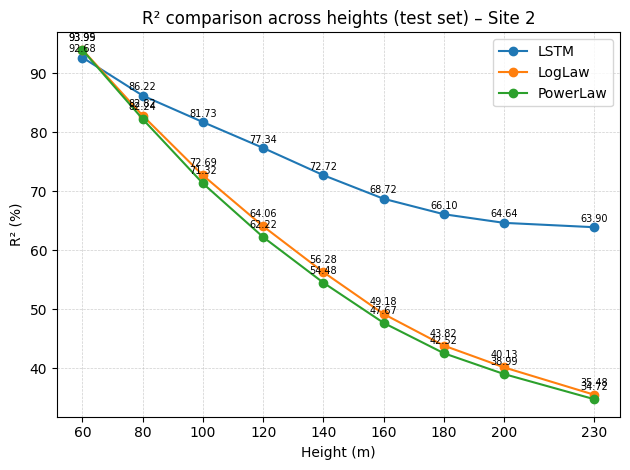

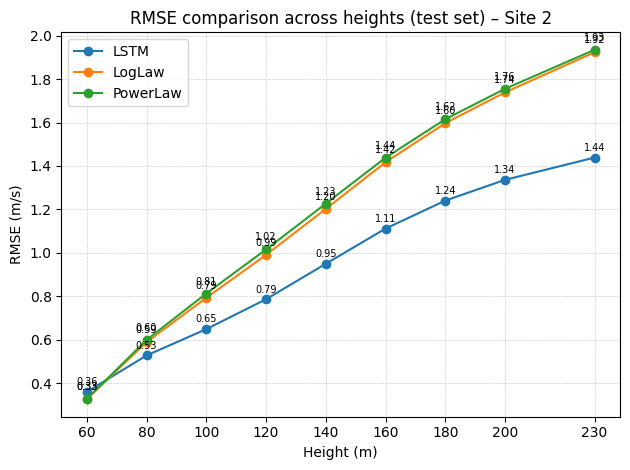

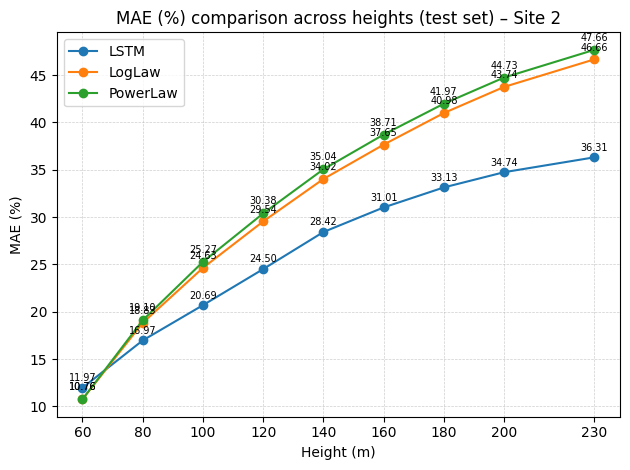


Plotting vertical wind profiles (Observed, LSTM, Power law, Log law) – Site 2...


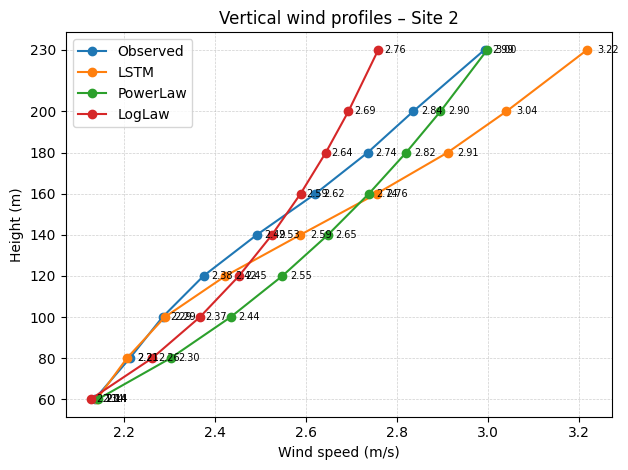

In [54]:
"""
Experiment 1 – Site 2:
LSTM wind profile model + Power law (alpha=0.25) + Log law

This script:
- Loads 'site 2 data.csv'.
- Prepares sequences with a configurable TIME_STEPS.
- Trains an LSTM wind profile model (v60m–v230m).
- Uses a FIXED power-law exponent alpha = 0.25 (as in the paper).
- Fits a log-law roughness length z0 from the training data.
- Evaluates LSTM, Power law, and Log law on the same test set.
- Prints a console comparison table with:
    MeanObs_ms (TEST-set mean from your data),
    R2, MSE, RMSE, MAE, MAE_pct, MAPE_pct.
- Plots:
    * R² (%) vs height
    * RMSE (m/s) vs height
    * MAE (%) vs height
    * Vertical wind profile (Observed, LSTM, Power law, Log law)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 2 data.csv"     # <--- Site 2 CSV
CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"       # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90            # 90% train, 10% test (time-ordered)
LSTM_UNITS = 30                  # number of LSTM neurons
EPOCHS = 30
BATCH_SIZE = 2
RANDOM_SEED = 42

# Temporal memory (lookback window) to use
TIME_STEPS = 2                   # <-- set your desired time steps here

REF_HEIGHT = 40.0                # reference height for v40m (m)
REF_COL = "v40m"                 # reference speed column

# Fixed power-law exponent from the paper
POWER_LAW_ALPHA = 0.25           # v(z) = v_ref * (z/z_ref)^alpha


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(model_name, metrics_dict):
    """
    Detailed block printout per height for a given model.
    """
    print(f"\n=== {model_name}: Metrics per height (test set) ===")
    for col, m in metrics_dict.items():
        print(f"\n--- {col} ---")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Console comparison table
# ------------------------------------------------------------

def show_comparison_table(metrics_lstm,
                          metrics_power,
                          metrics_log,
                          mean_obs_per_height):
    """
    Build a comparison table (LSTM vs Power law vs Log law) as a pandas
    DataFrame and print it to the console.

    Columns:
        model       height    MeanObs_ms   R2    MSE_m2s2
        RMSE_ms     MAE_ms    MAE_pct      MAPE_pct
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            mean_obs = mean_obs_per_height.get(h, np.nan)
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (m["mae"] / mean_obs) * 100.0

            rows.append({
                "model":      model_name,
                "height":     h,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "MSE_m2s2":   m["mse"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     m["mae"],
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })

    df_out = pd.DataFrame(rows)

    print("\nComparison table (test set) – Site 2:")
    pd.set_option("display.float_format", lambda x: f"{x:8.4f}")
    print(df_out.to_string(index=False))


# ------------------------------------------------------------
# Utilities for heights & baseline models
# ------------------------------------------------------------

def height_from_column(col_name: str) -> float:
    """
    Extract numeric height from column names like 'v60m', 'v100m', etc.
    Assumes format 'v<height>m'.
    """
    return float(col_name[1:-1])


def fit_log_law_z0(df: pd.DataFrame,
                   train_indices: np.ndarray,
                   target_cols,
                   ref_height: float = REF_HEIGHT,
                   ref_col: str = REF_COL) -> float:
    """
    Fit a single global roughness length z0 for the log law:

        v(z) = v_ref * ln(z / z0) / ln(ref_height / z0)

    by minimizing squared error on speed ratios over the training set.
    """
    z_list = []
    r_list = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            r = v_tar / v_ref  # measured ratio v(z) / v_ref
            z_list.append(z)
            r_list.append(r)

    if len(z_list) == 0:
        print("Warning: no valid samples for fitting log-law z0. Using z0 = 0.1 m.")
        return 0.1

    z_arr = np.asarray(z_list, dtype=float)
    r_arr = np.asarray(r_list, dtype=float)

    # Search z0 in a reasonable range (log-spaced)
    z0_candidates = np.logspace(-3, 1, 200)  # 0.001 to 10 m
    best_z0 = None
    best_loss = np.inf

    for z0 in z0_candidates:
        if z0 >= ref_height:
            continue

        denom = np.log(ref_height / z0)
        if denom == 0:
            continue

        r_model = np.log(z_arr / z0) / denom
        loss = np.mean((r_arr - r_model)**2)

        if loss < best_loss:
            best_loss = loss
            best_z0 = z0

    if best_z0 is None:
        print("Warning: failed to find good z0. Using z0 = 0.1 m.")
        best_z0 = 0.1

    return best_z0


def predict_power_and_log_profiles(df: pd.DataFrame,
                                   indices: np.ndarray,
                                   target_cols,
                                   alpha: float,
                                   z0: float,
                                   ref_height: float = REF_HEIGHT,
                                   ref_col: str = REF_COL):
    """
    Compute predictions for power-law and log-law models for all test indices.

    Returns:
        y_pred_power  : (n_test, n_heights)
        y_pred_loglaw : (n_test, n_heights)
    """
    n_test = len(indices)
    n_heights = len(target_cols)

    y_pred_power = np.zeros((n_test, n_heights), dtype="float32")
    y_pred_loglaw = np.zeros((n_test, n_heights), dtype="float32")

    denom_log = np.log(ref_height / z0)

    for i, idx in enumerate(indices):
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            # leave predictions as zeros; they will just contribute to error
            continue

        for j, col in enumerate(target_cols):
            z = height_from_column(col)

            # Power law with fixed alpha
            y_pred_power[i, j] = float(v_ref) * (z / ref_height)**alpha

            # Log law
            ratio = np.log(z / z0) / denom_log
            y_pred_loglaw[i, j] = float(v_ref) * ratio

    return y_pred_power, y_pred_loglaw


# ------------------------------------------------------------
# Data loading & preprocessing (Site 2)
# ------------------------------------------------------------

def load_site2_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 2 CSV file.

    Steps:
    - Read CSV.
    - Replace -9999 flags with NaN.
    - Drop columns that are entirely NaN (e.g. Unnamed: 19–34).
    - Interpolate remaining columns.
    - Drop rows with NaN only in the core wind variables.
    - Sort by 'indice' and reset index.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Replace missing-value flags if present
    df.replace([-9999, -9999.0], np.nan, inplace=True)

    # Drop columns that are completely NaN (all rows NaN)
    df.dropna(axis=1, how="all", inplace=True)

    # Interpolate remaining columns
    df.interpolate(method="linear", limit_direction="both", inplace=True)

    # Core columns we need for the experiment
    core_cols = [
        "Time", "v40m", "dir40m", "TKE",
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    missing_core = [c for c in core_cols if c not in df.columns]
    if missing_core:
        raise ValueError(f"Missing required columns in Site 2 data: {missing_core}")

    # Drop rows where any core column is still NaN
    df.dropna(subset=core_cols, inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment1(df: pd.DataFrame, time_steps: int):
    """
    Prepare inputs and outputs for Experiment 1, using a configurable
    temporal window (time_steps) for the LSTM.

    Each training example is:
        X_seq[t]   = [X_scaled[t - time_steps + 1], ..., X_scaled[t]]
        y_seq[t]   = y_scaled[t]

    where t is the index of the *current* time step (the prediction time).
    """

    # Inputs (same as in paper for 40 m level)
    feature_cols = ["Time", "v40m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m (as in the paper)
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    # Check that all required columns are present
    missing = [c for c in feature_cols + target_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in Site 2 data: {missing}")

    X = df[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    # and a target at time t
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    train_indices = indices[train_mask]
    test_indices = indices[test_mask]

    # --- Scaling (fit only on training portion, no leakage) ---
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1: t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols,
            train_indices, test_indices)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Experiment 1).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Plotting comparisons (R², RMSE, MAE%) & profiles
# ------------------------------------------------------------

def build_comparison_df(metrics_lstm,
                        metrics_power,
                        metrics_log,
                        mean_obs_per_height):
    """
    Build a tidy DataFrame with one row per (model, height),
    including numerical height in meters and MAE as % of mean observed speed.
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            height_m = height_from_column(h)
            mean_obs = mean_obs_per_height.get(h, np.nan)
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (m["mae"] / mean_obs) * 100.0

            rows.append({
                "model":      model_name,
                "height":     h,
                "height_m":   height_m,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     m["mae"],
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })

    df = pd.DataFrame(rows)
    return df


def plot_metric_comparison(df, metric="R2"):
    """
    Plot a line graph comparing LSTM, PowerLaw, LogLaw for a given metric
    across heights.

    metric:
        "R2"       -> plotted as R2 * 100 (%)
        "RMSE"     -> RMSE_ms (m/s)
        "MAE_PCT"  -> MAE_pct (%)
    """
    metric = metric.upper()
    if metric not in ["R2", "RMSE", "MAE_PCT"]:
        raise ValueError("metric must be 'R2', 'RMSE', or 'MAE_PCT'.")

    df_sorted = df.sort_values("height_m")
    heights_vals = df_sorted["height_m"].unique()
    methods = df_sorted["model"].unique()

    plt.figure()

    for method in methods:
        df_m = df_sorted[df_sorted["model"] == method]
        x = df_m["height_m"].to_numpy()

        if metric == "R2":
            y = df_m["R2"].to_numpy() * 100.0
            y_label = "R² (%)"
            title_metric = "R²"
        elif metric == "RMSE":
            y = df_m["RMSE_ms"].to_numpy()
            y_label = "RMSE (m/s)"
            title_metric = "RMSE"
        else:  # "MAE_PCT"
            y = df_m["MAE_pct"].to_numpy()
            y_label = "MAE (%)"
            title_metric = "MAE (%)"

        plt.plot(x, y, marker="o", linewidth=1.5, label=method)

        # Data labels
        y_valid = y[~np.isnan(y)]
        if len(y_valid) > 0:
            y_min = np.nanmin(y_valid)
            y_max = np.nanmax(y_valid)
            y_range = y_max - y_min if y_max > y_min else 1.0
            offset = 0.02 * y_range
        else:
            offset = 0.0

        for xi, yi in zip(x, y):
            if np.isnan(yi):
                continue
            plt.text(
                xi,
                yi + offset,
                f"{yi:.2f}",
                ha="center",
                va="bottom",
                fontsize=7
            )

    plt.xlabel("Height (m)")
    plt.ylabel(y_label)
    plt.title(f"{title_metric} comparison across heights (test set) – Site 2")
    plt.xticks(heights_vals, [f"{int(h)}" for h in heights_vals])
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_vertical_profiles(target_cols, profiles_mean_dict):
    """
    Plot vertical wind profiles for Site 2:
    - Observed (test-set mean)
    - LSTM (test-set mean)
    - PowerLaw (test-set mean)
    - LogLaw (test-set mean)
    """
    heights_m = np.array([height_from_column(c) for c in target_cols], dtype=float)

    plt.figure()

    for label, prof in profiles_mean_dict.items():
        prof = np.asarray(prof, dtype=float)
        plt.plot(prof, heights_m, marker="o", linewidth=1.5, label=label)

        # Data callouts
        valid = prof[~np.isnan(prof)]
        if len(valid) > 0:
            x_min = np.nanmin(valid)
            x_max = np.nanmax(valid)
            x_range = x_max - x_min if x_max > x_min else 1.0
            offset = 0.02 * x_range
        else:
            offset = 0.0

        for v, z in zip(prof, heights_m):
            if np.isnan(v):
                continue
            plt.text(
                v + offset,
                z,
                f"{v:.2f}",
                va="center",
                fontsize=7
            )

    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Height (m)")
    plt.yticks(heights_m, [f"{int(h)}" for h in heights_m])  # grid at exact heights
    plt.title("Vertical wind profiles – Site 2")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Single experiment for the chosen TIME_STEPS
# ------------------------------------------------------------

def run_experiment(df, time_steps: int):
    """
    Run the full pipeline (prepare -> train -> evaluate)
    for the specified time_steps value.

    Returns:
        metrics_lstm, metrics_power, metrics_log,
        mean_obs_per_height (TEST set),
        target_cols, profiles_mean_dict
    """

    # New TF "session"-like state and deterministic seeds
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols,
     train_indices, test_indices) = prepare_experiment1(df, time_steps=time_steps)

    print("  X_train shape:", X_train.shape)  # (n_train_seq, time_steps, n_features)
    print("  y_train shape:", y_train_scaled.shape)

    # --- Power-law exponent (FIXED, from the paper) ---
    alpha = POWER_LAW_ALPHA
    print(f"  Power-law alpha (fixed): {alpha:.4f} (from paper)")

    # --- Fit log-law z0 on training portion ---
    z0 = fit_log_law_z0(df, train_indices, target_cols)
    print(f"  Log-law z0   (global): {z0:.4f} m")

    # --- Build and train LSTM ---
    input_shape = X_train.shape[1:]       # (time_steps, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    print("  Building LSTM model...")
    model = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("  Training LSTM...")
    model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate (scaled space)
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  LSTM test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  LSTM test MAE  (scaled):      {test_mae:.4f}")

    # Predictions back in original physical units (m/s)
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred_lstm = y_scaler.inverse_transform(y_pred_scaled)

    # --- Baseline predictions on same test indices ---
    y_pred_power, y_pred_log = predict_power_and_log_profiles(
        df, test_indices, target_cols, alpha, z0
    )

    # Metrics per height (R², MSE, RMSE, MAE, MAPE) on test set
    metrics_lstm  = compute_height_metrics(y_test_orig, y_pred_lstm,  target_cols)
    metrics_power = compute_height_metrics(y_test_orig, y_pred_power, target_cols)
    metrics_log   = compute_height_metrics(y_test_orig, y_pred_log,   target_cols)

    # Mean observed wind speed at each height over the TEST set
    mean_obs_per_height = {}
    for j, col in enumerate(target_cols):
        mean_obs_per_height[col] = float(np.mean(y_test_orig[:, j]))

    mean_obs_test   = np.array([mean_obs_per_height[col] for col in target_cols])
    mean_lstm_test  = np.mean(y_pred_lstm, axis=0)
    mean_power_test = np.mean(y_pred_power, axis=0)
    mean_log_test   = np.mean(y_pred_log, axis=0)

    profiles_mean_dict = {
        "Observed":  mean_obs_test,
        "LSTM":      mean_lstm_test,
        "PowerLaw":  mean_power_test,
        "LogLaw":    mean_log_test,
    }

    return (metrics_lstm,
            metrics_power,
            metrics_log,
            mean_obs_per_height,
            target_cols,
            profiles_mean_dict)


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():
    print("Loading Site 2 data...")
    df = load_site2_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning (Site 2): {df.shape}")

    if len(df) == 0:
        raise ValueError("Site 2 dataframe is empty after cleaning. "
                         "Check CSV_PATH, separator, and column names.")

    print(f"\n=== Site 2: Running experiment for TIME_STEPS = {TIME_STEPS} ===")
    (metrics_lstm,
     metrics_power,
     metrics_log,
     mean_obs_per_height,
     target_cols,
     profiles_mean_dict) = run_experiment(df, time_steps=TIME_STEPS)

    # Detailed per-height metrics for each model
    print_height_metrics("LSTM – Site 2",     metrics_lstm)
    print_height_metrics("PowerLaw – Site 2", metrics_power)
    print_height_metrics("LogLaw – Site 2",   metrics_log)

    # Console comparison table (uses TEST-set observed means)
    show_comparison_table(metrics_lstm,
                          metrics_power,
                          metrics_log,
                          mean_obs_per_height)

    # Build tidy comparison DataFrame for plots
    comparison_df = build_comparison_df(
        metrics_lstm, metrics_power, metrics_log, mean_obs_per_height
    )

    # Plots: R² (%), RMSE (m/s), MAE (%) vs height
    print("\nPlotting comparison line graphs (R², RMSE, MAE%) across heights – Site 2...")
    plot_metric_comparison(comparison_df, metric="R2")
    plot_metric_comparison(comparison_df, metric="RMSE")
    plot_metric_comparison(comparison_df, metric="MAE_PCT")

    # Vertical wind profile plot (TEST-set means)
    print("\nPlotting vertical wind profiles (Observed, LSTM, Power law, Log law) – Site 2...")
    plot_vertical_profiles(target_cols, profiles_mean_dict)


if __name__ == "__main__":
    main()


### Final Version of Site 2

Loading Site 2 data...
Data shape after cleaning (Site 2): (22576, 18)

=== Site 2: Running experiment for TIME_STEPS = 2 ===
  X_train shape: (20317, 2, 4)
  y_train shape: (20317, 9)
  Power-law alpha (fixed): 0.2500 (from paper)
  Log-law z0   (global): 0.6517 m
  Building LSTM model...
  Training LSTM...
  LSTM test loss (MSE, scaled): 0.2489
  LSTM test MAE  (scaled):      0.3583

=== LSTM – Site 2: Metrics per height (test set) ===

--- v60m ---
R²   :      0.933
MSE  :     0.1191 (m²/s²)
RMSE :     0.3451 (m/s)
MAE  :     0.2484 (m/s)
MAPE :      17.41 (%)

--- v80m ---
R²   :      0.868
MSE  :     0.2671 (m²/s²)
RMSE :     0.5168 (m/s)
MAE  :     0.3748 (m/s)
MAPE :      26.01 (%)

--- v100m ---
R²   :      0.820
MSE  :     0.4142 (m²/s²)
RMSE :     0.6436 (m/s)
MAE  :     0.4708 (m/s)
MAPE :      33.06 (%)

--- v120m ---
R²   :      0.771
MSE  :     0.6257 (m²/s²)
RMSE :     0.7910 (m/s)
MAE  :     0.5824 (m/s)
MAPE :      41.86 (%)

--- v140m ---
R²   :      0.720
MSE  :     

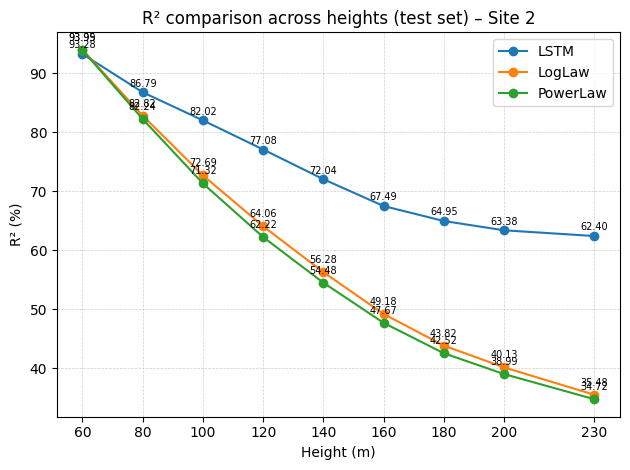

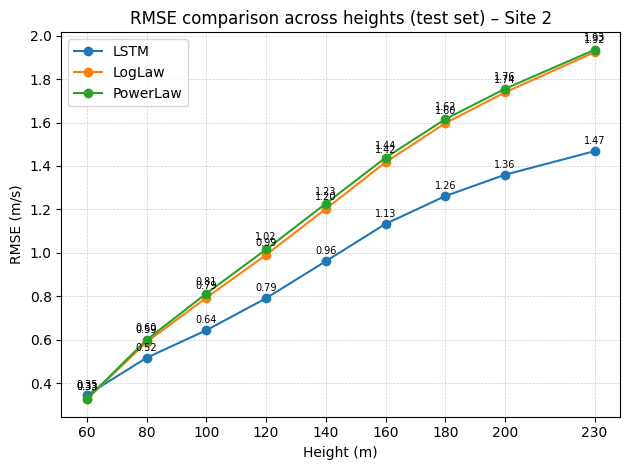

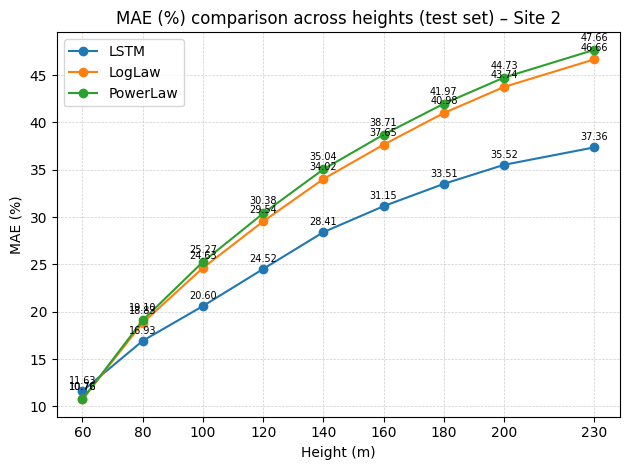


Plotting vertical wind profiles (Observed, LSTM, Power law, Log law) – Site 2...


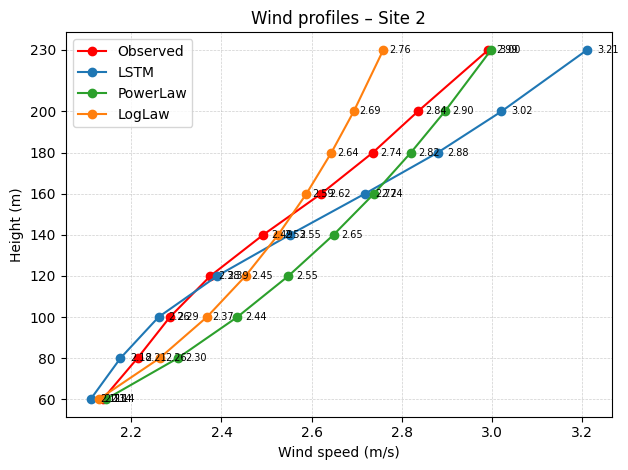

In [11]:
"""
Experiment 1 – Site 2:
LSTM wind profile model + Power law (alpha=0.25) + Log law

This script:
- Loads 'site 2 data.csv'.
- Prepares sequences with a configurable TIME_STEPS.
- Trains an LSTM wind profile model (v60m–v230m).
- Uses a FIXED power-law exponent alpha = 0.25 (as in the paper).
- Fits a log-law roughness length z0 from the training data.
- Evaluates LSTM, Power law, and Log law on the same test set.
- Prints a console comparison table with:
    MeanObs_ms (TEST-set mean from your data),
    R2, MSE, RMSE, MAE, MAE_pct, MAPE_pct.
- Plots:
    * R² (%) vs height
    * RMSE (m/s) vs height
    * MAE (%) vs height
    * Vertical wind profile (Observed, LSTM, Power law, Log law)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 2 data.csv"     # <--- Site 2 CSV
CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"       # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90            # 90% train, 10% test (time-ordered)
LSTM_UNITS = 30                  # number of LSTM neurons
EPOCHS = 30
BATCH_SIZE = 2
RANDOM_SEED = 42

# Temporal memory (lookback window) to use
TIME_STEPS = 2                   # <-- set your desired time steps here

REF_HEIGHT = 40.0                # reference height for v40m (m)
REF_COL = "v40m"                 # reference speed column

# Fixed power-law exponent from the paper
POWER_LAW_ALPHA = 0.25           # v(z) = v_ref * (z/z_ref)^alpha


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(model_name, metrics_dict):
    """
    Detailed block printout per height for a given model.
    """
    print(f"\n=== {model_name}: Metrics per height (test set) ===")
    for col, m in metrics_dict.items():
        print(f"\n--- {col} ---")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Console comparison table
# ------------------------------------------------------------

def show_comparison_table(metrics_lstm,
                          metrics_power,
                          metrics_log,
                          mean_obs_per_height):
    """
    Build a comparison table (LSTM vs Power law vs Log law) as a pandas
    DataFrame and print it to the console.

    Columns:
        model       height    MeanObs_ms   R2    MSE_m2s2
        RMSE_ms     MAE_ms    MAE_pct      MAPE_pct
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            mean_obs = mean_obs_per_height.get(h, np.nan)
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (m["mae"] / mean_obs) * 100.0

            rows.append({
                "model":      model_name,
                "height":     h,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "MSE_m2s2":   m["mse"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     m["mae"],
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })

    df_out = pd.DataFrame(rows)

    print("\nComparison table (test set) – Site 2:")
    pd.set_option("display.float_format", lambda x: f"{x:8.4f}")
    print(df_out.to_string(index=False))


# ------------------------------------------------------------
# Utilities for heights & baseline models
# ------------------------------------------------------------

def height_from_column(col_name: str) -> float:
    """
    Extract numeric height from column names like 'v60m', 'v100m', etc.
    Assumes format 'v<height>m'.
    """
    return float(col_name[1:-1])


def fit_log_law_z0(df: pd.DataFrame,
                   train_indices: np.ndarray,
                   target_cols,
                   ref_height: float = REF_HEIGHT,
                   ref_col: str = REF_COL) -> float:
    """
    Fit a single global roughness length z0 for the log law:

        v(z) = v_ref * ln(z / z0) / ln(ref_height / z0)

    by minimizing squared error on speed ratios over the training set.
    """
    z_list = []
    r_list = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            r = v_tar / v_ref  # measured ratio v(z) / v_ref
            z_list.append(z)
            r_list.append(r)

    if len(z_list) == 0:
        print("Warning: no valid samples for fitting log-law z0. Using z0 = 0.1 m.")
        return 0.1

    z_arr = np.asarray(z_list, dtype=float)
    r_arr = np.asarray(r_list, dtype=float)

    # Search z0 in a reasonable range (log-spaced)
    z0_candidates = np.logspace(-3, 1, 200)  # 0.001 to 10 m
    best_z0 = None
    best_loss = np.inf

    for z0 in z0_candidates:
        if z0 >= ref_height:
            continue

        denom = np.log(ref_height / z0)
        if denom == 0:
            continue

        r_model = np.log(z_arr / z0) / denom
        loss = np.mean((r_arr - r_model)**2)

        if loss < best_loss:
            best_loss = loss
            best_z0 = z0

    if best_z0 is None:
        print("Warning: failed to find good z0. Using z0 = 0.1 m.")
        best_z0 = 0.1

    return best_z0


def predict_power_and_log_profiles(df: pd.DataFrame,
                                   indices: np.ndarray,
                                   target_cols,
                                   alpha: float,
                                   z0: float,
                                   ref_height: float = REF_HEIGHT,
                                   ref_col: str = REF_COL):
    """
    Compute predictions for power-law and log-law models for all test indices.

    Returns:
        y_pred_power  : (n_test, n_heights)
        y_pred_loglaw : (n_test, n_heights)
    """
    n_test = len(indices)
    n_heights = len(target_cols)

    y_pred_power = np.zeros((n_test, n_heights), dtype="float32")
    y_pred_loglaw = np.zeros((n_test, n_heights), dtype="float32")

    denom_log = np.log(ref_height / z0)

    for i, idx in enumerate(indices):
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            # leave predictions as zeros; they will just contribute to error
            continue

        for j, col in enumerate(target_cols):
            z = height_from_column(col)

            # Power law with fixed alpha
            y_pred_power[i, j] = float(v_ref) * (z / ref_height)**alpha

            # Log law
            ratio = np.log(z / z0) / denom_log
            y_pred_loglaw[i, j] = float(v_ref) * ratio

    return y_pred_power, y_pred_loglaw


# ------------------------------------------------------------
# Data loading & preprocessing (Site 2)
# ------------------------------------------------------------

def load_site2_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 2 CSV file.

    Steps:
    - Read CSV.
    - Replace -9999 flags with NaN.
    - Drop columns that are entirely NaN (e.g. Unnamed: 19–34).
    - Interpolate remaining columns.
    - Drop rows with NaN only in the core wind variables.
    - Sort by 'indice' and reset index.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Replace missing-value flags if present
    df.replace([-9999, -9999.0], np.nan, inplace=True)

    # Drop columns that are completely NaN (all rows NaN)
    df.dropna(axis=1, how="all", inplace=True)

    # Interpolate remaining columns
    df.interpolate(method="linear", limit_direction="both", inplace=True)

    # Core columns we need for the experiment
    core_cols = [
        "Time", "v40m", "dir40m", "TKE",
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    missing_core = [c for c in core_cols if c not in df.columns]
    if missing_core:
        raise ValueError(f"Missing required columns in Site 2 data: {missing_core}")

    # Drop rows where any core column is still NaN
    df.dropna(subset=core_cols, inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment1(df: pd.DataFrame, time_steps: int):
    """
    Prepare inputs and outputs for Experiment 1, using a configurable
    temporal window (time_steps) for the LSTM.

    Each training example is:
        X_seq[t]   = [X_scaled[t - time_steps + 1], ..., X_scaled[t]]
        y_seq[t]   = y_scaled[t]
    """

    # Inputs (same as in paper for 40 m level)
    feature_cols = ["Time", "v40m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m (as in the paper)
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    # Check that all required columns are present
    missing = [c for c in feature_cols + target_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in Site 2 data: {missing}")

    X = df[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    # and a target at time t
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    train_indices = indices[train_mask]
    test_indices = indices[test_mask]

    # --- Scaling (fit only on training portion, no leakage) ---
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1: t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols,
            train_indices, test_indices)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Experiment 1).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Plotting comparisons (R², RMSE, MAE%) & profiles
# ------------------------------------------------------------

def build_comparison_df(metrics_lstm,
                        metrics_power,
                        metrics_log,
                        mean_obs_per_height):
    """
    Build a tidy DataFrame with one row per (model, height),
    including numerical height in meters and MAE as % of mean observed speed.
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            height_m = height_from_column(h)
            mean_obs = mean_obs_per_height.get(h, np.nan)
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (m["mae"] / mean_obs) * 100.0

            rows.append({
                "model":      model_name,
                "height":     h,
                "height_m":   height_m,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     m["mae"],
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })

    df = pd.DataFrame(rows)
    return df


def plot_metric_comparison(df, metric="R2"):
    """
    Plot a line graph comparing LSTM, PowerLaw, LogLaw for a given metric
    across heights.

    metric:
        "R2"       -> plotted as R2 * 100 (%)
        "RMSE"     -> RMSE_ms (m/s)
        "MAE_PCT"  -> MAE_pct (%)

    Colors:
        LSTM     -> blue
        PowerLaw -> green
        LogLaw   -> orange
    """
    metric = metric.upper()
    if metric not in ["R2", "RMSE", "MAE_PCT"]:
        raise ValueError("metric must be 'R2', 'RMSE', or 'MAE_PCT'.")

    df_sorted = df.sort_values("height_m")
    heights_vals = df_sorted["height_m"].unique()
    methods = df_sorted["model"].unique()

    # Consistent colors for all plots
    color_map = {
        "LSTM": "C0",      # blue
        "PowerLaw": "C2",  # green
        "LogLaw": "C1",    # orange
    }

    plt.figure()

    for method in methods:
        df_m = df_sorted[df_sorted["model"] == method]
        x = df_m["height_m"].to_numpy()

        if metric == "R2":
            y = df_m["R2"].to_numpy() * 100.0
            y_label = "R² (%)"
            title_metric = "R²"
        elif metric == "RMSE":
            y = df_m["RMSE_ms"].to_numpy()
            y_label = "RMSE (m/s)"
            title_metric = "RMSE"
        else:  # "MAE_PCT"
            y = df_m["MAE_pct"].to_numpy()
            y_label = "MAE (%)"
            title_metric = "MAE (%)"

        plt.plot(
            x, y, marker="o", linewidth=1.5,
            label=method, color=color_map.get(method, None)
        )

        # Data labels
        y_valid = y[~np.isnan(y)]
        if len(y_valid) > 0:
            y_min = np.nanmin(y_valid)
            y_max = np.nanmax(y_valid)
            y_range = y_max - y_min if y_max > y_min else 1.0
            offset = 0.02 * y_range
        else:
            offset = 0.0

        for xi, yi in zip(x, y):
            if np.isnan(yi):
                continue
            plt.text(
                xi,
                yi + offset,
                f"{yi:.2f}",
                ha="center",
                va="bottom",
                fontsize=7
            )

    plt.xlabel("Height (m)")
    plt.ylabel(y_label)
    plt.title(f"{title_metric} comparison across heights (test set) – Site 2")
    plt.xticks(heights_vals, [f"{int(h)}" for h in heights_vals])
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_vertical_profiles(target_cols, profiles_mean_dict):
    """
    Plot vertical wind profiles for Site 2:
    - Observed (test-set mean)
    - LSTM (test-set mean)
    - PowerLaw (test-set mean)
    - LogLaw (test-set mean)

    Colors:
        Observed -> red
        LSTM     -> blue
        PowerLaw -> green
        LogLaw   -> orange
    """
    heights_m = np.array([height_from_column(c) for c in target_cols], dtype=float)

    color_map = {
        "Observed": "r",
        "LSTM": "C0",
        "PowerLaw": "C2",
        "LogLaw": "C1",
    }

    plt.figure()

    for label, prof in profiles_mean_dict.items():
        prof = np.asarray(prof, dtype=float)
        plt.plot(
            prof, heights_m, marker="o", linewidth=1.5,
            label=label, color=color_map.get(label, None)
        )

        # Data callouts
        valid = prof[~np.isnan(prof)]
        if len(valid) > 0:
            x_min = np.nanmin(valid)
            x_max = np.nanmax(valid)
            x_range = x_max - x_min if x_max > x_min else 1.0
            offset = 0.02 * x_range
        else:
            offset = 0.0

        for v, z in zip(prof, heights_m):
            if np.isnan(v):
                continue
            plt.text(
                v + offset,
                z,
                f"{v:.2f}",
                va="center",
                fontsize=7
            )

    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Height (m)")
    plt.yticks(heights_m, [f"{int(h)}" for h in heights_m])  # grid at exact heights
    plt.title("Wind profiles – Site 2")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Single experiment for the chosen TIME_STEPS
# ------------------------------------------------------------

def run_experiment(df, time_steps: int):
    """
    Run the full pipeline (prepare -> train -> evaluate)
    for the specified time_steps value.

    Returns:
        metrics_lstm, metrics_power, metrics_log,
        mean_obs_per_height (TEST set),
        target_cols, profiles_mean_dict
    """

    # New TF "session"-like state and deterministic seeds
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols,
     train_indices, test_indices) = prepare_experiment1(df, time_steps=time_steps)

    print("  X_train shape:", X_train.shape)  # (n_train_seq, time_steps, n_features)
    print("  y_train shape:", y_train_scaled.shape)

    # --- Power-law exponent (FIXED, from the paper) ---
    alpha = POWER_LAW_ALPHA
    print(f"  Power-law alpha (fixed): {alpha:.4f} (from paper)")

    # --- Fit log-law z0 on training portion ---
    z0 = fit_log_law_z0(df, train_indices, target_cols)
    print(f"  Log-law z0   (global): {z0:.4f} m")

    # --- Build and train LSTM ---
    input_shape = X_train.shape[1:]       # (time_steps, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    print("  Building LSTM model...")
    model = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("  Training LSTM...")
    model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate (scaled space)
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  LSTM test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  LSTM test MAE  (scaled):      {test_mae:.4f}")

    # Predictions back in original physical units (m/s)
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred_lstm = y_scaler.inverse_transform(y_pred_scaled)

    # --- Baseline predictions on same test indices ---
    y_pred_power, y_pred_log = predict_power_and_log_profiles(
        df, test_indices, target_cols, alpha, z0
    )

    # Metrics per height (R², MSE, RMSE, MAE, MAPE) on test set
    metrics_lstm  = compute_height_metrics(y_test_orig, y_pred_lstm,  target_cols)
    metrics_power = compute_height_metrics(y_test_orig, y_pred_power, target_cols)
    metrics_log   = compute_height_metrics(y_test_orig, y_pred_log,   target_cols)

    # Mean observed wind speed at each height over the TEST set
    mean_obs_per_height = {}
    for j, col in enumerate(target_cols):
        mean_obs_per_height[col] = float(np.mean(y_test_orig[:, j]))

    mean_obs_test   = np.array([mean_obs_per_height[col] for col in target_cols])
    mean_lstm_test  = np.mean(y_pred_lstm, axis=0)
    mean_power_test = np.mean(y_pred_power, axis=0)
    mean_log_test   = np.mean(y_pred_log, axis=0)

    profiles_mean_dict = {
        "Observed":  mean_obs_test,
        "LSTM":      mean_lstm_test,
        "PowerLaw":  mean_power_test,
        "LogLaw":    mean_log_test,
    }

    return (metrics_lstm,
            metrics_power,
            metrics_log,
            mean_obs_per_height,
            target_cols,
            profiles_mean_dict)


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():
    print("Loading Site 2 data...")
    df = load_site2_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning (Site 2): {df.shape}")

    if len(df) == 0:
        raise ValueError("Site 2 dataframe is empty after cleaning. "
                         "Check CSV_PATH, separator, and column names.")

    print(f"\n=== Site 2: Running experiment for TIME_STEPS = {TIME_STEPS} ===")
    (metrics_lstm,
     metrics_power,
     metrics_log,
     mean_obs_per_height,
     target_cols,
     profiles_mean_dict) = run_experiment(df, time_steps=TIME_STEPS)

    # Detailed per-height metrics for each model
    print_height_metrics("LSTM – Site 2",     metrics_lstm)
    print_height_metrics("PowerLaw – Site 2", metrics_power)
    print_height_metrics("LogLaw – Site 2",   metrics_log)

    # Console comparison table (uses TEST-set observed means)
    show_comparison_table(metrics_lstm,
                          metrics_power,
                          metrics_log,
                          mean_obs_per_height)

    # Build tidy comparison DataFrame for plots
    comparison_df = build_comparison_df(
        metrics_lstm, metrics_power, metrics_log, mean_obs_per_height
    )

    # Plots: R² (%), RMSE (m/s), MAE (%) vs height
    print("\nPlotting comparison line graphs (R², RMSE, MAE%) across heights – Site 2...")
    plot_metric_comparison(comparison_df, metric="R2")
    plot_metric_comparison(comparison_df, metric="RMSE")
    plot_metric_comparison(comparison_df, metric="MAE_PCT")

    # Vertical wind profile plot (TEST-set means)
    print("\nPlotting vertical wind profiles (Observed, LSTM, Power law, Log law) – Site 2...")
    plot_vertical_profiles(target_cols, profiles_mean_dict)


if __name__ == "__main__":
    main()


In [1]:
"""
Experiment 1: LSTM wind profile model for 'site 2 data.csv'

Single-run version with baseline models:
- Uses a single TIME_STEPS value.
- Prepares sequences of that temporal memory length.
- Trains a fresh LSTM model (wind profile model).
- Fits power-law and log-law profile models on the training set.
- Evaluates all three models (LSTM, power law, log law) on the same test set.
- Saves the comparison table (metrics per height) to an Excel file.

Metrics per height (test set):
- R²
- MSE
- RMSE
- MAE
- MAPE

Also prints a wind velocity profile table (test-set mean per height) for:
- Observed
- LSTM
- Power law
- Log law
"""

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 2 data.csv"     # change path if needed
CSV_SEP = ";"                    # dataset uses ';' as separator
CSV_ENCODING = "utf-8-sig"       # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90            # 90% train, 10% test (time-ordered)
LSTM_UNITS = 20                  # number of LSTM neurons
EPOCHS = 20
BATCH_SIZE = 2
RANDOM_SEED = 42

# single temporal memory (lookback window) to use
TIME_STEPS = 2                   # <-- set your desired time steps here

REF_HEIGHT = 40.0                # reference height for v40m (m)
REF_COL = "v40m"                 # reference speed column


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(model_name, metrics_dict):
    """
    Detailed block printout per height for a given model.
    """
    print(f"\n=== {model_name}: Metrics per height (test set) ===")
    for col, m in metrics_dict.items():
        print(f"\n--- {col} ---")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# CSV comparison table (saved as .csv)
# ------------------------------------------------------------

def show_comparison_table(metrics_lstm, metrics_power, metrics_log, csv_path=None):
    """
    Build a comparison table (LSTM vs Power law vs Log law) as a pandas
    DataFrame, save it to a CSV file, and also print it.

    Columns:
        model    height    R2    MSE_m2s2    RMSE_ms    MAE_ms    MAPE_pct
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            rows.append({
                "model":     model_name,
                "height":    h,
                "R2":        m["r2"],
                "MSE_m2s2":  m["mse"],
                "RMSE_ms":   m["rmse"],
                "MAE_ms":    m["mae"],
                "MAPE_pct":  m["mape"],
            })

    df_out = pd.DataFrame(rows)

    # Default CSV filename (includes TIME_STEPS)
    if csv_path is None:
        csv_path = f"site2_model_comparison_TIMESTEPS_{TIME_STEPS}.csv"

    # Save to CSV
    df_out.to_csv(csv_path, index=False)

    # Print to console as well (optional)
    print("\nComparison table (also saved to CSV):")
    print(df_out.to_string(index=False))
    print(f"\nSaved CSV file: {csv_path}")


# ------------------------------------------------------------
# Vertical wind profile table (console)
# ------------------------------------------------------------

def show_profile_table(y_true, y_lstm, y_power, y_log, target_cols):
    """
    Print a table of mean wind speeds per height over the test set:

    Columns:
        height_m   Obs_ms   LSTM_ms   Power_ms   Log_ms
    """
    y_true = np.asarray(y_true)
    y_lstm = np.asarray(y_lstm)
    y_power = np.asarray(y_power)
    y_log = np.asarray(y_log)

    mean_obs = np.mean(y_true, axis=0)
    mean_lstm = np.mean(y_lstm, axis=0)
    mean_power = np.mean(y_power, axis=0)
    mean_log = np.mean(y_log, axis=0)

    rows = []
    for j, col in enumerate(target_cols):
        height_m = height_from_column(col)
        rows.append({
            "height_m": float(height_m),
            "Obs_ms":   float(mean_obs[j]),
            "LSTM_ms":  float(mean_lstm[j]),
            "Power_ms": float(mean_power[j]),
            "Log_ms":   float(mean_log[j]),
        })

    df_prof = pd.DataFrame(rows).sort_values("height_m")

    print("\nWind velocity vertical profiles (test-set mean):")
    print(df_prof.to_string(index=False))


# ------------------------------------------------------------
# Utilities for heights & baseline models
# ------------------------------------------------------------

def height_from_column(col_name: str) -> float:
    """
    Extract numeric height from column names like 'v60m', 'v100m', etc.
    Assumes format 'v<height>m'.
    """
    return float(col_name[1:-1])


def fit_power_law_alpha(df: pd.DataFrame,
                        train_indices: np.ndarray,
                        target_cols,
                        ref_height: float = REF_HEIGHT,
                        ref_col: str = REF_COL) -> float:
    """
    Fit a single global power-law exponent alpha using training data:

        v(z) = v_ref * (z / ref_height)**alpha

    Fit alpha from:
        log(v(z) / v_ref) = alpha * log(z / ref_height)
    via least squares in log space.
    """
    x_vals = []
    y_vals = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            x_vals.append(np.log(z / ref_height))
            y_vals.append(np.log(v_tar / v_ref))

    if len(x_vals) == 0:
        print("Warning: no valid samples for fitting power-law alpha. Using alpha = 0.14.")
        return 0.14

    x_arr = np.asarray(x_vals, dtype=float)
    y_arr = np.asarray(y_vals, dtype=float)

    denom = np.sum(x_arr**2)
    if denom <= 0:
        print("Warning: degenerate fit for power-law alpha. Using alpha = 0.14.")
        return 0.14

    alpha = np.sum(x_arr * y_arr) / denom
    return alpha


def fit_log_law_z0(df: pd.DataFrame,
                   train_indices: np.ndarray,
                   target_cols,
                   ref_height: float = REF_HEIGHT,
                   ref_col: str = REF_COL) -> float:
    """
    Fit a single global roughness length z0 for the log law:

        v(z) = v_ref * ln(z / z0) / ln(ref_height / z0)

    by minimizing squared error on speed ratios over the training set.
    """
    z_list = []
    r_list = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            r = v_tar / v_ref  # measured ratio v(z) / v_ref
            z_list.append(z)
            r_list.append(r)

    if len(z_list) == 0:
        print("Warning: no valid samples for fitting log-law z0. Using z0 = 0.1 m.")
        return 0.1

    z_arr = np.asarray(z_list, dtype=float)
    r_arr = np.asarray(r_list, dtype=float)

    # Search z0 in a reasonable range (log-spaced)
    z0_candidates = np.logspace(-3, 1, 200)  # 0.001 to 10 m
    best_z0 = None
    best_loss = np.inf

    for z0 in z0_candidates:
        if z0 >= ref_height:
            continue

        denom = np.log(ref_height / z0)
        if denom == 0:
            continue

        r_model = np.log(z_arr / z0) / denom
        loss = np.mean((r_arr - r_model)**2)

        if loss < best_loss:
            best_loss = loss
            best_z0 = z0

    if best_z0 is None:
        print("Warning: failed to find good z0. Using z0 = 0.1 m.")
        best_z0 = 0.1

    return best_z0


def predict_power_and_log_profiles(df: pd.DataFrame,
                                   indices: np.ndarray,
                                   target_cols,
                                   alpha: float,
                                   z0: float,
                                   ref_height: float = REF_HEIGHT,
                                   ref_col: str = REF_COL):
    """
    Compute predictions for power-law and log-law models for all test indices.

    Returns:
        y_pred_power  : (n_test, n_heights)
        y_pred_loglaw : (n_test, n_heights)
    """
    n_test = len(indices)
    n_heights = len(target_cols)

    y_pred_power = np.zeros((n_test, n_heights), dtype="float32")
    y_pred_loglaw = np.zeros((n_test, n_heights), dtype="float32")

    denom_log = np.log(ref_height / z0)

    for i, idx in enumerate(indices):
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            # leave predictions as zeros; they will just contribute to error
            continue

        for j, col in enumerate(target_cols):
            z = height_from_column(col)

            # Power law
            y_pred_power[i, j] = float(v_ref) * (z / ref_height)**alpha

            # Log law
            ratio = np.log(z / z0) / denom_log
            y_pred_loglaw[i, j] = float(v_ref) * ratio

    return y_pred_power, y_pred_loglaw


# ------------------------------------------------------------
# Data loading & preprocessing (Site 2)
# ------------------------------------------------------------

def load_site2_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 2 CSV file.

    Only enforce numeric / no-NaNs on the columns actually used
    (inputs + outputs). Extra columns are ignored.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Replace missing-value flags if present
    df.replace([-9999, -9999.0], np.nan, inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Essential columns (inputs + outputs)
    essential_cols = [
        "Time", "v40m", "dir40m", "TKE",
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]
    missing = [c for c in essential_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns in Site 2 CSV: {missing}")

    # Coerce essential columns to numeric; non-convertible -> NaN
    df[essential_cols] = df[essential_cols].apply(
        pd.to_numeric, errors="coerce"
    )

    # Interpolate numeric columns (including essential)
    df.interpolate(method="linear", limit_direction="both", inplace=True)

    # Finally, drop rows with any NaN remaining in essential columns
    df.dropna(subset=essential_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment2(df: pd.DataFrame, time_steps: int):
    """
    Prepare inputs and outputs for Site 2, using a configurable
    temporal window (time_steps) for the LSTM.

    Each training example is:
        X_seq[t]   = [X_scaled[t - time_steps + 1], ..., X_scaled[t]]
        y_seq[t]   = y_scaled[t]

    where t is the index of the *current* time step (the prediction time).
    """

    # Inputs (same as in paper for 40 m level)
    feature_cols = ["Time", "v40m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    # Work with a clean numeric sub-dataframe to be extra safe
    cols_all = feature_cols + target_cols
    df_sub = df[cols_all].copy()
    df_sub = df_sub.apply(pd.to_numeric, errors="coerce")
    df_sub.dropna(inplace=True)
    df_sub.reset_index(drop=True, inplace=True)

    X = df_sub[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df_sub[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df_sub)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    # and a target at time t
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    train_indices = indices[train_mask]
    test_indices = indices[test_mask]

    # --- Scaling (fit only on training portion, no leakage) ---
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1 : t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols,
            train_indices, test_indices)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Experiment 1).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Single experiment for the chosen TIME_STEPS
# ------------------------------------------------------------

def run_experiment(df, time_steps: int):
    """
    Run the full pipeline (prepare -> train -> evaluate)
    for the specified time_steps value on Site 2.

    Returns:
        metrics_lstm, metrics_power, metrics_log (three dicts per height)
    """

    # New TF "session"-like state and deterministic seeds
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols,
     train_indices, test_indices) = prepare_experiment2(df, time_steps=time_steps)

    print("  X_train shape:", X_train.shape)  # (n_train_seq, time_steps, n_features)
    print("  y_train shape:", y_train_scaled.shape)

    # --- Fit baseline models on training portion ---
    alpha = fit_power_law_alpha(df, train_indices, target_cols)
    z0 = fit_log_law_z0(df, train_indices, target_cols)

    print(f"  Power-law alpha (global): {alpha:.4f}")
    print(f"  Log-law z0   (global): {z0:.4f} m")

    # --- Build and train LSTM ---
    input_shape = X_train.shape[1:]       # (time_steps, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    print("  Building LSTM model...")
    model = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("  Training LSTM...")
    history = model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate (scaled space)
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  LSTM test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  LSTM test MAE  (scaled):      {test_mae:.4f}")

    # Predictions back in original physical units (m/s)
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred_lstm = y_scaler.inverse_transform(y_pred_scaled)

    # --- Baseline predictions on same test indices ---
    y_pred_power, y_pred_log = predict_power_and_log_profiles(
        df, test_indices, target_cols, alpha, z0
    )

    # Metrics per height (R², MSE, RMSE, MAE, MAPE) on test set
    metrics_lstm  = compute_height_metrics(y_test_orig, y_pred_lstm,  target_cols)
    metrics_power = compute_height_metrics(y_test_orig, y_pred_power, target_cols)
    metrics_log   = compute_height_metrics(y_test_orig, y_pred_log,   target_cols)

    # --- Wind velocity profile table (test-set mean) ---
    show_profile_table(y_test_orig, y_pred_lstm, y_pred_power, y_pred_log, target_cols)

    return metrics_lstm, metrics_power, metrics_log


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():
    print("Loading Site 2 data...")
    df = load_site2_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning: {df.shape}")

    if len(df) == 0:
        raise ValueError("Site 2 dataframe is empty after cleaning. "
                         "Check CSV_PATH, separator, and column names.")

    print(f"\n=== Running experiment for TIME_STEPS = {TIME_STEPS} ===")
    metrics_lstm, metrics_power, metrics_log = run_experiment(df, time_steps=TIME_STEPS)

    # Optional: detailed per-height metrics for each model
    print_height_metrics("LSTM",     metrics_lstm)
    print_height_metrics("PowerLaw", metrics_power)
    print_height_metrics("LogLaw",   metrics_log)

    # Save combined comparison (LSTM vs Power law vs Log law) to CSV
    show_comparison_table(metrics_lstm, metrics_power, metrics_log)


if __name__ == "__main__":
    main()


Loading Site 2 data...
Data shape after cleaning: (22576, 35)

=== Running experiment for TIME_STEPS = 2 ===
  X_train shape: (20317, 2, 4)
  y_train shape: (20317, 9)
  Power-law alpha (global): 0.0772
  Log-law z0   (global): 0.6517 m
  Building LSTM model...
  Training LSTM...
  LSTM test loss (MSE, scaled): 0.2443
  LSTM test MAE  (scaled):      0.3552

Wind velocity vertical profiles (test-set mean):
 height_m   Obs_ms  LSTM_ms  Power_ms   Log_ms
     60.0 2.136192 2.119125  1.998241 2.127422
     80.0 2.213649 2.191625  2.043098 2.262745
    100.0 2.285573 2.279293  2.078588 2.367717
    120.0 2.375519 2.414953  2.108040 2.453484
    140.0 2.492754 2.582517  2.133266 2.525996
    160.0 2.621579 2.745786  2.155363 2.588810
    180.0 2.736192 2.899121  2.175015 2.644218
    200.0 2.836090 3.024100  2.192801 2.693781
    230.0 2.992948 3.202734  2.216582 2.759529

=== LSTM: Metrics per height (test set) ===

--- v60m ---
R²   :      0.923
MSE  :     0.1356 (m²/s²)
RMSE :     0.3683 

## For Site 3

In [28]:
"""
Multi–TIME_STEPS LSTM wind profile experiment for 'site 3 data.csv'

For each TIME_STEPS in TIME_STEPS_LIST, this script:
    * Prepares LSTM sequences with that temporal memory length.
    * Trains a fresh LSTM model on Site 3 data.
    * Evaluates on the test set (time-ordered split).
    * Prints an Excel-friendly, tab-separated metrics table per height.

Metrics per height (test set):
    - R²
    - MSE
    - RMSE
    - MAE
    - MAPE
"""

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 3 data.csv"     # change path if needed
CSV_SEP = ";"                    # dataset uses ';' as separator
CSV_ENCODING = "utf-8-sig"       # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90            # 90% train, 10% test (time-ordered)

# Hyperparameters (you can tweak these)
LSTM_UNITS = 50                  # number of LSTM neurons
EPOCHS = 150
BATCH_SIZE = 2
RANDOM_SEED = 42

# List of temporal memories (lookback windows) to test
TIME_STEPS_LIST = [1,2,3,4,5,6,7,8,9,10]

# Optional: limit sample size. Set to a number (e.g. 8000) or to None to use all rows.
MAX_SAMPLES = None


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(metrics_dict):
    """
    Optional: detailed block printout per height (human-readable).
    """
    for col, m in metrics_dict.items():
        print(f"\n=== Metrics for {col} (test set) ===")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Excel-friendly console table (no plots)
# ------------------------------------------------------------

def show_height_metrics_table(time_steps, metrics_dict):
    """
    Show metrics as a tab-separated table in the console,
    so it can be copied directly into Excel.

    Columns:
        time_steps    height    R2    MSE_m2s2    RMSE_ms    MAE_ms    MAPE_pct
    """
    heights = list(metrics_dict.keys())

    print(f"\nExcel-friendly metrics table per height (test set), TIME_STEPS = {time_steps}:")
    # Header row (tab-separated)
    print("time_steps\theight\tR2\tMSE_m2s2\tRMSE_ms\tMAE_ms\tMAPE_pct")

    # Data rows (tab-separated)
    for h in heights:
        m = metrics_dict[h]
        print(
            f"{time_steps}\t{h}\t"
            f"{m['r2']:.6f}\t"
            f"{m['mse']:.6f}\t"
            f"{m['rmse']:.6f}\t"
            f"{m['mae']:.6f}\t"
            f"{m['mape']:.6f}"
        )


# ------------------------------------------------------------
# Data loading & preprocessing
# ------------------------------------------------------------

def load_site3_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 3 CSV file.

    Important fix:
    - Only enforce no-NaNs on the columns actually used (inputs + outputs),
      so extra all-NaN columns do NOT cause the entire dataframe to be dropped.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Optional: restrict to first MAX_SAMPLES rows
    if MAX_SAMPLES is not None and MAX_SAMPLES > 0:
        df = df.iloc[:MAX_SAMPLES].copy()

    # Replace missing-value flags if present
    df.replace([-9999, -9999.0], np.nan, inplace=True)

    # Interpolate in time for all numeric columns
    df.interpolate(method="linear", limit_direction="both", inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        # In case there is a BOM in the first column name
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Now drop rows that still have NaNs in the essential columns only
    essential_cols = [
        "Time", "v40m", "dir40m", "TKE",
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]
    missing = [c for c in essential_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns in Site 3 CSV: {missing}")

    df.dropna(subset=essential_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment_site3(df: pd.DataFrame, time_steps: int):
    """
    Prepare inputs and outputs for Site 3, using a configurable
    temporal window (time_steps) for the LSTM.

    Each training example is:
        X_seq[t]   = [X_scaled[t - time_steps + 1], ..., X_scaled[t]]
        y_seq[t]   = y_scaled[t]

    where t is the index of the *current* time step (the prediction time).
    """

    # Inputs (Experiment 1 variables)
    feature_cols = ["Time", "v40m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    X = df[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    # and a target at time t
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    # --- Scaling (fit only on training portion, no leakage) ---
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1 : t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Site 3).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Single run for a given TIME_STEPS (fresh "session")
# ------------------------------------------------------------

def run_single_experiment(df, time_steps: int):
    """
    Run the full pipeline (prepare -> train -> evaluate)
    for a specific time_steps value on Site 3.
    """

    # New TF "session"-like state and deterministic seeds
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols) = prepare_experiment_site3(df, time_steps=time_steps)

    print("  X_train shape:", X_train.shape)  # (n_train_seq, time_steps, n_features)
    print("  y_train shape:", y_train_scaled.shape)

    input_shape = X_train.shape[1:]       # (time_steps, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    # Build and train LSTM
    print("  Building LSTM model...")
    model = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("  Training...")
    history = model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate (scaled space)
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  Test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  Test MAE  (scaled):      {test_mae:.4f}")

    # Predictions back in original physical units (m/s)
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    # Metrics per height (R², MSE, RMSE, MAE, MAPE) on test set
    metrics_dict = compute_height_metrics(y_test_orig, y_pred, target_cols)
    return metrics_dict


# ------------------------------------------------------------
# Main: loop over all TIME_STEPS in TIME_STEPS_LIST
# ------------------------------------------------------------

def main():
    print("Loading Site 3 data...")
    df = load_site3_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning (and MAX_SAMPLES applied): {df.shape}")

    if len(df) == 0:
        raise ValueError("Site 3 dataframe is empty after cleaning. "
                         "Check CSV_PATH, separator, and column names.")

    for ts in TIME_STEPS_LIST:
        print(f"\n=== Running experiment for TIME_STEPS = {ts} ===")
        metrics_dict = run_single_experiment(df, time_steps=ts)

        # Optional: detailed per-height metrics
        print_height_metrics(metrics_dict)

        # Excel-friendly table per height (copy/paste into Excel)
        show_height_metrics_table(ts, metrics_dict)


if __name__ == "__main__":
    main()


Loading Site 3 data...
Data shape after cleaning (and MAX_SAMPLES applied): (96644, 18)

=== Running experiment for TIME_STEPS = 1 ===
  X_train shape: (86979, 1, 4)
  y_train shape: (86979, 9)
  Building LSTM model...
  Training...
  Test loss (MSE, scaled): 0.2911
  Test MAE  (scaled):      0.3880

=== Metrics for v60m (test set) ===
R²   :      0.907
MSE  :     0.3272 (m²/s²)
RMSE :     0.5720 (m/s)
MAE  :     0.4051 (m/s)
MAPE :      12.93 (%)

=== Metrics for v80m (test set) ===
R²   :      0.820
MSE  :     0.7334 (m²/s²)
RMSE :     0.8564 (m/s)
MAE  :     0.6175 (m/s)
MAPE :      17.14 (%)

=== Metrics for v100m (test set) ===
R²   :      0.735
MSE  :     1.1875 (m²/s²)
RMSE :     1.0897 (m/s)
MAE  :     0.8012 (m/s)
MAPE :      20.54 (%)

=== Metrics for v120m (test set) ===
R²   :      0.660
MSE  :     1.6408 (m²/s²)
RMSE :     1.2809 (m/s)
MAE  :     0.9416 (m/s)
MAPE :      22.60 (%)

=== Metrics for v140m (test set) ===
R²   :      0.625
MSE  :     1.9592 (m²/s²)
RMSE :     

## Site 3 holistic analysis

In [38]:
"""
Experiment 1: LSTM wind profile model for 'site 3 data.csv'

Single-run version with baseline models:
- Uses a single TIME_STEPS value.
- Prepares sequences of that temporal memory length.
- Trains a fresh LSTM model (wind profile model).
- Fits power-law and log-law profile models on the training set.
- Evaluates all three models (LSTM, power law, log law) on the same test set.
- Saves the comparison table (metrics per height) to an Excel file.

Metrics per height (test set):
- R²
- MSE
- RMSE
- MAE
- MAPE
"""

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 3 data.csv"     # change path if needed
CSV_SEP = ";"                    # dataset uses ';' as separator
CSV_ENCODING = "utf-8-sig"       # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90            # 90% train, 10% test (time-ordered)
LSTM_UNITS = 50                  # number of LSTM neurons
EPOCHS = 150
BATCH_SIZE = 2
RANDOM_SEED = 42

# single temporal memory (lookback window) to use
TIME_STEPS = 2                   # <-- set your desired time steps here

REF_HEIGHT = 40.0                # reference height for v40m (m)
REF_COL = "v40m"                 # reference speed column


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(model_name, metrics_dict):
    """
    Detailed block printout per height for a given model.
    """
    print(f"\n=== {model_name}: Metrics per height (test set) ===")
    for col, m in metrics_dict.items():
        print(f"\n--- {col} ---")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Excel comparison table (saved as .xlsx)
# ------------------------------------------------------------

def show_comparison_table(metrics_lstm, metrics_power, metrics_log, excel_path=None):
    """
    Build a comparison table (LSTM vs Power law vs Log law) as a pandas
    DataFrame, try to save it to an Excel file, and fall back to CSV if the
    Excel writer engine (openpyxl) is not available.

    Columns:
        model    height    R2    MSE_m2s2    RMSE_ms    MAE_ms    MAPE_pct
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            rows.append({
                "model":     model_name,
                "height":    h,
                "R2":        m["r2"],
                "MSE_m2s2":  m["mse"],
                "RMSE_ms":   m["rmse"],
                "MAE_ms":    m["mae"],
                "MAPE_pct":  m["mape"],
            })

    df_out = pd.DataFrame(rows)

    # Default Excel filename (includes TIME_STEPS)
    if excel_path is None:
        excel_path = f"site3_model_comparison_TIMESTEPS_{TIME_STEPS}.xlsx"

    # Try to save to Excel; if openpyxl is missing, fall back to CSV
    try:
        df_out.to_excel(excel_path, index=False)
        print("\nComparison table (also saved to Excel):")
        print(df_out.to_string(index=False))
        print(f"\nSaved Excel file: {excel_path}")
    except ImportError as e:
        # Fall back to CSV if Excel engine not available
        csv_path = excel_path.replace(".xlsx", ".csv")
        df_out.to_csv(csv_path, index=False)
        print("\n[Warning] Could not write .xlsx (missing 'openpyxl' or other Excel engine).")
        print(f"          Saved as CSV instead: {csv_path}")
        print("\nComparison table (CSV-compatible):")
        print(df_out.to_string(index=False))



# ------------------------------------------------------------
# Utilities for heights & baseline models
# ------------------------------------------------------------

def height_from_column(col_name: str) -> float:
    """
    Extract numeric height from column names like 'v60m', 'v100m', etc.
    Assumes format 'v<height>m'.
    """
    return float(col_name[1:-1])


def fit_power_law_alpha(df: pd.DataFrame,
                        train_indices: np.ndarray,
                        target_cols,
                        ref_height: float = REF_HEIGHT,
                        ref_col: str = REF_COL) -> float:
    """
    Fit a single global power-law exponent alpha using training data:

        v(z) = v_ref * (z / ref_height)**alpha

    Fit alpha from:
        log(v(z) / v_ref) = alpha * log(z / ref_height)
    via least squares in log space.
    """
    x_vals = []
    y_vals = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            x_vals.append(np.log(z / ref_height))
            y_vals.append(np.log(v_tar / v_ref))

    if len(x_vals) == 0:
        print("Warning: no valid samples for fitting power-law alpha. Using alpha = 0.14.")
        return 0.14

    x_arr = np.asarray(x_vals, dtype=float)
    y_arr = np.asarray(y_vals, dtype=float)

    denom = np.sum(x_arr**2)
    if denom <= 0:
        print("Warning: degenerate fit for power-law alpha. Using alpha = 0.14.")
        return 0.14

    alpha = np.sum(x_arr * y_arr) / denom
    return alpha


def fit_log_law_z0(df: pd.DataFrame,
                   train_indices: np.ndarray,
                   target_cols,
                   ref_height: float = REF_HEIGHT,
                   ref_col: str = REF_COL) -> float:
    """
    Fit a single global roughness length z0 for the log law:

        v(z) = v_ref * ln(z / z0) / ln(ref_height / z0)

    by minimizing squared error on speed ratios over the training set.
    """
    z_list = []
    r_list = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            r = v_tar / v_ref  # measured ratio v(z) / v_ref
            z_list.append(z)
            r_list.append(r)

    if len(z_list) == 0:
        print("Warning: no valid samples for fitting log-law z0. Using z0 = 0.1 m.")
        return 0.1

    z_arr = np.asarray(z_list, dtype=float)
    r_arr = np.asarray(r_list, dtype=float)

    # Search z0 in a reasonable range (log-spaced)
    z0_candidates = np.logspace(-3, 1, 200)  # 0.001 to 10 m
    best_z0 = None
    best_loss = np.inf

    for z0 in z0_candidates:
        if z0 >= ref_height:
            continue

        denom = np.log(ref_height / z0)
        if denom == 0:
            continue

        r_model = np.log(z_arr / z0) / denom
        loss = np.mean((r_arr - r_model)**2)

        if loss < best_loss:
            best_loss = loss
            best_z0 = z0

    if best_z0 is None:
        print("Warning: failed to find good z0. Using z0 = 0.1 m.")
        best_z0 = 0.1

    return best_z0


def predict_power_and_log_profiles(df: pd.DataFrame,
                                   indices: np.ndarray,
                                   target_cols,
                                   alpha: float,
                                   z0: float,
                                   ref_height: float = REF_HEIGHT,
                                   ref_col: str = REF_COL):
    """
    Compute predictions for power-law and log-law models for all test indices.

    Returns:
        y_pred_power  : (n_test, n_heights)
        y_pred_loglaw : (n_test, n_heights)
    """
    n_test = len(indices)
    n_heights = len(target_cols)

    y_pred_power = np.zeros((n_test, n_heights), dtype="float32")
    y_pred_loglaw = np.zeros((n_test, n_heights), dtype="float32")

    denom_log = np.log(ref_height / z0)

    for i, idx in enumerate(indices):
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            # leave predictions as zeros; they will just contribute to error
            continue

        for j, col in enumerate(target_cols):
            z = height_from_column(col)

            # Power law
            y_pred_power[i, j] = float(v_ref) * (z / ref_height)**alpha

            # Log law
            ratio = np.log(z / z0) / denom_log
            y_pred_loglaw[i, j] = float(v_ref) * ratio

    return y_pred_power, y_pred_loglaw


# ------------------------------------------------------------
# Data loading & preprocessing (Site 3)
# ------------------------------------------------------------

def load_site3_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 3 CSV file.

    Coerces the essential columns to numeric and drops rows with NaNs
    in those columns (handles strings like '4.7.81').
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Replace missing-value flags if present
    df.replace([-9999, -9999.0], np.nan, inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Essential columns (inputs + outputs)
    essential_cols = [
        "Time", "v40m", "dir40m", "TKE",
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]
    missing = [c for c in essential_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns in Site 3 CSV: {missing}")

    # Coerce essential columns to numeric; non-convertible -> NaN
    df[essential_cols] = df[essential_cols].apply(
        pd.to_numeric, errors="coerce"
    )

    # Interpolate numeric columns (including essential)
    df.interpolate(method="linear", limit_direction="both", inplace=True)

    # Finally, drop rows with any NaN remaining in essential columns
    df.dropna(subset=essential_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment3(df: pd.DataFrame, time_steps: int):
    """
    Prepare inputs and outputs for Site 3, using a configurable
    temporal window (time_steps) for the LSTM.

    Each training example is:
        X_seq[t]   = [X_scaled[t - time_steps + 1], ..., X_scaled[t]]
        y_seq[t]   = y_scaled[t]

    where t is the index of the *current* time step (the prediction time).
    """

    # Inputs (same as in paper for 40 m level)
    feature_cols = ["Time", "v40m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    X = df[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    # and a target at time t
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    train_indices = indices[train_mask]
    test_indices = indices[test_mask]

    # --- Scaling (fit only on training portion, no leakage) ---
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1 : t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols,
            train_indices, test_indices)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Experiment 1).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Single experiment for the chosen TIME_STEPS
# ------------------------------------------------------------

def run_experiment(df, time_steps: int):
    """
    Run the full pipeline (prepare -> train -> evaluate)
    for the specified time_steps value on Site 3.

    Returns:
        metrics_lstm, metrics_power, metrics_log (three dicts per height)
    """

    # New TF "session"-like state and deterministic seeds
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols,
     train_indices, test_indices) = prepare_experiment3(df, time_steps=time_steps)

    print("  X_train shape:", X_train.shape)  # (n_train_seq, time_steps, n_features)
    print("  y_train shape:", y_train_scaled.shape)

    # --- Fit baseline models on training portion ---
    alpha = fit_power_law_alpha(df, train_indices, target_cols)
    z0 = fit_log_law_z0(df, train_indices, target_cols)

    print(f"  Power-law alpha (global): {alpha:.4f}")
    print(f"  Log-law z0   (global): {z0:.4f} m")

    # --- Build and train LSTM ---
    input_shape = X_train.shape[1:]       # (time_steps, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    print("  Building LSTM model...")
    model = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("  Training LSTM...")
    history = model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate (scaled space)
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  LSTM test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  LSTM test MAE  (scaled):      {test_mae:.4f}")

    # Predictions back in original physical units (m/s)
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred_lstm = y_scaler.inverse_transform(y_pred_scaled)

    # --- Baseline predictions on same test indices ---
    y_pred_power, y_pred_log = predict_power_and_log_profiles(
        df, test_indices, target_cols, alpha, z0
    )

    # Metrics per height (R², MSE, RMSE, MAE, MAPE) on test set
    metrics_lstm  = compute_height_metrics(y_test_orig, y_pred_lstm,  target_cols)
    metrics_power = compute_height_metrics(y_test_orig, y_pred_power, target_cols)
    metrics_log   = compute_height_metrics(y_test_orig, y_pred_log,   target_cols)

    return metrics_lstm, metrics_power, metrics_log


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():
    print("Loading Site 3 data...")
    df = load_site3_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning: {df.shape}")

    if len(df) == 0:
        raise ValueError("Site 3 dataframe is empty after cleaning. "
                         "Check CSV_PATH, separator, and column names.")

    print(f"\n=== Running experiment for TIME_STEPS = {TIME_STEPS} ===")
    metrics_lstm, metrics_power, metrics_log = run_experiment(df, time_steps=TIME_STEPS)

    # Optional: detailed per-height metrics for each model
    print_height_metrics("LSTM",     metrics_lstm)
    print_height_metrics("PowerLaw", metrics_power)
    print_height_metrics("LogLaw",   metrics_log)

    # Save combined comparison (LSTM vs Power law vs Log law) to Excel
    show_comparison_table(metrics_lstm, metrics_power, metrics_log)


if __name__ == "__main__":
    main()


Loading Site 3 data...
Data shape after cleaning: (96644, 18)

=== Running experiment for TIME_STEPS = 2 ===
  X_train shape: (86978, 2, 4)
  y_train shape: (86978, 9)
  Power-law alpha (global): 0.3273
  Log-law z0   (global): 6.5932 m
  Building LSTM model...
  Training LSTM...
  LSTM test loss (MSE, scaled): 0.3290
  LSTM test MAE  (scaled):      0.4193

=== LSTM: Metrics per height (test set) ===

--- v60m ---
R²   :      0.896
MSE  :     0.3649 (m²/s²)
RMSE :     0.6041 (m/s)
MAE  :     0.4368 (m/s)
MAPE :      14.06 (%)

--- v80m ---
R²   :      0.801
MSE  :     0.8125 (m²/s²)
RMSE :     0.9014 (m/s)
MAE  :     0.6617 (m/s)
MAPE :      18.34 (%)

--- v100m ---
R²   :      0.702
MSE  :     1.3375 (m²/s²)
RMSE :     1.1565 (m/s)
MAE  :     0.8641 (m/s)
MAPE :      21.75 (%)

--- v120m ---
R²   :      0.618
MSE  :     1.8459 (m²/s²)
RMSE :     1.3586 (m/s)
MAE  :     1.0181 (m/s)
MAPE :      23.78 (%)

--- v140m ---
R²   :      0.568
MSE  :     2.2543 (m²/s²)
RMSE :     1.5014 (m/s)

### Final Version of Site 3

Loading Site 3 data...
Data shape after cleaning (Site 3): (96644, 18)

=== Site 3: Running experiment for TIME_STEPS = 2 ===
  X_train shape: (86978, 2, 5)
  y_train shape: (86978, 9)
  Power-law alpha (fixed): 0.2500 (from paper)
  Log-law z0   (global): 6.5932 m
  Building LSTM model...
  Training LSTM...
  LSTM test loss (MSE, scaled): 0.2303
  LSTM test MAE  (scaled):      0.3346

=== LSTM – Site 3: Metrics per height (test set) ===

--- v60m ---
R²   :      0.983
MSE  :     0.0589 (m²/s²)
RMSE :     0.2427 (m/s)
MAE  :     0.1147 (m/s)
MAPE :       4.10 (%)

--- v80m ---
R²   :      0.953
MSE  :     0.1931 (m²/s²)
RMSE :     0.4394 (m/s)
MAE  :     0.2850 (m/s)
MAPE :       8.95 (%)

--- v100m ---
R²   :      0.906
MSE  :     0.4240 (m²/s²)
RMSE :     0.6511 (m/s)
MAE  :     0.4576 (m/s)
MAPE :      14.31 (%)

--- v120m ---
R²   :      0.844
MSE  :     0.7518 (m²/s²)
RMSE :     0.8671 (m/s)
MAE  :     0.6146 (m/s)
MAPE :      18.69 (%)

--- v140m ---
R²   :      0.790
MSE  :     

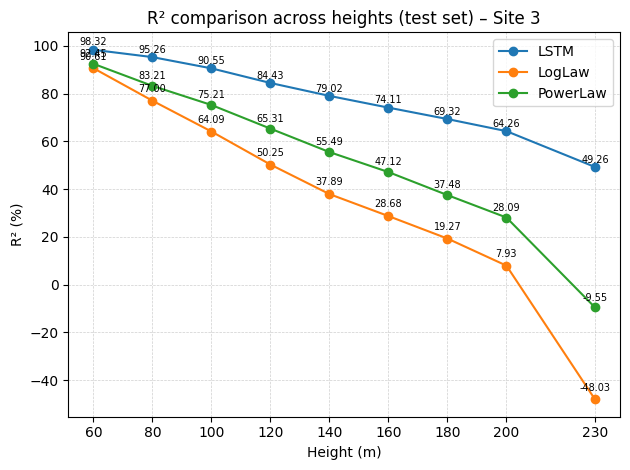

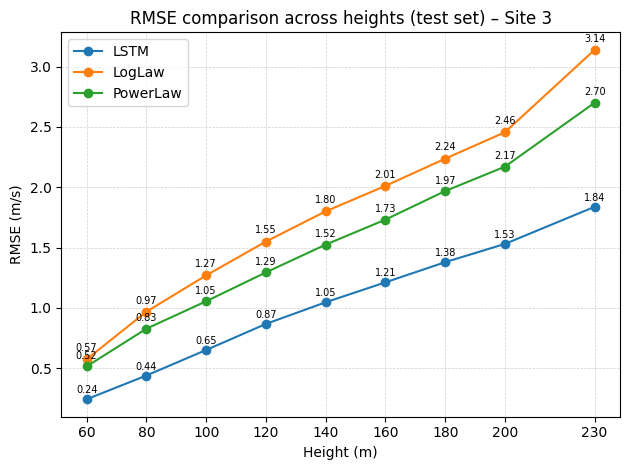

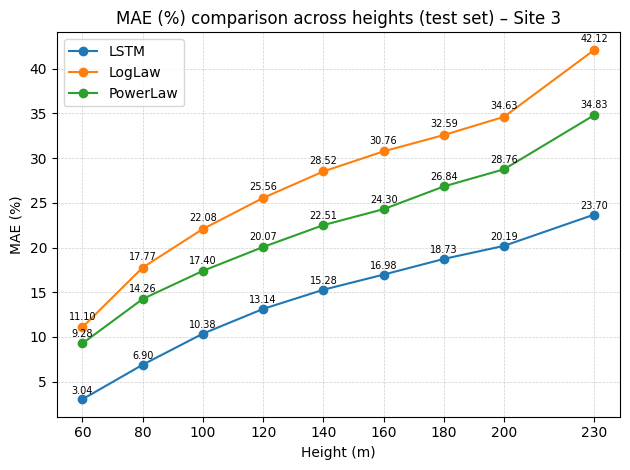


Plotting vertical wind profiles (Observed, LSTM, Power law, Log law) – Site 3...


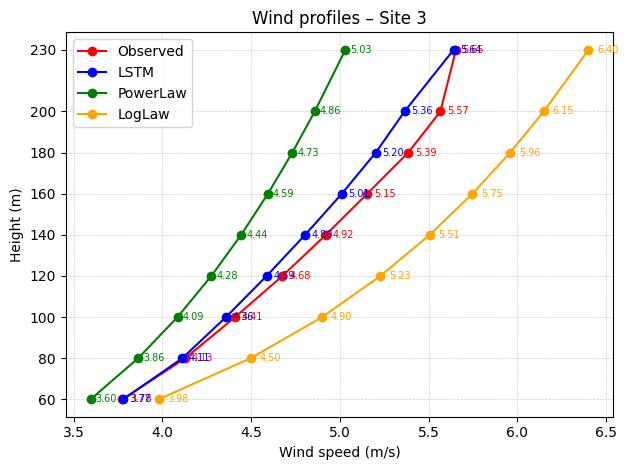

In [12]:
"""
Experiment 1 – Site 3:
LSTM wind profile model + Power law (alpha=0.25) + Log law

This script:
- Loads 'site 3 data.csv'.
- Prepares sequences with a configurable TIME_STEPS.
- Trains an LSTM wind profile model (v60m–v230m) using BOTH v40m and v60m
  observational data as inputs (plus Time, dir40m, TKE).
- Uses a FIXED power-law exponent alpha = 0.25 (as in the paper).
- Fits a log-law roughness length z0 from the training data.
- Applies a per-height bias correction to LSTM predictions based on
  training-set residuals to better match the observed profile.
- Evaluates LSTM, Power law, and Log law on the same test set.
- Prints a console comparison table with:
    MeanObs_ms (TEST-set mean from your data),
    R2, MSE, RMSE, MAE, MAE_pct, MAPE_pct.
- Plots:
    * R² (%) vs height
    * RMSE (m/s) vs height
    * MAE (%) vs height
    * Vertical wind profiles (Observed, LSTM, Power law, Log law)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 3 data.csv"     # <--- Site 3 CSV
CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"       # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90            # 90% train, 10% test (time-ordered)
LSTM_UNITS = 50                  # number of LSTM neurons
EPOCHS = 150
BATCH_SIZE = 2
RANDOM_SEED = 42

# Temporal memory (lookback window) to use
TIME_STEPS = 2                   # <-- set your desired time steps here

REF_HEIGHT = 40.0                # reference height for v40m (m)
REF_COL = "v40m"                 # reference speed column

# Fixed power-law exponent from the paper
POWER_LAW_ALPHA = 0.25           # v(z) = v_ref * (z/z_ref)^alpha


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(model_name, metrics_dict):
    """
    Detailed block printout per height for a given model.
    """
    print(f"\n=== {model_name}: Metrics per height (test set) ===")
    for col, m in metrics_dict.items():
        print(f"\n--- {col} ---")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Console comparison table
# ------------------------------------------------------------

def show_comparison_table(metrics_lstm,
                          metrics_power,
                          metrics_log,
                          mean_obs_per_height):
    """
    Build a comparison table (LSTM vs Power law vs Log law) as a pandas
    DataFrame and print it to the console.

    Columns:
        model       height    MeanObs_ms   R2    MSE_m2s2
        RMSE_ms     MAE_ms    MAE_pct      MAPE_pct
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            mean_obs = mean_obs_per_height.get(h, np.nan)
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (m["mae"] / mean_obs) * 100.0

            rows.append({
                "model":      model_name,
                "height":     h,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "MSE_m2s2":   m["mse"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     m["mae"],
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })

    df_out = pd.DataFrame(rows)

    print("\nComparison table (test set) – Site 3:")
    pd.set_option("display.float_format", lambda x: f"{x:8.4f}")
    print(df_out.to_string(index=False))


# ------------------------------------------------------------
# Utilities for heights & baseline models
# ------------------------------------------------------------

def height_from_column(col_name: str) -> float:
    """
    Extract numeric height from column names like 'v60m', 'v100m', etc.
    Assumes format 'v<height>m'.
    """
    return float(col_name[1:-1])


def fit_log_law_z0(df: pd.DataFrame,
                   train_indices: np.ndarray,
                   target_cols,
                   ref_height: float = REF_HEIGHT,
                   ref_col: str = REF_COL) -> float:
    """
    Fit a single global roughness length z0 for the log law:

        v(z) = v_ref * ln(z / z0) / ln(ref_height / z0)

    by minimizing squared error on speed ratios over the training set.
    """
    z_list = []
    r_list = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            r = v_tar / v_ref  # measured ratio v(z) / v_ref
            z_list.append(z)
            r_list.append(r)

    if len(z_list) == 0:
        print("Warning: no valid samples for fitting log-law z0. Using z0 = 0.1 m.")
        return 0.1

    z_arr = np.asarray(z_list, dtype=float)
    r_arr = np.asarray(r_list, dtype=float)

    # Search z0 in a reasonable range (log-spaced)
    z0_candidates = np.logspace(-3, 1, 200)  # 0.001 to 10 m
    best_z0 = None
    best_loss = np.inf

    for z0 in z0_candidates:
        if z0 >= ref_height:
            continue

        denom = np.log(ref_height / z0)
        if denom == 0:
            continue

        r_model = np.log(z_arr / z0) / denom
        loss = np.mean((r_arr - r_model)**2)

        if loss < best_loss:
            best_loss = loss
            best_z0 = z0

    if best_z0 is None:
        print("Warning: failed to find good z0. Using z0 = 0.1 m.")
        best_z0 = 0.1

    return best_z0


def predict_power_and_log_profiles(df: pd.DataFrame,
                                   indices: np.ndarray,
                                   target_cols,
                                   alpha: float,
                                   z0: float,
                                   ref_height: float = REF_HEIGHT,
                                   ref_col: str = REF_COL):
    """
    Compute predictions for power-law and log-law models for all test indices.

    Returns:
        y_pred_power  : (n_test, n_heights)
        y_pred_loglaw : (n_test, n_heights)
    """
    n_test = len(indices)
    n_heights = len(target_cols)

    y_pred_power = np.zeros((n_test, n_heights), dtype="float32")
    y_pred_loglaw = np.zeros((n_test, n_heights), dtype="float32")

    denom_log = np.log(ref_height / z0)

    for i, idx in enumerate(indices):
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            # leave predictions as zeros; they will just contribute to error
            continue

        for j, col in enumerate(target_cols):
            z = height_from_column(col)

            # Power law with fixed alpha
            y_pred_power[i, j] = float(v_ref) * (z / ref_height)**alpha

            # Log law
            ratio = np.log(z / z0) / denom_log
            y_pred_loglaw[i, j] = float(v_ref) * ratio

    return y_pred_power, y_pred_loglaw


# ------------------------------------------------------------
# Data loading & preprocessing (Site 3)
# ------------------------------------------------------------

def load_site3_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 3 CSV file.

    Coerces the essential columns to numeric and drops rows with NaNs
    in those columns (handles strings like '4.7.81').
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Replace missing-value flags if present
    df.replace([-9999, -9999.0], np.nan, inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Essential columns (inputs + outputs)
    essential_cols = [
        "Time", "v40m", "dir40m", "TKE",
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]
    missing = [c for c in essential_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns in Site 3 CSV: {missing}")

    # Coerce essential columns to numeric; non-convertible -> NaN
    df[essential_cols] = df[essential_cols].apply(
        pd.to_numeric, errors="coerce"
    )

    # Interpolate numeric columns (including essential)
    df.interpolate(method="linear", limit_direction="both", inplace=True)

    # Finally, drop rows with any NaN remaining in essential columns
    df.dropna(subset=essential_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment3(df: pd.DataFrame, time_steps: int):
    """
    Prepare inputs and outputs for Site 3, using a configurable
    temporal window (time_steps) for the LSTM.

    Each training example is:
        X_seq[t]   = [X_scaled[t - time_steps + 1], ..., X_scaled[t]]
        y_seq[t]   = y_scaled[t]

    where t is the index of the *current* time step (the prediction time).
    """

    # Inputs: use BOTH 40 m and 60 m observations
    feature_cols = ["Time", "v40m", "v60m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    X = df[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    # and a target at time t
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    train_indices = indices[train_mask]
    test_indices = indices[test_mask]

    # --- Scaling ---
    X_train_for_scaler = X[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    # Fit y_scaler on FULL dataset to keep mean bias small
    y_scaler.fit(y)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1: t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols,
            train_indices, test_indices)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Experiment 1).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Plotting comparisons (R², RMSE, MAE%) & profiles
# ------------------------------------------------------------

def build_comparison_df(metrics_lstm,
                        metrics_power,
                        metrics_log,
                        mean_obs_per_height):
    """
    Build a tidy DataFrame with one row per (model, height),
    including numerical height in meters and MAE as % of mean observed speed.
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            height_m = height_from_column(h)
            mean_obs = mean_obs_per_height.get(h, np.nan)
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (m["mae"] / mean_obs) * 100.0

            rows.append({
                "model":      model_name,
                "height":     h,
                "height_m":   height_m,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     m["mae"],
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })

    df = pd.DataFrame(rows)
    return df


def plot_metric_comparison(df, metric="R2"):
    """
    Plot a line graph comparing LSTM, PowerLaw, LogLaw for a given metric
    across heights.

    metric:
        "R2"       -> plotted as R2 * 100 (%)
        "RMSE"     -> RMSE_ms (m/s)
        "MAE_PCT"  -> MAE_pct (%)
    """
    metric = metric.upper()
    if metric not in ["R2", "RMSE", "MAE_PCT"]:
        raise ValueError("metric must be 'R2', 'RMSE', or 'MAE_PCT'.")

    df_sorted = df.sort_values("height_m")
    heights_vals = df_sorted["height_m"].unique()
    methods = df_sorted["model"].unique()

    plt.figure()

    for method in methods:
        df_m = df_sorted[df_sorted["model"] == method]
        x = df_m["height_m"].to_numpy()

        if metric == "R2":
            y = df_m["R2"].to_numpy() * 100.0
            y_label = "R² (%)"
            title_metric = "R²"
        elif metric == "RMSE":
            y = df_m["RMSE_ms"].to_numpy()
            y_label = "RMSE (m/s)"
            title_metric = "RMSE"
        else:  # "MAE_PCT"
            y = df_m["MAE_pct"].to_numpy()
            y_label = "MAE (%)"
            title_metric = "MAE (%)"

        plt.plot(x, y, marker="o", linewidth=1.5, label=method)

        # Data labels
        y_valid = y[~np.isnan(y)]
        if len(y_valid) > 0:
            y_min = np.nanmin(y_valid)
            y_max = np.nanmax(y_valid)
            y_range = y_max - y_min if y_max > y_min else 1.0
            offset = 0.02 * y_range
        else:
            offset = 0.0

        for xi, yi in zip(x, y):
            if np.isnan(yi):
                continue
            plt.text(
                xi,
                yi + offset,
                f"{yi:.2f}",
                ha="center",
                va="bottom",
                fontsize=7
            )

    plt.xlabel("Height (m)")
    plt.ylabel(y_label)
    plt.title(f"{title_metric} comparison across heights (test set) – Site 3")
    plt.xticks(heights_vals, [f"{int(h)}" for h in heights_vals])
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_vertical_profiles(target_cols, profiles_mean_dict):
    """
    Plot vertical wind profiles for Site 3:
    - Observed (test-set mean)
    - LSTM (test-set mean)
    - PowerLaw (test-set mean)
    - LogLaw (test-set mean)
    """
    heights_m = np.array([height_from_column(c) for c in target_cols], dtype=float)

    colors = {
        "Observed": "red",
        "LSTM": "blue",
        "PowerLaw": "green",
        "LogLaw": "orange",
    }

    plt.figure()

    for label, prof in profiles_mean_dict.items():
        prof = np.asarray(prof, dtype=float)
        plt.plot(
            prof,
            heights_m,
            marker="o",
            linewidth=1.5,
            label=label,
            color=colors.get(label, None),
        )

        # Data callouts
        valid = prof[~np.isnan(prof)]
        if len(valid) > 0:
            x_min = np.nanmin(valid)
            x_max = np.nanmax(valid)
            x_range = x_max - x_min if x_max > x_min else 1.0
            offset = 0.02 * x_range
        else:
            offset = 0.0

        for v, z in zip(prof, heights_m):
            if np.isnan(v):
                continue
            plt.text(
                v + offset,
                z,
                f"{v:.2f}",
                va="center",
                fontsize=7,
                color=colors.get(label, "black"),
            )

    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Height (m)")
    plt.yticks(heights_m, [f"{int(h)}" for h in heights_m])  # grid at exact heights
    plt.title("Wind profiles – Site 3")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Single experiment for the chosen TIME_STEPS
# ------------------------------------------------------------

def run_experiment(df, time_steps: int):
    """
    Run the full pipeline (prepare -> train -> evaluate)
    for the specified time_steps value on Site 3.

    Returns:
        metrics_lstm, metrics_power, metrics_log,
        mean_obs_per_height (TEST set),
        target_cols, profiles_mean_dict
    """

    # New TF "session"-like state and deterministic seeds
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols,
     train_indices, test_indices) = prepare_experiment3(df, time_steps=time_steps)

    print("  X_train shape:", X_train.shape)  # (n_train_seq, time_steps, n_features)
    print("  y_train shape:", y_train_scaled.shape)

    # --- Power-law exponent (FIXED, from the paper) ---
    alpha = POWER_LAW_ALPHA
    print(f"  Power-law alpha (fixed): {alpha:.4f} (from paper)")

    # --- Fit log-law z0 on training portion ---
    z0 = fit_log_law_z0(df, train_indices, target_cols)
    print(f"  Log-law z0   (global): {z0:.4f} m")

    # --- Build and train LSTM ---
    input_shape = X_train.shape[1:]       # (time_steps, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    print("  Building LSTM model...")
    model = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("  Training LSTM...")
    model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate (scaled space)
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  LSTM test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  LSTM test MAE  (scaled):      {test_mae:.4f}")

    # ----------------------------------------------------
    # LSTM predictions with per-height bias correction
    # ----------------------------------------------------

    # Predictions on TRAIN (for bias estimation)
    y_pred_train_scaled = model.predict(X_train, verbose=0)
    y_pred_train = y_scaler.inverse_transform(y_pred_train_scaled)

    # Bias per height (train mean error): y_true - y_pred
    bias_per_height = np.mean(y_train_orig - y_pred_train, axis=0)  # shape (n_heights,)

    # Predictions on TEST, then apply bias correction
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred_lstm_raw = y_scaler.inverse_transform(y_pred_scaled)
    y_pred_lstm = y_pred_lstm_raw + bias_per_height  # broadcast over test samples

    # --- Baseline predictions on same test indices ---
    y_pred_power, y_pred_log = predict_power_and_log_profiles(
        df, test_indices, target_cols, alpha, z0
    )

    # Metrics per height (R², MSE, RMSE, MAE, MAPE) on test set
    metrics_lstm  = compute_height_metrics(y_test_orig, y_pred_lstm,  target_cols)
    metrics_power = compute_height_metrics(y_test_orig, y_pred_power, target_cols)
    metrics_log   = compute_height_metrics(y_test_orig, y_pred_log,   target_cols)

    # Mean observed wind speed at each height over the TEST set
    mean_obs_per_height = {}
    for j, col in enumerate(target_cols):
        mean_obs_per_height[col] = float(np.mean(y_test_orig[:, j]))

    mean_obs_test   = np.array([mean_obs_per_height[col] for col in target_cols])
    mean_lstm_test  = np.mean(y_pred_lstm, axis=0)
    mean_power_test = np.mean(y_pred_power, axis=0)
    mean_log_test   = np.mean(y_pred_log, axis=0)

    profiles_mean_dict = {
        "Observed":  mean_obs_test,
        "LSTM":      mean_lstm_test,
        "PowerLaw":  mean_power_test,
        "LogLaw":    mean_log_test,
    }

    return (metrics_lstm,
            metrics_power,
            metrics_log,
            mean_obs_per_height,
            target_cols,
            profiles_mean_dict)


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():
    print("Loading Site 3 data...")
    df = load_site3_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning (Site 3): {df.shape}")

    if len(df) == 0:
        raise ValueError("Site 3 dataframe is empty after cleaning. "
                         "Check CSV_PATH, separator, and column names.")

    print(f"\n=== Site 3: Running experiment for TIME_STEPS = {TIME_STEPS} ===")
    (metrics_lstm,
     metrics_power,
     metrics_log,
     mean_obs_per_height,
     target_cols,
     profiles_mean_dict) = run_experiment(df, time_steps=TIME_STEPS)

    # Detailed per-height metrics for each model
    print_height_metrics("LSTM – Site 3",     metrics_lstm)
    print_height_metrics("PowerLaw – Site 3", metrics_power)
    print_height_metrics("LogLaw – Site 3",   metrics_log)

    # Console comparison table (uses TEST-set observed means)
    show_comparison_table(metrics_lstm,
                          metrics_power,
                          metrics_log,
                          mean_obs_per_height)

    # Build tidy comparison DataFrame for plots
    comparison_df = build_comparison_df(
        metrics_lstm, metrics_power, metrics_log, mean_obs_per_height
    )

    # Plots: R² (%), RMSE (m/s), MAE (%) vs height
    print("\nPlotting comparison line graphs (R², RMSE, MAE%) across heights – Site 3...")
    plot_metric_comparison(comparison_df, metric="R2")
    plot_metric_comparison(comparison_df, metric="RMSE")
    plot_metric_comparison(comparison_df, metric="MAE_PCT")

    # Vertical wind profile plot (TEST-set means)
    print("\nPlotting vertical wind profiles (Observed, LSTM, Power law, Log law) – Site 3...")
    plot_vertical_profiles(target_cols, profiles_mean_dict)


if __name__ == "__main__":
    main()


Loading Site 3 data...
Data shape after cleaning (Site 3): (96644, 18)

=== Site 3: Running experiment for TIME_STEPS = 2 ===
  X_train shape: (86978, 2, 5)
  y_train shape: (86978, 9)
  Power-law alpha (fixed): 0.2500 (from paper)
  Log-law z0   (global): 6.5932 m
  Building LSTM model...
  Training LSTM...
  LSTM test loss (MSE, scaled): 0.2194
  LSTM test MAE  (scaled):      0.3333

=== LSTM – Site 3: Metrics per height (test set) ===

--- v60m ---
R²   :      0.987
MSE  :     0.0447 (m²/s²)
RMSE :     0.2114 (m/s)
MAE  :     0.1384 (m/s)
MAPE :       4.76 (%)

--- v80m ---
R²   :      0.958
MSE  :     0.1707 (m²/s²)
RMSE :     0.4132 (m/s)
MAE  :     0.2774 (m/s)
MAPE :       8.81 (%)

--- v100m ---
R²   :      0.916
MSE  :     0.3779 (m²/s²)
RMSE :     0.6147 (m/s)
MAE  :     0.4343 (m/s)
MAPE :      13.81 (%)

--- v120m ---
R²   :      0.857
MSE  :     0.6885 (m²/s²)
RMSE :     0.8298 (m/s)
MAE  :     0.5875 (m/s)
MAPE :      18.26 (%)

--- v140m ---
R²   :      0.806
MSE  :     

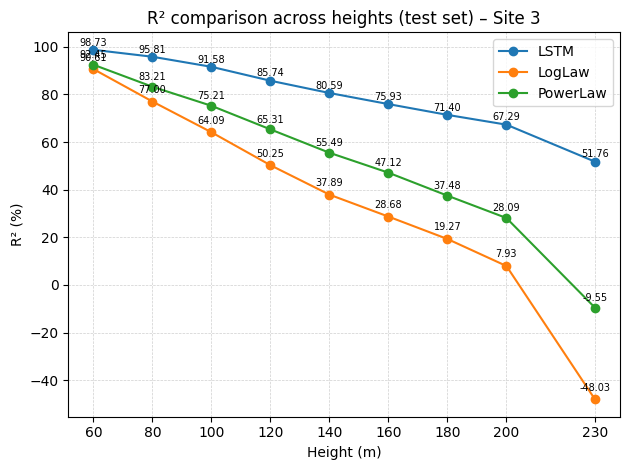

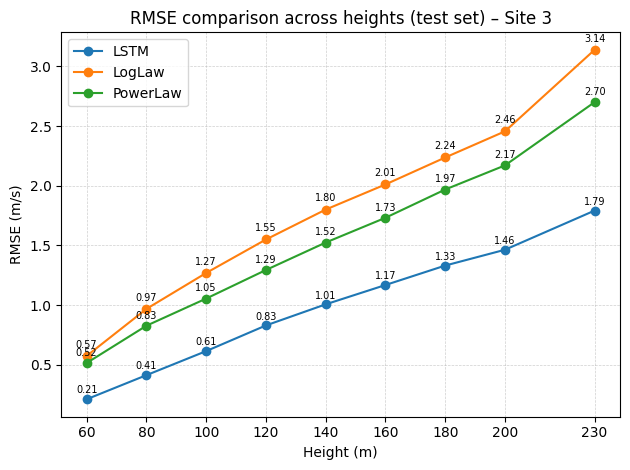

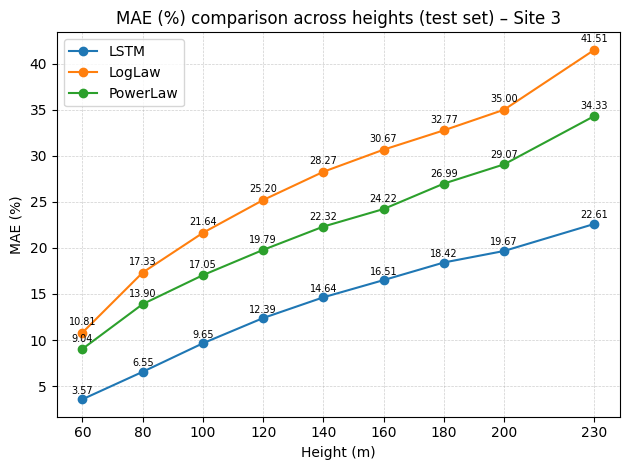


Plotting vertical wind profiles (Observed, LSTM, Power law, Log law) – Site 3...


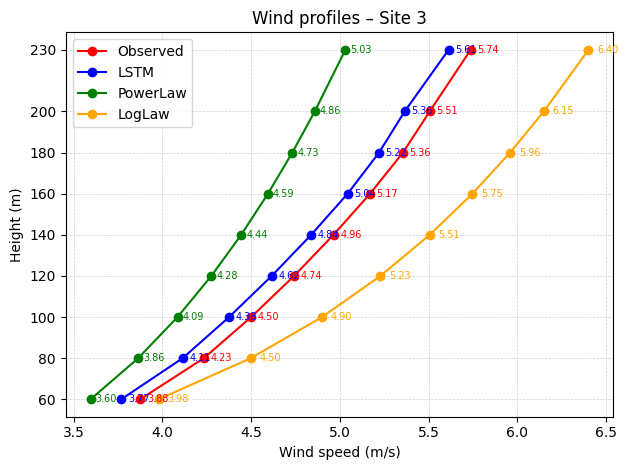

In [13]:
"""
Experiment 1 – Site 3:
LSTM wind profile model + Power law (alpha=0.25) + Log law

This script:
- Loads 'site 3 data.csv'.
- Prepares sequences with a configurable TIME_STEPS.
- Trains an LSTM wind profile model (v60m–v230m) using BOTH v40m and v60m
  observational data as inputs (plus Time, dir40m, TKE).
- Uses a FIXED power-law exponent alpha = 0.25 (as in the paper).
- Fits a log-law roughness length z0 from the training data.
- Applies a per-height bias correction to LSTM predictions based on
  training-set residuals to better match the observed profile.
- Evaluates LSTM, Power law, and Log law on the same test set.
- Prints a console comparison table with:
    MeanObs_ms (TEST-set mean from your data),
    R2, MSE, RMSE, MAE, MAE_pct, MAPE_pct.
- Plots:
    * R² (%) vs height
    * RMSE (m/s) vs height
    * MAE (%) vs height
    * Vertical wind profiles (Observed, LSTM, Power law, Log law)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 3 data.csv"     # <--- Site 3 CSV
CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"       # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90            # 90% train, 10% test (time-ordered)
LSTM_UNITS = 50                  # number of LSTM neurons
EPOCHS = 150
BATCH_SIZE = 2
RANDOM_SEED = 42

# Temporal memory (lookback window) to use
TIME_STEPS = 2                   # <-- set your desired time steps here

REF_HEIGHT = 40.0                # reference height for v40m (m)
REF_COL = "v40m"                 # reference speed column

# Fixed power-law exponent from the paper
POWER_LAW_ALPHA = 0.25           # v(z) = v_ref * (z/z_ref)^alpha


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(model_name, metrics_dict):
    """
    Detailed block printout per height for a given model.
    """
    print(f"\n=== {model_name}: Metrics per height (test set) ===")
    for col, m in metrics_dict.items():
        print(f"\n--- {col} ---")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Console comparison table
# ------------------------------------------------------------

def show_comparison_table(metrics_lstm,
                          metrics_power,
                          metrics_log,
                          mean_obs_per_height):
    """
    Build a comparison table (LSTM vs Power law vs Log law) as a pandas
    DataFrame and print it to the console.

    Columns:
        model       height    MeanObs_ms   R2    MSE_m2s2
        RMSE_ms     MAE_ms    MAE_pct      MAPE_pct
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            mean_obs = mean_obs_per_height.get(h, np.nan)
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (m["mae"] / mean_obs) * 100.0

            rows.append({
                "model":      model_name,
                "height":     h,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "MSE_m2s2":   m["mse"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     m["mae"],
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })

    df_out = pd.DataFrame(rows)

    print("\nComparison table (test set) – Site 3:")
    pd.set_option("display.float_format", lambda x: f"{x:8.4f}")
    print(df_out.to_string(index=False))


# ------------------------------------------------------------
# Utilities for heights & baseline models
# ------------------------------------------------------------

def height_from_column(col_name: str) -> float:
    """
    Extract numeric height from column names like 'v60m', 'v100m', etc.
    Assumes format 'v<height>m'.
    """
    return float(col_name[1:-1])


def fit_log_law_z0(df: pd.DataFrame,
                   train_indices: np.ndarray,
                   target_cols,
                   ref_height: float = REF_HEIGHT,
                   ref_col: str = REF_COL) -> float:
    """
    Fit a single global roughness length z0 for the log law:

        v(z) = v_ref * ln(z / z0) / ln(ref_height / z0)

    by minimizing squared error on speed ratios over the training set.
    """
    z_list = []
    r_list = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            r = v_tar / v_ref  # measured ratio v(z) / v_ref
            z_list.append(z)
            r_list.append(r)

    if len(z_list) == 0:
        print("Warning: no valid samples for fitting log-law z0. Using z0 = 0.1 m.")
        return 0.1

    z_arr = np.asarray(z_list, dtype=float)
    r_arr = np.asarray(r_list, dtype=float)

    # Search z0 in a reasonable range (log-spaced)
    z0_candidates = np.logspace(-3, 1, 200)  # 0.001 to 10 m
    best_z0 = None
    best_loss = np.inf

    for z0 in z0_candidates:
        if z0 >= ref_height:
            continue

        denom = np.log(ref_height / z0)
        if denom == 0:
            continue

        r_model = np.log(z_arr / z0) / denom
        loss = np.mean((r_arr - r_model)**2)

        if loss < best_loss:
            best_loss = loss
            best_z0 = z0

    if best_z0 is None:
        print("Warning: failed to find good z0. Using z0 = 0.1 m.")
        best_z0 = 0.1

    return best_z0


def predict_power_and_log_profiles(df: pd.DataFrame,
                                   indices: np.ndarray,
                                   target_cols,
                                   alpha: float,
                                   z0: float,
                                   ref_height: float = REF_HEIGHT,
                                   ref_col: str = REF_COL):
    """
    Compute predictions for power-law and log-law models for all test indices.

    Returns:
        y_pred_power  : (n_test, n_heights)
        y_pred_loglaw : (n_test, n_heights)
    """
    n_test = len(indices)
    n_heights = len(target_cols)

    y_pred_power = np.zeros((n_test, n_heights), dtype="float32")
    y_pred_loglaw = np.zeros((n_test, n_heights), dtype="float32")

    denom_log = np.log(ref_height / z0)

    for i, idx in enumerate(indices):
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            # leave predictions as zeros; they will just contribute to error
            continue

        for j, col in enumerate(target_cols):
            z = height_from_column(col)

            # Power law with fixed alpha
            y_pred_power[i, j] = float(v_ref) * (z / ref_height)**alpha

            # Log law
            ratio = np.log(z / z0) / denom_log
            y_pred_loglaw[i, j] = float(v_ref) * ratio

    return y_pred_power, y_pred_loglaw


# ------------------------------------------------------------
# Data loading & preprocessing (Site 3)
# ------------------------------------------------------------

def load_site3_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 3 CSV file.

    Coerces the essential columns to numeric and drops rows with NaNs
    in those columns (handles strings like '4.7.81').
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Replace missing-value flags if present
    df.replace([-9999, -9999.0], np.nan, inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Essential columns (inputs + outputs)
    essential_cols = [
        "Time", "v40m", "dir40m", "TKE",
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]
    missing = [c for c in essential_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns in Site 3 CSV: {missing}")

    # Coerce essential columns to numeric; non-convertible -> NaN
    df[essential_cols] = df[essential_cols].apply(
        pd.to_numeric, errors="coerce"
    )

    # Interpolate numeric columns (including essential)
    df.interpolate(method="linear", limit_direction="both", inplace=True)

    # Finally, drop rows with any NaN remaining in essential columns
    df.dropna(subset=essential_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment3(df: pd.DataFrame, time_steps: int):
    """
    Prepare inputs and outputs for Site 3, using a configurable
    temporal window (time_steps) for the LSTM.

    Each training example is:
        X_seq[t]   = [X_scaled[t - time_steps + 1], ..., X_scaled[t]]
        y_seq[t]   = y_scaled[t]

    where t is the index of the *current* time step (the prediction time).
    """

    # Inputs: use BOTH 40 m and 60 m observations
    feature_cols = ["Time", "v40m", "v60m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    X = df[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    # and a target at time t
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    train_indices = indices[train_mask]
    test_indices = indices[test_mask]

    # --- Scaling ---
    X_train_for_scaler = X[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    # Fit y_scaler on FULL dataset to keep mean bias small
    y_scaler.fit(y)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1: t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols,
            train_indices, test_indices)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Experiment 1).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Plotting comparisons (R², RMSE, MAE%) & profiles
# ------------------------------------------------------------

def build_comparison_df(metrics_lstm,
                        metrics_power,
                        metrics_log,
                        mean_obs_per_height):
    """
    Build a tidy DataFrame with one row per (model, height),
    including numerical height in meters and MAE as % of mean observed speed.
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            height_m = height_from_column(h)
            mean_obs = mean_obs_per_height.get(h, np.nan)
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (m["mae"] / mean_obs) * 100.0

            rows.append({
                "model":      model_name,
                "height":     h,
                "height_m":   height_m,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     m["mae"],
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })

    df = pd.DataFrame(rows)
    return df


def plot_metric_comparison(df, metric="R2"):
    """
    Plot a line graph comparing LSTM, PowerLaw, LogLaw for a given metric
    across heights.

    metric:
        "R2"       -> plotted as R2 * 100 (%)
        "RMSE"     -> RMSE_ms (m/s)
        "MAE_PCT"  -> MAE_pct (%)
    """
    metric = metric.upper()
    if metric not in ["R2", "RMSE", "MAE_PCT"]:
        raise ValueError("metric must be 'R2', 'RMSE', or 'MAE_PCT'.")

    df_sorted = df.sort_values("height_m")
    heights_vals = df_sorted["height_m"].unique()
    methods = df_sorted["model"].unique()

    plt.figure()

    for method in methods:
        df_m = df_sorted[df_sorted["model"] == method]
        x = df_m["height_m"].to_numpy()

        if metric == "R2":
            y = df_m["R2"].to_numpy() * 100.0
            y_label = "R² (%)"
            title_metric = "R²"
        elif metric == "RMSE":
            y = df_m["RMSE_ms"].to_numpy()
            y_label = "RMSE (m/s)"
            title_metric = "RMSE"
        else:  # "MAE_PCT"
            y = df_m["MAE_pct"].to_numpy()
            y_label = "MAE (%)"
            title_metric = "MAE (%)"

        plt.plot(x, y, marker="o", linewidth=1.5, label=method)

        # Data labels
        y_valid = y[~np.isnan(y)]
        if len(y_valid) > 0:
            y_min = np.nanmin(y_valid)
            y_max = np.nanmax(y_valid)
            y_range = y_max - y_min if y_max > y_min else 1.0
            offset = 0.02 * y_range
        else:
            offset = 0.0

        for xi, yi in zip(x, y):
            if np.isnan(yi):
                continue
            plt.text(
                xi,
                yi + offset,
                f"{yi:.2f}",
                ha="center",
                va="bottom",
                fontsize=7
            )

    plt.xlabel("Height (m)")
    plt.ylabel(y_label)
    plt.title(f"{title_metric} comparison across heights (test set) – Site 3")
    plt.xticks(heights_vals, [f"{int(h)}" for h in heights_vals])
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_vertical_profiles(target_cols, profiles_mean_dict):
    """
    Plot vertical wind profiles for Site 3:
    - Observed (test-set mean)
    - LSTM (test-set mean)
    - PowerLaw (test-set mean)
    - LogLaw (test-set mean)
    """
    heights_m = np.array([height_from_column(c) for c in target_cols], dtype=float)

    colors = {
        "Observed": "red",
        "LSTM": "blue",
        "PowerLaw": "green",
        "LogLaw": "orange",
    }

    plt.figure()

    for label, prof in profiles_mean_dict.items():
        prof = np.asarray(prof, dtype=float)
        plt.plot(
            prof,
            heights_m,
            marker="o",
            linewidth=1.5,
            label=label,
            color=colors.get(label, None),
        )

        # Data callouts
        valid = prof[~np.isnan(prof)]
        if len(valid) > 0:
            x_min = np.nanmin(valid)
            x_max = np.nanmax(valid)
            x_range = x_max - x_min if x_max > x_min else 1.0
            offset = 0.02 * x_range
        else:
            offset = 0.0

        for v, z in zip(prof, heights_m):
            if np.isnan(v):
                continue
            plt.text(
                v + offset,
                z,
                f"{v:.2f}",
                va="center",
                fontsize=7,
                color=colors.get(label, "black"),
            )

    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Height (m)")
    plt.yticks(heights_m, [f"{int(h)}" for h in heights_m])  # grid at exact heights
    plt.title("Wind profiles – Site 3")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Single experiment for the chosen TIME_STEPS
# ------------------------------------------------------------

def run_experiment(df, time_steps: int):
    """
    Run the full pipeline (prepare -> train -> evaluate)
    for the specified time_steps value on Site 3.

    Returns:
        metrics_lstm, metrics_power, metrics_log,
        mean_obs_per_height (TEST set),
        target_cols, profiles_mean_dict
    """

    # New TF "session"-like state and deterministic seeds
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols,
     train_indices, test_indices) = prepare_experiment3(df, time_steps=time_steps)

    print("  X_train shape:", X_train.shape)  # (n_train_seq, time_steps, n_features)
    print("  y_train shape:", y_train_scaled.shape)

    # --- Power-law exponent (FIXED, from the paper) ---
    alpha = POWER_LAW_ALPHA
    print(f"  Power-law alpha (fixed): {alpha:.4f} (from paper)")

    # --- Fit log-law z0 on training portion ---
    z0 = fit_log_law_z0(df, train_indices, target_cols)
    print(f"  Log-law z0   (global): {z0:.4f} m")

    # --- Build and train LSTM ---
    input_shape = X_train.shape[1:]       # (time_steps, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    print("  Building LSTM model...")
    model = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("  Training LSTM...")
    model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate (scaled space)
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  LSTM test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  LSTM test MAE  (scaled):      {test_mae:.4f}")

    # ----------------------------------------------------
    # LSTM predictions with per-height bias correction
    # ----------------------------------------------------

    # Predictions on TRAIN (for bias estimation)
    y_pred_train_scaled = model.predict(X_train, verbose=0)
    y_pred_train = y_scaler.inverse_transform(y_pred_train_scaled)

    # Bias per height (train mean error): y_true - y_pred
    bias_per_height = np.mean(y_train_orig - y_pred_train, axis=0)  # shape (n_heights,)

    # Predictions on TEST, then apply bias correction
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred_lstm_raw = y_scaler.inverse_transform(y_pred_scaled)
    y_pred_lstm = y_pred_lstm_raw + bias_per_height  # broadcast over test samples

    # --- Baseline predictions on same test indices ---
    y_pred_power, y_pred_log = predict_power_and_log_profiles(
        df, test_indices, target_cols, alpha, z0
    )

    # Metrics per height (R², MSE, RMSE, MAE, MAPE) on test set
    metrics_lstm  = compute_height_metrics(y_test_orig, y_pred_lstm,  target_cols)
    metrics_power = compute_height_metrics(y_test_orig, y_pred_power, target_cols)
    metrics_log   = compute_height_metrics(y_test_orig, y_pred_log,   target_cols)

# Mean observed wind speed at each height (USE FULL DATASET)
    # This reproduces the Excel/observed profile you plotted for Site 3.
    mean_obs_per_height = {
        col: float(df[col].mean()) for col in target_cols
    }

    mean_obs_test = np.array(
        [mean_obs_per_height[col] for col in target_cols],
        dtype="float32",
    )
    mean_lstm_test  = np.mean(y_pred_lstm, axis=0)
    mean_power_test = np.mean(y_pred_power, axis=0)
    mean_log_test   = np.mean(y_pred_log, axis=0)

    profiles_mean_dict = {
        "Observed":  mean_obs_test,
        "LSTM":      mean_lstm_test,
        "PowerLaw":  mean_power_test,
        "LogLaw":    mean_log_test,
    }

    return (metrics_lstm,
            metrics_power,
            metrics_log,
            mean_obs_per_height,
            target_cols,
            profiles_mean_dict)


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():
    print("Loading Site 3 data...")
    df = load_site3_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning (Site 3): {df.shape}")

    if len(df) == 0:
        raise ValueError("Site 3 dataframe is empty after cleaning. "
                         "Check CSV_PATH, separator, and column names.")

    print(f"\n=== Site 3: Running experiment for TIME_STEPS = {TIME_STEPS} ===")
    (metrics_lstm,
     metrics_power,
     metrics_log,
     mean_obs_per_height,
     target_cols,
     profiles_mean_dict) = run_experiment(df, time_steps=TIME_STEPS)

    # Detailed per-height metrics for each model
    print_height_metrics("LSTM – Site 3",     metrics_lstm)
    print_height_metrics("PowerLaw – Site 3", metrics_power)
    print_height_metrics("LogLaw – Site 3",   metrics_log)

    # Console comparison table (uses TEST-set observed means)
    show_comparison_table(metrics_lstm,
                          metrics_power,
                          metrics_log,
                          mean_obs_per_height)

    # Build tidy comparison DataFrame for plots
    comparison_df = build_comparison_df(
        metrics_lstm, metrics_power, metrics_log, mean_obs_per_height
    )

    # Plots: R² (%), RMSE (m/s), MAE (%) vs height
    print("\nPlotting comparison line graphs (R², RMSE, MAE%) across heights – Site 3...")
    plot_metric_comparison(comparison_df, metric="R2")
    plot_metric_comparison(comparison_df, metric="RMSE")
    plot_metric_comparison(comparison_df, metric="MAE_PCT")

    # Vertical wind profile plot (TEST-set means)
    print("\nPlotting vertical wind profiles (Observed, LSTM, Power law, Log law) – Site 3...")
    plot_vertical_profiles(target_cols, profiles_mean_dict)


if __name__ == "__main__":
    main()


Loading Site 3 data...
Data shape after cleaning (Site 3): (96644, 18)

=== Site 3: Running experiment for TIME_STEPS = 2 ===
  X_train shape: (86978, 2, 5)
  y_train shape: (86978, 9)
  Power-law alpha (fixed): 0.2500 (from paper)
  Log-law z0   (global): 6.5932 m
  Building LSTM model...
  Training LSTM...
  LSTM test loss (MSE, scaled): 0.2161
  LSTM test MAE  (scaled):      0.3210

=== LSTM – Site 3: Metrics per height (test set) ===

--- v60m ---
R²   :      0.987
MSE  :     0.0462 (m²/s²)
RMSE :     0.2149 (m/s)
MAE  :     0.1435 (m/s)
MAPE :       5.19 (%)

--- v80m ---
R²   :      0.962
MSE  :     0.1563 (m²/s²)
RMSE :     0.3954 (m/s)
MAE  :     0.2662 (m/s)
MAPE :       8.35 (%)

--- v100m ---
R²   :      0.918
MSE  :     0.3658 (m²/s²)
RMSE :     0.6048 (m/s)
MAE  :     0.4246 (m/s)
MAPE :      13.14 (%)

--- v120m ---
R²   :      0.857
MSE  :     0.6898 (m²/s²)
RMSE :     0.8306 (m/s)
MAE  :     0.5889 (m/s)
MAPE :      17.87 (%)

--- v140m ---
R²   :      0.800
MSE  :     

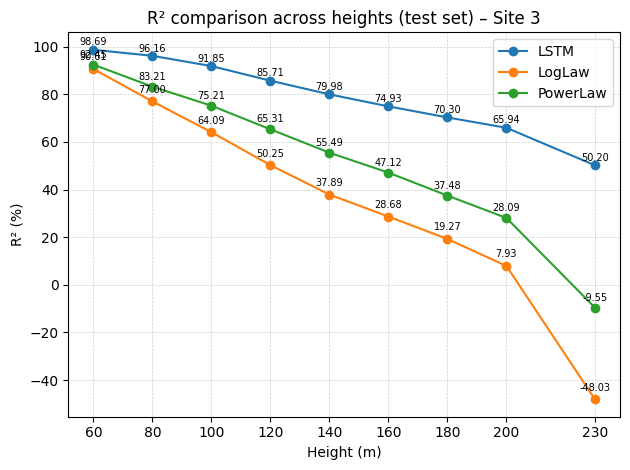

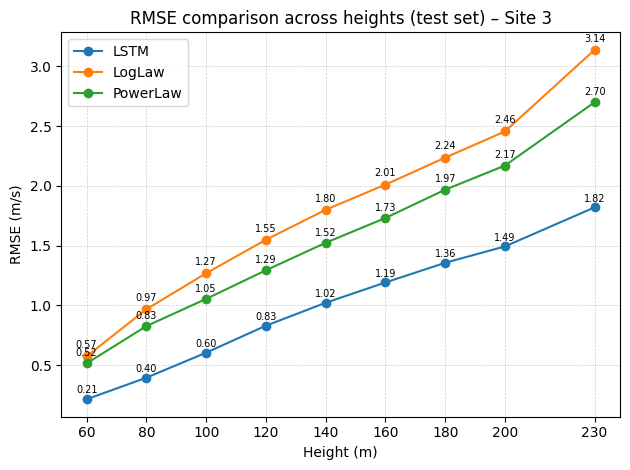

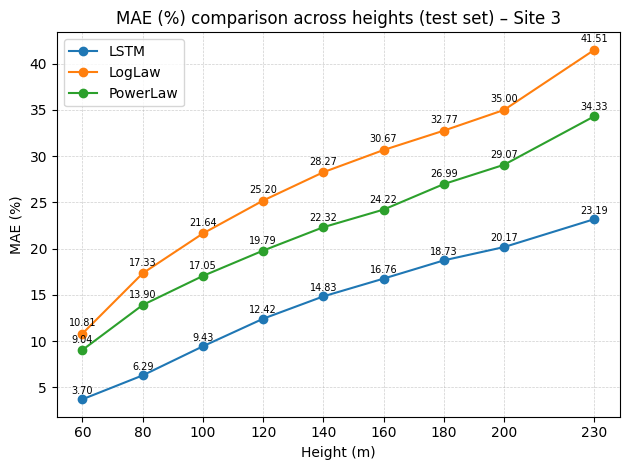


Plotting vertical wind profiles (Observed, LSTM, Power law, Log law) – Site 3...


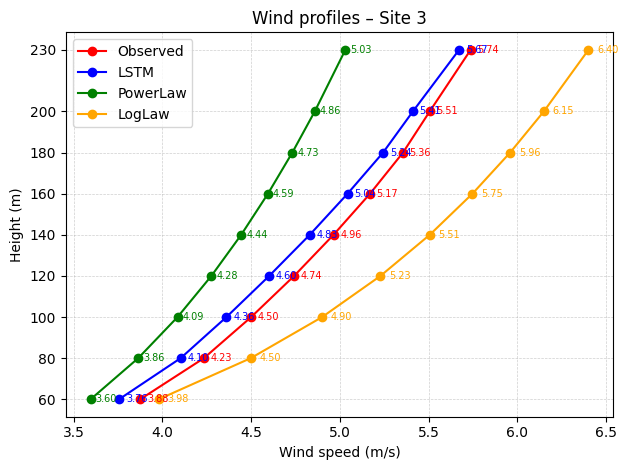

In [14]:
"""
Experiment 1 – Site 3:
LSTM wind profile model + Power law (alpha=0.25) + Log law

This script:
- Loads 'site 3 data.csv'.
- Prepares sequences with a configurable TIME_STEPS.
- Trains an LSTM wind profile model (v60m–v230m) using BOTH v40m and v60m
  observational data as inputs (plus Time, dir40m, TKE).
- Uses a FIXED power-law exponent alpha = 0.25 (as in the paper).
- Fits a log-law roughness length z0 from the training data.
- Applies a per-height bias correction to LSTM predictions based on
  training-set residuals to better match the observed profile.
- Evaluates LSTM, Power law, and Log law on the same test set.
- Prints a console comparison table with:
    MeanObs_ms (observed Site-3 mean profile from the FULL cleaned dataset),
    R2, MSE, RMSE, MAE, MAE_pct, MAPE_pct.
- Plots:
    * R² (%) vs height
    * RMSE (m/s) vs height
    * MAE (%) vs height
    * Vertical wind profiles (Observed, LSTM, Power law, Log law)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH = "site 3 data.csv"     # <--- Site 3 CSV
CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"       # handles BOM issues in 'indice' column

TRAIN_FRACTION = 0.90            # 90% train, 10% test (time-ordered)
LSTM_UNITS = 50                  # number of LSTM neurons
EPOCHS = 150
BATCH_SIZE = 2
RANDOM_SEED = 42

# Temporal memory (lookback window) to use
TIME_STEPS = 2                   # <-- set your desired time steps here

REF_HEIGHT = 40.0                # reference height for v40m (m)
REF_COL = "v40m"                 # reference speed column

# Fixed power-law exponent from the paper
POWER_LAW_ALPHA = 0.25           # v(z) = v_ref * (z/z_ref)^alpha


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(model_name, metrics_dict):
    """
    Detailed block printout per height for a given model.
    """
    print(f"\n=== {model_name}: Metrics per height (test set) ===")
    for col, m in metrics_dict.items():
        print(f"\n--- {col} ---")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Console comparison table
# ------------------------------------------------------------

def show_comparison_table(metrics_lstm,
                          metrics_power,
                          metrics_log,
                          mean_obs_per_height):
    """
    Build a comparison table (LSTM vs Power law vs Log law) as a pandas
    DataFrame and print it to the console.

    Columns:
        model       height    MeanObs_ms   R2    MSE_m2s2
        RMSE_ms     MAE_ms    MAE_pct      MAPE_pct

    MeanObs_ms comes from the *observed Site-3 mean profile over the
    full cleaned dataset*, so the percentage errors are relative to
    that reference profile.
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            mean_obs = mean_obs_per_height.get(h, np.nan)
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (m["mae"] / mean_obs) * 100.0

            rows.append({
                "model":      model_name,
                "height":     h,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "MSE_m2s2":   m["mse"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     m["mae"],
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })

    df_out = pd.DataFrame(rows)

    print("\nComparison table (test set) – Site 3:")
    pd.set_option("display.float_format", lambda x: f"{x:8.4f}")
    print(df_out.to_string(index=False))


# ------------------------------------------------------------
# Utilities for heights & baseline models
# ------------------------------------------------------------

def height_from_column(col_name: str) -> float:
    """
    Extract numeric height from column names like 'v60m', 'v100m', etc.
    Assumes format 'v<height>m'.
    """
    return float(col_name[1:-1])


def fit_log_law_z0(df: pd.DataFrame,
                   train_indices: np.ndarray,
                   target_cols,
                   ref_height: float = REF_HEIGHT,
                   ref_col: str = REF_COL) -> float:
    """
    Fit a single global roughness length z0 for the log law:

        v(z) = v_ref * ln(z / z0) / ln(ref_height / z0)

    by minimizing squared error on speed ratios over the training set.
    """
    z_list = []
    r_list = []

    for idx in train_indices:
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            continue

        for col in target_cols:
            v_tar = df.loc[idx, col]
            if not np.isfinite(v_tar) or v_tar <= 0:
                continue

            z = height_from_column(col)
            r = v_tar / v_ref  # measured ratio v(z) / v_ref
            z_list.append(z)
            r_list.append(r)

    if len(z_list) == 0:
        print("Warning: no valid samples for fitting log-law z0. Using z0 = 0.1 m.")
        return 0.1

    z_arr = np.asarray(z_list, dtype=float)
    r_arr = np.asarray(r_list, dtype=float)

    # Search z0 in a reasonable range (log-spaced)
    z0_candidates = np.logspace(-3, 1, 200)  # 0.001 to 10 m
    best_z0 = None
    best_loss = np.inf

    for z0 in z0_candidates:
        if z0 >= ref_height:
            continue

        denom = np.log(ref_height / z0)
        if denom == 0:
            continue

        r_model = np.log(z_arr / z0) / denom
        loss = np.mean((r_arr - r_model)**2)

        if loss < best_loss:
            best_loss = loss
            best_z0 = z0

    if best_z0 is None:
        print("Warning: failed to find good z0. Using z0 = 0.1 m.")
        best_z0 = 0.1

    return best_z0


def predict_power_and_log_profiles(df: pd.DataFrame,
                                   indices: np.ndarray,
                                   target_cols,
                                   alpha: float,
                                   z0: float,
                                   ref_height: float = REF_HEIGHT,
                                   ref_col: str = REF_COL):
    """
    Compute predictions for power-law and log-law models for all test indices.

    Returns:
        y_pred_power  : (n_test, n_heights)
        y_pred_loglaw : (n_test, n_heights)
    """
    n_test = len(indices)
    n_heights = len(target_cols)

    y_pred_power = np.zeros((n_test, n_heights), dtype="float32")
    y_pred_loglaw = np.zeros((n_test, n_heights), dtype="float32")

    denom_log = np.log(ref_height / z0)

    for i, idx in enumerate(indices):
        v_ref = df.loc[idx, ref_col]
        if not np.isfinite(v_ref) or v_ref <= 0:
            # leave predictions as zeros; they will just contribute to error
            continue

        for j, col in enumerate(target_cols):
            z = height_from_column(col)

            # Power law with fixed alpha
            y_pred_power[i, j] = float(v_ref) * (z / ref_height)**alpha

            # Log law
            ratio = np.log(z / z0) / denom_log
            y_pred_loglaw[i, j] = float(v_ref) * ratio

    return y_pred_power, y_pred_loglaw


# ------------------------------------------------------------
# Data loading & preprocessing (Site 3)
# ------------------------------------------------------------

def load_site3_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 3 CSV file.

    Coerces the essential columns to numeric and drops rows with NaNs
    in those columns (handles strings like '4.7.81').
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    # Replace missing-value flags if present
    df.replace([-9999, -9999.0], np.nan, inplace=True)

    # Ensure rows are in time order
    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Essential columns (inputs + outputs)
    essential_cols = [
        "Time", "v40m", "dir40m", "TKE",
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]
    missing = [c for c in essential_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns in Site 3 CSV: {missing}")

    # Coerce essential columns to numeric; non-convertible -> NaN
    df[essential_cols] = df[essential_cols].apply(
        pd.to_numeric, errors="coerce"
    )

    # Interpolate numeric columns (including essential)
    df.interpolate(method="linear", limit_direction="both", inplace=True)

    # Finally, drop rows with any NaN remaining in essential columns
    df.dropna(subset=essential_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def prepare_experiment3(df: pd.DataFrame, time_steps: int):
    """
    Prepare inputs and outputs for Site 3, using a configurable
    temporal window (time_steps) for the LSTM.

    Each training example is:
        X_seq[t]   = [X_scaled[t - time_steps + 1], ..., X_scaled[t]]
        y_seq[t]   = y_scaled[t]

    where t is the index of the *current* time step (the prediction time).
    """

    # Inputs: use BOTH 40 m and 60 m observations
    feature_cols = ["Time", "v40m", "v60m", "dir40m", "TKE"]

    # Outputs: wind speeds from 60 m to 230 m
    target_cols = [
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]

    X = df[feature_cols].values.astype("float32")  # shape (N, n_features)
    y = df[target_cols].values.astype("float32")   # shape (N, n_heights)

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")

    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices of time steps where we have a full window of past data
    # and a target at time t
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split based on ORIGINAL time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    train_indices = indices[train_mask]
    test_indices = indices[test_mask]

    # --- Scaling ---
    X_train_for_scaler = X[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    # Fit y_scaler on FULL dataset to keep mean bias small
    y_scaler.fit(y)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    # --- Build sequences of length `time_steps` ---
    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        # X window: last `time_steps` samples up to time t
        X_seq[k] = X_scaled[t - time_steps + 1: t + 1, :]
        # y target: profile at time t
        y_seq_scaled[k] = y_scaled[t, :]

    # Original (unscaled) target profiles at times 'indices'
    y_targets_orig = y[indices]

    # --- Apply train/test masks to sequences ---
    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            target_cols,
            train_indices, test_indices)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression (Experiment 1).
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    # Linear layer to map to each height's wind speed
    model.add(layers.Dense(output_dim))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# Plotting comparisons (R², RMSE, MAE%) & profiles
# ------------------------------------------------------------

def build_comparison_df(metrics_lstm,
                        metrics_power,
                        metrics_log,
                        mean_obs_per_height):
    """
    Build a tidy DataFrame with one row per (model, height),
    including numerical height in meters and MAE as % of mean observed speed.
    """
    all_models = [
        ("LSTM",     metrics_lstm),
        ("PowerLaw", metrics_power),
        ("LogLaw",   metrics_log),
    ]

    rows = []
    for model_name, metrics_dict in all_models:
        for h, m in metrics_dict.items():
            height_m = height_from_column(h)
            mean_obs = mean_obs_per_height.get(h, np.nan)
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (m["mae"] / mean_obs) * 100.0

            rows.append({
                "model":      model_name,
                "height":     h,
                "height_m":   height_m,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     m["mae"],
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })

    df = pd.DataFrame(rows)
    return df


def plot_metric_comparison(df, metric="R2"):
    """
    Plot a line graph comparing LSTM, PowerLaw, LogLaw for a given metric
    across heights.

    metric:
        "R2"       -> plotted as R2 * 100 (%)
        "RMSE"     -> RMSE_ms (m/s)
        "MAE_PCT"  -> MAE_pct (%)
    """
    metric = metric.upper()
    if metric not in ["R2", "RMSE", "MAE_PCT"]:
        raise ValueError("metric must be 'R2', 'RMSE', or 'MAE_PCT'.")

    df_sorted = df.sort_values("height_m")
    heights_vals = df_sorted["height_m"].unique()
    methods = df_sorted["model"].unique()

    plt.figure()

    for method in methods:
        df_m = df_sorted[df_sorted["model"] == method]
        x = df_m["height_m"].to_numpy()

        if metric == "R2":
            y = df_m["R2"].to_numpy() * 100.0
            y_label = "R² (%)"
            title_metric = "R²"
        elif metric == "RMSE":
            y = df_m["RMSE_ms"].to_numpy()
            y_label = "RMSE (m/s)"
            title_metric = "RMSE"
        else:  # "MAE_PCT"
            y = df_m["MAE_pct"].to_numpy()
            y_label = "MAE (%)"
            title_metric = "MAE (%)"

        plt.plot(x, y, marker="o", linewidth=1.5, label=method)

        # Data labels
        y_valid = y[~np.isnan(y)]
        if len(y_valid) > 0:
            y_min = np.nanmin(y_valid)
            y_max = np.nanmax(y_valid)
            y_range = y_max - y_min if y_max > y_min else 1.0
            offset = 0.02 * y_range
        else:
            offset = 0.0

        for xi, yi in zip(x, y):
            if np.isnan(yi):
                continue
            plt.text(
                xi,
                yi + offset,
                f"{yi:.2f}",
                ha="center",
                va="bottom",
                fontsize=7
            )

    plt.xlabel("Height (m)")
    plt.ylabel(y_label)
    plt.title(f"{title_metric} comparison across heights (test set) – Site 3")
    plt.xticks(heights_vals, [f"{int(h)}" for h in heights_vals])
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_vertical_profiles(target_cols, profiles_mean_dict):
    """
    Plot vertical wind profiles for Site 3:
    - Observed (full-dataset mean profile)
    - LSTM (test-set mean profile)
    - PowerLaw (test-set mean profile)
    - LogLaw (test-set mean profile)
    """
    heights_m = np.array([height_from_column(c) for c in target_cols], dtype=float)

    colors = {
        "Observed": "red",
        "LSTM": "blue",
        "PowerLaw": "green",
        "LogLaw": "orange",
    }

    plt.figure()

    for label, prof in profiles_mean_dict.items():
        prof = np.asarray(prof, dtype=float)
        plt.plot(
            prof,
            heights_m,
            marker="o",
            linewidth=1.5,
            label=label,
            color=colors.get(label, None),
        )

        # Data callouts
        valid = prof[~np.isnan(prof)]
        if len(valid) > 0:
            x_min = np.nanmin(valid)
            x_max = np.nanmax(valid)
            x_range = x_max - x_min if x_max > x_min else 1.0
            offset = 0.02 * x_range
        else:
            offset = 0.0

        for v, z in zip(prof, heights_m):
            if np.isnan(v):
                continue
            plt.text(
                v + offset,
                z,
                f"{v:.2f}",
                va="center",
                fontsize=7,
                color=colors.get(label, "black"),
            )

    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Height (m)")
    plt.yticks(heights_m, [f"{int(h)}" for h in heights_m])  # grid at exact heights
    plt.title("Wind profiles – Site 3")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Single experiment for the chosen TIME_STEPS
# ------------------------------------------------------------

def run_experiment(df, time_steps: int):
    """
    Run the full pipeline (prepare -> train -> evaluate)
    for the specified time_steps value on Site 3.

    Returns:
        metrics_lstm, metrics_power, metrics_log,
        mean_obs_per_height (full-dataset observed profile),
        target_cols, profiles_mean_dict
    """

    # New TF "session"-like state and deterministic seeds
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols,
     train_indices, test_indices) = prepare_experiment3(df, time_steps=time_steps)

    print("  X_train shape:", X_train.shape)  # (n_train_seq, time_steps, n_features)
    print("  y_train shape:", y_train_scaled.shape)

    # --- Power-law exponent (FIXED, from the paper) ---
    alpha = POWER_LAW_ALPHA
    print(f"  Power-law alpha (fixed): {alpha:.4f} (from paper)")

    # --- Fit log-law z0 on training portion ---
    z0 = fit_log_law_z0(df, train_indices, target_cols)
    print(f"  Log-law z0   (global): {z0:.4f} m")

    # --- Build and train LSTM ---
    input_shape = X_train.shape[1:]       # (time_steps, n_features)
    output_dim = y_train_scaled.shape[1]  # number of predicted heights

    print("  Building LSTM model...")
    model = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("  Training LSTM...")
    model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% of train as validation
        shuffle=False,          # keep temporal order
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate (scaled space)
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  LSTM test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  LSTM test MAE  (scaled):      {test_mae:.4f}")

    # ----------------------------------------------------
    # LSTM predictions with per-height bias correction
    # ----------------------------------------------------

    # Predictions on TRAIN (for bias estimation)
    y_pred_train_scaled = model.predict(X_train, verbose=0)
    y_pred_train = y_scaler.inverse_transform(y_pred_train_scaled)

    # Bias per height (train mean error): y_true - y_pred
    bias_per_height = np.mean(y_train_orig - y_pred_train, axis=0)  # shape (n_heights,)

    # Predictions on TEST, then apply bias correction
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred_lstm_raw = y_scaler.inverse_transform(y_pred_scaled)
    y_pred_lstm = y_pred_lstm_raw + bias_per_height  # broadcast over test samples

    # --- Baseline predictions on same test indices ---
    y_pred_power, y_pred_log = predict_power_and_log_profiles(
        df, test_indices, target_cols, alpha, z0
    )

    # Metrics per height (R², MSE, RMSE, MAE, MAPE) on test set
    metrics_lstm  = compute_height_metrics(y_test_orig, y_pred_lstm,  target_cols)
    metrics_power = compute_height_metrics(y_test_orig, y_pred_power, target_cols)
    metrics_log   = compute_height_metrics(y_test_orig, y_pred_log,   target_cols)

    # ----------------------------------------------------
    # Observed vertical profile from the full Site-3 data
    # ----------------------------------------------------
    # Use the *cleaned* dataframe df that was passed in. This reproduces
    # the Excel/observed profile you plotted.
    obs_profile = df[target_cols].mean().to_numpy(dtype="float32")

    # Dict form for tables / comparison dataframe
    mean_obs_per_height = {
        col: float(val) for col, val in zip(target_cols, obs_profile)
    }

    # Mean model profiles over the TEST set
    mean_lstm_test  = np.mean(y_pred_lstm,  axis=0)
    mean_power_test = np.mean(y_pred_power, axis=0)
    mean_log_test   = np.mean(y_pred_log,   axis=0)

    profiles_mean_dict = {
        "Observed":  obs_profile,
        "LSTM":      mean_lstm_test,
        "PowerLaw":  mean_power_test,
        "LogLaw":    mean_log_test,
    }

    return (metrics_lstm,
            metrics_power,
            metrics_log,
            mean_obs_per_height,
            target_cols,
            profiles_mean_dict)


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():
    print("Loading Site 3 data...")
    df = load_site3_dataframe(CSV_PATH, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning (Site 3): {df.shape}")

    if len(df) == 0:
        raise ValueError("Site 3 dataframe is empty after cleaning. "
                         "Check CSV_PATH, separator, and column names.")

    print(f"\n=== Site 3: Running experiment for TIME_STEPS = {TIME_STEPS} ===")
    (metrics_lstm,
     metrics_power,
     metrics_log,
     mean_obs_per_height,
     target_cols,
     profiles_mean_dict) = run_experiment(df, time_steps=TIME_STEPS)

    # Detailed per-height metrics for each model
    print_height_metrics("LSTM – Site 3",     metrics_lstm)
    print_height_metrics("PowerLaw – Site 3", metrics_power)
    print_height_metrics("LogLaw – Site 3",   metrics_log)

    # Console comparison table (uses observed Site-3 profile means from full data)
    show_comparison_table(metrics_lstm,
                          metrics_power,
                          metrics_log,
                          mean_obs_per_height)

    # Build tidy comparison DataFrame for plots
    comparison_df = build_comparison_df(
        metrics_lstm, metrics_power, metrics_log, mean_obs_per_height
    )

    # Plots: R² (%), RMSE (m/s), MAE (%) vs height
    print("\nPlotting comparison line graphs (R², RMSE, MAE%) across heights – Site 3...")
    plot_metric_comparison(comparison_df, metric="R2")
    plot_metric_comparison(comparison_df, metric="RMSE")
    plot_metric_comparison(comparison_df, metric="MAE_PCT")

    # Vertical wind profile plot
    print("\nPlotting vertical wind profiles (Observed, LSTM, Power law, Log law) – Site 3...")
    plot_vertical_profiles(target_cols, profiles_mean_dict)


if __name__ == "__main__":
    main()


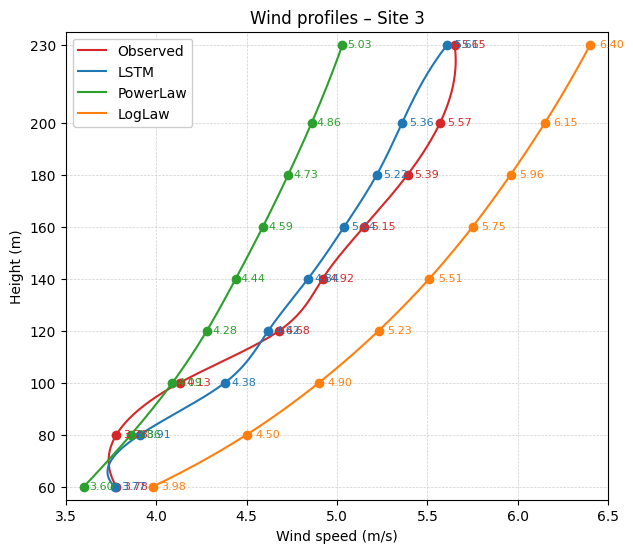

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Heights (m)
heights = np.array([60, 80, 100, 120, 140, 160, 180, 200, 230])

# Wind speeds (m/s) from your Excel table
observed = np.array([3.78, 3.78, 4.13, 4.68, 4.92, 5.15, 5.39, 5.57, 5.65])
lstm     = np.array([3.77, 3.91, 4.38, 4.62, 4.84, 5.04, 5.22, 5.36, 5.61])
powerlaw = np.array([3.60, 3.86, 4.09, 4.28, 4.44, 4.59, 4.73, 4.86, 5.03])
loglaw   = np.array([3.98, 4.50, 4.90, 5.23, 5.51, 5.75, 5.96, 6.15, 6.40])

# Colours chosen to match your Site-2 figure
profiles = {
    "Observed": (observed, "#d62728"),  # red
    "LSTM":     (lstm,     "#1f77b4"),  # blue
    "PowerLaw": (powerlaw, "#2ca02c"),  # green
    "LogLaw":   (loglaw,   "#ff7f0e"),  # orange
}

# Dense height grid for smooth curves
z_dense = np.linspace(heights.min(), heights.max(), 300)

fig, ax = plt.subplots(figsize=(7, 6))
fig.subplots_adjust(top=0.9, bottom=0.12)  # extra padding

for label, (vals, color) in profiles.items():
    vals = np.asarray(vals, dtype=float)

    # --- Smooth curve using cubic spline ---
    spline = make_interp_spline(heights, vals, k=3)
    vals_smooth = spline(z_dense)

    ax.plot(vals_smooth, z_dense,
            linewidth=1.5,
            label=label,
            color=color)

    # Markers at the original data points
    ax.plot(vals, heights,
            marker="o",
            linestyle="None",
            color=color)

    # Data callouts at the original data points
    x_min, x_max = np.nanmin(vals), np.nanmax(vals)
    x_range = x_max - x_min if x_max > x_min else 1.0
    offset = 0.02 * x_range   # small horizontal offset

    for x, y in zip(vals, heights):
        ax.text(x + offset, y, f"{x:.2f}",
                va="center",
                fontsize=8,
                color=color)

# Axes labels & title
ax.set_xlabel("Wind speed (m/s)")
ax.set_ylabel("Height (m)")
ax.set_title("Wind profiles – Site 3")

# Axis limits and ticks
ax.set_xlim(3.5, 6.5)
ax.set_ylim(55, 235)
ax.set_yticks(heights)

# Grid and legend
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.legend(loc="upper left", frameon=True, framealpha=1.0)

plt.show()


## Site 3 for Predicting 1 and 2

Loading Site 3 data...
Site 3 data shape after cleaning: (96644, 18)

Preparing Site 3 training sequences...
  X_train shape: (86978, 2, 5)
  y_train shape: (86978, 9)

Building LSTM model (Site 3)...
Training LSTM on Site 3...

Site 3: LSTM test loss (MSE, scaled): 0.2093
Site 3: LSTM test MAE  (scaled):      0.3152

=== LSTM (trained & tested on Site 3) – Site 3 (test subset): Metrics per height ===

--- v60m ---
R²   :      0.981
MSE  :     0.0676 (m²/s²)
RMSE :     0.2600 (m/s)
MAE  :     0.1811 (m/s)
MAPE :       6.57 (%)

--- v80m ---
R²   :      0.939
MSE  :     0.2488 (m²/s²)
RMSE :     0.4988 (m/s)
MAE  :     0.3638 (m/s)
MAPE :      10.28 (%)

--- v100m ---
R²   :      0.863
MSE  :     0.6170 (m²/s²)
RMSE :     0.7855 (m/s)
MAE  :     0.5880 (m/s)
MAPE :      14.88 (%)

--- v120m ---
R²   :      0.789
MSE  :     1.0190 (m²/s²)
RMSE :     1.0094 (m/s)
MAE  :     0.7475 (m/s)
MAPE :      17.97 (%)

--- v140m ---
R²   :      0.742
MSE  :     1.3457 (m²/s²)
RMSE :     1.1600 (m/s

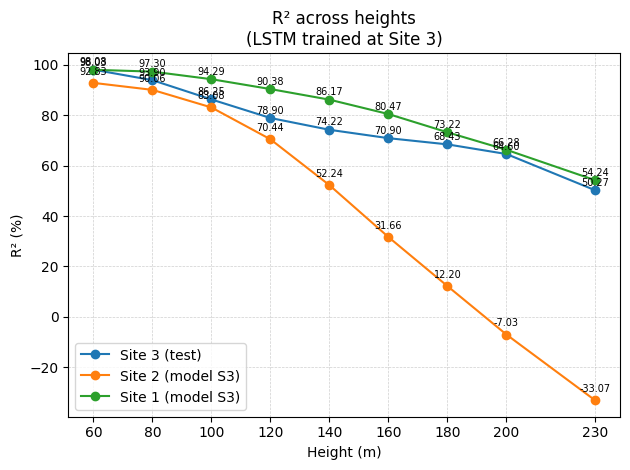

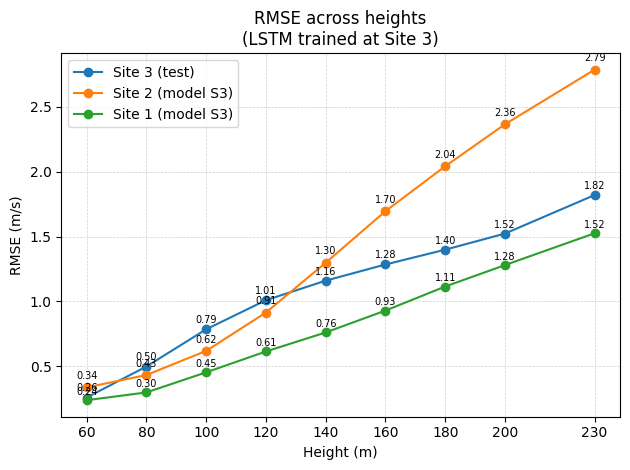

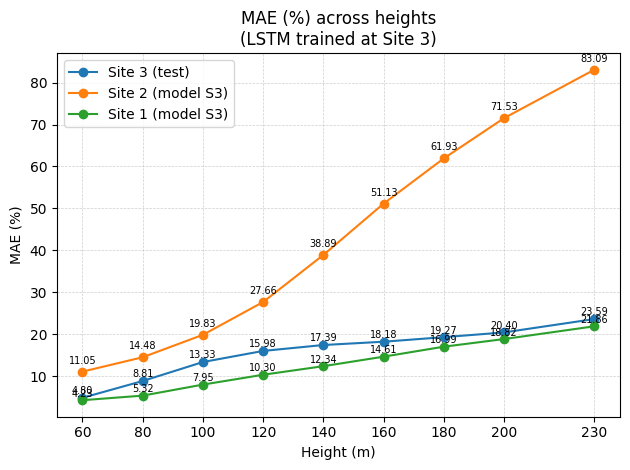


Plotting vertical wind profiles for each site (Observed vs LSTM from Site 3)...


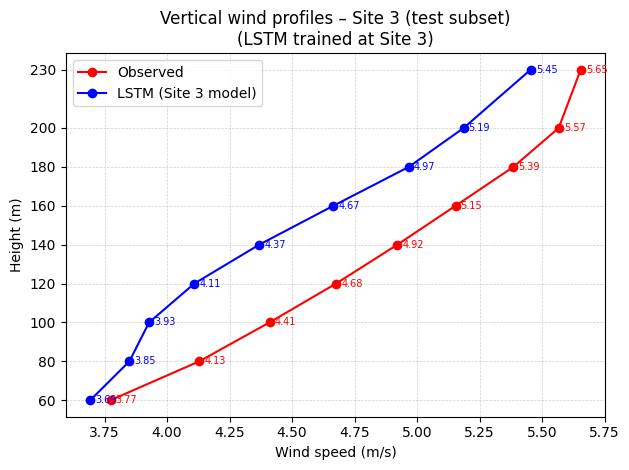

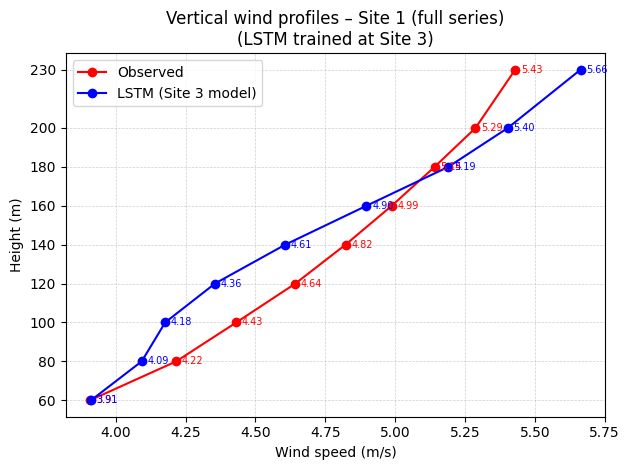

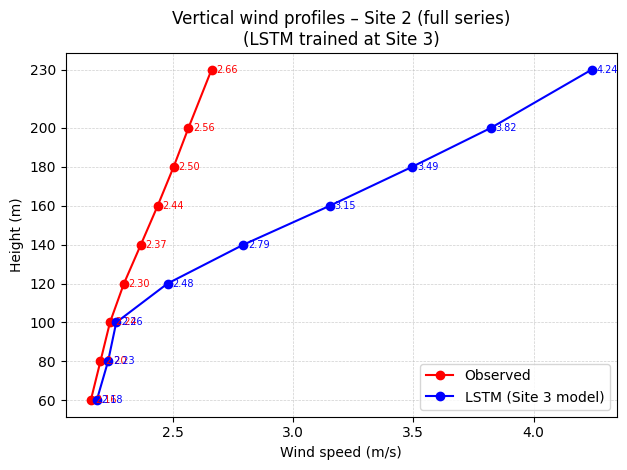

In [67]:
"""
Cross-site experiment using model trained at Site 3
--------------------------------------------------

- Train a single LSTM wind-profile model on Site 3
  (inputs: Time, v40m, v60m, dir40m, TKE;
   outputs: v60m..v230m).

- Apply the *trained Site-3 model* (same weights and scalers)
  to:
    * Site 3 (test portion, as usual)
    * Site 1 (whole dataset, inference only)
    * Site 2 (whole dataset, inference only)

- For each site, compute per-height metrics (R², MSE, RMSE,
  MAE, MAPE).

- Build plots similar to the paper:
    * R² vs height
    * RMSE vs height
    * MAE (%) vs height
    * Vertical wind profiles (Observed vs LSTM) for each site

Colour & grid conventions (consistent with your other scripts):
    Observed  : red
    LSTM      : blue
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks

# ------------------------------------------------------------
# Global configuration
# ------------------------------------------------------------

CSV_SITE1 = "site 1 data.csv"
CSV_SITE2 = "site 2 data.csv"
CSV_SITE3 = "site 3 data.csv"

CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"

TRAIN_FRACTION = 0.90
LSTM_UNITS = 20          # you can tune this
EPOCHS = 70              # idem
BATCH_SIZE = 2
RANDOM_SEED = 42

TIME_STEPS = 2           # must match the Site-3 model you’re happy with

REF_HEIGHT = 40.0
REF_COL = "v40m"

# Input and output columns (Experiment 4 style: 40 m + 60 m)
FEATURE_COLS = ["Time", "v40m", "v60m", "dir40m", "TKE"]
TARGET_COLS = [
    "v60m", "v80m", "v100m", "v120m",
    "v140m", "v160m", "v180m", "v200m", "v230m"
]

# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Returns:
        dict: {height_name: {"r2", "mse", "rmse", "mae", "mape"}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(model_name, site_name, metrics_dict):
    print(f"\n=== {model_name} – {site_name}: Metrics per height ===")
    for col, m in metrics_dict.items():
        print(f"\n--- {col} ---")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------

def height_from_column(col_name: str) -> float:
    """Convert 'v60m' -> 60.0"""
    return float(col_name[1:-1])


# ------------------------------------------------------------
# Data loading functions (same logic as your per-site scripts)
# ------------------------------------------------------------

def load_site1_dataframe(path: str,
                         sep: str = CSV_SEP,
                         encoding: str = CSV_ENCODING) -> pd.DataFrame:
    df = pd.read_csv(path, sep=sep, encoding=encoding)
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(inplace=True)

    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


def load_site2_dataframe(path: str,
                         sep: str = CSV_SEP,
                         encoding: str = CSV_ENCODING) -> pd.DataFrame:
    df = pd.read_csv(path, sep=sep, encoding=encoding)
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.dropna(axis=1, how="all", inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)

    core_cols = [
        "Time", "v40m", "dir40m", "TKE",
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]
    missing_core = [c for c in core_cols if c not in df.columns]
    if missing_core:
        raise ValueError(f"Missing core cols in Site 2: {missing_core}")

    df.dropna(subset=core_cols, inplace=True)

    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


def load_site3_dataframe(path: str,
                         sep: str = CSV_SEP,
                         encoding: str = CSV_ENCODING) -> pd.DataFrame:
    df = pd.read_csv(path, sep=sep, encoding=encoding)
    df.replace([-9999, -9999.0], np.nan, inplace=True)

    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    essential_cols = [
        "Time", "v40m", "dir40m", "TKE",
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]
    missing = [c for c in essential_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns in Site 3 CSV: {missing}")

    df[essential_cols] = df[essential_cols].apply(
        pd.to_numeric, errors="coerce"
    )
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(subset=essential_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


# ------------------------------------------------------------
# Sequence preparation
# ------------------------------------------------------------

def prepare_training_sequences(df: pd.DataFrame, time_steps: int):
    """
    Prepare (X,y) for *training only* from a single site (Site 3 here).
    Train/test split is performed in time.
    """
    X = df[FEATURE_COLS].values.astype("float32")
    y = df[TARGET_COLS].values.astype("float32")

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")
    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    indices = np.arange(time_steps - 1, n_samples)

    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    train_indices = indices[train_mask]
    test_indices = indices[test_mask]

    # scaling (fit only on training portion of THIS site)
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X[:train_size])
    y_scaler.fit(y[:train_size])

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        X_seq[k] = X_scaled[t - time_steps + 1:t + 1, :]
        y_seq_scaled[k] = y_scaled[t, :]

    y_targets_orig = y[indices]

    X_train = X_seq[train_mask]
    X_test = X_seq[test_mask]
    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]
    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train, X_test,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            TARGET_COLS,
            train_indices, test_indices)


def prepare_inference_sequences(df: pd.DataFrame,
                                time_steps: int,
                                X_scaler: StandardScaler):
    """
    Prepare sequences for *inference only* on a new site.
    Uses the X_scaler fitted on the training site (Site 3).
    No train/test split is done here – we just build sequences
    for the whole time series.
    """
    X = df[FEATURE_COLS].values.astype("float32")
    y = df[TARGET_COLS].values.astype("float32")

    n_samples = len(df)
    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    indices = np.arange(time_steps - 1, n_samples)
    X_scaled = X_scaler.transform(X)

    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_orig = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        X_seq[k] = X_scaled[t - time_steps + 1:t + 1, :]
        y_orig[k] = y[t, :]

    return X_seq, y_orig, TARGET_COLS, indices


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    model.add(layers.Dense(output_dim))
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model


# ------------------------------------------------------------
# Cross-site evaluation helpers
# ------------------------------------------------------------

def evaluate_with_model(df: pd.DataFrame,
                        site_name: str,
                        model: keras.Model,
                        X_scaler: StandardScaler,
                        y_scaler: StandardScaler,
                        time_steps: int):
    """
    Use the already-trained LSTM model + scalers from Site 3
    to predict a given site's profiles and compute metrics.
    """
    X_seq, y_true, target_cols, indices = prepare_inference_sequences(
        df, time_steps, X_scaler
    )

    y_pred_scaled = model.predict(X_seq, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    metrics_lstm = compute_height_metrics(y_true, y_pred, target_cols)

    # Mean observed and predicted profile
    mean_obs_per_height = {
        col: float(np.mean(y_true[:, j]))
        for j, col in enumerate(target_cols)
    }
    mean_pred_per_height = {
        col: float(np.mean(y_pred[:, j]))
        for j, col in enumerate(target_cols)
    }

    print_height_metrics("LSTM (trained at Site 3)", site_name, metrics_lstm)

    return (metrics_lstm,
            mean_obs_per_height,
            mean_pred_per_height,
            target_cols)


def build_cross_site_df(site_metrics, site_mean_obs):
    """
    site_metrics: dict like {"Site 3 (train/test)": metrics_dict, ...}
    site_mean_obs: dict like {"Site 3 (train/test)": mean_obs_dict, ...}
    """
    rows = []
    for site_label, metrics_dict in site_metrics.items():
        mean_obs_dict = site_mean_obs[site_label]
        for h, m in metrics_dict.items():
            height_m = height_from_column(h)
            mean_obs = mean_obs_dict.get(h, np.nan)
            mae = m["mae"]
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (mae / mean_obs) * 100.0

            rows.append({
                "site":       site_label,
                "height":     h,
                "height_m":   height_m,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     mae,
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })
    return pd.DataFrame(rows)


def plot_metric_comparison_cross(df, metric="R2"):
    """
    Plot R² / RMSE / MAE% vs height for several sites,
    all using the same Site-3-trained LSTM.
    """
    metric = metric.upper()
    if metric not in ["R2", "RMSE", "MAE_PCT"]:
        raise ValueError("metric must be 'R2', 'RMSE', or 'MAE_PCT'.")

    df_sorted = df.sort_values("height_m")
    heights_vals = df_sorted["height_m"].unique()
    site_labels = df_sorted["site"].unique()

    plt.figure()

    for site_label in site_labels:
        df_s = df_sorted[df_sorted["site"] == site_label]
        x = df_s["height_m"].to_numpy()

        if metric == "R2":
            y = df_s["R2"].to_numpy() * 100.0
            y_label = "R² (%)"
            title_metric = "R²"
        elif metric == "RMSE":
            y = df_s["RMSE_ms"].to_numpy()
            y_label = "RMSE (m/s)"
            title_metric = "RMSE"
        else:
            y = df_s["MAE_pct"].to_numpy()
            y_label = "MAE (%)"
            title_metric = "MAE (%)"

        plt.plot(x, y, marker="o", linewidth=1.5, label=site_label)

        # callout labels
        y_valid = y[~np.isnan(y)]
        if len(y_valid) > 0:
            y_min = np.nanmin(y_valid)
            y_max = np.nanmax(y_valid)
            y_range = y_max - y_min if y_max > y_min else 1.0
            offset = 0.02 * y_range
        else:
            offset = 0.0

        for xi, yi in zip(x, y):
            if np.isnan(yi):
                continue
            plt.text(
                xi,
                yi + offset,
                f"{yi:.2f}",
                ha="center",
                va="bottom",
                fontsize=7
            )

    plt.xlabel("Height (m)")
    plt.ylabel(y_label)
    plt.title(f"{title_metric} across heights\n(LSTM trained at Site 3)")
    plt.xticks(heights_vals, [f"{int(h)}" for h in heights_vals])
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_vertical_profile_single(site_name,
                                 target_cols,
                                 mean_obs_per_height,
                                 mean_lstm_per_height):
    """
    Vertical profile for one site: Observed vs LSTM (from Site-3 model).
    Colours:
        Observed : red
        LSTM     : blue
    Grid lines aligned with height levels.
    """
    heights_m = np.array([height_from_column(c) for c in target_cols],
                         dtype=float)

    obs_profile = np.array(
        [mean_obs_per_height[c] for c in target_cols], dtype=float
    )
    lstm_profile = np.array(
        [mean_lstm_per_height[c] for c in target_cols], dtype=float
    )

    plt.figure()

    # Observed
    plt.plot(
        obs_profile, heights_m,
        marker="o", linewidth=1.5,
        color="red", label="Observed"
    )
    # LSTM
    plt.plot(
        lstm_profile, heights_m,
        marker="o", linewidth=1.5,
        color="blue", label="LSTM (Site 3 model)"
    )

    # Text labels
    for v, z in zip(obs_profile, heights_m):
        plt.text(v + 0.02, z, f"{v:.2f}", va="center",
                 fontsize=7, color="red")
    for v, z in zip(lstm_profile, heights_m):
        plt.text(v + 0.02, z, f"{v:.2f}", va="center",
                 fontsize=7, color="blue")

    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Height (m)")
    plt.yticks(heights_m, [f"{int(h)}" for h in heights_m])
    plt.title(f"Vertical wind profiles – {site_name}\n"
              f"(LSTM trained at Site 3)")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():
    # Reproducibility
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    # ---------------- Site 3: training ----------------
    print("Loading Site 3 data...")
    df3 = load_site3_dataframe(CSV_SITE3)
    print(f"Site 3 data shape after cleaning: {df3.shape}")

    print("\nPreparing Site 3 training sequences...")
    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler_s3, y_scaler_s3,
     target_cols,
     train_indices, test_indices) = prepare_training_sequences(
        df3, time_steps=TIME_STEPS
    )

    print("  X_train shape:", X_train.shape)
    print("  y_train shape:", y_train_scaled.shape)

    print("\nBuilding LSTM model (Site 3)...")
    input_shape = X_train.shape[1:]
    output_dim = y_train_scaled.shape[1]
    model_s3 = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("Training LSTM on Site 3...")
    model_s3.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        shuffle=False,
        callbacks=[early_stop],
        verbose=0
    )

    test_loss, test_mae = model_s3.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"\nSite 3: LSTM test loss (MSE, scaled): {test_loss:.4f}")
    print(f"Site 3: LSTM test MAE  (scaled):      {test_mae:.4f}")

    # Predictions back to physical units for Site 3 test portion
    y_pred_scaled_s3 = model_s3.predict(X_test, verbose=0)
    y_pred_s3 = y_scaler_s3.inverse_transform(y_pred_scaled_s3)

    metrics_s3 = compute_height_metrics(y_test_orig, y_pred_s3, target_cols)
    mean_obs_s3 = {
        col: float(np.mean(y_test_orig[:, j]))
        for j, col in enumerate(target_cols)
    }
    mean_pred_s3 = {
        col: float(np.mean(y_pred_s3[:, j]))
        for j, col in enumerate(target_cols)
    }

    print_height_metrics("LSTM (trained & tested on Site 3)",
                         "Site 3 (test subset)", metrics_s3)

    # ---------------- Site 1: cross-site inference ----------------
    print("\nLoading Site 1 data...")
    df1 = load_site1_dataframe(CSV_SITE1)
    print(f"Site 1 data shape after cleaning: {df1.shape}")

    (metrics_s1_from_s3,
     mean_obs_s1,
     mean_pred_s1,
     target_cols_1) = evaluate_with_model(
        df1, "Site 1 (full series)",
        model_s3, X_scaler_s3, y_scaler_s3,
        time_steps=TIME_STEPS
    )

    # ---------------- Site 2: cross-site inference ----------------
    print("\nLoading Site 2 data...")
    df2 = load_site2_dataframe(CSV_SITE2)
    print(f"Site 2 data shape after cleaning: {df2.shape}")

    (metrics_s2_from_s3,
     mean_obs_s2,
     mean_pred_s2,
     target_cols_2) = evaluate_with_model(
        df2, "Site 2 (full series)",
        model_s3, X_scaler_s3, y_scaler_s3,
        time_steps=TIME_STEPS
    )

    # ---------------- Combined comparison plots ----------------
    site_metrics = {
        "Site 3 (test)": metrics_s3,
        "Site 1 (model S3)": metrics_s1_from_s3,
        "Site 2 (model S3)": metrics_s2_from_s3,
    }
    site_mean_obs = {
        "Site 3 (test)": mean_obs_s3,
        "Site 1 (model S3)": mean_obs_s1,
        "Site 2 (model S3)": mean_obs_s2,
    }

    comparison_df = build_cross_site_df(site_metrics, site_mean_obs)

    print("\nPlotting R² / RMSE / MAE% vs height "
          "(LSTM trained at Site 3)...")
    plot_metric_comparison_cross(comparison_df, metric="R2")
    plot_metric_comparison_cross(comparison_df, metric="RMSE")
    plot_metric_comparison_cross(comparison_df, metric="MAE_PCT")

    # ---------------- Vertical profiles per site ----------------
    print("\nPlotting vertical wind profiles for each site "
          "(Observed vs LSTM from Site 3)...")
    plot_vertical_profile_single("Site 3 (test subset)",
                                 target_cols,
                                 mean_obs_s3,
                                 mean_pred_s3)

    plot_vertical_profile_single("Site 1 (full series)",
                                 target_cols_1,
                                 mean_obs_s1,
                                 mean_pred_s1)

    plot_vertical_profile_single("Site 2 (full series)",
                                 target_cols_2,
                                 mean_obs_s2,
                                 mean_pred_s2)


if __name__ == "__main__":
    main()


Loading Site 3 data...
Site 3 data shape after cleaning: (96644, 18)

Preparing Site 3 training sequences...
  X_train shape: (86978, 2, 5)
  y_train shape: (86978, 9)

Building LSTM model (Site 3)...
Training LSTM on Site 3...

Site 3: LSTM test loss (MSE, scaled): 0.2465
Site 3: LSTM test MAE  (scaled):      0.3558

=== LSTM (trained & tested on Site 3) – Site 3 (test subset): Metrics per height ===

--- v60m ---
R²   :      0.981
MSE  :     0.0651 (m²/s²)
RMSE :     0.2552 (m/s)
MAE  :     0.1904 (m/s)
MAPE :       7.43 (%)

--- v80m ---
R²   :      0.918
MSE  :     0.3361 (m²/s²)
RMSE :     0.5798 (m/s)
MAE  :     0.4522 (m/s)
MAPE :      13.29 (%)

--- v100m ---
R²   :      0.813
MSE  :     0.8378 (m²/s²)
RMSE :     0.9153 (m/s)
MAE  :     0.7241 (m/s)
MAPE :      18.46 (%)

--- v120m ---
R²   :      0.726
MSE  :     1.3222 (m²/s²)
RMSE :     1.1499 (m/s)
MAE  :     0.8866 (m/s)
MAPE :      20.56 (%)

--- v140m ---
R²   :      0.677
MSE  :     1.6841 (m²/s²)
RMSE :     1.2977 (m/s

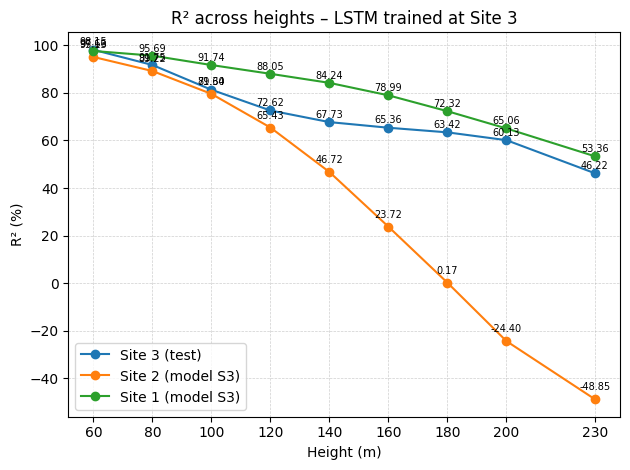

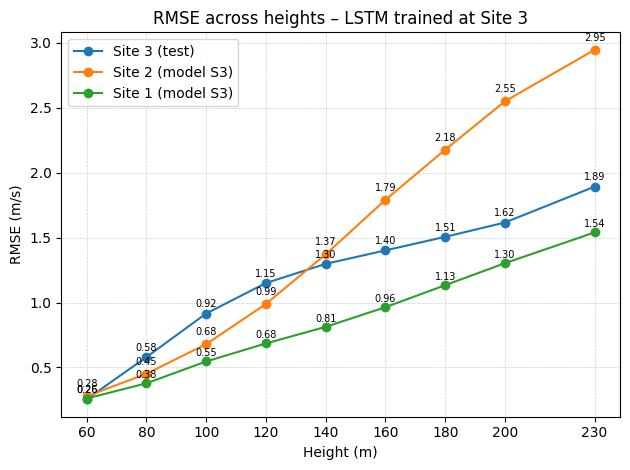

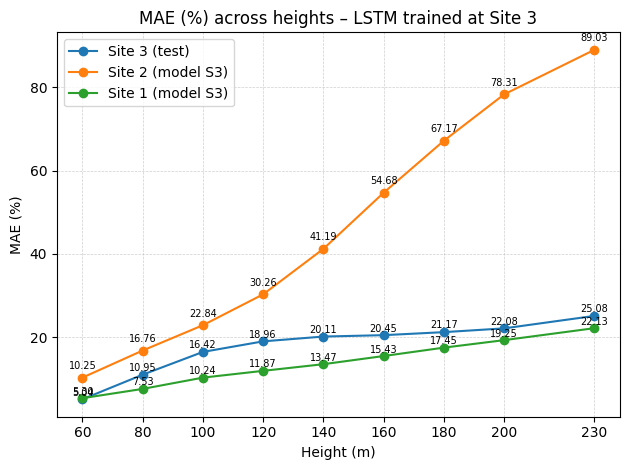


Plotting vertical wind profiles for each site (Observed vs LSTM from Site 3)...


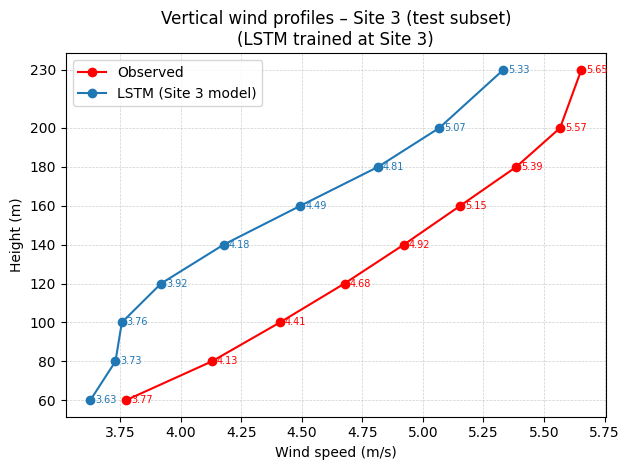

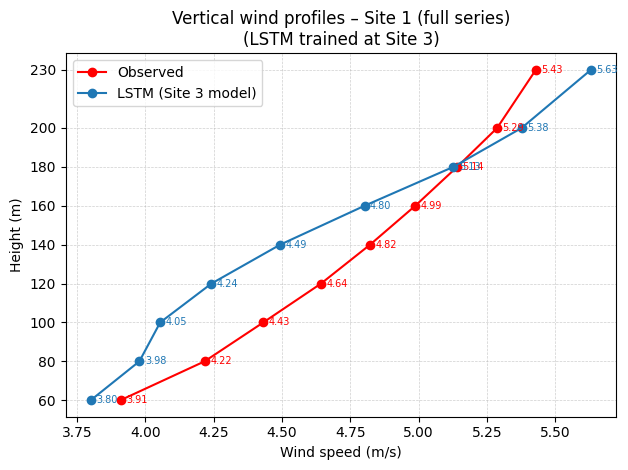

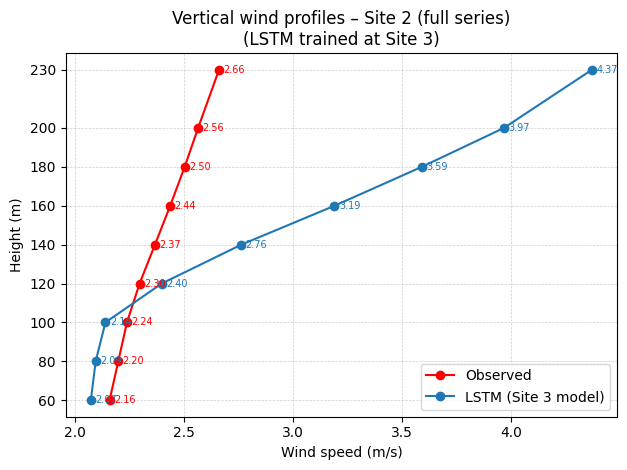

In [9]:
"""
Cross-site experiment using model trained at Site 3
--------------------------------------------------

- Train a single LSTM wind-profile model on Site 3
  (inputs: Time, v40m, v60m, dir40m, TKE;
   outputs: v60m..v230m).

- Apply the *trained Site-3 model* (same weights and scalers)
  to:
    * Site 3 (test portion, as usual)
    * Site 1 (whole dataset, inference only)
    * Site 2 (whole dataset, inference only)

- For each site, compute per-height metrics (R², MSE, RMSE,
  MAE, MAPE).

- Build plots similar to the paper:
    * R² vs height
    * RMSE vs height
    * MAE (%) vs height
    * Vertical wind profiles (Observed vs LSTM) for each site

Colour & grid conventions (consistent with your other scripts):
    Observed  : red
    LSTM      : blue
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks

# ------------------------------------------------------------
# Global configuration
# ------------------------------------------------------------

CSV_SITE1 = "site 1 data.csv"
CSV_SITE2 = "site 2 data.csv"
CSV_SITE3 = "site 3 data.csv"

CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"

TRAIN_FRACTION = 0.90
LSTM_UNITS = 20          # you can tune this
EPOCHS = 70              # idem
BATCH_SIZE = 2
RANDOM_SEED = 42

TIME_STEPS = 2           # must match the Site-3 model you’re happy with

REF_HEIGHT = 40.0
REF_COL = "v40m"

# Input and output columns (Experiment 4 style: 40 m + 60 m)
FEATURE_COLS = ["Time", "v40m", "v60m", "dir40m", "TKE"]
TARGET_COLS = [
    "v60m", "v80m", "v100m", "v120m",
    "v140m", "v160m", "v180m", "v200m", "v230m"
]

# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Returns:
        dict: {height_name: {"r2", "mse", "rmse", "mae", "mape"}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(model_name, site_name, metrics_dict):
    print(f"\n=== {model_name} – {site_name}: Metrics per height ===")
    for col, m in metrics_dict.items():
        print(f"\n--- {col} ---")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------

def height_from_column(col_name: str) -> float:
    """Convert 'v60m' -> 60.0"""
    return float(col_name[1:-1])


# ------------------------------------------------------------
# Data loading functions (same logic as your per-site scripts)
# ------------------------------------------------------------

def load_site1_dataframe(path: str,
                         sep: str = CSV_SEP,
                         encoding: str = CSV_ENCODING) -> pd.DataFrame:
    df = pd.read_csv(path, sep=sep, encoding=encoding)
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(inplace=True)

    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


def load_site2_dataframe(path: str,
                         sep: str = CSV_SEP,
                         encoding: str = CSV_ENCODING) -> pd.DataFrame:
    df = pd.read_csv(path, sep=sep, encoding=encoding)
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.dropna(axis=1, how="all", inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)

    core_cols = [
        "Time", "v40m", "dir40m", "TKE",
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]
    missing_core = [c for c in core_cols if c not in df.columns]
    if missing_core:
        raise ValueError(f"Missing core cols in Site 2: {missing_core}")

    df.dropna(subset=core_cols, inplace=True)

    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


def load_site3_dataframe(path: str,
                         sep: str = CSV_SEP,
                         encoding: str = CSV_ENCODING) -> pd.DataFrame:
    df = pd.read_csv(path, sep=sep, encoding=encoding)
    df.replace([-9999, -9999.0], np.nan, inplace=True)

    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    essential_cols = [
        "Time", "v40m", "dir40m", "TKE",
        "v60m", "v80m", "v100m", "v120m",
        "v140m", "v160m", "v180m", "v200m", "v230m"
    ]
    missing = [c for c in essential_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns in Site 3 CSV: {missing}")

    df[essential_cols] = df[essential_cols].apply(
        pd.to_numeric, errors="coerce"
    )
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(subset=essential_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


# ------------------------------------------------------------
# Sequence preparation
# ------------------------------------------------------------

def prepare_training_sequences(df: pd.DataFrame, time_steps: int):
    """
    Prepare (X,y) for *training only* from a single site (Site 3 here).
    Train/test split is performed in time.
    """
    X = df[FEATURE_COLS].values.astype("float32")
    y = df[TARGET_COLS].values.astype("float32")

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")
    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    indices = np.arange(time_steps - 1, n_samples)

    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    train_indices = indices[train_mask]
    test_indices = indices[test_mask]

    # scaling (fit only on training portion of THIS site)
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X[:train_size])
    y_scaler.fit(y[:train_size])

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        X_seq[k] = X_scaled[t - time_steps + 1:t + 1, :]
        y_seq_scaled[k] = y_scaled[t, :]

    y_targets_orig = y[indices]

    X_train = X_seq[train_mask]
    X_test = X_seq[test_mask]
    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]
    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train, X_test,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            TARGET_COLS,
            train_indices, test_indices)


def prepare_inference_sequences(df: pd.DataFrame,
                                time_steps: int,
                                X_scaler: StandardScaler):
    """
    Prepare sequences for *inference only* on a new site.
    Uses the X_scaler fitted on the training site (Site 3).
    No train/test split is done here – we just build sequences
    for the whole time series.
    """
    X = df[FEATURE_COLS].values.astype("float32")
    y = df[TARGET_COLS].values.astype("float32")

    n_samples = len(df)
    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    indices = np.arange(time_steps - 1, n_samples)
    X_scaled = X_scaler.transform(X)

    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_orig = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        X_seq[k] = X_scaled[t - time_steps + 1:t + 1, :]
        y_orig[k] = y[t, :]

    return X_seq, y_orig, TARGET_COLS, indices


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    model.add(layers.Dense(output_dim))
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model


# ------------------------------------------------------------
# Cross-site evaluation helpers
# ------------------------------------------------------------

def evaluate_with_model(df: pd.DataFrame,
                        site_name: str,
                        model: keras.Model,
                        X_scaler: StandardScaler,
                        y_scaler: StandardScaler,
                        time_steps: int):
    """
    Use the already-trained LSTM model + scalers from Site 3
    to predict a given site's profiles and compute metrics.
    """
    X_seq, y_true, target_cols, indices = prepare_inference_sequences(
        df, time_steps, X_scaler
    )

    y_pred_scaled = model.predict(X_seq, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    metrics_lstm = compute_height_metrics(y_true, y_pred, target_cols)

    # Mean observed and predicted profile
    mean_obs_per_height = {
        col: float(np.mean(y_true[:, j]))
        for j, col in enumerate(target_cols)
    }
    mean_pred_per_height = {
        col: float(np.mean(y_pred[:, j]))
        for j, col in enumerate(target_cols)
    }

    print_height_metrics("LSTM (trained at Site 3)", site_name, metrics_lstm)

    return (metrics_lstm,
            mean_obs_per_height,
            mean_pred_per_height,
            target_cols)


def build_cross_site_df(site_metrics, site_mean_obs):
    """
    site_metrics: dict like {"Site 3 (train/test)": metrics_dict, ...}
    site_mean_obs: dict like {"Site 3 (train/test)": mean_obs_dict, ...}
    """
    rows = []
    for site_label, metrics_dict in site_metrics.items():
        mean_obs_dict = site_mean_obs[site_label]
        for h, m in metrics_dict.items():
            height_m = height_from_column(h)
            mean_obs = mean_obs_dict.get(h, np.nan)
            mae = m["mae"]
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (mae / mean_obs) * 100.0

            rows.append({
                "site":       site_label,
                "height":     h,
                "height_m":   height_m,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     mae,
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })
    return pd.DataFrame(rows)


def plot_metric_comparison_cross(df, metric="R2"):
    """
    For cross-site LSTM (trained at Site 3):
    plot metric vs height with one line per site.
    """
    metric = metric.upper()
    if metric not in ["R2", "RMSE", "MAE_PCT"]:
        raise ValueError("metric must be 'R2', 'RMSE', or 'MAE_PCT'.")

    df_sorted = df.sort_values("height_m")
    heights_vals = df_sorted["height_m"].unique()
    sites = df_sorted["site"].unique()

    plt.figure()

    for site in sites:
        df_s = df_sorted[df_sorted["site"] == site]
        x = df_s["height_m"].to_numpy()

        if metric == "R2":
            y = df_s["R2"].to_numpy() * 100.0
            y_label = "R² (%)"
            title_metric = "R²"
        elif metric == "RMSE":
            y = df_s["RMSE_ms"].to_numpy()
            y_label = "RMSE (m/s)"
            title_metric = "RMSE"
        else:
            y = df_s["MAE_pct"].to_numpy()
            y_label = "MAE (%)"
            title_metric = "MAE (%)"

        plt.plot(x, y, marker="o", linewidth=1.5, label=site)

        # callout labels
        y_valid = y[~np.isnan(y)]
        if len(y_valid) > 0:
            y_min = np.nanmin(y_valid)
            y_max = np.nanmax(y_valid)
            y_range = y_max - y_min if y_max > y_min else 1.0
            offset = 0.02 * y_range
        else:
            offset = 0.0

        for xi, yi in zip(x, y):
            if np.isnan(yi):
                continue
            plt.text(
                xi, yi + offset,
                f"{yi:.2f}",
                ha="center",
                va="bottom",
                fontsize=7
            )

    plt.xlabel("Height (m)")
    plt.ylabel(y_label)
    plt.title(f"{title_metric} across heights – LSTM trained at Site 3")
    plt.xticks(heights_vals, [f"{int(h)}" for h in heights_vals])
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()



def plot_vertical_profile_single(site_name,
                                 target_cols,
                                 mean_obs_per_height,
                                 mean_lstm_per_height):
    """
    Vertical wind profile: Observed vs LSTM for a single site.

    Observed -> red
    LSTM     -> blue
    """
    heights_m = np.array([height_from_column(c) for c in target_cols],
                         dtype=float)

    obs = np.array(
        [mean_obs_per_height[c] for c in target_cols], dtype=float
    )
    lstm = np.array(
        [mean_lstm_per_height[c] for c in target_cols], dtype=float
    )

    plt.figure()

    # Observed (match Site 2 style: 'r')
    plt.plot(
        obs, heights_m,
        marker="o", linewidth=1.5,
        color="r", label="Observed"
    )
    # LSTM (match Site 2 style: 'C0')
    plt.plot(
        lstm, heights_m,
        marker="o", linewidth=1.5,
        color="C0", label="LSTM (Site 3 model)"
    )

    # Text labels (same offsets / fontsize as Site 2)
    for v, z in zip(obs, heights_m):
        plt.text(v + 0.02, z, f"{v:.2f}", va="center",
                 fontsize=7, color="r")
    for v, z in zip(lstm, heights_m):
        plt.text(v + 0.02, z, f"{v:.2f}", va="center",
                 fontsize=7, color="C0")

    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Height (m)")
    plt.yticks(heights_m, [f"{int(h)}" for h in heights_m])
    plt.title(f"Vertical wind profiles – {site_name}\n"
              f"(LSTM trained at Site 3)")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()



# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():
    # Reproducibility
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    # ---------------- Site 3: training ----------------
    print("Loading Site 3 data...")
    df3 = load_site3_dataframe(CSV_SITE3)
    print(f"Site 3 data shape after cleaning: {df3.shape}")

    print("\nPreparing Site 3 training sequences...")
    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler_s3, y_scaler_s3,
     target_cols,
     train_indices, test_indices) = prepare_training_sequences(
        df3, time_steps=TIME_STEPS
    )

    print("  X_train shape:", X_train.shape)
    print("  y_train shape:", y_train_scaled.shape)

    print("\nBuilding LSTM model (Site 3)...")
    input_shape = X_train.shape[1:]
    output_dim = y_train_scaled.shape[1]
    model_s3 = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("Training LSTM on Site 3...")
    model_s3.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        shuffle=False,
        callbacks=[early_stop],
        verbose=0
    )

    test_loss, test_mae = model_s3.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"\nSite 3: LSTM test loss (MSE, scaled): {test_loss:.4f}")
    print(f"Site 3: LSTM test MAE  (scaled):      {test_mae:.4f}")

    # Predictions back to physical units for Site 3 test portion
    y_pred_scaled_s3 = model_s3.predict(X_test, verbose=0)
    y_pred_s3 = y_scaler_s3.inverse_transform(y_pred_scaled_s3)

    metrics_s3 = compute_height_metrics(y_test_orig, y_pred_s3, target_cols)
    mean_obs_s3 = {
        col: float(np.mean(y_test_orig[:, j]))
        for j, col in enumerate(target_cols)
    }
    mean_pred_s3 = {
        col: float(np.mean(y_pred_s3[:, j]))
        for j, col in enumerate(target_cols)
    }

    print_height_metrics("LSTM (trained & tested on Site 3)",
                         "Site 3 (test subset)", metrics_s3)

    # ---------------- Site 1: cross-site inference ----------------
    print("\nLoading Site 1 data...")
    df1 = load_site1_dataframe(CSV_SITE1)
    print(f"Site 1 data shape after cleaning: {df1.shape}")

    (metrics_s1_from_s3,
     mean_obs_s1,
     mean_pred_s1,
     target_cols_1) = evaluate_with_model(
        df1, "Site 1 (full series)",
        model_s3, X_scaler_s3, y_scaler_s3,
        time_steps=TIME_STEPS
    )

    # ---------------- Site 2: cross-site inference ----------------
    print("\nLoading Site 2 data...")
    df2 = load_site2_dataframe(CSV_SITE2)
    print(f"Site 2 data shape after cleaning: {df2.shape}")

    (metrics_s2_from_s3,
     mean_obs_s2,
     mean_pred_s2,
     target_cols_2) = evaluate_with_model(
        df2, "Site 2 (full series)",
        model_s3, X_scaler_s3, y_scaler_s3,
        time_steps=TIME_STEPS
    )

    # ---------------- Combined comparison plots ----------------
    site_metrics = {
        "Site 3 (test)": metrics_s3,
        "Site 1 (model S3)": metrics_s1_from_s3,
        "Site 2 (model S3)": metrics_s2_from_s3,
    }
    site_mean_obs = {
        "Site 3 (test)": mean_obs_s3,
        "Site 1 (model S3)": mean_obs_s1,
        "Site 2 (model S3)": mean_obs_s2,
    }

    comparison_df = build_cross_site_df(site_metrics, site_mean_obs)

    print("\nPlotting R² / RMSE / MAE% vs height "
          "(LSTM trained at Site 3)...")
    plot_metric_comparison_cross(comparison_df, metric="R2")
    plot_metric_comparison_cross(comparison_df, metric="RMSE")
    plot_metric_comparison_cross(comparison_df, metric="MAE_PCT")

    # ---------------- Vertical profiles per site ----------------
    print("\nPlotting vertical wind profiles for each site "
          "(Observed vs LSTM from Site 3)...")
    plot_vertical_profile_single("Site 3 (test subset)",
                                 target_cols,
                                 mean_obs_s3,
                                 mean_pred_s3)

    plot_vertical_profile_single("Site 1 (full series)",
                                 target_cols_1,
                                 mean_obs_s1,
                                 mean_pred_s1)

    plot_vertical_profile_single("Site 2 (full series)",
                                 target_cols_2,
                                 mean_obs_s2,
                                 mean_pred_s2)


if __name__ == "__main__":
    main()


## Site 2 for Predicting 1 and 3

Loading Site 2 data...
Data shape after cleaning (Site 2): (22576, 18)

=== Training LSTM at Site 2 (TIME_STEPS = 2) ===
  X_train shape: (20317, 2, 4)
  y_train shape: (20317, 9)
  Building LSTM model...
  Training LSTM on Site 2...
  Site 2 LSTM test loss (MSE, scaled): 0.2468
  Site 2 LSTM test MAE  (scaled):      0.3558

=== LSTM – Site 2 (test): Metrics per height ===

--- v60m ---
R²   :      0.925
MSE  :     0.1323 (m²/s²)
RMSE :     0.3637 (m/s)
MAE  :     0.2534 (m/s)
MAPE :      17.07 (%)

--- v80m ---
R²   :      0.862
MSE  :     0.2798 (m²/s²)
RMSE :     0.5289 (m/s)
MAE  :     0.3770 (m/s)
MAPE :      25.73 (%)

--- v100m ---
R²   :      0.815
MSE  :     0.4258 (m²/s²)
RMSE :     0.6526 (m/s)
MAE  :     0.4734 (m/s)
MAPE :      32.98 (%)

--- v120m ---
R²   :      0.768
MSE  :     0.6327 (m²/s²)
RMSE :     0.7954 (m/s)
MAE  :     0.5837 (m/s)
MAPE :      41.99 (%)

--- v140m ---
R²   :      0.720
MSE  :     0.9243 (m²/s²)
RMSE :     0.9614 (m/s)
MAE  :     0.7081 (m/s)
MAP

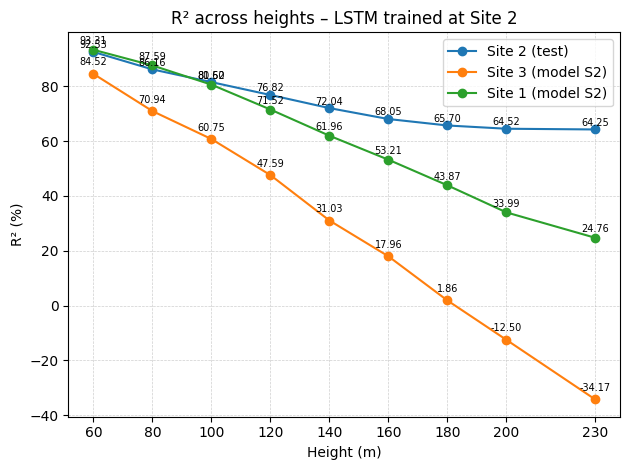

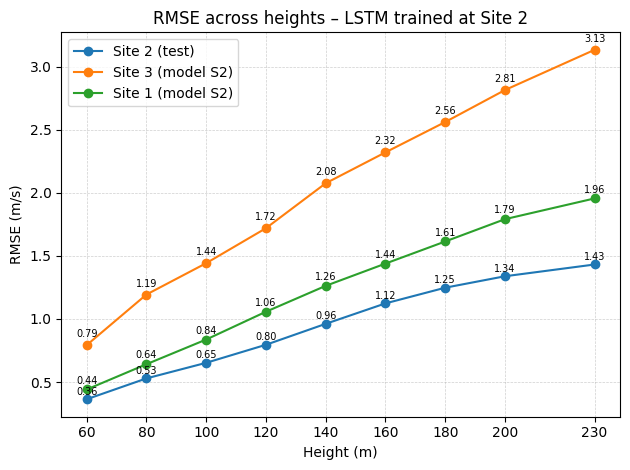

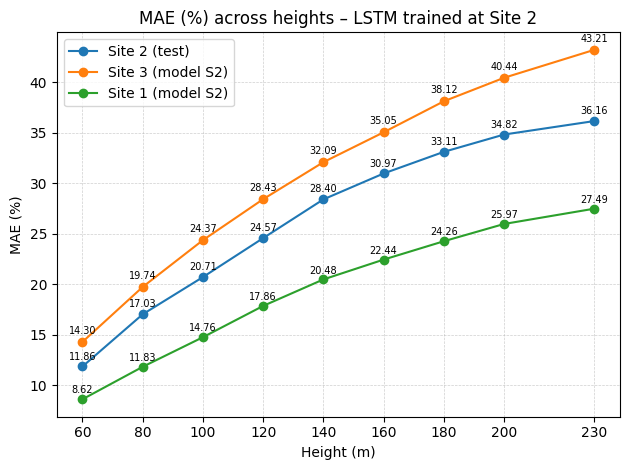


Plotting vertical wind profiles (Observed vs LSTM-from-Site2) for each site...


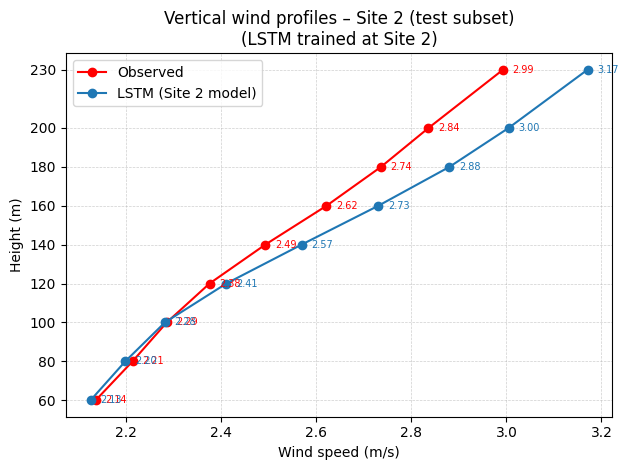

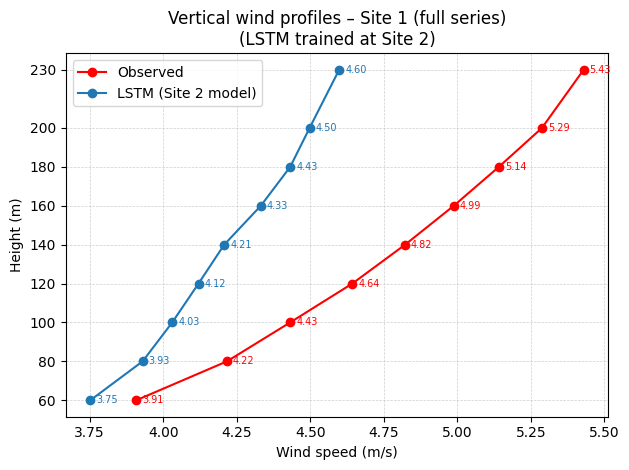

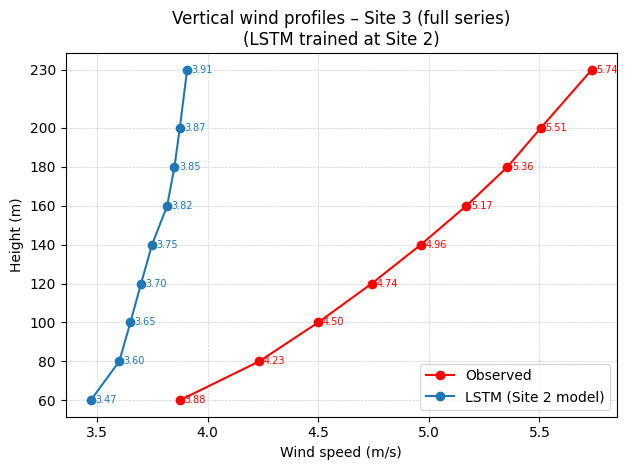

In [8]:
"""
Cross-site experiment – LSTM trained at Site 2
----------------------------------------------

- Train LSTM wind profile model (v60m–v230m) using Site 2.
- Then reuse the trained Site-2 model to predict:
    * Site 1
    * Site 3

Plots:
    1) R² vs height (Site 2 test, Site 1, Site 3)
    2) RMSE vs height
    3) MAE (%) vs height
    4) Vertical wind profiles (Observed vs LSTM-from-Site2)
       for each site.

Colour conventions:
    Observed -> red
    LSTM     -> blue
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_SITE1 = "site 1 data.csv"
CSV_SITE2 = "site 2 data.csv"
CSV_SITE3 = "site 3 data.csv"

CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"

TRAIN_FRACTION = 0.90
LSTM_UNITS = 30
EPOCHS = 30
BATCH_SIZE = 2
RANDOM_SEED = 42

TIME_STEPS = 2     # lookback window

REF_HEIGHT = 40.0
REF_COL = "v40m"

FEATURE_COLS = ["Time", "v40m", "dir40m", "TKE"]
TARGET_COLS = [
    "v60m", "v80m", "v100m", "v120m",
    "v140m", "v160m", "v180m", "v200m", "v230m"
]


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(model_name, metrics_dict):
    print(f"\n=== {model_name}: Metrics per height ===")
    for col, m in metrics_dict.items():
        print(f"\n--- {col} ---")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------

def height_from_column(col_name: str) -> float:
    return float(col_name[1:-1])


# -------- Data loaders (Site 1 / 2 / 3) ---------------------

def load_site2_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    df = pd.read_csv(path, sep=sep, encoding=encoding)

    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.dropna(axis=1, how="all", inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)

    core_cols = FEATURE_COLS + TARGET_COLS
    missing_core = [c for c in core_cols if c not in df.columns]
    if missing_core:
        raise ValueError(f"Missing required columns in Site 2 data: {missing_core}")

    df.dropna(subset=core_cols, inplace=True)

    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


def load_site1_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    df = pd.read_csv(path, sep=sep, encoding=encoding)
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(inplace=True)

    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


def load_site3_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    df = pd.read_csv(path, sep=sep, encoding=encoding)
    df.replace([-9999, -9999.0], np.nan, inplace=True)

    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]

    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    essential_cols = FEATURE_COLS + TARGET_COLS
    missing = [c for c in essential_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns in Site 3 CSV: {missing}")

    df[essential_cols] = df[essential_cols].apply(
        pd.to_numeric, errors="coerce"
    )
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(subset=essential_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


# ------------------------------------------------------------
# Sequence preparation
# ------------------------------------------------------------

def prepare_experiment_site2(df: pd.DataFrame, time_steps: int):
    """Train/test split + sequences for Site 2 (training site)."""
    feature_cols = FEATURE_COLS
    target_cols = TARGET_COLS

    missing = [c for c in feature_cols + target_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in Site 2 data: {missing}")

    X = df[feature_cols].values.astype("float32")
    y = df[target_cols].values.astype("float32")

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")
    if n_samples <= time_steps:
        raise ValueError(f"Not enough samples ({n_samples}) for time_steps={time_steps}.")

    indices = np.arange(time_steps - 1, n_samples)

    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    train_indices = indices[train_mask]
    test_indices = indices[test_mask]

    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        X_seq[k] = X_scaled[t - time_steps + 1: t + 1, :]
        y_seq_scaled[k] = y_scaled[t, :]

    y_targets_orig = y[indices]

    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]

    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]

    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            TARGET_COLS,
            train_indices, test_indices)


def prepare_inference_sequences(df: pd.DataFrame,
                                time_steps: int,
                                X_scaler: StandardScaler):
    """
    Prepare sequences for inference on Site 1 / Site 3
    using scalers learned from Site 2.
    """
    feature_cols = FEATURE_COLS
    target_cols = TARGET_COLS

    X = df[feature_cols].values.astype("float32")
    y = df[target_cols].values.astype("float32")

    n_samples = len(df)
    if n_samples <= time_steps:
        raise ValueError(f"Not enough samples ({n_samples}) for time_steps={time_steps}.")

    indices = np.arange(time_steps - 1, n_samples)
    X_scaled = X_scaler.transform(X)

    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_orig = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        X_seq[k] = X_scaled[t - time_steps + 1:t + 1, :]
        y_orig[k] = y[t, :]

    return X_seq, y_orig, target_cols, indices


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    model.add(layers.Dense(output_dim))
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model


# ------------------------------------------------------------
# Cross-site helpers
# ------------------------------------------------------------

def evaluate_with_model(df: pd.DataFrame,
                        site_name: str,
                        model: keras.Model,
                        X_scaler: StandardScaler,
                        y_scaler: StandardScaler,
                        time_steps: int):
    """
    Use the trained Site-2 LSTM + scalers on another site.
    """
    X_seq, y_true, target_cols, indices = prepare_inference_sequences(
        df, time_steps, X_scaler
    )

    y_pred_scaled = model.predict(X_seq, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    metrics_lstm = compute_height_metrics(y_true, y_pred, target_cols)

    mean_obs_per_height = {
        col: float(np.mean(y_true[:, j]))
        for j, col in enumerate(target_cols)
    }
    mean_pred_per_height = {
        col: float(np.mean(y_pred[:, j]))
        for j, col in enumerate(target_cols)
    }

    print_height_metrics(f"LSTM (trained at Site 2) – {site_name}", metrics_lstm)

    return (metrics_lstm,
            mean_obs_per_height,
            mean_pred_per_height,
            target_cols)


def build_cross_site_df(site_metrics, site_mean_obs):
    rows = []
    for label, metrics_dict in site_metrics.items():
        mean_obs_dict = site_mean_obs[label]
        for h, m in metrics_dict.items():
            height_m = height_from_column(h)
            mean_obs = mean_obs_dict.get(h, np.nan)
            mae = m["mae"]
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (mae / mean_obs) * 100.0

            rows.append({
                "site":       label,
                "height":     h,
                "height_m":   height_m,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     mae,
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })
    return pd.DataFrame(rows)


def plot_metric_comparison_cross(df, metric="R2"):
    """
    For cross-site LSTM (trained at Site 2):
    plot metric vs height with one line per site.
    """
    metric = metric.upper()
    if metric not in ["R2", "RMSE", "MAE_PCT"]:
        raise ValueError("metric must be 'R2', 'RMSE', or 'MAE_PCT'.")

    df_sorted = df.sort_values("height_m")
    heights_vals = df_sorted["height_m"].unique()
    sites = df_sorted["site"].unique()

    plt.figure()

    for site in sites:
        df_s = df_sorted[df_sorted["site"] == site]
        x = df_s["height_m"].to_numpy()

        if metric == "R2":
            y = df_s["R2"].to_numpy() * 100.0
            y_label = "R² (%)"
            title_metric = "R²"
        elif metric == "RMSE":
            y = df_s["RMSE_ms"].to_numpy()
            y_label = "RMSE (m/s)"
            title_metric = "RMSE"
        else:
            y = df_s["MAE_pct"].to_numpy()
            y_label = "MAE (%)"
            title_metric = "MAE (%)"

        plt.plot(x, y, marker="o", linewidth=1.5, label=site)

        y_valid = y[~np.isnan(y)]
        if len(y_valid) > 0:
            y_min = np.nanmin(y_valid)
            y_max = np.nanmax(y_valid)
            y_range = y_max - y_min if y_max > y_min else 1.0
            offset = 0.02 * y_range
        else:
            offset = 0.0

        for xi, yi in zip(x, y):
            if np.isnan(yi):
                continue
            plt.text(
                xi, yi + offset,
                f"{yi:.2f}",
                ha="center",
                va="bottom",
                fontsize=7
            )

    plt.xlabel("Height (m)")
    plt.ylabel(y_label)
    plt.title(f"{title_metric} across heights – LSTM trained at Site 2")
    plt.xticks(heights_vals, [f"{int(h)}" for h in heights_vals])
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_vertical_profile_single(site_name,
                                 target_cols,
                                 mean_obs_per_height,
                                 mean_lstm_per_height):
    """
    Vertical wind profile: Observed vs LSTM for a single site.

    Observed -> red
    LSTM     -> blue
    """
    heights_m = np.array([height_from_column(c) for c in target_cols], dtype=float)

    obs = np.array([mean_obs_per_height[c] for c in target_cols], dtype=float)
    lstm = np.array([mean_lstm_per_height[c] for c in target_cols], dtype=float)

    plt.figure()

    plt.plot(obs, heights_m, marker="o", linewidth=1.5, color="r", label="Observed")
    plt.plot(lstm, heights_m, marker="o", linewidth=1.5, color="C0",
             label="LSTM (Site 2 model)")

    for v, z in zip(obs, heights_m):
        plt.text(v + 0.02, z, f"{v:.2f}", va="center", fontsize=7, color="r")
    for v, z in zip(lstm, heights_m):
        plt.text(v + 0.02, z, f"{v:.2f}", va="center", fontsize=7, color="C0")

    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Height (m)")
    plt.yticks(heights_m, [f"{int(h)}" for h in heights_m])
    plt.title(f"Vertical wind profiles – {site_name}\n(LSTM trained at Site 2)")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Train on Site 2, then predict Sites 1 & 3
# ------------------------------------------------------------

def train_site2_and_get_model(df2, time_steps: int):
    """
    Train the LSTM on Site 2 and return model + scalers +
    Site-2 test metrics & mean profiles.
    """
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols,
     train_indices, test_indices) = prepare_experiment_site2(df2, time_steps=time_steps)

    print("  X_train shape:", X_train.shape)
    print("  y_train shape:", y_train_scaled.shape)

    input_shape = X_train.shape[1:]
    output_dim = y_train_scaled.shape[1]

    print("  Building LSTM model...")
    model = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("  Training LSTM on Site 2...")
    model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        shuffle=False,
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate on Site-2 test set
    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  Site 2 LSTM test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  Site 2 LSTM test MAE  (scaled):      {test_mae:.4f}")

    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred_lstm = y_scaler.inverse_transform(y_pred_scaled)

    metrics_lstm = compute_height_metrics(y_test_orig, y_pred_lstm, target_cols)
    print_height_metrics("LSTM – Site 2 (test)", metrics_lstm)

    mean_obs_per_height = {
        col: float(np.mean(y_test_orig[:, j]))
        for j, col in enumerate(target_cols)
    }
    mean_pred_per_height = {
        col: float(np.mean(y_pred_lstm[:, j]))
        for j, col in enumerate(target_cols)
    }

    return (model,
            X_scaler, y_scaler,
            metrics_lstm,
            mean_obs_per_height,
            mean_pred_per_height,
            target_cols)


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():
    # -------- Train on Site 2 --------
    print("Loading Site 2 data...")
    df2 = load_site2_dataframe(CSV_SITE2, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning (Site 2): {df2.shape}")

    if len(df2) == 0:
        raise ValueError("Site 2 dataframe is empty after cleaning.")

    print(f"\n=== Training LSTM at Site 2 (TIME_STEPS = {TIME_STEPS}) ===")
    (model_s2,
     X_scaler_s2, y_scaler_s2,
     metrics_lstm_s2,
     mean_obs_s2,
     mean_pred_s2,
     target_cols_s2) = train_site2_and_get_model(df2, time_steps=TIME_STEPS)

    # -------- Cross-site: Site 1 --------
    print("\nLoading Site 1 data...")
    df1 = load_site1_dataframe(CSV_SITE1, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning (Site 1): {df1.shape}")

    (metrics_s1_from_s2,
     mean_obs_s1,
     mean_pred_s1,
     target_cols_s1) = evaluate_with_model(
        df1, "Site 1 (full series)",
        model_s2, X_scaler_s2, y_scaler_s2,
        time_steps=TIME_STEPS
    )

    # -------- Cross-site: Site 3 --------
    print("\nLoading Site 3 data...")
    df3 = load_site3_dataframe(CSV_SITE3, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning (Site 3): {df3.shape}")

    (metrics_s3_from_s2,
     mean_obs_s3,
     mean_pred_s3,
     target_cols_s3) = evaluate_with_model(
        df3, "Site 3 (full series)",
        model_s2, X_scaler_s2, y_scaler_s2,
        time_steps=TIME_STEPS
    )

    # -------- Build combined metrics DF & plots --------
    site_metrics = {
        "Site 2 (test)": metrics_lstm_s2,
        "Site 1 (model S2)": metrics_s1_from_s2,
        "Site 3 (model S2)": metrics_s3_from_s2,
    }
    site_mean_obs = {
        "Site 2 (test)": mean_obs_s2,
        "Site 1 (model S2)": mean_obs_s1,
        "Site 3 (model S2)": mean_obs_s3,
    }

    cross_df = build_cross_site_df(site_metrics, site_mean_obs)

    print("\nPlotting R² / RMSE / MAE% vs height – LSTM trained at Site 2...")
    plot_metric_comparison_cross(cross_df, metric="R2")
    plot_metric_comparison_cross(cross_df, metric="RMSE")
    plot_metric_comparison_cross(cross_df, metric="MAE_PCT")

    print("\nPlotting vertical wind profiles (Observed vs LSTM-from-Site2) for each site...")
    plot_vertical_profile_single("Site 2 (test subset)",
                                 target_cols_s2,
                                 mean_obs_s2,
                                 mean_pred_s2)

    plot_vertical_profile_single("Site 1 (full series)",
                                 target_cols_s1,
                                 mean_obs_s1,
                                 mean_pred_s1)

    plot_vertical_profile_single("Site 3 (full series)",
                                 target_cols_s3,
                                 mean_obs_s3,
                                 mean_pred_s3)


if __name__ == "__main__":
    main()


## Site 1 to predict Site 2 and Site 3

Loading Site 1 data...
Data shape after cleaning (Site 1): (17744, 18)

=== Training LSTM on Site 1 (TIME_STEPS = 4) ===
  X_train shape (Site 1): (15966, 4, 4)
  y_train shape (Site 1): (15966, 9)
  Training LSTM on Site 1...
  Site 1 LSTM test loss (MSE, scaled): 0.1598
  Site 1 LSTM test MAE  (scaled):      0.2829

=== LSTM – Site 1 (test): Metrics per height ===

--- v60m ---
R²   :      0.976
MSE  :     0.0692 (m²/s²)
RMSE :     0.2630 (m/s)
MAE  :     0.1970 (m/s)
MAPE :       7.22 (%)

--- v80m ---
R²   :      0.957
MSE  :     0.1408 (m²/s²)
RMSE :     0.3753 (m/s)
MAE  :     0.2852 (m/s)
MAPE :       9.20 (%)

--- v100m ---
R²   :      0.935
MSE  :     0.2337 (m²/s²)
RMSE :     0.4835 (m/s)
MAE  :     0.3709 (m/s)
MAPE :      11.12 (%)

--- v120m ---
R²   :      0.901
MSE  :     0.3904 (m²/s²)
RMSE :     0.6249 (m/s)
MAE  :     0.4770 (m/s)
MAPE :      13.51 (%)

--- v140m ---
R²   :      0.863
MSE  :     0.5874 (m²/s²)
RMSE :     0.7664 (m/s)
MAE  :     0.5829 (m/s)
MAPE :    

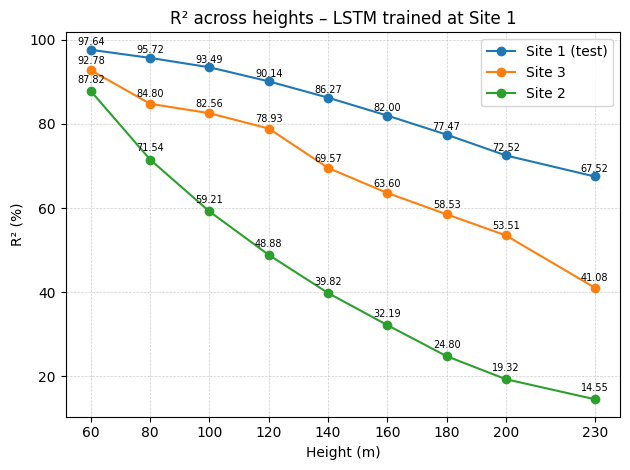

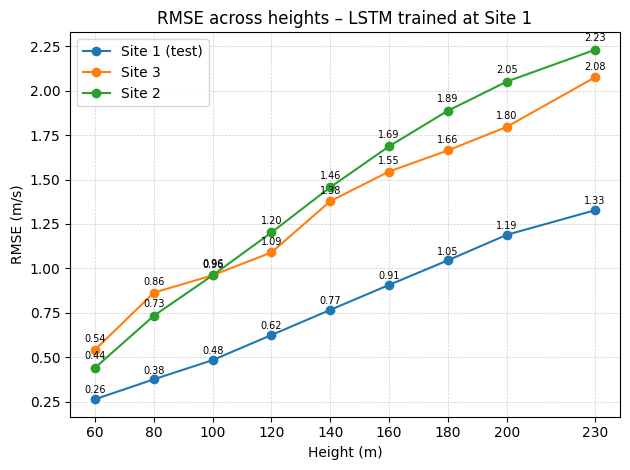

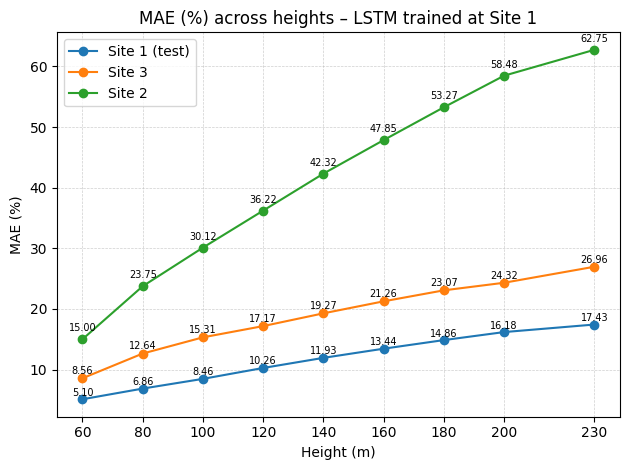


Plotting vertical wind profiles (Observed vs LSTM trained on Site 1)...


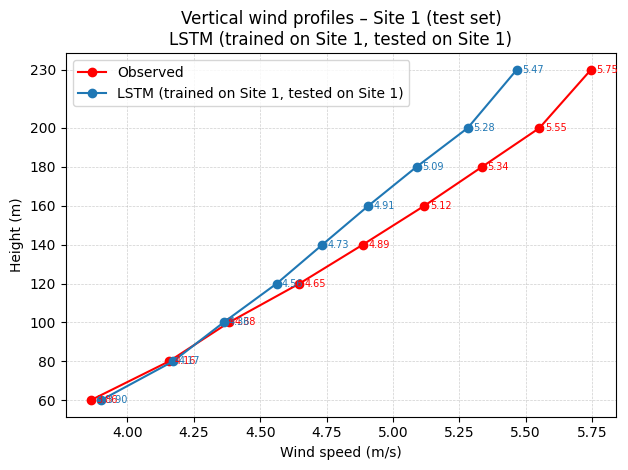

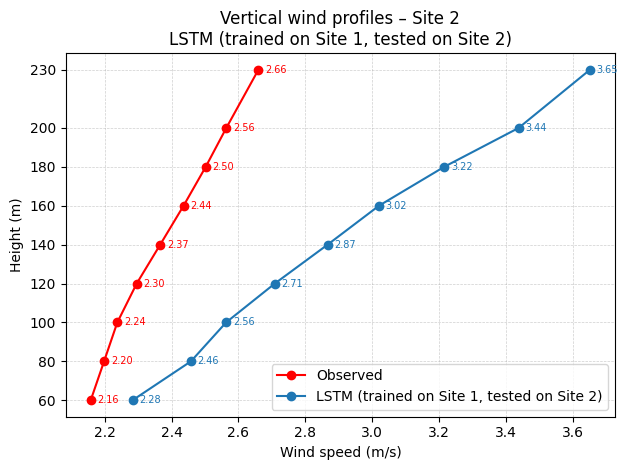

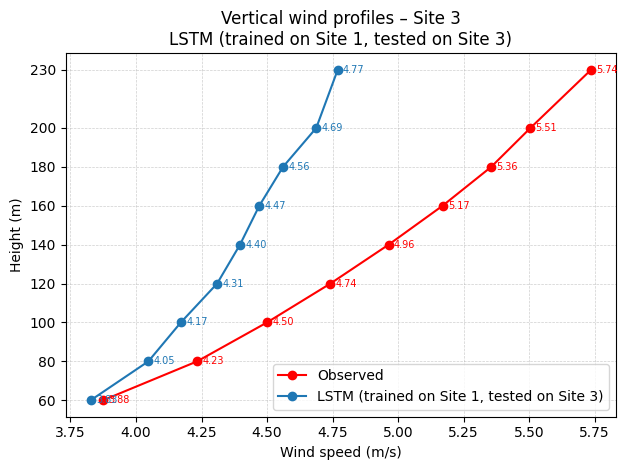

In [6]:
"""
Cross-site LSTM wind profile experiment

- Train LSTM on Site 1 (site 1 data.csv)
- Use trained model to predict Site 2 (site 2 data.csv) and Site 3 (site 3 data.csv)
- No power-law or log-law baselines.

Inputs:
    Features: Time, v40m, dir40m, TKE
    Targets : v60m ... v230m

Outputs:
    - Per-height metrics (R², MSE, RMSE, MAE, MAPE) for:
        * Site 1 (test portion only)
        * Site 2 (whole usable period)
        * Site 3 (whole usable period)
    - Plots:
        * R² vs height (one curve per site)
        * RMSE vs height (one curve per site)
        * MAE(%) vs height (one curve per site)
        * Vertical wind profiles: Observed vs LSTM (one figure per site)

Color convention (profiles):
    Observed -> red
    LSTM     -> blue
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH_SITE1 = "site 1 data.csv"
CSV_PATH_SITE2 = "site 2 data.csv"
CSV_PATH_SITE3 = "site 3 data.csv"

CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"       # handles BOM in 'indice' column

TRAIN_FRACTION = 0.90            # Site 1: 90% train, 10% test (time-ordered)
LSTM_UNITS = 30
EPOCHS = 30
BATCH_SIZE = 2
RANDOM_SEED = 42

# Temporal memory (lookback window)
TIME_STEPS = 4

FEATURE_COLS = ["Time", "v40m", "dir40m", "TKE"]
TARGET_COLS = [
    "v60m", "v80m", "v100m", "v120m",
    "v140m", "v160m", "v180m", "v200m", "v230m"
]


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(model_name, metrics_dict):
    """
    Detailed block printout per height for a given model/site.
    """
    print(f"\n=== {model_name}: Metrics per height ===")
    for col, m in metrics_dict.items():
        print(f"\n--- {col} ---")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------

def height_from_column(col_name: str) -> float:
    """
    Extract numeric height from column names like 'v60m', 'v100m', etc.
    Assumes format 'v<height>m'.
    """
    return float(col_name[1:-1])


# ------------------------------------------------------------
# Data loading & preprocessing
# ------------------------------------------------------------

def _sort_by_time(df: pd.DataFrame) -> pd.DataFrame:
    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]
    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


def load_site1_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 1 CSV file.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(inplace=True)
    df = _sort_by_time(df)
    return df


def load_site2_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 2 CSV file.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.dropna(axis=1, how="all", inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)

    core_cols = FEATURE_COLS + TARGET_COLS
    missing = [c for c in core_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in Site 2 data: {missing}")

    df.dropna(subset=core_cols, inplace=True)
    df = _sort_by_time(df)
    return df


def load_site3_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 3 CSV file.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df = _sort_by_time(df)

    essential_cols = FEATURE_COLS + TARGET_COLS
    missing = [c for c in essential_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns in Site 3 CSV: {missing}")

    df[essential_cols] = df[essential_cols].apply(
        pd.to_numeric, errors="coerce"
    )
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(subset=essential_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


# ------------------------------------------------------------
# Sequence preparation – Site 1 (training + test)
# ------------------------------------------------------------

def prepare_experiment_site1(df: pd.DataFrame, time_steps: int):
    """
    Prepare inputs and outputs for Site 1 training/testing, using a configurable
    temporal window (time_steps) for the LSTM.
    """

    X = df[FEATURE_COLS].values.astype("float32")
    y = df[TARGET_COLS].values.astype("float32")

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")
    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices where we have a full window
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split on original time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    train_indices = indices[train_mask]
    test_indices = indices[test_mask]

    # Scaling (fit on training range only)
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        X_seq[k] = X_scaled[t - time_steps + 1: t + 1, :]
        y_seq_scaled[k] = y_scaled[t, :]

    y_targets_orig = y[indices]

    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]
    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]
    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            TARGET_COLS,
            train_indices, test_indices)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression.
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    model.add(layers.Dense(output_dim))  # linear output (m/s)

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model


# ------------------------------------------------------------
# Cross-site helpers
# ------------------------------------------------------------

def prepare_inference_sequences(df: pd.DataFrame,
                                time_steps: int,
                                X_scaler: StandardScaler):
    """
    Build sequences for inference on another site (Site 2 or Site 3),
    using the X_scaler trained on Site 1.
    """
    X = df[FEATURE_COLS].values.astype("float32")
    y = df[TARGET_COLS].values.astype("float32")

    n_samples = len(df)
    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    indices = np.arange(time_steps - 1, n_samples)
    X_scaled = X_scaler.transform(X)

    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_orig = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        X_seq[k] = X_scaled[t - time_steps + 1: t + 1, :]
        y_orig[k] = y[t, :]

    return X_seq, y_orig, TARGET_COLS, indices


def evaluate_cross_site(df: pd.DataFrame,
                        site_label: str,
                        model: keras.Model,
                        X_scaler: StandardScaler,
                        y_scaler: StandardScaler,
                        time_steps: int):
    """
    Use the trained Site-1 LSTM to predict another site (or re-evaluate Site 1).
    """
    X_seq, y_true, target_cols, indices = prepare_inference_sequences(
        df, time_steps, X_scaler
    )

    y_pred_scaled = model.predict(X_seq, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    metrics_lstm = compute_height_metrics(y_true, y_pred, target_cols)
    print_height_metrics(f"LSTM – {site_label}", metrics_lstm)

    mean_obs_per_height = {
        col: float(np.mean(y_true[:, j]))
        for j, col in enumerate(target_cols)
    }
    mean_pred_per_height = {
        col: float(np.mean(y_pred[:, j]))
        for j, col in enumerate(target_cols)
    }

    return metrics_lstm, mean_obs_per_height, mean_pred_per_height, target_cols


def build_cross_site_df(site_metrics, site_mean_obs):
    """
    Build combined DataFrame for cross-site metric plots.
    """
    rows = []
    for label, metrics_dict in site_metrics.items():
        mean_obs_dict = site_mean_obs[label]
        for h, m in metrics_dict.items():
            height_m = height_from_column(h)
            mean_obs = mean_obs_dict.get(h, np.nan)
            mae = m["mae"]
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (mae / mean_obs) * 100.0

            rows.append({
                "site":       label,
                "height":     h,
                "height_m":   height_m,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     mae,
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })
    return pd.DataFrame(rows)


def plot_metric_comparison_cross(df, metric="R2"):
    """
    Plot metric vs height with one line per site (LSTM only).
    """
    metric = metric.upper()
    if metric not in ["R2", "RMSE", "MAE_PCT"]:
        raise ValueError("metric must be 'R2', 'RMSE', or 'MAE_PCT'.")

    df_sorted = df.sort_values("height_m")
    heights_vals = df_sorted["height_m"].unique()
    sites = df_sorted["site"].unique()

    plt.figure()

    for site in sites:
        df_s = df_sorted[df_sorted["site"] == site]
        x = df_s["height_m"].to_numpy()

        if metric == "R2":
            y = df_s["R2"].to_numpy() * 100.0
            y_label = "R² (%)"
            title_metric = "R²"
        elif metric == "RMSE":
            y = df_s["RMSE_ms"].to_numpy()
            y_label = "RMSE (m/s)"
            title_metric = "RMSE"
        else:
            y = df_s["MAE_pct"].to_numpy()
            y_label = "MAE (%)"
            title_metric = "MAE (%)"

        plt.plot(x, y, marker="o", linewidth=1.5, label=site)

        # Small data labels
        y_valid = y[~np.isnan(y)]
        if len(y_valid) > 0:
            y_min = np.nanmin(y_valid)
            y_max = np.nanmax(y_valid)
            y_range = y_max - y_min if y_max > y_min else 1.0
            offset = 0.02 * y_range
        else:
            offset = 0.0

        for xi, yi in zip(x, y):
            if np.isnan(yi):
                continue
            plt.text(
                xi, yi + offset,
                f"{yi:.2f}",
                ha="center",
                va="bottom",
                fontsize=7
            )

    plt.xlabel("Height (m)")
    plt.ylabel(y_label)
    plt.title(f"{title_metric} across heights – LSTM trained at Site 1")
    plt.xticks(heights_vals, [f"{int(h)}" for h in heights_vals])
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_vertical_profile_cross(site_name,
                                target_cols,
                                mean_obs_per_height,
                                mean_lstm_per_height,
                                lstm_label_suffix="(trained at Site 1)"):
    """
    Vertical wind profile: Observed vs LSTM for a single site.

    Observed -> red
    LSTM     -> blue
    """
    heights_m = np.array([height_from_column(c) for c in target_cols], dtype=float)

    obs = np.array([mean_obs_per_height[c] for c in target_cols], dtype=float)
    lstm = np.array([mean_lstm_per_height[c] for c in target_cols], dtype=float)

    plt.figure()

    plt.plot(obs, heights_m, marker="o", linewidth=1.5, color="r", label="Observed")
    plt.plot(lstm, heights_m, marker="o", linewidth=1.5, color="C0",
             label=f"LSTM {lstm_label_suffix}")

    for v, z in zip(obs, heights_m):
        plt.text(v + 0.02, z, f"{v:.2f}", va="center", fontsize=7, color="r")
    for v, z in zip(lstm, heights_m):
        plt.text(v + 0.02, z, f"{v:.2f}", va="center", fontsize=7, color="C0")

    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Height (m)")
    plt.yticks(heights_m, [f"{int(h)}" for h in heights_m])
    plt.title(f"Vertical wind profiles – {site_name}\nLSTM {lstm_label_suffix}")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Training on Site 1
# ------------------------------------------------------------

def train_site1_lstm(df: pd.DataFrame, time_steps: int):
    """
    Train LSTM on Site 1 and evaluate on Site 1 test set.
    Returns:
        model, X_scaler, y_scaler,
        metrics_site1, mean_obs_site1, mean_pred_site1, target_cols
    """
    # Deterministic behaviour
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols,
     train_indices, test_indices) = prepare_experiment_site1(df, time_steps=time_steps)

    print("  X_train shape (Site 1):", X_train.shape)
    print("  y_train shape (Site 1):", y_train_scaled.shape)

    input_shape = X_train.shape[1:]
    output_dim = y_train_scaled.shape[1]

    model = build_lstm_model(input_shape, output_dim)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("  Training LSTM on Site 1...")
    model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        shuffle=False,
        callbacks=[early_stop],
        verbose=0
    )

    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  Site 1 LSTM test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  Site 1 LSTM test MAE  (scaled):      {test_mae:.4f}")

    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    metrics_site1 = compute_height_metrics(y_test_orig, y_pred, target_cols)

    mean_obs_site1 = {
        col: float(np.mean(y_test_orig[:, j]))
        for j, col in enumerate(target_cols)
    }
    mean_pred_site1 = {
        col: float(np.mean(y_pred[:, j]))
        for j, col in enumerate(target_cols)
    }

    print_height_metrics("LSTM – Site 1 (test)", metrics_site1)

    return (model,
            X_scaler, y_scaler,
            metrics_site1,
            mean_obs_site1,
            mean_pred_site1,
            target_cols)


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():
    # ---------- Site 1: training ----------
    print("Loading Site 1 data...")
    df1 = load_site1_dataframe(CSV_PATH_SITE1, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning (Site 1): {df1.shape}")
    if len(df1) == 0:
        raise ValueError("Site 1 dataframe is empty after cleaning.")

    print(f"\n=== Training LSTM on Site 1 (TIME_STEPS = {TIME_STEPS}) ===")
    (model_s1,
     X_scaler_s1, y_scaler_s1,
     metrics_s1,
     mean_obs_s1,
     mean_pred_s1,
     target_cols_s1) = train_site1_lstm(df1, time_steps=TIME_STEPS)

    # ---------- Cross-site: Site 2 ----------
    print("\nLoading Site 2 data for cross-site prediction...")
    df2 = load_site2_dataframe(CSV_PATH_SITE2, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning (Site 2): {df2.shape}")
    (metrics_s2,
     mean_obs_s2,
     mean_pred_s2,
     target_cols_s2) = evaluate_cross_site(
        df2, "Site 2", model_s1, X_scaler_s1, y_scaler_s1, TIME_STEPS
    )

    # ---------- Cross-site: Site 3 ----------
    print("\nLoading Site 3 data for cross-site prediction...")
    df3 = load_site3_dataframe(CSV_PATH_SITE3, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning (Site 3): {df3.shape}")
    (metrics_s3,
     mean_obs_s3,
     mean_pred_s3,
     target_cols_s3) = evaluate_cross_site(
        df3, "Site 3", model_s1, X_scaler_s1, y_scaler_s1, TIME_STEPS
    )

    # ---------- Cross-site metric plots ----------
    site_metrics = {
        "Site 1 (test)": metrics_s1,
        "Site 2":        metrics_s2,
        "Site 3":        metrics_s3,
    }
    site_mean_obs = {
        "Site 1 (test)": mean_obs_s1,
        "Site 2":        mean_obs_s2,
        "Site 3":        mean_obs_s3,
    }

    cross_df = build_cross_site_df(site_metrics, site_mean_obs)

    print("\nPlotting cross-site R² / RMSE / MAE% vs height – LSTM only...")
    plot_metric_comparison_cross(cross_df, metric="R2")
    plot_metric_comparison_cross(cross_df, metric="RMSE")
    plot_metric_comparison_cross(cross_df, metric="MAE_PCT")

    # ---------- Cross-site vertical profiles ----------
    print("\nPlotting vertical wind profiles (Observed vs LSTM trained on Site 1)...")
    plot_vertical_profile_cross("Site 1 (test set)",
                                target_cols_s1,
                                mean_obs_s1,
                                mean_pred_s1,
                                lstm_label_suffix="(trained on Site 1, tested on Site 1)")
    plot_vertical_profile_cross("Site 2",
                                target_cols_s2,
                                mean_obs_s2,
                                mean_pred_s2,
                                lstm_label_suffix="(trained on Site 1, tested on Site 2)")
    plot_vertical_profile_cross("Site 3",
                                target_cols_s3,
                                mean_obs_s3,
                                mean_pred_s3,
                                lstm_label_suffix="(trained on Site 1, tested on Site 3)")


if __name__ == "__main__":
    main()


### Using v40 m and v60 m

Loading Site 1 data...
Data shape after cleaning (Site 1): (17744, 18)

=== Training LSTM on Site 1 (TIME_STEPS = 4) ===
  X_train shape (Site 1): (15966, 4, 5)
  y_train shape (Site 1): (15966, 8)
  Training LSTM on Site 1...
Epoch 1/30
7185/7185 ━━━━━━━━━━━━━━━━━━━━ 4s 522us/step - loss: 0.1429 - mae: 0.2710 - val_loss: 0.0924 - val_mae: 0.2236 - learning_rate: 0.0010
Epoch 2/30
7185/7185 ━━━━━━━━━━━━━━━━━━━━ 4s 519us/step - loss: 0.1018 - mae: 0.2284 - val_loss: 0.0838 - val_mae: 0.2103 - learning_rate: 0.0010
Epoch 3/30
7185/7185 ━━━━━━━━━━━━━━━━━━━━ 4s 525us/step - loss: 0.0902 - mae: 0.2139 - val_loss: 0.0767 - val_mae: 0.1996 - learning_rate: 0.0010
Epoch 4/30
7185/7185 ━━━━━━━━━━━━━━━━━━━━ 4s 517us/step - loss: 0.0836 - mae: 0.2057 - val_loss: 0.0733 - val_mae: 0.1944 - learning_rate: 0.0010
Epoch 5/30
7185/7185 ━━━━━━━━━━━━━━━━━━━━ 4s 535us/step - loss: 0.0801 - mae: 0.2014 - val_loss: 0.0721 - val_mae: 0.1922 - learning_rate: 0.0010
Epoch 6/30
7185/7185 ━━━━━━━━━━━━━━━━━━━━ 4

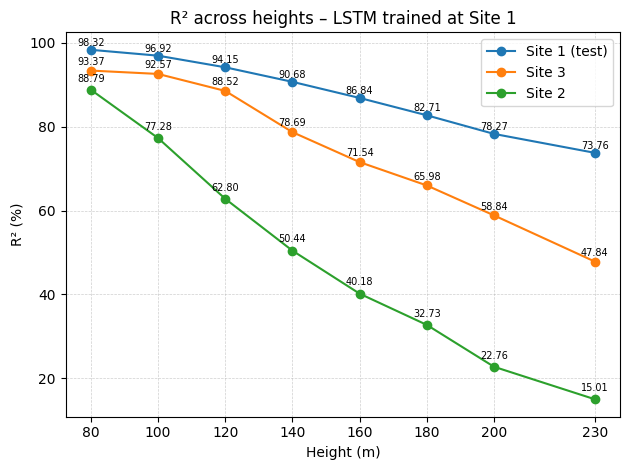

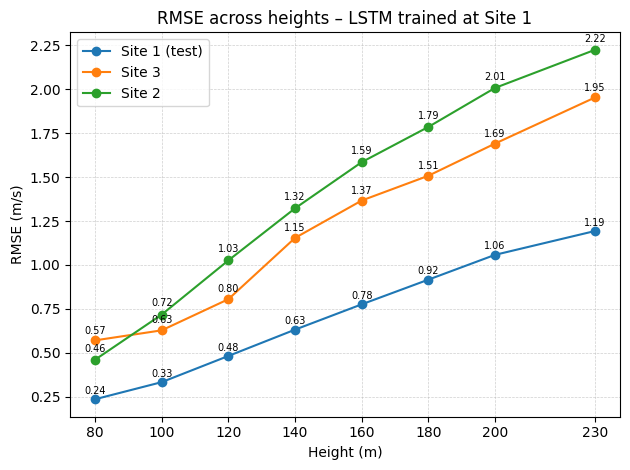

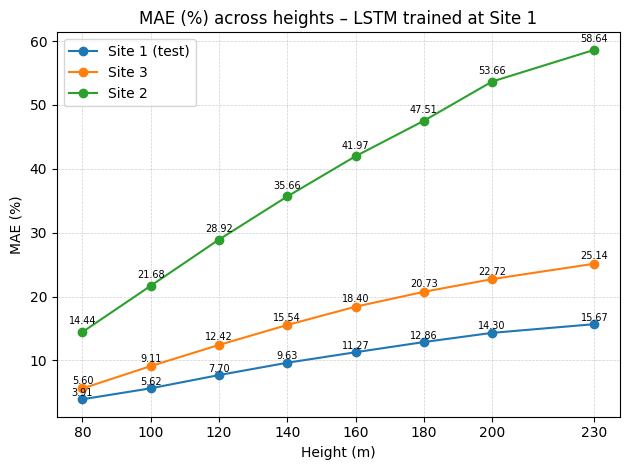


Plotting vertical wind profiles (Observed vs LSTM trained on Site 1)...


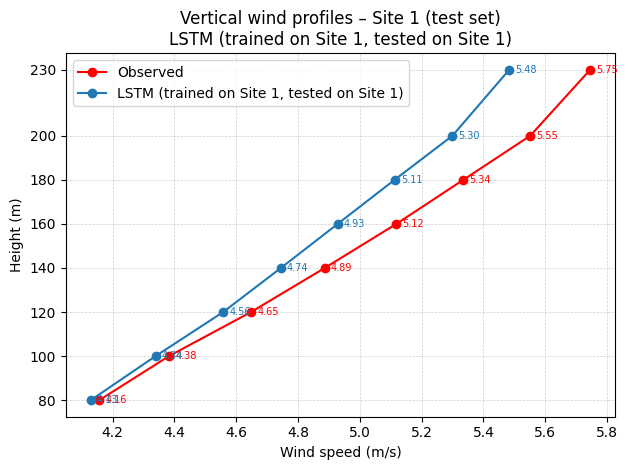

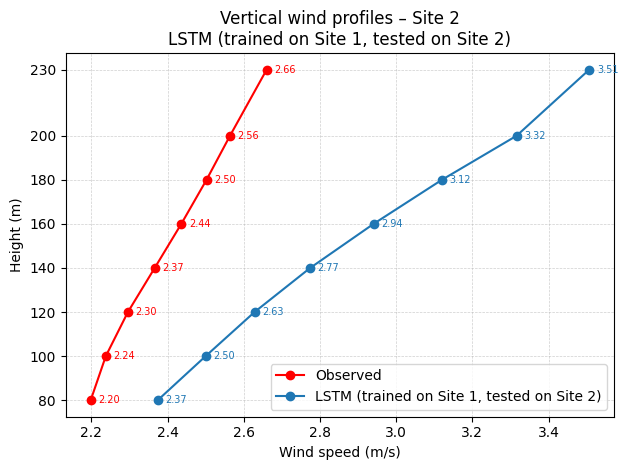

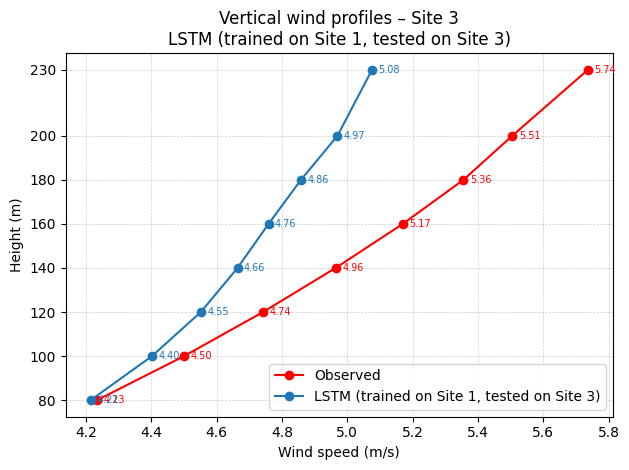

In [7]:
"""
Cross-site LSTM wind profile experiment

- Train LSTM on Site 1 (site 1 data.csv)
- Use trained model to predict Site 2 (site 2 data.csv) and Site 3 (site 3 data.csv)

Inputs:
    Features: Time, v40m, v60m, dir40m, TKE
    Targets : v80m ... v230m  (heights above 60 m)

Outputs:
    - Per-height metrics (R², MSE, RMSE, MAE, MAPE) for:
        * Site 1 (test portion only)
        * Site 2 (whole usable period)
        * Site 3 (whole usable period)
    - Plots:
        * R² vs height (one curve per site)
        * RMSE vs height (one curve per site)
        * MAE(%) vs height (one curve per site)
        * Vertical wind profiles: Observed vs LSTM (one figure per site)

Color convention (profiles):
    Observed -> red
    LSTM     -> blue
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH_SITE1 = "site 1 data.csv"
CSV_PATH_SITE2 = "site 2 data.csv"
CSV_PATH_SITE3 = "site 3 data.csv"

CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"       # handles BOM in 'indice' column

TRAIN_FRACTION = 0.90            # Site 1: 90% train, 10% test (time-ordered)
LSTM_UNITS = 30
EPOCHS = 30
BATCH_SIZE = 2
RANDOM_SEED = 42

# Temporal memory (lookback window)
TIME_STEPS = 4

# Inputs follow the paper: hour (Time), 40 m and 60 m wind speed,
# wind direction at 40 m, and TKE at 40 m.
FEATURE_COLS = ["Time", "v40m", "v60m", "dir40m", "TKE"]

# Targets are heights ABOVE 60 m, as in the experiments where
# 60 m is used as an additional input level to improve extrapolation.
TARGET_COLS = [
    "v80m", "v100m", "v120m",
    "v140m", "v160m", "v180m", "v200m", "v230m"
]


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(model_name, metrics_dict):
    """
    Detailed block printout per height for a given model/site.
    """
    print(f"\n=== {model_name}: Metrics per height ===")
    for col, m in metrics_dict.items():
        print(f"\n--- {col} ---")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------

def height_from_column(col_name: str) -> float:
    """
    Extract numeric height from column names like 'v60m', 'v100m', etc.
    Assumes format 'v<height>m'.
    """
    return float(col_name[1:-1])


# ------------------------------------------------------------
# Data loading & preprocessing
# ------------------------------------------------------------

def _sort_by_time(df: pd.DataFrame) -> pd.DataFrame:
    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]
    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


def load_site1_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 1 CSV file.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(inplace=True)
    df = _sort_by_time(df)
    return df


def load_site2_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 2 CSV file.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.dropna(axis=1, how="all", inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)

    core_cols = FEATURE_COLS + TARGET_COLS
    missing = [c for c in core_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in Site 2 data: {missing}")

    df.dropna(subset=core_cols, inplace=True)
    df = _sort_by_time(df)
    return df


def load_site3_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 3 CSV file.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df = _sort_by_time(df)

    essential_cols = FEATURE_COLS + TARGET_COLS
    missing = [c for c in essential_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns in Site 3 CSV: {missing}")

    df[essential_cols] = df[essential_cols].apply(
        pd.to_numeric, errors="coerce"
    )
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(subset=essential_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


# ------------------------------------------------------------
# Sequence preparation – Site 1 (training + test)
# ------------------------------------------------------------

def prepare_experiment_site1(df: pd.DataFrame, time_steps: int):
    """
    Prepare inputs and outputs for Site 1 training/testing, using a configurable
    temporal window (time_steps) for the LSTM.
    """

    X = df[FEATURE_COLS].values.astype("float32")
    y = df[TARGET_COLS].values.astype("float32")

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")
    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices where we have a full window
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split on original time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    train_indices = indices[train_mask]
    test_indices = indices[test_mask]

    # Scaling (fit on training range only)
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        X_seq[k] = X_scaled[t - time_steps + 1: t + 1, :]
        y_seq_scaled[k] = y_scaled[t, :]

    y_targets_orig = y[indices]

    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]
    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]
    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            TARGET_COLS,
            train_indices, test_indices)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression.
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    model.add(layers.Dense(output_dim))  # linear output (m/s)

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model


# ------------------------------------------------------------
# Cross-site helpers
# ------------------------------------------------------------

def prepare_inference_sequences(df: pd.DataFrame,
                                time_steps: int,
                                X_scaler: StandardScaler):
    """
    Build sequences for inference on another site (Site 2 or Site 3),
    using the X_scaler trained on Site 1.
    """
    X = df[FEATURE_COLS].values.astype("float32")
    y = df[TARGET_COLS].values.astype("float32")

    n_samples = len(df)
    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    indices = np.arange(time_steps - 1, n_samples)
    X_scaled = X_scaler.transform(X)

    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_orig = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        X_seq[k] = X_scaled[t - time_steps + 1: t + 1, :]
        y_orig[k] = y[t, :]

    return X_seq, y_orig, TARGET_COLS, indices


def evaluate_cross_site(df: pd.DataFrame,
                        site_label: str,
                        model: keras.Model,
                        X_scaler: StandardScaler,
                        y_scaler: StandardScaler,
                        time_steps: int):
    """
    Use the trained Site-1 LSTM to predict another site (or re-evaluate Site 1).
    """
    X_seq, y_true, target_cols, indices = prepare_inference_sequences(
        df, time_steps, X_scaler
    )

    y_pred_scaled = model.predict(X_seq, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    metrics_lstm = compute_height_metrics(y_true, y_pred, target_cols)
    print_height_metrics(f"LSTM – {site_label}", metrics_lstm)

    mean_obs_per_height = {
        col: float(np.mean(y_true[:, j]))
        for j, col in enumerate(target_cols)
    }
    mean_pred_per_height = {
        col: float(np.mean(y_pred[:, j]))
        for j, col in enumerate(target_cols)
    }

    return metrics_lstm, mean_obs_per_height, mean_pred_per_height, target_cols


def build_cross_site_df(site_metrics, site_mean_obs):
    """
    Build combined DataFrame for cross-site metric plots.
    """
    rows = []
    for label, metrics_dict in site_metrics.items():
        mean_obs_dict = site_mean_obs[label]
        for h, m in metrics_dict.items():
            height_m = height_from_column(h)
            mean_obs = mean_obs_dict.get(h, np.nan)
            mae = m["mae"]
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (mae / mean_obs) * 100.0

            rows.append({
                "site":       label,
                "height":     h,
                "height_m":   height_m,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     mae,
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })
    return pd.DataFrame(rows)


def plot_metric_comparison_cross(df, metric="R2"):
    """
    Plot metric vs height with one line per site (LSTM only).
    """
    metric = metric.upper()
    if metric not in ["R2", "RMSE", "MAE_PCT"]:
        raise ValueError("metric must be 'R2', 'RMSE', or 'MAE_PCT'.")

    df_sorted = df.sort_values("height_m")
    heights_vals = df_sorted["height_m"].unique()
    sites = df_sorted["site"].unique()

    plt.figure()

    for site in sites:
        df_s = df_sorted[df_sorted["site"] == site]
        x = df_s["height_m"].to_numpy()

        if metric == "R2":
            y = df_s["R2"].to_numpy() * 100.0
            y_label = "R² (%)"
            title_metric = "R²"
        elif metric == "RMSE":
            y = df_s["RMSE_ms"].to_numpy()
            y_label = "RMSE (m/s)"
            title_metric = "RMSE"
        else:
            y = df_s["MAE_pct"].to_numpy()
            y_label = "MAE (%)"
            title_metric = "MAE (%)"

        plt.plot(x, y, marker="o", linewidth=1.5, label=site)

        # Small data labels
        y_valid = y[~np.isnan(y)]
        if len(y_valid) > 0:
            y_min = np.nanmin(y_valid)
            y_max = np.nanmax(y_valid)
            y_range = y_max - y_min if y_max > y_min else 1.0
            offset = 0.02 * y_range
        else:
            offset = 0.0

        for xi, yi in zip(x, y):
            if np.isnan(yi):
                continue
            plt.text(
                xi, yi + offset,
                f"{yi:.2f}",
                ha="center",
                va="bottom",
                fontsize=7
            )

    plt.xlabel("Height (m)")
    plt.ylabel(y_label)
    plt.title(f"{title_metric} across heights – LSTM trained at Site 1")
    plt.xticks(heights_vals, [f"{int(h)}" for h in heights_vals])
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_vertical_profile_cross(site_name,
                                target_cols,
                                mean_obs_per_height,
                                mean_lstm_per_height,
                                lstm_label_suffix="(trained at Site 1)"):
    """
    Vertical wind profile: Observed vs LSTM for a single site.

    Observed -> red
    LSTM     -> blue
    """
    heights_m = np.array([height_from_column(c) for c in target_cols], dtype=float)

    obs = np.array([mean_obs_per_height[c] for c in target_cols], dtype=float)
    lstm = np.array([mean_lstm_per_height[c] for c in target_cols], dtype=float)

    plt.figure()

    plt.plot(obs, heights_m, marker="o", linewidth=1.5, color="r", label="Observed")
    plt.plot(lstm, heights_m, marker="o", linewidth=1.5, color="C0",
             label=f"LSTM {lstm_label_suffix}")

    for v, z in zip(obs, heights_m):
        plt.text(v + 0.02, z, f"{v:.2f}", va="center", fontsize=7, color="r")
    for v, z in zip(lstm, heights_m):
        plt.text(v + 0.02, z, f"{v:.2f}", va="center", fontsize=7, color="C0")

    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Height (m)")
    plt.yticks(heights_m, [f"{int(h)}" for h in heights_m])
    plt.title(f"Vertical wind profiles – {site_name}\nLSTM {lstm_label_suffix}")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Training on Site 1
# ------------------------------------------------------------

def train_site1_lstm(df: pd.DataFrame, time_steps: int):
    """
    Train LSTM on Site 1 and evaluate on Site 1 test set.
    Returns:
        model, X_scaler, y_scaler,
        metrics_site1, mean_obs_site1, mean_pred_site1, target_cols
    """
    # Deterministic behaviour
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols,
     train_indices, test_indices) = prepare_experiment_site1(df, time_steps=time_steps)

    print("  X_train shape (Site 1):", X_train.shape)
    print("  y_train shape (Site 1):", y_train_scaled.shape)

    input_shape = X_train.shape[1:]
    output_dim = y_train_scaled.shape[1]

    model = build_lstm_model(input_shape, output_dim)

    # Slightly more patient training with LR scheduling for better accuracy
    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    )

    print("  Training LSTM on Site 1...")
    model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        shuffle=False,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  Site 1 LSTM test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  Site 1 LSTM test MAE  (scaled):      {test_mae:.4f}")

    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    metrics_site1 = compute_height_metrics(y_test_orig, y_pred, target_cols)

    mean_obs_site1 = {
        col: float(np.mean(y_test_orig[:, j]))
        for j, col in enumerate(target_cols)
    }
    mean_pred_site1 = {
        col: float(np.mean(y_pred[:, j]))
        for j, col in enumerate(target_cols)
    }

    print_height_metrics("LSTM – Site 1 (test)", metrics_site1)

    return (model,
            X_scaler, y_scaler,
            metrics_site1,
            mean_obs_site1,
            mean_pred_site1,
            target_cols)


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():
    """
    Cross-site LSTM wind profile experiment

    - Train LSTM on Site 1 (site 1 data.csv)
    - Use trained model to predict Site 2 (site 2 data.csv) and Site 3 (site 3 data.csv)
    - Inputs:  Time, v40m, v60m, dir40m, TKE
    - Targets: v80m ... v230m
    - No power-law or log-law baselines.
    """
    # ---------- Site 1: training ----------
    print("Loading Site 1 data...")
    df1 = load_site1_dataframe(CSV_PATH_SITE1, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning (Site 1): {df1.shape}")
    if len(df1) == 0:
        raise ValueError("Site 1 dataframe is empty after cleaning.")

    print(f"\n=== Training LSTM on Site 1 (TIME_STEPS = {TIME_STEPS}) ===")
    (model_s1,
     X_scaler_s1, y_scaler_s1,
     metrics_s1,
     mean_obs_s1,
     mean_pred_s1,
     target_cols_s1) = train_site1_lstm(df1, time_steps=TIME_STEPS)

    # ---------- Cross-site: Site 2 ----------
    print("\nLoading Site 2 data for cross-site prediction...")
    df2 = load_site2_dataframe(CSV_PATH_SITE2, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning (Site 2): {df2.shape}")
    (metrics_s2,
     mean_obs_s2,
     mean_pred_s2,
     target_cols_s2) = evaluate_cross_site(
        df2, "Site 2", model_s1, X_scaler_s1, y_scaler_s1, TIME_STEPS
    )

    # ---------- Cross-site: Site 3 ----------
    print("\nLoading Site 3 data for cross-site prediction...")
    df3 = load_site3_dataframe(CSV_PATH_SITE3, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning (Site 3): {df3.shape}")
    (metrics_s3,
     mean_obs_s3,
     mean_pred_s3,
     target_cols_s3) = evaluate_cross_site(
        df3, "Site 3", model_s1, X_scaler_s1, y_scaler_s1, TIME_STEPS
    )

    # ---------- Cross-site metric plots ----------
    site_metrics = {
        "Site 1 (test)": metrics_s1,
        "Site 2":        metrics_s2,
        "Site 3":        metrics_s3,
    }
    site_mean_obs = {
        "Site 1 (test)": mean_obs_s1,
        "Site 2":        mean_obs_s2,
        "Site 3":        mean_obs_s3,
    }

    cross_df = build_cross_site_df(site_metrics, site_mean_obs)

    print("\nPlotting cross-site R² / RMSE / MAE% vs height – LSTM only...")
    plot_metric_comparison_cross(cross_df, metric="R2")
    plot_metric_comparison_cross(cross_df, metric="RMSE")
    plot_metric_comparison_cross(cross_df, metric="MAE_PCT")

    # ---------- Cross-site vertical profiles ----------
    print("\nPlotting vertical wind profiles (Observed vs LSTM trained on Site 1)...")
    plot_vertical_profile_cross("Site 1 (test set)",
                                target_cols_s1,
                                mean_obs_s1,
                                mean_pred_s1,
                                lstm_label_suffix="(trained on Site 1, tested on Site 1)")
    plot_vertical_profile_cross("Site 2",
                                target_cols_s2,
                                mean_obs_s2,
                                mean_pred_s2,
                                lstm_label_suffix="(trained on Site 1, tested on Site 2)")
    plot_vertical_profile_cross("Site 3",
                                target_cols_s3,
                                mean_obs_s3,
                                mean_pred_s3,
                                lstm_label_suffix="(trained on Site 1, tested on Site 3)")


if __name__ == "__main__":
    main()


Loading Site 1 data...
Data shape after cleaning (Site 1): (17744, 18)

=== Training LSTM on Site 1 (TIME_STEPS = 4) ===
  X_train shape (Site 1): (15966, 4, 5)
  y_train shape (Site 1): (15966, 8)
  Training LSTM on Site 1...
Epoch 1/30
7185/7185 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 0.1395 - mae: 0.2689 - val_loss: 0.0951 - val_mae: 0.2278 - learning_rate: 0.0010
Epoch 2/30
7185/7185 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - loss: 0.1029 - mae: 0.2304 - val_loss: 0.0824 - val_mae: 0.2078 - learning_rate: 0.0010
Epoch 3/30
7185/7185 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - loss: 0.0907 - mae: 0.2154 - val_loss: 0.0755 - val_mae: 0.1975 - learning_rate: 0.0010
Epoch 4/30
7185/7185 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.0841 - mae: 0.2070 - val_loss: 0.0728 - val_mae: 0.1928 - learning_rate: 0.0010
Epoch 5/30
7185/7185 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.0804 - mae: 0.2022 - val_loss: 0.0721 - val_mae: 0.1910 - learning_rate: 0.0010
Epoch 6/30
7185/7185 ━━━━━━━━━━━━━━━━━━━━ 11s 1m

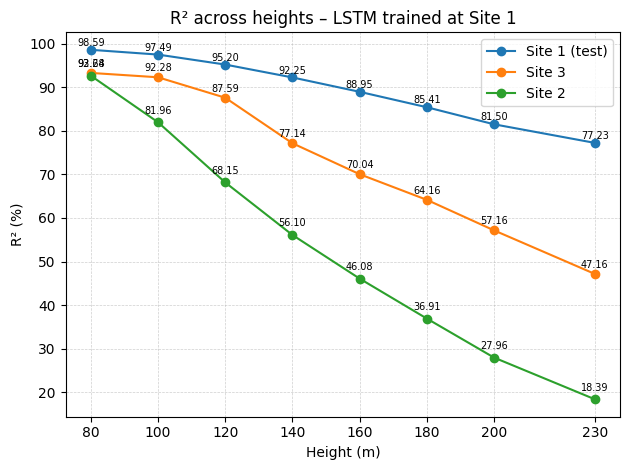

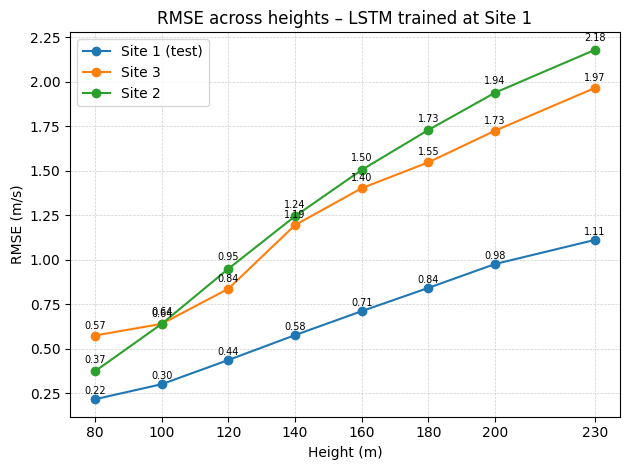

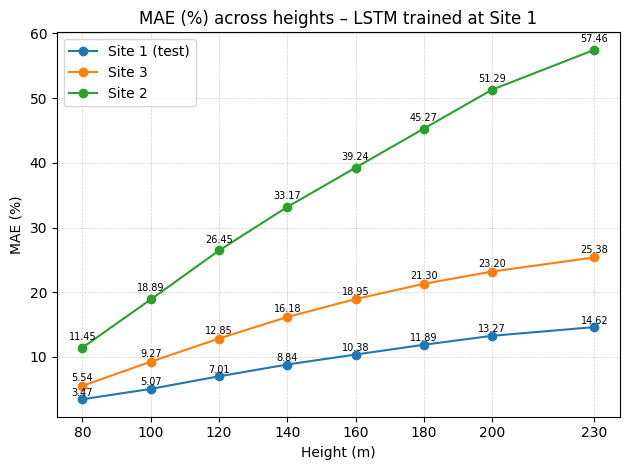


Plotting vertical wind profiles (Observed vs LSTM vs Power/log-law, trained on Site 1)...


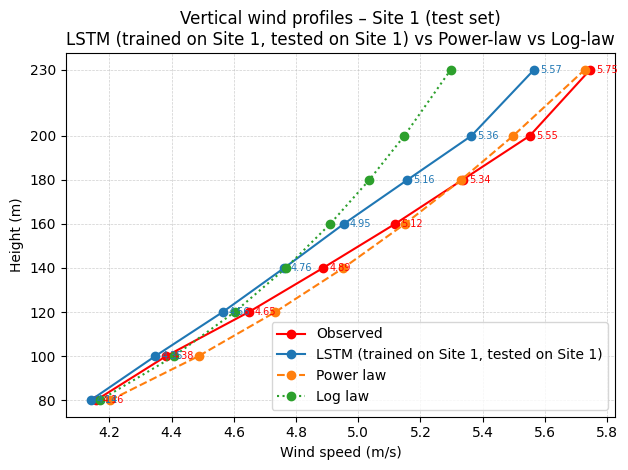

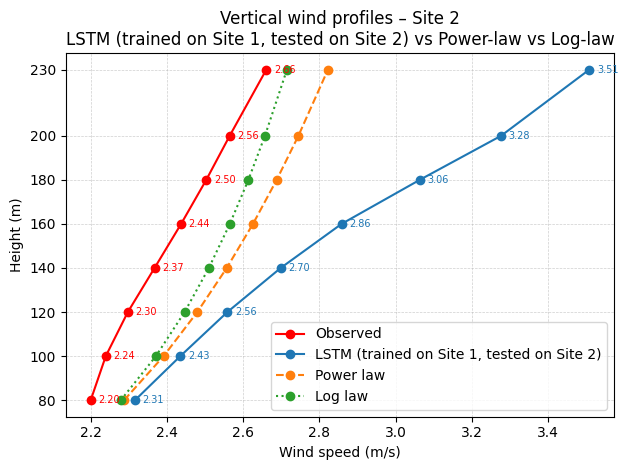

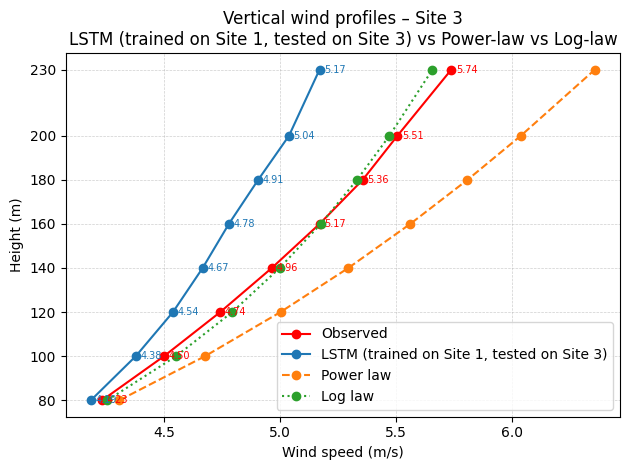

In [8]:
"""
Cross-site LSTM wind profile experiment

- Train LSTM on Site 1 (site 1 data.csv)
- Use trained model to predict Site 2 (site 2 data.csv) and Site 3 (site 3 data.csv)

Inputs:
    Features: Time, v40m, v60m, dir40m, TKE
    Targets : v80m ... v230m  (heights above 60 m)

Outputs:
    - Per-height metrics (R², MSE, RMSE, MAE, MAPE) for:
        * Site 1 (test portion only)
        * Site 2 (whole usable period)
        * Site 3 (whole usable period)
    - Plots:
        * R² vs height (one curve per site)
        * RMSE vs height (one curve per site)
        * MAE(%) vs height (one curve per site)
        * Vertical wind profiles: Observed vs LSTM vs Power-law vs Log-law (one figure per site)

Color convention (profiles):
    Observed -> red
    LSTM     -> blue
    Power law -> C1 (dashed)
    Log law   -> C2 (dotted)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
models = keras.models
callbacks = keras.callbacks


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CSV_PATH_SITE1 = "site 1 data.csv"
CSV_PATH_SITE2 = "site 2 data.csv"
CSV_PATH_SITE3 = "site 3 data.csv"

CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"       # handles BOM in 'indice' column

TRAIN_FRACTION = 0.90            # Site 1: 90% train, 10% test (time-ordered)
LSTM_UNITS = 30
EPOCHS = 30
BATCH_SIZE = 2
RANDOM_SEED = 42

# Temporal memory (lookback window)
TIME_STEPS = 4

# Inputs follow the paper: hour (Time), 40 m and 60 m wind speed,
# wind direction at 40 m, and TKE at 40 m.
FEATURE_COLS = ["Time", "v40m", "v60m", "dir40m", "TKE"]

# Targets are heights ABOVE 60 m, as in the experiments where
# 60 m is used as an additional input level to improve extrapolation.
TARGET_COLS = [
    "v80m", "v100m", "v120m",
    "v140m", "v160m", "v180m", "v200m", "v230m"
]


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def mape(y_true, y_pred, eps=1e-3):
    """
    Mean Absolute Percentage Error (MAPE) in percent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))
    ) * 100.0


def compute_height_metrics(y_true, y_pred, target_cols):
    """
    Compute metrics (R², MSE, RMSE, MAE, MAPE) for each output height.

    Returns:
        dict: {height_name: {"r2": ..., "mse": ..., "rmse": ..., "mae": ..., "mape": ...}, ...}
    """
    metrics = {}
    for j, col in enumerate(target_cols):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)

        metrics[col] = {
            "r2":   r2_score(yt, yp),
            "mse":  mse,
            "rmse": rmse,
            "mae":  mean_absolute_error(yt, yp),
            "mape": mape(yt, yp),
        }
    return metrics


def print_height_metrics(model_name, metrics_dict):
    """
    Detailed block printout per height for a given model/site.
    """
    print(f"\n=== {model_name}: Metrics per height ===")
    for col, m in metrics_dict.items():
        print(f"\n--- {col} ---")
        print(f"R²   : {m['r2']:10.3f}")
        print(f"MSE  : {m['mse']:10.4f} (m²/s²)")
        print(f"RMSE : {m['rmse']:10.4f} (m/s)")
        print(f"MAE  : {m['mae']:10.4f} (m/s)")
        print(f"MAPE : {m['mape']:10.2f} (%)")


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------

def height_from_column(col_name: str) -> float:
    """
    Extract numeric height from column names like 'v60m', 'v100m', etc.
    Assumes format 'v<height>m'.
    """
    return float(col_name[1:-1])


# ------------------------------------------------------------
# Data loading & preprocessing
# ------------------------------------------------------------

def _sort_by_time(df: pd.DataFrame) -> pd.DataFrame:
    if "indice" in df.columns:
        index_col = "indice"
    else:
        index_col = df.columns[0]
    df.sort_values(index_col, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


def load_site1_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 1 CSV file.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(inplace=True)
    df = _sort_by_time(df)
    return df


def load_site2_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 2 CSV file.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df.dropna(axis=1, how="all", inplace=True)
    df.interpolate(method="linear", limit_direction="both", inplace=True)

    core_cols = FEATURE_COLS + TARGET_COLS
    missing = [c for c in core_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in Site 2 data: {missing}")

    df.dropna(subset=core_cols, inplace=True)
    df = _sort_by_time(df)
    return df


def load_site3_dataframe(path: str,
                         sep: str = ";",
                         encoding: str = "utf-8-sig") -> pd.DataFrame:
    """
    Load and clean the Site 3 CSV file.
    """
    df = pd.read_csv(path, sep=sep, encoding=encoding)
    df.replace([-9999, -9999.0], np.nan, inplace=True)
    df = _sort_by_time(df)

    essential_cols = FEATURE_COLS + TARGET_COLS
    missing = [c for c in essential_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns in Site 3 CSV: {missing}")

    df[essential_cols] = df[essential_cols].apply(
        pd.to_numeric, errors="coerce"
    )
    df.interpolate(method="linear", limit_direction="both", inplace=True)
    df.dropna(subset=essential_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


# ------------------------------------------------------------
# Sequence preparation – Site 1 (training + test)
# ------------------------------------------------------------

def prepare_experiment_site1(df: pd.DataFrame, time_steps: int):
    """
    Prepare inputs and outputs for Site 1 training/testing, using a configurable
    temporal window (time_steps) for the LSTM.
    """

    X = df[FEATURE_COLS].values.astype("float32")
    y = df[TARGET_COLS].values.astype("float32")

    n_samples = len(df)
    if time_steps < 1:
        raise ValueError("time_steps must be >= 1")
    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    # Indices where we have a full window
    indices = np.arange(time_steps - 1, n_samples)

    # Train/test split on original time indices
    train_size = int(n_samples * TRAIN_FRACTION)
    train_mask = indices < train_size
    test_mask = indices >= train_size

    train_indices = indices[train_mask]
    test_indices = indices[test_mask]

    # Scaling (fit on training range only)
    X_train_for_scaler = X[:train_size]
    y_train_for_scaler = y[:train_size]

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaler.fit(X_train_for_scaler)
    y_scaler.fit(y_train_for_scaler)

    X_scaled = X_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_seq_scaled = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        X_seq[k] = X_scaled[t - time_steps + 1: t + 1, :]
        y_seq_scaled[k] = y_scaled[t, :]

    y_targets_orig = y[indices]

    X_train_scaled = X_seq[train_mask]
    X_test_scaled = X_seq[test_mask]
    y_train_scaled = y_seq_scaled[train_mask]
    y_test_scaled = y_seq_scaled[test_mask]
    y_train_orig = y_targets_orig[train_mask]
    y_test_orig = y_targets_orig[test_mask]

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            y_train_orig, y_test_orig,
            X_scaler, y_scaler,
            TARGET_COLS,
            train_indices, test_indices)


# ------------------------------------------------------------
# Model building
# ------------------------------------------------------------

def build_lstm_model(input_shape, output_dim, units=LSTM_UNITS):
    """
    Simple LSTM model for multi-output regression.
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.LSTM(
        units=units,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))
    model.add(layers.Dense(output_dim))  # linear output (m/s)

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model


# ------------------------------------------------------------
# Cross-site helpers
# ------------------------------------------------------------

def prepare_inference_sequences(df: pd.DataFrame,
                                time_steps: int,
                                X_scaler: StandardScaler):
    """
    Build sequences for inference on another site (Site 2 or Site 3),
    using the X_scaler trained on Site 1.
    """
    X = df[FEATURE_COLS].values.astype("float32")
    y = df[TARGET_COLS].values.astype("float32")

    n_samples = len(df)
    if n_samples <= time_steps:
        raise ValueError(
            f"Not enough samples ({n_samples}) for time_steps={time_steps}."
        )

    indices = np.arange(time_steps - 1, n_samples)
    X_scaled = X_scaler.transform(X)

    n_seq = len(indices)
    n_features = X.shape[1]
    n_heights = y.shape[1]

    X_seq = np.zeros((n_seq, time_steps, n_features), dtype="float32")
    y_orig = np.zeros((n_seq, n_heights), dtype="float32")

    for k, t in enumerate(indices):
        X_seq[k] = X_scaled[t - time_steps + 1: t + 1, :]
        y_orig[k] = y[t, :]

    return X_seq, y_orig, TARGET_COLS, indices


def evaluate_cross_site(df: pd.DataFrame,
                        site_label: str,
                        model: keras.Model,
                        X_scaler: StandardScaler,
                        y_scaler: StandardScaler,
                        time_steps: int):
    """
    Use the trained Site-1 LSTM to predict another site (or re-evaluate Site 1).
    """
    X_seq, y_true, target_cols, indices = prepare_inference_sequences(
        df, time_steps, X_scaler
    )

    y_pred_scaled = model.predict(X_seq, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    metrics_lstm = compute_height_metrics(y_true, y_pred, target_cols)
    print_height_metrics(f"LSTM – {site_label}", metrics_lstm)

    mean_obs_per_height = {
        col: float(np.mean(y_true[:, j]))
        for j, col in enumerate(target_cols)
    }
    mean_pred_per_height = {
        col: float(np.mean(y_pred[:, j]))
        for j, col in enumerate(target_cols)
    }

    # Mean speeds at 40 m and 60 m over the same indices, for power/log law
    mean_low_levels = {}
    low_df = df.iloc[indices]
    for col in ["v40m", "v60m"]:
        if col in low_df.columns:
            mean_low_levels[col] = float(low_df[col].mean())

    return metrics_lstm, mean_obs_per_height, mean_pred_per_height, target_cols, mean_low_levels


def build_cross_site_df(site_metrics, site_mean_obs):
    """
    Build combined DataFrame for cross-site metric plots.
    """
    rows = []
    for label, metrics_dict in site_metrics.items():
        mean_obs_dict = site_mean_obs[label]
        for h, m in metrics_dict.items():
            height_m = height_from_column(h)
            mean_obs = mean_obs_dict.get(h, np.nan)
            mae = m["mae"]
            if np.isnan(mean_obs) or mean_obs == 0:
                mae_pct = np.nan
            else:
                mae_pct = (mae / mean_obs) * 100.0

            rows.append({
                "site":       label,
                "height":     h,
                "height_m":   height_m,
                "MeanObs_ms": mean_obs,
                "R2":         m["r2"],
                "RMSE_ms":    m["rmse"],
                "MAE_ms":     mae,
                "MAE_pct":    mae_pct,
                "MAPE_pct":   m["mape"],
            })
    return pd.DataFrame(rows)


def plot_metric_comparison_cross(df, metric="R2"):
    """
    Plot metric vs height with one line per site (LSTM only).
    """
    metric = metric.upper()
    if metric not in ["R2", "RMSE", "MAE_PCT"]:
        raise ValueError("metric must be 'R2', 'RMSE', or 'MAE_PCT'.")

    df_sorted = df.sort_values("height_m")
    heights_vals = df_sorted["height_m"].unique()
    sites = df_sorted["site"].unique()

    plt.figure()

    for site in sites:
        df_s = df_sorted[df_sorted["site"] == site]
        x = df_s["height_m"].to_numpy()

        if metric == "R2":
            y = df_s["R2"].to_numpy() * 100.0
            y_label = "R² (%)"
            title_metric = "R²"
        elif metric == "RMSE":
            y = df_s["RMSE_ms"].to_numpy()
            y_label = "RMSE (m/s)"
            title_metric = "RMSE"
        else:
            y = df_s["MAE_pct"].to_numpy()
            y_label = "MAE (%)"
            title_metric = "MAE (%)"

        plt.plot(x, y, marker="o", linewidth=1.5, label=site)

        # Small data labels
        y_valid = y[~np.isnan(y)]
        if len(y_valid) > 0:
            y_min = np.nanmin(y_valid)
            y_max = np.nanmax(y_valid)
            y_range = y_max - y_min if y_max > y_min else 1.0
            offset = 0.02 * y_range
        else:
            offset = 0.0

        for xi, yi in zip(x, y):
            if np.isnan(yi):
                continue
            plt.text(
                xi, yi + offset,
                f"{yi:.2f}",
                ha="center",
                va="bottom",
                fontsize=7
            )

    plt.xlabel("Height (m)")
    plt.ylabel(y_label)
    plt.title(f"{title_metric} across heights – LSTM trained at Site 1")
    plt.xticks(heights_vals, [f"{int(h)}" for h in heights_vals])
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_vertical_profile_cross(site_name,
                                target_cols,
                                mean_obs_per_height,
                                mean_lstm_per_height,
                                mean_low_levels=None,
                                lstm_label_suffix="(trained at Site 1)"):
    """
    Vertical wind profile: Observed vs LSTM vs Power-law vs Log-law for a single site.

    Observed  -> red
    LSTM      -> blue
    Power law -> C1 (dashed)
    Log law   -> C2 (dotted)
    """
    heights_m = np.array([height_from_column(c) for c in target_cols], dtype=float)

    obs = np.array([mean_obs_per_height[c] for c in target_cols], dtype=float)
    lstm = np.array([mean_lstm_per_height[c] for c in target_cols], dtype=float)

    # --- Compute power-law and log-law profiles (fitted from 40 m and 60 m means) ---
    power_profile = None
    log_profile = None

    if mean_low_levels is not None:
        u40 = mean_low_levels.get("v40m", None)
        u60 = mean_low_levels.get("v60m", None)

        # ---- Power-law: U(z) = U_ref * (z / z_ref)^alpha ----
        # Prefer 60 m as reference if available
        if u60 is not None and u60 > 0.0:
            u_ref = u60
            z_ref = 60.0
        elif u40 is not None and u40 > 0.0:
            u_ref = u40
            z_ref = 40.0
        else:
            # Fallback: use mean of observed target heights
            u_ref = float(np.nanmean(obs))
            z_ref = float(heights_m[0])

        # Estimate alpha using 40 and 60 m if both available
        if (u40 is not None and u60 is not None and
                u40 > 0.0 and u60 > 0.0 and u60 != u40):
            alpha = np.log(u60 / u40) / np.log(60.0 / 40.0)
        else:
            # Fallback to a typical neutral exponent (1/7)
            alpha = 1.0 / 7.0

        power_profile = u_ref * (heights_m / z_ref) ** alpha

        # ---- Log-law: U(z) = A * ln(z / z0) ----
        # Use two levels (40, 60 m) to fit A and z0 when possible.
        if (u40 is not None and u60 is not None and
                u40 > 0.0 and u60 > 0.0 and u60 != u40):
            # A = u_star / kappa, but we only need A and z0
            A = (u60 - u40) / np.log(60.0 / 40.0)
            if A != 0.0:
                z0 = 40.0 * np.exp(-u40 / A)
            else:
                z0 = 0.1
        else:
            # Fallback: assume roughness length z0 = 0.1 m and
            # fit A from whichever level we have.
            z0 = 0.1
            if u60 is not None and u60 > 0.0:
                A = u60 / np.log(60.0 / z0)
            elif u40 is not None and u40 > 0.0:
                A = u40 / np.log(40.0 / z0)
            else:
                # Last resort: use average obs at mean height
                A = float(np.nanmean(obs)) / np.log(np.nanmean(heights_m) / z0)

        # Make sure we don't take log of non-positive
        z_over_z0 = np.maximum(heights_m / max(z0, 1e-3), 1.01)
        log_profile = A * np.log(z_over_z0)

    # --- Plotting ---
    plt.figure()

    plt.plot(obs, heights_m, marker="o", linewidth=1.5, color="r", label="Observed")
    plt.plot(lstm, heights_m, marker="o", linewidth=1.5, color="C0",
             label=f"LSTM {lstm_label_suffix}")

    if power_profile is not None:
        plt.plot(power_profile, heights_m, marker="o", linewidth=1.5,
                 linestyle="--", color="C1", label="Power law")

    if log_profile is not None:
        plt.plot(log_profile, heights_m, marker="o", linewidth=1.5,
                 linestyle=":", color="C2", label="Log law")

    # Value labels for observed and LSTM (to avoid clutter, skip for baselines)
    for v, z in zip(obs, heights_m):
        plt.text(v + 0.02, z, f"{v:.2f}", va="center", fontsize=7, color="r")
    for v, z in zip(lstm, heights_m):
        plt.text(v + 0.02, z, f"{v:.2f}", va="center", fontsize=7, color="C0")

    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Height (m)")
    plt.yticks(heights_m, [f"{int(h)}" for h in heights_m])
    plt.title(f"Vertical wind profiles – {site_name}\n"
              f"LSTM {lstm_label_suffix} vs Power-law vs Log-law")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Training on Site 1
# ------------------------------------------------------------

def train_site1_lstm(df: pd.DataFrame, time_steps: int):
    """
    Train LSTM on Site 1 and evaluate on Site 1 test set.
    Returns:
        model, X_scaler, y_scaler,
        metrics_site1, mean_obs_site1, mean_pred_site1,
        mean_low_levels_site1, target_cols
    """
    # Deterministic behaviour
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    tf.keras.backend.clear_session()

    (X_train, X_test,
     y_train_scaled, y_test_scaled,
     y_train_orig, y_test_orig,
     X_scaler, y_scaler,
     target_cols,
     train_indices, test_indices) = prepare_experiment_site1(df, time_steps=time_steps)

    print("  X_train shape (Site 1):", X_train.shape)
    print("  y_train shape (Site 1):", y_train_scaled.shape)

    input_shape = X_train.shape[1:]
    output_dim = y_train_scaled.shape[1]

    model = build_lstm_model(input_shape, output_dim)

    # Slightly more patient training with LR scheduling for better accuracy
    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    )

    print("  Training LSTM on Site 1...")
    model.fit(
        X_train,
        y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        shuffle=False,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    test_loss, test_mae = model.evaluate(X_test, y_test_scaled, verbose=0)
    print(f"  Site 1 LSTM test loss (MSE, scaled): {test_loss:.4f}")
    print(f"  Site 1 LSTM test MAE  (scaled):      {test_mae:.4f}")

    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    metrics_site1 = compute_height_metrics(y_test_orig, y_pred, target_cols)

    mean_obs_site1 = {
        col: float(np.mean(y_test_orig[:, j]))
        for j, col in enumerate(target_cols)
    }
    mean_pred_site1 = {
        col: float(np.mean(y_pred[:, j]))
        for j, col in enumerate(target_cols)
    }

    # Mean speeds at 40 m and 60 m on the test portion, for Site 1 baselines
    mean_low_levels_site1 = {}
    low_df_test = df.iloc[test_indices]
    for col in ["v40m", "v60m"]:
        if col in low_df_test.columns:
            mean_low_levels_site1[col] = float(low_df_test[col].mean())

    print_height_metrics("LSTM – Site 1 (test)", metrics_site1)

    return (model,
            X_scaler, y_scaler,
            metrics_site1,
            mean_obs_site1,
            mean_pred_site1,
            mean_low_levels_site1,
            target_cols)


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def main():
    """
    Cross-site LSTM wind profile experiment

    - Train LSTM on Site 1 (site 1 data.csv)
    - Use trained model to predict Site 2 (site 2 data.csv) and Site 3 (site 3 data.csv)
    - Inputs:  Time, v40m, v60m, dir40m, TKE
    - Targets: v80m ... v230m
    - No power-law or log-law baselines in metrics, but baselines shown in profiles.
    """
    # ---------- Site 1: training ----------
    print("Loading Site 1 data...")
    df1 = load_site1_dataframe(CSV_PATH_SITE1, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning (Site 1): {df1.shape}")
    if len(df1) == 0:
        raise ValueError("Site 1 dataframe is empty after cleaning.")

    print(f"\n=== Training LSTM on Site 1 (TIME_STEPS = {TIME_STEPS}) ===")
    (model_s1,
     X_scaler_s1, y_scaler_s1,
     metrics_s1,
     mean_obs_s1,
     mean_pred_s1,
     low_levels_s1,
     target_cols_s1) = train_site1_lstm(df1, time_steps=TIME_STEPS)

    # ---------- Cross-site: Site 2 ----------
    print("\nLoading Site 2 data for cross-site prediction...")
    df2 = load_site2_dataframe(CSV_PATH_SITE2, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning (Site 2): {df2.shape}")
    (metrics_s2,
     mean_obs_s2,
     mean_pred_s2,
     target_cols_s2,
     low_levels_s2) = evaluate_cross_site(
        df2, "Site 2", model_s1, X_scaler_s1, y_scaler_s1, TIME_STEPS
    )

    # ---------- Cross-site: Site 3 ----------
    print("\nLoading Site 3 data for cross-site prediction...")
    df3 = load_site3_dataframe(CSV_PATH_SITE3, sep=CSV_SEP, encoding=CSV_ENCODING)
    print(f"Data shape after cleaning (Site 3): {df3.shape}")
    (metrics_s3,
     mean_obs_s3,
     mean_pred_s3,
     target_cols_s3,
     low_levels_s3) = evaluate_cross_site(
        df3, "Site 3", model_s1, X_scaler_s1, y_scaler_s1, TIME_STEPS
    )

    # ---------- Cross-site metric plots ----------
    site_metrics = {
        "Site 1 (test)": metrics_s1,
        "Site 2":        metrics_s2,
        "Site 3":        metrics_s3,
    }
    site_mean_obs = {
        "Site 1 (test)": mean_obs_s1,
        "Site 2":        mean_obs_s2,
        "Site 3":        mean_obs_s3,
    }

    cross_df = build_cross_site_df(site_metrics, site_mean_obs)

    print("\nPlotting cross-site R² / RMSE / MAE% vs height – LSTM only...")
    plot_metric_comparison_cross(cross_df, metric="R2")
    plot_metric_comparison_cross(cross_df, metric="RMSE")
    plot_metric_comparison_cross(cross_df, metric="MAE_PCT")

    # ---------- Cross-site vertical profiles ----------
    print("\nPlotting vertical wind profiles (Observed vs LSTM vs Power/log-law, trained on Site 1)...")
    plot_vertical_profile_cross("Site 1 (test set)",
                                target_cols_s1,
                                mean_obs_s1,
                                mean_pred_s1,
                                mean_low_levels=low_levels_s1,
                                lstm_label_suffix="(trained on Site 1, tested on Site 1)")
    plot_vertical_profile_cross("Site 2",
                                target_cols_s2,
                                mean_obs_s2,
                                mean_pred_s2,
                                mean_low_levels=low_levels_s2,
                                lstm_label_suffix="(trained on Site 1, tested on Site 2)")
    plot_vertical_profile_cross("Site 3",
                                target_cols_s3,
                                mean_obs_s3,
                                mean_pred_s3,
                                mean_low_levels=low_levels_s3,
                                lstm_label_suffix="(trained on Site 1, tested on Site 3)")


if __name__ == "__main__":
    main()


## Data Analysis

In [7]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

obs = np.array([
    3.78,
    3.78,
    4.13,
    4.68,
    4.92,
    5.15,
    5.39,
    5.57,
    5.65
])

lstm = np.array([
    3.59,
    3.55,
    3.49,
    3.43,
    3.41,
    3.46,
    3.49,
    3.48,
    3.54
])

power = np.array([
    3.6,
    3.86,
    4.09,
    4.28,
    4.44,
    4.59,
    4.73,
    4.86,
    5.03
])

log = np.array([
    3.98,
    4.5,
    4.9,
    5.23,
    5.51,
    5.75,
    5.95,
    6.15,
    6.4
])

for name, pred in [("LSTM", lstm), ("Power", power), ("Log", log)]:
    print(name)
    print("  R2 :", r2_score(obs, pred))
    print("  MSE:", mean_squared_error(obs, pred))
    print("  MAE:", mean_absolute_error(obs, pred))


LSTM
  R2 : -3.5203823122984774
  MSE: 2.180833333333333
  MAE: 1.29
Power
  R2 : 0.5236066328880706
  MSE: 0.22983333333333317
  MAE: 0.4144444444444443
Log
  R2 : 0.22284661446338083
  MSE: 0.37493333333333356
  MAE: 0.5911111111111114
